# Saw-stage warning for hidden downstream quality defects

## Reader's note: this overview was added after the experiments

This Markdown overview was added retrospectively because the notebook became a chronological experiment diary and the problem definition evolved as we understood the data. All original cells, code, outputs and comments remain unchanged below. Some earlier statements are provisional, superseded or too broad. This overview records the final scope and the interpretation supported by the saved results; it does not remove unsuccessful experiments or turn exploratory findings into independent validation.

In particular, earlier references to general fault-origin identification, an economically optimal stopping point, reliable within-cut detection, or fully controlled operating conditions should be read in the narrower context explained here. The addition is documentation only: the existing training code has not been changed or rerun as part of adding this overview.

## 1. Executive summary and competition alignment

**Final problem:** Some defective workpieces pass Saw-stage weight inspection, so manufacturers continue processing them before discovering a quality failure at the Milling stage.

**Research question:** Can sensor data collected during a completed Saw operation identify workpieces that pass Saw weight inspection but subsequently fail Milling QC in the documented Saw-misalignment fault class?

**Solution investigated:** Extract physical features from the active cutting signals and use a supervised Random Forest to flag workpieces for additional inspection after Sawing and before Milling. Historical Milling QC and fault annotations define the training target; they are not input features at prediction time.

**Main result:** On a fixed benchmark of 75 products from production days also represented in development, the final business-target Random Forest detected 20 of 30 target defects and falsely flagged 1 of 45 non-target products. This is 66.67% capture and a 2.22% false-alarm rate on this selected benchmark. Generalization to new production periods remains unproven.

**Competition track:** OctWave 3.0, Track 1 - Smart Manufacturing & Automation, particularly quality inspection and process monitoring. This overview follows the booklet's requested coverage of the problem, data, methodology, evaluation, industrial application, originality, limitations and reproducibility. It does not replace the separately required report or presentation.

## 2. Industrial problem, stakeholders and objective

A workpiece can have acceptable weight while still having a problem associated with incorrect alignment during Sawing. Weight inspection therefore does not identify every workpiece at risk of a later quality failure. If a risky workpiece proceeds to Milling, further machine time, energy and tooling resources may be consumed before its quality outcome is known.

The intended users are quality engineers and production operators who decide which workpieces require inspection or a temporary hold. Production managers are interested in the possible reduction of avoidable downstream processing and the additional inspection workload.

The objective is to identify as many target defects as possible while keeping unnecessary inspections low. The notebook implements this trade-off through a development-set false-alarm constraint, not through a measured financial objective or a cost-optimal stopping algorithm.

### Dataset evidence motivating the problem

The notebook's retrospective trace of the 99 documented class-1 Saw misalignments gives:

| Outcome | Products |
|---|---:|
| Intentional Saw misalignment | 99 |
| Passed the reconstructed Saw weight QC rule | 99 |
| Subsequently failed Milling QC | 81 |
| Subsequently passed Milling QC | 16 |
| No Milling QC record | 2 |

Thus, 81/99 = 81.82% of all documented misalignments have a recorded downstream failure; among the 97 with known Milling outcomes, 81/97 = 83.51% failed. Unknown outcomes must not be counted as passes. These are dataset-discovery figures, not model-test results or estimates of factory-wide defect prevalence. Misalignment does not invariably lead to Milling failure.

## 3. Existing approaches and the specific contribution

| Approach | Role in this project | Limitation or comparison needed |
|---|---|---|
| Saw weight inspection | Existing-process reference, reconstructed from source data | It did not flag the target fault class in this dataset. This is not a comparison against every possible upstream inspection method. |
| Milling dimensional/surface QC | Historical outcome used to define the target | The inspection takes place after Milling resources have been consumed. It remains necessary in the proposed workflow. |
| Full-Saw sensor-based RF | Main model, using engineered features | Provides an earlier inspection opportunity, but performance outside the evaluated production periods is not established. |
| Raw-sequence TCN | Learned time-series comparator | Caught fewer target defects at its separately selected operating threshold on the same benchmark. |
| MiniROCKET | Alternative time-series representation, evaluated on development only | Its results cannot be presented as fixed-benchmark results. |

The proposed contribution is the application framing: use product traceability to target a specific quality escape and move the inspection decision upstream. The dataset authors already describe Saw misalignment and the manufacturing chain; that relationship is not claimed as our discovery. Random Forest, TCN and feature engineering are established methods. A wider, cited comparison with upstream quality prediction, virtual metrology and multistage manufacturing research remains necessary before claiming novelty relative to the literature. No claim of being the first such system is made here.

## 4. Dataset, labels and modelling population

The source is the **Center for industrial Productivity - Discrete Manufacturing Dataset (CiP-DMD)**. Product IDs link Saw process signals, documented fault classes and downstream quality records. The notebook downloads the public repository and also contains download code for the authors' public data share.

- Repository and dataset documentation: [HannesJoern/interq_data_acquisition_public](https://github.com/HannesJoern/interq_data_acquisition_public).
- Published source article: Nicolas Jourdan, Tobias Biegel, Beatriz Bretones Cassoli and Joachim Metternich (2024), *A new benchmark dataset for machine learning applications in discrete manufacturing: CiP-DMD*, Procedia CIRP 126, 423-428. [Published paper / DOI](https://doi.org/10.1016/j.procir.2024.08.390). [Open author-deposited manuscript](https://zenodo.org/records/8420132), deposited 9 October 2023. The manuscript and final publication are different versions of the same work.
- The notebook uses existing published records; its download operations retrieve those records rather than collect new industrial observations.
- Exact dataset reuse licence, source version/commit and access date still need to be recorded. Public accessibility alone does not establish the full reuse terms. This overview does not certify dataset-licence compliance.

### Dataset study guide: understand the factory before modelling

The source paper describes a learning-factory production chain for pneumatic cylinders at TU Darmstadt. It includes three connected branches: (1) CNC turning and quality measurement of a piston rod, (2) Sawing, weight QC, CNC Milling and dimensional/surface QC of a cylinder bottom, and (3) assembly with supplied components followed by a pressure test. This is a physical manufacturing dataset with deliberately introduced faults; it is not a simulated line. Its experimental fault prevalence should not be treated as natural factory prevalence.

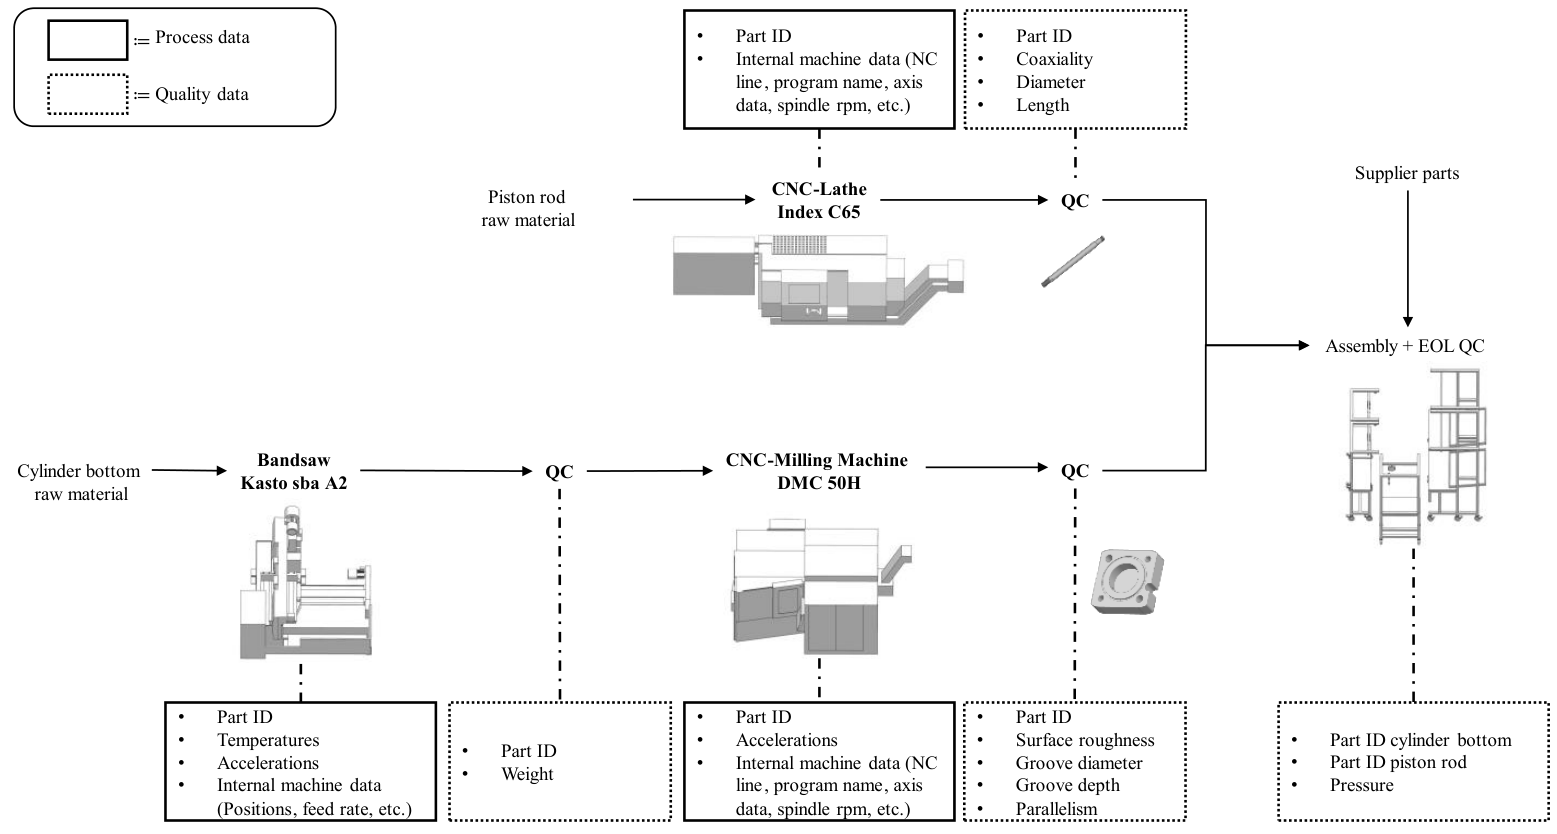

*Figure: Jourdan et al., Figure 1, author-deposited manuscript, [source](https://zenodo.org/records/8420132). Complete figure content reproduced unchanged, with page surroundings omitted and proportional scaling only. The PDF prints [CC BY-NC-ND 4.0](https://creativecommons.org/licenses/by-nc-nd/4.0/); its Zenodo metadata lists CC BY 4.0. This academic report/notebook retains the more restrictive printed attribution. The article licence does not automatically establish the reuse terms of separately hosted dataset files.*

| Data available in the source | What it means | Role in our model |
|---|---|---|
| Saw machine/control and sensor time series | Power, energy, feed, position, vibration and other process observations | Only allowed active-cut physical features become final RF inputs |
| Saw weight and QC records | Inspection after the blank is cut | Historical quality-escape definition, not a predictor |
| Milling measurements | Surface roughness, parallelism, groove depth and diameter | Future outcome used only for labelling/evaluation |
| Part IDs, scans and timestamps | QR-based linkage between component processes and QC | Traceability, grouping and diagnostics, not RF predictors |
| Documented fault classes | Normal-process annotation; intentionally short/misaligned blank; Milling-clamping and miscellaneous faults | Defines the narrow target and exclusions |
| Turning, assembly, Milling process streams, logs | Wider manufacturing and final test context | Available context, not inputs to the final Saw-stage RF |

The paper describes 847 assembled cylinders. Our 984 prepared Saw records, 474 selected mixed-day records and 75 benchmark products are different units/populations and must be identified separately. The paper also reports a November 2022-June 2023 collection period, while the notebook includes Saw dates in August-October 2022. Release/component/stage coverage and dates require reconciliation; do not silently relabel notebook dates to match the paper.

**Physical interpretation from the source:** The authors deliberately cut 99 blanks too short. For this fault, subsequent face milling may fail to remove material as intended, affecting surface quality. Our recorded 81 Milling-QC failures are a notebook result obtained using the stated QC criteria, not a count copied from the paper. A later pressure-test pass is not the same as passing the Milling geometry/surface requirements. Whole-machine-cycle times quoted in the paper should not be substituted for the active-cut durations used in our feature extraction.

**Relevant research context:** [SSMSPC (Biegel et al., 2024)](https://doi.org/10.1007/s10845-023-02156-7) uses self-supervised representations and statistical process monitoring, including a CiP-DMD CNC-Milling experiment. Our sensor stage, target and evaluation protocol differ, so its published scores are not directly comparable with our benchmark. [Jourdan et al. (2021), manufacturing ML reliability](https://arxiv.org/abs/2112.06986), illustrates performance deterioration under drift and motivates independent period-based evaluation and monitoring. The contribution claimed here is the specific quality-escape target and upstream inspection decision; this short comparison is not an exhaustive novelty search.

### Corrected label interpretation

The early notebook initially used an ambiguous legacy anomaly field. Later preparation uses the documented fault classes: class 0 is the normal-process annotation, class 1 is Saw misalignment, class 2 is the Milling-clamping fault, and class 3 covers miscellaneous faults. Class 0 must not be interpreted as guaranteed passage of every downstream quality check.

The final business target, `hidden_saw_defect`, is 1 only when all of the following hold:

1. The product has the documented Saw-misalignment annotation.
2. It passes the reconstructed Saw weight QC rule.
3. Its Milling QC outcome is known and fails at least one checked requirement.

Other products with known outcomes in the selected modelling population are target 0. Products without complete required Milling measurements are excluded from business-target training and evaluation. A negative prediction is not a certificate that a workpiece is free of all defects.

### Population accounting

| Stage | Count | Meaning |
|---|---:|---|
| Prepared Saw time-series products | 984 | 834 class 0, 99 class 1, 41 class 2, 10 class 3 |
| Initial class-0/class-1 task | 933 | Deliberately excludes the other documented fault classes |
| Active-cut feature records | 931 | Records retained by the implemented extraction checks |
| Selected mixed-class production days | 474 | Six days containing both original task classes; 408 class 0 and 66 class 1 |
| Initial development / fixed-test allocation | 383 / 91 | Groups of consecutive products are kept together |
| Products with known Milling QC | 404 | 70 of the 474 lack complete required downstream outcomes |
| Final business-target development / benchmark | 329 / 75 | Preserves the earlier product allocation after outcome filtering |
| Target-positive development / benchmark | 33 / 30 | Target-negative counts are 296 / 45 |

The 404-product business population contains 245 class-0 products passing Milling, 94 class-0 products failing Milling, 63 target positives and 2 misaligned products passing Milling. These exclusions and class definitions limit the population to which the reported result applies.

## 5. Final solution and training procedure

### Feature construction

The final RF uses samples for which `bCutActive > 0.5`, extracting features only from the active part of the completed Saw operation. The extraction code requires at least five active samples. Candidate predictors come from power, cutting energy, feed, position and vibration signals, using statistics such as standard deviation, interquartile range, range, slope, skewness, kurtosis and absolute changes.

The final feature allowlist contains 168 candidate features. Product IDs, production dates, fault annotations, Saw QC outcomes and Milling outcomes are excluded from the predictor matrix. Restricting features to physical signals reduces obvious shortcuts but does not remove all operating-condition information.

### Product grouping and validation

1. Select production days containing both original class-0/class-1 labels. This is a retrospective scope restriction, not proof of controlled conditions.
2. Sort products within each day and create groups of eight consecutive products.
3. Use `GroupShuffleSplit` with seed 42 and take the first candidate satisfying the implemented size/class/day-coverage requirements. The code considers up to 500 candidates. The requirements include approximately 17-23% test products, both original classes and every selected day in both partitions; selection is not based on model scores.
4. Keep that product allocation fixed, then exclude unknown Milling outcomes for the business-target model, leaving 329 development and 75 benchmark products.
5. Generate development out-of-fold predictions using five-fold `StratifiedGroupKFold`, grouped by production block, with seed 123.
6. Fit feature cleaning separately on each training fold: remove excessive missingness (>20%), constant or near-constant features (dominant value >=99.5%), impute training medians, and drop highly correlated features (>0.95 absolute correlation). Apply the learned choices to the validation fold. Repeat using development data only before final benchmark inference.

### Final Random Forest configuration

| Setting | Value |
|---|---|
| Prediction target | `hidden_saw_defect` |
| Trees | 500 |
| Maximum depth | 6 |
| Minimum samples per leaf | 2 |
| Class weighting | `balanced` |
| Model seed | 42 |
| Final retained features | 129 |
| Decision threshold | 0.25 |

Threshold candidates run from 0.05 to 0.80 in steps of 0.025. The final business-model rule maximizes development out-of-fold capture subject to a false-alarm rate <=5%, with ties resolved by precision and then threshold. The selected threshold is 0.25. The model is then fitted on all 329 development products and evaluated on the 75-product benchmark. This operating point is an empirical choice, not a guarantee of a <=5% factory false-alarm rate.

Random Forest is a reasonable candidate for a small tabular feature dataset and supports nonlinear relationships without a large deep-learning training population. Its preference here is based on the recorded comparisons; it is not a claim that RF always outperforms deep learning. No pretrained weights are used by the final RF.

## 6. Experiment roadmap and how the conclusion evolved

| Experiment phase | What was learned | Status in the final interpretation |
|---|---|---|
| Initial label exploration | The legacy anomaly flag differed from the documented fault classes | Superseded by corrected labels |
| Full-sequence modelling | Strong random-split results did not establish robustness to production changes | Exploratory |
| Active-cut physical features and day-based validation | Performance varied substantially across days | Evidence of generalization risk |
| Strict matching for the earlier misalignment task | Pooled ROC-AUC 0.458 and F1 0.383 | Unsuccessful robustness experiment; a different target/model from the final RF |
| Narrowed mixed-day modelling | Focus shifted to a limited population with both original classes | Useful prototype scope, not experimental control |
| Downstream trace and target redesign | Misalignment, Saw pass and Milling failure were combined into the business target | Final problem definition |
| Fixed-block business RF | 20/30 target defects caught; 1/45 non-target products flagged | Main recorded benchmark result |
| Raw-sequence TCN | 14/30 caught; 0/45 false alarms | Comparator at a different selected operating point |
| MiniROCKET | Development capture 23/33, false alarms 12/296 | Development-only alternative |
| Within-cut progressive prediction | Initially 17/30 detected while cutting, plus 2 at end | Exploratory only |
| Same-day check of 30-second scores | Defect ranked higher in 2/10 pairs; none within 60 minutes | No validated within-cut claim retained |

Earlier apparent capture of approximately 95% involved a population containing model-training products and is not an accepted test result. Keeping that experiment below provides a record of why the evaluation was revised.

## 7. Final results: use these populations and metric definitions

### Primary fixed benchmark: direct business-target RF

| Actual / prediction | Predicted non-target | Flagged target risk |
|---|---:|---:|
| Actual non-target | 44 | 1 |
| Actual target defect | 10 | 20 |

| Metric | Result | Definition / interpretation |
|---|---:|---|
| Target-defect capture / recall | 66.67% | 20 / 30 target defects flagged |
| False-alarm rate | 2.22% | 1 / 45 non-target products flagged |
| Precision | 95.24% | 20 / 21 flagged products are target positive |
| F1 | 0.784 | Harmonic mean of precision and recall |
| Balanced accuracy | 0.822 | Mean of sensitivity and specificity |
| ROC-AUC | 0.914 | Ranking performance on this benchmark |
| Average precision | 0.897 | `average_precision_score`; labelled PR-AUC in the original output |

The reconstructed Saw weight check identified none of these 30 target defects. The RF offers a potential additional inspection opportunity; it does not establish that all flagged defects could be repaired or all associated downstream cost avoided.

### Same-benchmark model comparison

| Measure | Business-target RF | TCN |
|---|---:|---:|
| Target defects flagged | 20 / 30 | 14 / 30 |
| Target defects missed | 10 / 30 | 16 / 30 |
| Non-target products flagged | 1 / 45 | 0 / 45 |
| Capture | 66.67% | 46.67% |
| F1 | 0.784 | 0.636 |
| ROC-AUC | 0.914 | 0.762 |
| Average precision | 0.897 | 0.812 |
| Development-selected threshold | 0.25 | 0.875 |

RF caught more target defects; TCN generated fewer false alarms in this sample. This compares complete pipelines at their own development-selected thresholds, not architectures at an identical false-alarm operating point. The TCN used 12 channels and 128-point resampled sequences, with a recorded tensor of 404 products, training-fold normalization, weighted binary cross-entropy, backpropagation and AdamW optimization. Its reported benchmark scores average development-fold model predictions. Its saved logs report CPU execution. These preprocessing and fitting choices differ from the final RF pipeline.

### Development results and auxiliary analysis

The final RF's development out-of-fold predictions at the selected threshold caught 30/33 target defects and flagged 10/296 non-target products (90.91% capture, 3.38% false alarms). Because that threshold was selected using these predictions, these are threshold-selection results, not another independent test. MiniROCKET caught 23/33 with 12/296 false alarms on development and was not evaluated on the fixed benchmark.

The broader analysis combines development out-of-fold predictions with benchmark predictions: 50/63 target defects were flagged, and 0/94 class-0 Milling failures were flagged. These mixed-population counts must not replace the benchmark result or be presented as independent proof of fault-origin identification. They do not show general detection of all downstream failures.

### Feature interpretation and errors

The three largest final RF impurity importances are `PData.CutEnergy__std` (0.136197), `Position__slope` (0.133136) and `PData.PEff__range` (0.105111). They indicate model reliance on energy, motion and power patterns. Impurity importance does not establish causal mechanisms and can be affected by correlations and operating conditions.

The final benchmark has ten missed target defects and one false alarm, recorded as a class-0 product that passed Milling QC. A detailed per-day and per-block breakdown of this final RF's errors is still needed. The later timing/error analysis belongs to the within-cut models and must not be substituted for final full-stage RF error analysis.

### Why early detection remains further work despite promising results

The progressive extension did produce a useful-looking result: **17/30 targets flagged while cutting**, two at cut end, eleven missed, and **2/45 non-target false alarms** overall. Median first warning was 20 seconds among the 19 detected targets. Among the 17 true within-cut detections, median lead time was **54 seconds**; the previously reported 47 seconds included end-only detections in its denominator. Neither value describes missed cases.

We paused the validated claim because the subsequent same-day 30-second diagnostic did not support stable discrimination: only 2/10 defects outranked their paired controls, no pair was within 60 minutes, and early-detected cuts were longer (median 74 s) than missed cuts (49 s). This raises production-condition concerns while leaving the dataset too weakly matched to resolve them. It does not prove that early detection is impossible, that confounding is the only explanation, or that every checkpoint failed. The diagnostic examines one checkpoint's scores, not the complete progressive policy.

The standalone 30-second classifier caught 16/30 using threshold 0.25. The progressive policy had accumulated 14/30 detections by 30 seconds under different thresholds; these are not inconsistent results. Future work should predefine causal checkpoints and policy-level false-alarm control, then evaluate independent production periods with comparable positives/controls, temporal separation, sufficient events and full timing/coverage/missed-case reporting. More model searches on the same repeatedly inspected benchmark cannot substitute for this validation.

## 8. Evaluation limitations and claim boundaries

1. **New-day and new-machine generalization are unproven.** Every selected day is represented in both development and benchmark. A block split tests different products/blocks from familiar days; it is not a prospective future-day test. No independent factory or machine evaluation is provided.
2. **The phrase 'controlled conditions' is only an assumption in earlier cells.** Selecting mixed-class days and physical features does not match tool wear, settings, material, temperature or other operating factors. Blocks of eight also do not prevent near-neighbour dependence across adjacent block boundaries; no temporal exclusion gap is enforced.
3. **Production-period confounding is a major concern.** Benchmark composition is 9/0, 7/0, 13/0, 0/4, 16/10 and 0/16 non-target/target products across the six days in date order. In particular, October 27 has 16 positives and no negatives, while October 10 has 16 negatives and 10 positives. Day-associated process differences may support predictions without reflecting a transferable defect signal.
4. **Strict evidence is limited and relates to different experiments.** The earlier matched full-cut model used the misalignment target and failed to demonstrate useful discrimination. The 30-second check matched only ten pairs, all separated by more than 60 minutes, and found two wins for defects. Neither directly measures the final business-target RF under well-matched conditions. The 30-second result also cannot prove that confounding is the sole explanation for performance.
5. **The benchmark was reused and the dataset was explored before it was fixed.** Final RF fitting and feature cleaning exclude its benchmark rows, but several later models and analyses inspect the same outcomes. Target/model choices evolved during this process. Therefore the benchmark is not an untouched confirmatory test of the entire research process, even though it is held out from final model fitting.
6. **The sample and target-positive training population are small.** The final RF has 33 development positives and the benchmark has only 30 positives and 45 negatives. One extra false alarm changes the measured false-alarm rate by 2.22 percentage points. Correlated production records further limit effective independent evidence; point estimates are not guarantees and no cluster-aware confidence intervals are supplied here.
7. **Selection and missing-outcome bias are possible.** The final 404 records are a selected subset of 984 prepared products. Other fault classes, days without both original classes, failed feature records and unknown downstream outcomes are not represented equivalently. Excluding missing QC can bias evaluation if missingness is related to quality or production conditions.
8. **Prevalence differs across partitions.** The target occurs in 33/329 development products (10.03%) and 30/75 benchmark products (40%). Precision and average precision depend on this composition and should not be transferred to a production line with a different fault rate. Recall and false-alarm rates may also change under operating-condition shifts.
9. **The target is deliberately narrow.** It is the intersection of documented Saw misalignment, Saw weight pass and Milling failure. A class-0 Milling failure is non-target even though the workpiece failed downstream QC. With only two misaligned Milling-pass products in the final population, evidence that the model distinguishes downstream failure risk from misalignment itself is limited. This is not generic downstream failure detection or automated causal attribution across stages.
10. **Fault and QC labels require provenance.** The faults were intentionally introduced in the source experiment. Their distribution may differ from naturally occurring faults. The notebook corrects legacy label inconsistencies and handles duplicate records, but record linkage, duplicate resolution and measurement validity remain assumptions to document. Failure of a reconstructed Milling criterion is not the same as demonstrated final assembly failure or a customer rejection.
11. **QC reconstruction is retrospective.** Saw bounds are reconstructed using the full source weight distribution (mean +/- three population standard deviations), and Milling bounds are applied to the raw measurement representation. These are historical label/baseline conventions, not development-only learned deployment limits. In a prospective system, approved QC specifications must be frozen in advance, units and raw-versus-physical representations reconciled, and missing measurements handled explicitly.
12. **Preprocessing guarantees apply to the final pipeline, not every earlier cell.** Final RF cleaning uses training folds only. Some earlier exploratory cleaning was performed before cross-validation. The historical results cannot all be described as equally protected against leakage.
13. **Within-cut detection is not validated.** The exploratory 17/30 during-cut detections and two end-only detections are retained for transparency, not used as the main deployment claim. End-of-Saw prediction still precedes Milling but does not imply reliable prediction in the first 10-40 seconds.
14. **Scores and explanations have limits.** RF output is used as a risk score; calibration has not been demonstrated. Feature importance is not causal explanation. An operational threshold should account for local prevalence, inspection capacity and consequences after independent validation.
15. **Savings and deployment are proposed, not measured.** No production intervention, measured financial benefit, avoided-energy result, end-to-end inference latency, throughput capacity, integration test or operator study is established. The model must supplement existing QC. A flagged workpiece should be inspected rather than automatically scrapped, and an unflagged one must still undergo normal QC.
16. **Benchmark comparisons are incomplete.** RF and TCN differ in representation, fitting and threshold. A simpler statistical or linear baseline and comparison with feasible direct geometric/alignment inspection could further establish the value of ML. Zero TCN false alarms in 45 negatives does not prove a true zero false-alarm rate.
17. **The visual pack contains manual summaries.** Key final RF metrics match the saved output, but plotted constants are not automatically regenerated from predictions. The exploratory plot assigns 'End' to 52 seconds even though individual cuts differ; it should be a categorical endpoint. The 0.897 value is average precision, not necessarily trapezoidal PR area. Mark the architecture as proposed and keep exploratory plots explicitly labelled.
18. **Reproducibility and documentation remain incomplete.** The diary has repeated experiments, superseded prose, network downloads, generated intermediate files and unpinned dependencies. No fresh end-to-end run was performed for this Markdown addition. Exact dataset version/licence, dependency versions, broader literature review and final submission documents still need completion. Adding this overview improves interpretation but does not certify that every original cell runs correctly.

## 9. Proposed industrial workflow and business value

At completion of Sawing, associate the workpiece ID with its active-cut signals, apply the saved feature preprocessing and RF model, and record the score, threshold and model version. For a workpiece passing ordinary Saw QC, a high score prompts an operator to hold it and perform a targeted inspection before Milling. A low score follows the normal production and QC route. Missing or out-of-range sensor data should fall back to existing procedures rather than silently produce a release decision.

Historical Milling outcomes can later be linked back by product ID for monitoring. A proposed MLOps implementation would monitor missing sensors, input/score drift, flagging rate, delayed-label capture and false alarms, and performance by production period. It would maintain a versioned model and preprocessing bundle, decision logs, a rollback path and controlled retraining. These are proposed components; the architecture diagram does not show an implemented deployment.

Potential net value should be evaluated as **avoided downstream processing cost minus added inspection/holding cost and system operating cost**, including any consequences of erroneous decisions. No monetary amount is claimed. The benchmark suggests an opportunity to investigate 20 correctly flagged target workpieces, not proof that 20 products or their full manufacturing costs could have been saved.

## 10. Further development, in priority order

1. **Complete the final-RF error audit:** report target capture and false alarms by day/block, inspect the ten false negatives, and compare existing final scores within mixed-class periods. Label this analysis as post hoc; do not tune on those results and continue calling the benchmark untouched.
2. **Establish independent validation:** predefine the target, feature rules, threshold-selection procedure and evaluation metrics; test on genuinely new production periods with appropriate temporal grouping/gaps and sufficient positives and controls. Obtain new production data after the competition or under its explicit permissions; do not add prohibited external samples during the challenge.
3. **Strengthen the label and data audit:** verify product-ID links, duplicate handling, QC units/specifications, missingness and class exclusions; obtain more representative naturally occurring faults and misaligned products that pass Milling for later validation.
4. **Quantify uncertainty and operational trade-offs:** add suitable group-aware uncertainty estimates, threshold sensitivity, prevalence scenarios and calibration assessment. Compare simple baselines and practical inspection alternatives using a common decision objective.
5. **Investigate model changes only against a defined weakness:** assess stability of the physical features, preprocessing/segmentation choices and representations. Revisit within-cut prediction only with independent time-valid evaluation and no full-cut information in early features.
6. **Measure feasibility and economics:** benchmark complete preprocessing/inference time, inspect sensor availability, quantify inspection effort and downstream processing cost, and begin an operator-reviewed shadow pilot before any automated action.
7. **Package the reproducible submission:** pin source and dependency versions, preserve the split manifest and final predictions, save preprocessing/model artifacts, document required inputs, verify a clean-kernel run, and complete the literature review, report and presentation. Keep this diary as the research record if a streamlined execution notebook is later produced.

## 11. Navigation, reproducibility and submission notes

To find the key original sections below, search these exact headings or identifiers:

| Purpose | Search text in the original notebook |
|---|---|
| Corrected metadata | `CiP-DMD — CORRECTED SAW DATA PREPARATION` |
| Feature generation | `ACTIVE-CUT-ONLY PHYSICAL FEATURE EXTRACTION + GROUPED TEST` |
| Dataset-level quality trace | `TRACE SAW MISALIGNMENTS THROUGH DOWNSTREAM QUALITY` |
| Product allocation | `FINAL LOCKED HOLDOUT VALIDATION` |
| Final model and accepted results | `FINAL BUSINESS-TARGET MODEL` and `FIXED BENCHMARK — DIRECT BUSINESS TARGET` |
| TCN comparator | `DIRECT RAW TIME-SERIES MODEL` |
| MiniROCKET | `DEVELOPMENT-ONLY MINIROCKET EXPERIMENT` |
| Rejected within-cut extension | `FINAL MATCHED-CONDITION CHECK — ROBUST VERSION` |
| Report figures | `ADVANCED REPORT VISUAL PACK` |

Key generated files referenced by the code are `saw_active_cut_features.csv`, `FINAL_LOCKED_HOLDOUT_SPLIT.csv`, `FINAL_DIRECT_BUSINESS_TARGET_RESULTS.csv`, `FINAL_DIRECT_BUSINESS_TARGET_FEATURES.csv`, `FINAL_TCN_TIMESERIES_BENCHMARK.csv`, and `FINAL_MATCHED_30S_SUMMARY.csv`, under `/kaggle/working/saw_clean`. They are generated or referenced artifacts, not files embedded by this overview. Do not run only the final model cell without generating or supplying its prerequisites.

The recorded environment is Kaggle/Python 3.12. Main library families include NumPy, pandas, SciPy, scikit-learn, Matplotlib, h5py, PyTorch, requests and sktime for MiniROCKET. Exact versions and a source commit must be captured from the actual reproducible run rather than inferred from this summary. RF seed 42, split seed 42 and grouped-CV seed 123 are documented above; a fixed seed does not ensure identical output across all dependency or hardware changes.

The OctWave booklet requires a named notebook, technical report PDF, presentation PDF and dataset files or complete access information in the final ZIP. It recommends a five-page report excluding references/appendices and a 10-minute presentation plus five minutes of Q&A. This overview provides notebook documentation; separate submission requirements remain.

**AI assistance disclosure:** ChatGPT assisted with problem refinement, code drafting/debugging, result interpretation, visual-generation code and this retrospective overview. The team remains responsible for checking the source data, reviewing and testing the implementation, correcting misleading claims, documenting citations, and understanding and defending every submitted result.

**Final retained conclusion:** This work demonstrates a retrospective prototype for end-of-Saw inspection support in a selected, traceable manufacturing dataset. Its main fixed-benchmark result is 20/30 target defects flagged with 1/45 non-target false alarms. Independent production-period validation and deployment evaluation are still required.

---

## Original chronological notebook begins below

The following cells are preserved exactly as supplied. Read earlier claims using the final definitions and limitations above.


In [1]:
import sys; print(sys.executable)

c:\Users\Savandi\anaconda3\python.exe


In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

## Problem

- Detect a future quality failure at the earliest possible manufacturing stage, and identify the most likely stage where the problem originated.

OR 

- At what earliest point has enough evidence accumulated that continuing to process this particular workpiece is no longer economically justified?

> Manufacturing defects are often identified only after downstream processing has already consumed additional machine time and resources. The proposed system uses traceable sensor and process data from each manufacturing stage to determine the earliest point at which a workpiece is likely to fail downstream quality requirements, while also identifying the most likely stage where the abnormality originated. This enables manufacturers to stop, inspect, or rework risky parts before investing further processing resources

### Data preprocess

In [3]:
# Cell 1 — Download CiP-DMD repository

!git clone --depth 1 \
https://github.com/HannesJoern/interq_data_acquisition_public.git \
/kaggle/working/CiP-DMD

Cloning into '/kaggle/working/CiP-DMD'...


In [4]:
# Cell 2 — Check dataset size + files

import os

ROOT = "/kaggle/working/CiP-DMD"

!du -sh "$ROOT"

for root, dirs, files in os.walk(ROOT):
    level = root.replace(ROOT, "").count(os.sep)

    if level <= 3:
        indent = "  " * level
        print(f"{indent}📁 {os.path.basename(root)}/")

        for f in files[:10]:
            print(f"{indent}   └─ {f}")

📁 CiP-DMD/
   └─ dataset_structure.png
   └─ dataset_structure.pptx
   └─ README.md
  📁 .git/
     └─ config
     └─ description
     └─ HEAD
     └─ index
     └─ packed-refs
     └─ shallow
    📁 hooks/
       └─ applypatch-msg.sample
       └─ commit-msg.sample
       └─ fsmonitor-watchman.sample
       └─ post-update.sample
       └─ pre-applypatch.sample
       └─ pre-commit.sample
       └─ pre-merge-commit.sample
       └─ pre-push.sample
       └─ pre-rebase.sample
       └─ pre-receive.sample
    📁 info/
       └─ exclude
    📁 logs/
       └─ HEAD
      📁 refs/
    📁 objects/
      📁 info/
      📁 pack/
         └─ pack-d9b53e96487496d11acc667ebe545c7bef7da34e.idx
         └─ pack-d9b53e96487496d11acc667ebe545c7bef7da34e.pack
         └─ pack-d9b53e96487496d11acc667ebe545c7bef7da34e.rev
    📁 refs/
      📁 heads/
         └─ main
      📁 remotes/
      📁 tags/
  📁 maintenance logs/
     └─ maintenance_log_milling.xlsx
     └─ maintenance_log_sawing.xlsx
     └─ maintenance_lo

'du' is not recognized as an internal or external command,
operable program or batch file.


### DOWNLOAD ONLY CYLINDER RELEVANT DATA 

In [5]:
# ================================================================
# CiP-DMD — DOWNLOAD ONLY PROJECT-RELEVANT CYLINDER DATA
# Saw -> CNC Milling -> Quality
# ================================================================

import os
import re
import shutil
import requests
import pandas as pd
import xml.etree.ElementTree as ET

from pathlib import Path
from urllib.parse import urljoin, unquote

# ------------------------------------------------
# SETTINGS
# ------------------------------------------------

TOKEN = "5Wv34VRZEXBLsZK"
BASE = "https://cloud.ptw-darmstadt.de"

LOCAL_OLD = Path("/kaggle/working/CiP-DMD")
OUT = Path("/kaggle/working/CiP-DMD-cylinder")
OUT.mkdir(parents=True, exist_ok=True)

# All anomalous parts + this many normal parts
NORMAL_PARTS = 250

# Change to True later if we want every cylinder bottom
DOWNLOAD_ALL_PARTS = False

# We NEED these
WANTED_PROCESS_FILES = {
    "frontside_internal_machine_signals.h5",
    "backside_internal_machine_signals.h5",
    "frontside_timestamp_process_pairs.csv",
    "backside_timestamp_process_pairs.csv",
}

# Explicitly skip these huge files
SKIP_WORDS = [
    "external_sensor",
    "spike_data"
]

session = requests.Session()
session.headers.update({"User-Agent": "Mozilla/5.0"})

PROPFIND_BODY = """<?xml version="1.0"?>
<d:propfind xmlns:d="DAV:">
 <d:prop>
  <d:displayname/>
  <d:resourcetype/>
  <d:getcontentlength/>
 </d:prop>
</d:propfind>
"""

NS = {"d": "DAV:"}


# ================================================================
# WEBDAV HELPERS
# ================================================================

def propfind(url, auth=None):
    return session.request(
        "PROPFIND",
        url,
        headers={
            "Depth": "1",
            "Content-Type": "application/xml"
        },
        data=PROPFIND_BODY,
        auth=auth,
        timeout=60
    )


def list_dir(url, auth):
    r = propfind(url, auth)

    if r.status_code != 207:
        raise RuntimeError(
            f"Cannot list {url}\nHTTP {r.status_code}"
        )

    root = ET.fromstring(r.text)

    items = []

    for response in root.findall("d:response", NS):

        href = response.findtext(
            "d:href",
            default="",
            namespaces=NS
        )

        decoded = unquote(href).rstrip("/")
        name = decoded.split("/")[-1]

        resource = response.find(".//d:resourcetype", NS)

        is_dir = (
            resource is not None
            and resource.find("d:collection", NS) is not None
        )

        size_text = response.findtext(
            ".//d:getcontentlength",
            default="0",
            namespaces=NS
        )

        try:
            size = int(size_text)
        except:
            size = 0

        items.append({
            "name": name,
            "href": href,
            "url": urljoin(BASE, href),
            "is_dir": is_dir,
            "size": size
        })

    # remove directory itself
    current = unquote(url).rstrip("/").split("/")[-1]

    return [
        x for x in items
        if x["name"] and x["name"] != current
    ]


# ================================================================
# 1. FIND WORKING WEBDAV
# ================================================================

print("="*80)
print("1. CONNECTING TO OFFICIAL CiP-DMD SHARE")
print("="*80)

DAV_OPTIONS = [
    (BASE + "/public.php/webdav/", (TOKEN, "")),
    (
        BASE + f"/remote.php/dav/public-files/{TOKEN}/",
        None
    ),
    (
        BASE + f"/remote.php/dav/public-files/{TOKEN}/",
        (TOKEN, "")
    ),
]

DAV = None
AUTH = None

for url, auth in DAV_OPTIONS:

    try:
        r = propfind(url, auth)

        print(url, "->", r.status_code)

        if r.status_code == 207:
            DAV = url
            AUTH = auth
            break

    except Exception as e:
        print("Error:", e)

if DAV is None:
    raise RuntimeError(
        "❌ Could not connect to current public WebDAV share."
    )

print("\n✅ Connected")


# ================================================================
# 2. FIND cylinder_bottom DIRECTORY
# ================================================================

print("\n" + "="*80)
print("2. FINDING CYLINDER DATA")
print("="*80)

root_items = list_dir(DAV, AUTH)

print("Top-level folders/files:")

for x in root_items[:30]:
    print(
        "📁" if x["is_dir"] else "📄",
        x["name"]
    )


def find_folder(start_url, folder_name, max_depth=2):

    queue = [(start_url, 0)]
    visited = set()

    while queue:

        url, depth = queue.pop(0)

        if url in visited:
            continue

        visited.add(url)

        try:
            items = list_dir(url, AUTH)
        except:
            continue

        for x in items:

            if (
                x["is_dir"]
                and x["name"].lower() == folder_name.lower()
            ):
                return x["url"]

        if depth < max_depth:

            for x in items:

                if x["is_dir"]:
                    queue.append((x["url"], depth + 1))

    return None


cylinder_bottom_url = find_folder(
    DAV,
    "cylinder_bottom",
    max_depth=2
)

if cylinder_bottom_url is None:
    raise RuntimeError(
        "❌ cylinder_bottom folder not found."
    )

if not cylinder_bottom_url.endswith("/"):
    cylinder_bottom_url += "/"

print("\n✅ cylinder_bottom found:")
print(cylinder_bottom_url)


# ================================================================
# 3. NAVIGATE TO MILLING PROCESS DATA
# ================================================================

def child_folder(parent, wanted):

    for x in list_dir(parent, AUTH):

        if (
            x["is_dir"]
            and x["name"].lower() == wanted.lower()
        ):

            u = x["url"]

            if not u.endswith("/"):
                u += "/"

            return u

    return None


milling_url = child_folder(
    cylinder_bottom_url,
    "cnc_milling_machine"
)

if milling_url is None:
    raise RuntimeError("❌ cnc_milling_machine missing")


process_url = child_folder(
    milling_url,
    "process_data"
)

if process_url is None:
    raise RuntimeError("❌ process_data missing")


print("✅ CNC Milling folder found")
print("✅ Milling process_data found")


# ================================================================
# 4. SELECT PRODUCT IDS
# ================================================================

print("\n" + "="*80)
print("3. SELECTING PRODUCTS")
print("="*80)

anomaly_file = (
    LOCAL_OLD /
    "meta/data/anomalous_parts_detailed.csv"
)

qc_file = (
    LOCAL_OLD /
    "meta/data/cylinder_bottoms_qc_data.csv"
)

an = pd.read_csv(anomaly_file, sep=";")
qc = pd.read_csv(qc_file, sep=";")

anomaly_ids = set(
    an["part_id"]
    .astype(str)
    .str.replace(".0", "", regex=False)
)

all_ids = list(
    qc["part_id"]
    .astype(str)
    .str.replace(".0", "", regex=False)
)

normal_ids = [
    x for x in all_ids
    if x not in anomaly_ids
]

if DOWNLOAD_ALL_PARTS:

    selected_ids = set(all_ids)

else:

    selected_ids = (
        anomaly_ids |
        set(normal_ids[:NORMAL_PARTS])
    )


print("Known anomalous IDs :", len(anomaly_ids))
print("Normal selected     :", len(set(normal_ids[:NORMAL_PARTS])))
print("TOTAL selected      :", len(selected_ids))


# ================================================================
# 5. FIND REMOTE PRODUCT FOLDERS
# ================================================================

print("\n" + "="*80)
print("4. FINDING MILLING PRODUCT FOLDERS")
print("="*80)

remote_parts = list_dir(process_url, AUTH)

selected_folders = []

for x in remote_parts:

    if not x["is_dir"]:
        continue

    # folder example:
    # 100101_11_29_2022_12_30_29

    match = re.match(r"^(\d{6})", x["name"])

    if not match:
        continue

    pid = match.group(1)

    if pid in selected_ids:

        x["part_id"] = pid
        selected_folders.append(x)


print(
    "Remote milling part folders:",
    len(remote_parts)
)

print(
    "Selected matching folders:",
    len(selected_folders)
)

print("\nExamples:")

for x in selected_folders[:10]:
    print(x["part_id"], "->", x["name"])


# ================================================================
# 6. DISCOVER EXACT FILES + CALCULATE SIZE
# ================================================================

print("\n" + "="*80)
print("5. CALCULATING DOWNLOAD SIZE")
print("="*80)

targets = []

for i, folder in enumerate(selected_folders):

    folder_url = folder["url"]

    if not folder_url.endswith("/"):
        folder_url += "/"

    try:

        contents = list_dir(folder_url, AUTH)

    except Exception as e:

        print(
            "Cannot inspect",
            folder["name"],
            e
        )

        continue

    for f in contents:

        if f["is_dir"]:
            continue

        filename = f["name"].lower()

        if any(word in filename for word in SKIP_WORDS):
            continue

        if f["name"] in WANTED_PROCESS_FILES:

            f["part_id"] = folder["part_id"]
            f["remote_folder"] = folder["name"]

            targets.append(f)

    if (i + 1) % 100 == 0:
        print(
            f"Scanned {i+1}/{len(selected_folders)} products"
        )


total_bytes = sum(x["size"] for x in targets)

print("\nFiles selected:", len(targets))
print(
    f"Estimated download size: "
    f"{total_bytes / 1024**3:.2f} GB"
)

_, _, free = shutil.disk_usage("/kaggle/working")

print(
    f"Kaggle free disk: "
    f"{free / 1024**3:.2f} GB"
)


if total_bytes > free * 0.80:

    raise RuntimeError("""
❌ Selected files are still too large.

Reduce:
NORMAL_PARTS = 100

and run again.
""")


# ================================================================
# 7. DOWNLOAD MILLING DATA
# ================================================================

print("\n" + "="*80)
print("6. DOWNLOADING MILLING DATA")
print("="*80)

PROCESS_OUT = (
    OUT /
    "cylinder_bottom" /
    "cnc_milling_machine" /
    "process_data"
)

downloaded_bytes = 0
completed = 0

for target in targets:

    local_dir = (
        PROCESS_OUT /
        target["remote_folder"]
    )

    local_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    local_file = (
        local_dir /
        target["name"]
    )

    # don't redownload
    if (
        local_file.exists()
        and local_file.stat().st_size > 0
    ):

        completed += 1
        continue

    try:

        with session.get(
            target["url"],
            auth=AUTH,
            stream=True,
            timeout=180
        ) as r:

            r.raise_for_status()

            with open(local_file, "wb") as f:

                for chunk in r.iter_content(
                    chunk_size=4 * 1024 * 1024
                ):

                    if chunk:
                        f.write(chunk)
                        downloaded_bytes += len(chunk)

        completed += 1

        if completed % 50 == 0:

            print(
                f"{completed}/{len(targets)} files | "
                f"{downloaded_bytes/1024**3:.2f} GB downloaded"
            )

    except Exception as e:

        print(
            "❌",
            target["part_id"],
            target["name"],
            e
        )


# ================================================================
# 8. DOWNLOAD SMALL QUALITY + METADATA FILES
# ================================================================

print("\n" + "="*80)
print("7. DOWNLOADING CYLINDER QUALITY / METADATA")
print("="*80)


def recursive_small_files(remote_url, local_dir, depth=0):

    if depth > 3:
        return

    try:
        items = list_dir(remote_url, AUTH)
    except:
        return

    for x in items:

        name_lower = x["name"].lower()

        if x["is_dir"]:

            # Skip process_data because already handled
            if name_lower == "process_data":
                continue

            next_local = local_dir / x["name"]

            u = x["url"]

            if not u.endswith("/"):
                u += "/"

            recursive_small_files(
                u,
                next_local,
                depth + 1
            )

        else:

            # only small useful files
            if not (
                name_lower.endswith(".csv")
                or name_lower.endswith(".json")
            ):
                continue

            local_dir.mkdir(
                parents=True,
                exist_ok=True
            )

            destination = local_dir / x["name"]

            try:

                r = session.get(
                    x["url"],
                    auth=AUTH,
                    timeout=60
                )

                r.raise_for_status()

                destination.write_bytes(r.content)

                print(
                    "✅",
                    destination.relative_to(OUT)
                )

            except Exception as e:

                print("❌", x["name"], e)


recursive_small_files(
    cylinder_bottom_url,
    OUT / "cylinder_bottom"
)


# ================================================================
# 9. FINAL VERIFY
# ================================================================

print("\n" + "="*80)
print("FINAL RESULT")
print("="*80)

h5_files = list(PROCESS_OUT.rglob("*.h5"))
timestamp_files = list(
    PROCESS_OUT.rglob("*timestamp_process_pairs.csv")
)

part_ids_downloaded = set()

for path in h5_files:

    m = re.match(
        r"(\d{6})",
        path.parent.name
    )

    if m:
        part_ids_downloaded.add(m.group(1))


print("Milling HDF5 files :", len(h5_files))
print("Timestamp files    :", len(timestamp_files))
print("Products downloaded:", len(part_ids_downloaded))

size = sum(
    f.stat().st_size
    for f in OUT.rglob("*")
    if f.is_file()
)

print(
    f"Total local size   : {size/1024**3:.2f} GB"
)

print("\nSaved at:")
print(OUT)

1. CONNECTING TO OFFICIAL CiP-DMD SHARE
https://cloud.ptw-darmstadt.de/public.php/webdav/ -> 207

✅ Connected

2. FINDING CYLINDER DATA
Top-level folders/files:
📁 Archive
📄 README.md
📁 cylinder
📁 cylinder_bottom
📄 dataset_structure.png
📁 piston_rod
📁 production_logs

✅ cylinder_bottom found:
https://cloud.ptw-darmstadt.de/public.php/webdav/cylinder_bottom/
✅ CNC Milling folder found
✅ Milling process_data found

3. SELECTING PRODUCTS
Known anomalous IDs : 151
Normal selected     : 250
TOTAL selected      : 401

4. FINDING MILLING PRODUCT FOLDERS
Remote milling part folders: 847
Selected matching folders: 396

Examples:
100101 -> 100101_11_29_2022_12_30_29
100102 -> 100102_11_29_2022_12_40_48
100103 -> 100103_11_29_2022_12_54_12
100104 -> 100104_11_29_2022_12_11_32
100201 -> 100201_11_29_2022_11_42_58
100202 -> 100202_11_29_2022_11_32_50
100203 -> 100203_11_29_2022_11_22_44
100204 -> 100204_11_29_2022_11_11_59
100301 -> 100301_11_29_2022_11_02_29
100302 -> 100302_11_29_2022_10_50_45

5.

**In this data the bussness process roughly is this **

PRODUCT

  │  
  ▼
  
SAW PROCESS

  │
  
  │  time-series machine signals
  
  ▼
  
SAW QUALITY CHECK

  │
  
  │  weight + saw QC info
  
  ▼
  
MILLING PROCESS

  │
  
  │  front-side machine time series
  
  │  back-side machine time series
  
  ▼
  
MILLING QUALITY CHECK

     roughness
     parallelism
     groove depth
     groove diameter

### Lets first focus on Saw stage only

Frit neeed to do data preprocesing

In [6]:
# ============================================================
# PREPARE CLEAN SAW DATASET
# NO SIGNAL PROCESSING — ORGANIZATION ONLY
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import h5py
import shutil

ROOT = Path("/kaggle/working/CiP-DMD")
OUT  = Path("/kaggle/working/saw_prepared")

OUT.mkdir(parents=True, exist_ok=True)

# ============================================================
# 1. SOURCE FILES
# ============================================================

H5_SOURCE = (
    ROOT /
    "process/sawing/data/sampled_saw_process_data.h5"
)

QC_SOURCE = (
    ROOT /
    "meta/data/sawing_qc_data.csv"
)

ANOMALY_SOURCE = (
    ROOT /
    "meta/data/anomalous_parts_detailed.csv"
)

print("="*80)
print("SAW DATA PREPARATION")
print("="*80)

print("\nSources:")
print("Time series :", H5_SOURCE)
print("QC          :", QC_SOURCE)
print("Anomalies   :", ANOMALY_SOURCE)


# ============================================================
# 2. LOAD SAW QC
# ============================================================

qc = pd.read_csv(
    QC_SOURCE,
    sep=";"
)

qc = qc.dropna(axis=1, how="all")

qc["part_id"] = (
    qc["part_id"]
    .astype(str)
    .str.replace(".0", "", regex=False)
    .str.strip()
)

qc = qc.rename(
    columns={
        "part_id": "product_id",
        "weight": "qc_weight",
        "anomaly": "qc_anomaly"
    }
)

print("\nQC rows:", len(qc))
print(qc.head())


# ============================================================
# 3. LOAD EXPERIMENTAL ANOMALY INFORMATION
# ============================================================

an = pd.read_csv(
    ANOMALY_SOURCE,
    sep=";"
)

an = an.dropna(axis=1, how="all")

an["part_id"] = (
    an["part_id"]
    .astype(str)
    .str.replace(".0", "", regex=False)
    .str.strip()
)

# ------------------------------------------------------------
# Build corrected fault class
#
# 0 = no known introduced fault
# 1 = saw misalignment
# 2 = milling clamping fault
# 3 = miscellaneous
# ------------------------------------------------------------

an["fault_class"] = np.nan

if "anomaly_classes" in an.columns:

    an["fault_class"] = pd.to_numeric(
        an["anomaly_classes"],
        errors="coerce"
    )

if "anomaly_class" in an.columns:

    fallback = pd.to_numeric(
        an["anomaly_class"],
        errors="coerce"
    )

    an["fault_class"] = (
        an["fault_class"]
        .fillna(fallback)
    )


keep_cols = [
    "part_id",
    "fault_class"
]

if "anomaly_description" in an.columns:
    keep_cols.append("anomaly_description")

an = an[keep_cols]

an = an.rename(
    columns={
        "part_id": "product_id"
    }
)


# ============================================================
# 4. READ TIME-SERIES INDEX
# ============================================================

records = []

with h5py.File(H5_SOURCE, "r") as hf:

    for product_id in hf.keys():

        data = hf[product_id]

        shape = data.shape

        # Existing CiP-DMD saw data appears as:
        # channels × time
        #
        # Example: (45, 220)
        #
        # We are NOT changing this orientation.

        records.append({
            "product_id": str(product_id),
            "h5_key": str(product_id),
            "n_channels": shape[0] if len(shape) > 0 else np.nan,
            "n_timesteps": shape[1] if len(shape) > 1 else np.nan,
            "raw_shape": str(shape)
        })


ts_index = pd.DataFrame(records)

print("\nTime-series products:", len(ts_index))

print("\nExample:")
print(ts_index.head())


# ============================================================
# 5. JOIN TIME SERIES + QC
# ============================================================

master = ts_index.merge(
    qc,
    on="product_id",
    how="left"
)


# ============================================================
# 6. JOIN EXPERIMENTAL FAULT INFORMATION
# ============================================================

master = master.merge(
    an,
    on="product_id",
    how="left"
)

# Parts missing from anomalous-parts file are treated as
# having no listed introduced anomaly.

master["fault_class"] = (
    master["fault_class"]
    .fillna(0)
    .astype(int)
)


# ============================================================
# 7. CREATE SAW MISALIGNMENT LABEL
# ============================================================

# 1 = intentional saw misalignment was introduced
# 0 = no saw misalignment was introduced

master["misalignment_introduced"] = (
    master["fault_class"] == 1
).astype(int)


# ============================================================
# 8. USEFUL FLAGS — KEEP SEPARATE
# ============================================================

master["has_qc"] = (
    master["qc_weight"].notna()
)

master["has_timeseries"] = True


# Do NOT combine these yet:
#
# qc_anomaly
# misalignment_introduced
#
# They mean different things.


# ============================================================
# 9. ORDER COLUMNS CLEANLY
# ============================================================

desired = [
    "product_id",
    "h5_key",

    "n_channels",
    "n_timesteps",
    "raw_shape",

    "qc_weight",
    "qc_anomaly",

    "misalignment_introduced",
    "fault_class",

    "anomaly_description",

    "has_timeseries",
    "has_qc"
]

desired = [
    c for c in desired
    if c in master.columns
]

master = master[desired]

master = master.sort_values(
    "product_id"
).reset_index(drop=True)


# ============================================================
# 10. COPY ORIGINAL H5 — NO SIGNAL MODIFICATION
# ============================================================

H5_OUT = OUT / "saw_timeseries.h5"

if not H5_OUT.exists():

    print("\nCopying original H5...")

    shutil.copy2(
        H5_SOURCE,
        H5_OUT
    )

else:

    print("\nH5 already copied.")


# ============================================================
# 11. SAVE METADATA
# ============================================================

CSV_OUT = OUT / "saw_product_metadata.csv"

master.to_csv(
    CSV_OUT,
    index=False
)


# ============================================================
# 12. README
# ============================================================

readme = """
CiP-DMD — Prepared Saw Dataset

NO signal processing has been performed.

FILES
-----

saw_timeseries.h5
    Original sampled saw process time-series data.
    Each HDF5 key is a product ID.
    Signal arrays are preserved exactly as provided.

saw_product_metadata.csv
    One row per product.

Main fields:

product_id
    Physical product identifier.

h5_key
    Key used to retrieve the product time series.

n_channels
    Number of signal channels.

n_timesteps
    Number of recorded time samples.

qc_weight
    Weight measured after the sawing process.

qc_anomaly
    Saw quality-check anomaly indicator from the source dataset.

misalignment_introduced
    1 = raw material was intentionally misaligned during sawing.
    0 = no saw misalignment label.

fault_class
    0 = normal / no listed introduced anomaly
    1 = saw misalignment
    2 = milling clamping anomaly
    3 = miscellaneous anomaly

IMPORTANT

qc_anomaly and misalignment_introduced are kept separate.
They should not be treated as the same variable.
"""

(OUT / "README.txt").write_text(readme)


# ============================================================
# 13. VALIDATION
# ============================================================

print("\n" + "="*80)
print("FINAL CLEAN SAW DATASET")
print("="*80)

print("\nProducts:", len(master))

print("\nMisalignment introduced:")
print(
    master["misalignment_introduced"]
    .value_counts()
    .sort_index()
)

print("\nQC anomaly:")
print(
    master["qc_anomaly"]
    .value_counts(dropna=False)
    .sort_index()
)

print("\nFault classes:")
print(
    master["fault_class"]
    .value_counts()
    .sort_index()
)

print("\nMissing QC weights:")
print(
    master["qc_weight"]
    .isna()
    .sum()
)

print("\nTime-series dimensions:")
print(
    master[
        ["n_channels", "n_timesteps"]
    ].describe()
)

print("\nFirst 10 products:")
display(master.head(10))

print("\nSaved:")
print(OUT)

print("""
Clean structure:

saw_prepared/
├── saw_timeseries.h5
├── saw_product_metadata.csv
└── README.txt

NO signal processing performed.
""")

SAW DATA PREPARATION

Sources:
Time series : \kaggle\working\CiP-DMD\process\sawing\data\sampled_saw_process_data.h5
QC          : \kaggle\working\CiP-DMD\meta\data\sawing_qc_data.csv
Anomalies   : \kaggle\working\CiP-DMD\meta\data\anomalous_parts_detailed.csv

QC rows: 985
  product_id  qc_weight  qc_anomaly
0     100101   0.536389           0
1     100102   0.533120           0
2     100103   0.529679           0
3     100104   0.533523           0
4     100201   0.530947           0

Time-series products: 984

Example:
  product_id  h5_key  n_channels  n_timesteps  raw_shape
0     100101  100101          45          220  (45, 220)
1     100102  100102          45          207  (45, 207)
2     100103  100103          45          206  (45, 206)
3     100104  100104          45          200  (45, 200)
4     100201  100201          45          209  (45, 209)

Copying original H5...

FINAL CLEAN SAW DATASET

Products: 985

Misalignment introduced:
misalignment_introduced
0    886
1     9

,product_id,h5_key,n_channels,n_timesteps,raw_shape,qc_weight,qc_anomaly,misalignment_introduced,fault_class,anomaly_description,has_timeseries,has_qc
0,100101,100101,45,220,"(45, 220)",0.536389,0,0,0,NaN,True,True
1,100102,100102,45,207,"(45, 207)",0.533120,0,0,0,NaN,True,True
2,100103,100103,45,206,"(45, 206)",0.529679,0,0,0,NaN,True,True
3,100104,100104,45,200,"(45, 200)",0.533523,0,0,0,NaN,True,True
4,100201,100201,45,209,"(45, 209)",0.530947,0,0,0,NaN,True,True
5,100202,100202,45,205,"(45, 205)",0.530972,0,0,0,NaN,True,True
6,100203,100203,45,203,"(45, 203)",0.532308,0,0,0,NaN,True,True
7,100204,100204,45,192,"(45, 192)",0.531795,0,0,0,NaN,True,True
8,100301,100301,45,194,"(45, 194)",0.533064,0,0,0,NaN,True,True
9,100302,100302,45,190,"(45, 190)",0.531704,0,0,0,NaN,True,True



Saved:
\kaggle\working\saw_prepared

Clean structure:

saw_prepared/
├── saw_timeseries.h5
├── saw_product_metadata.csv
└── README.txt

NO signal processing performed.



In [7]:
saw_df = master
saw_df.describe()

,n_channels,n_timesteps,qc_weight,qc_anomaly,misalignment_introduced,fault_class
count,985.0,985.000000,985.000000,985.000000,985.000000,985.000000
mean,45.0,175.006091,0.568243,0.082234,0.100508,0.214213
std,0.0,31.881226,0.024405,0.274860,0.300828,0.559291
min,45.0,4.000000,0.507503,0.000000,0.000000,0.000000
25%,45.0,160.000000,0.548900,0.000000,0.000000,0.000000
50%,45.0,165.000000,0.580257,0.000000,0.000000,0.000000
75%,45.0,189.000000,0.587990,0.000000,0.000000,0.000000
max,45.0,444.000000,0.624686,1.000000,1.000000,3.000000


In [8]:
saw_df.isna().sum()

product_id                   0
h5_key                       0
n_channels                   0
n_timesteps                  0
raw_shape                    0
qc_weight                    0
qc_anomaly                   0
misalignment_introduced      0
fault_class                  0
anomaly_description        982
has_timeseries               0
has_qc                       0
dtype: int64

So here we dont have any non values, we can ignore anomaly_description 


Lets do some visualizations on it

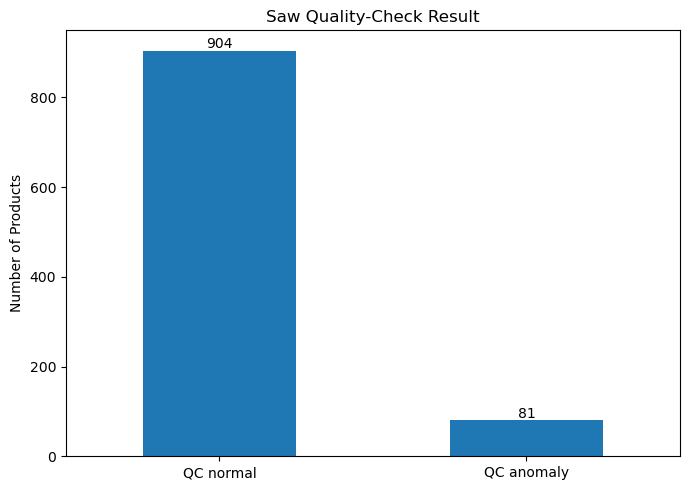

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/kaggle/working/saw_prepared/saw_product_metadata.csv")

counts = df["qc_anomaly"].value_counts().sort_index()
counts.index = ["QC normal", "QC anomaly"]

plt.figure(figsize=(7, 5))
counts.plot(kind="bar")
plt.title("Saw Quality-Check Result")
plt.ylabel("Number of Products")
plt.xlabel("")
plt.xticks(rotation=0)

for i, v in enumerate(counts):
    plt.text(i, v + 5, str(v), ha="center")

plt.tight_layout()
plt.show()

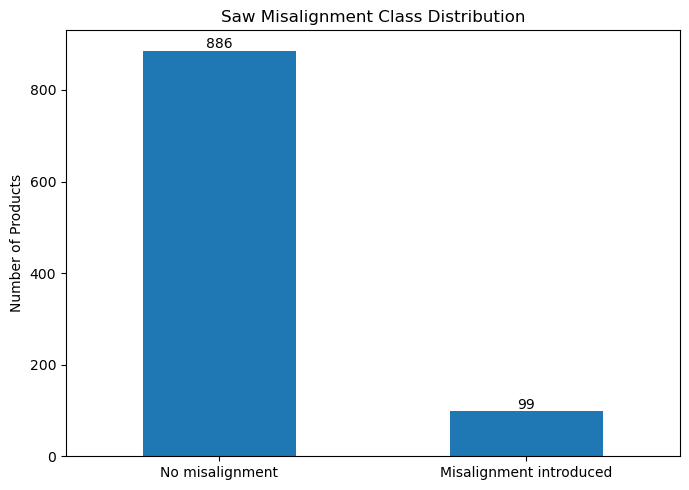

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/kaggle/working/saw_prepared/saw_product_metadata.csv")

counts = df["misalignment_introduced"].value_counts().sort_index()
counts.index = ["No misalignment", "Misalignment introduced"]

plt.figure(figsize=(7, 5))
counts.plot(kind="bar")
plt.title("Saw Misalignment Class Distribution")
plt.ylabel("Number of Products")
plt.xlabel("")
plt.xticks(rotation=0)

for i, v in enumerate(counts):
    plt.text(i, v + 5, str(v), ha="center")

plt.tight_layout()
plt.show()

So class are imbalance we need to go with something like F1 score.

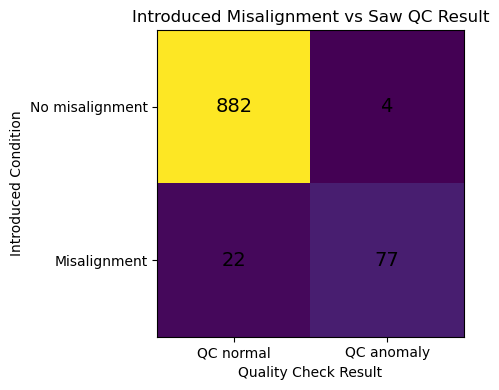

                 QC normal  QC anomaly
No misalignment        882           4
Misalignment            22          77


In [11]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/kaggle/working/saw_prepared/saw_product_metadata.csv")

table = pd.crosstab(
    df["misalignment_introduced"],
    df["qc_anomaly"]
)

table.index = ["No misalignment", "Misalignment"]
table.columns = ["QC normal", "QC anomaly"]

fig, ax = plt.subplots(figsize=(6, 4))

im = ax.imshow(table.values)

ax.set_xticks(range(len(table.columns)))
ax.set_yticks(range(len(table.index)))

ax.set_xticklabels(table.columns)
ax.set_yticklabels(table.index)

ax.set_title("Introduced Misalignment vs Saw QC Result")

# Put counts inside each cell
for i in range(table.shape[0]):
    for j in range(table.shape[1]):
        ax.text(
            j, i,
            table.iloc[i, j],
            ha="center",
            va="center",
            fontsize=14
        )

ax.set_xlabel("Quality Check Result")
ax.set_ylabel("Introduced Condition")

plt.tight_layout()
plt.show()

print(table)

So there are some ( 22) even misalignment it pass QC, and 4 whitch fial QC even with correctly inputed to machin 1

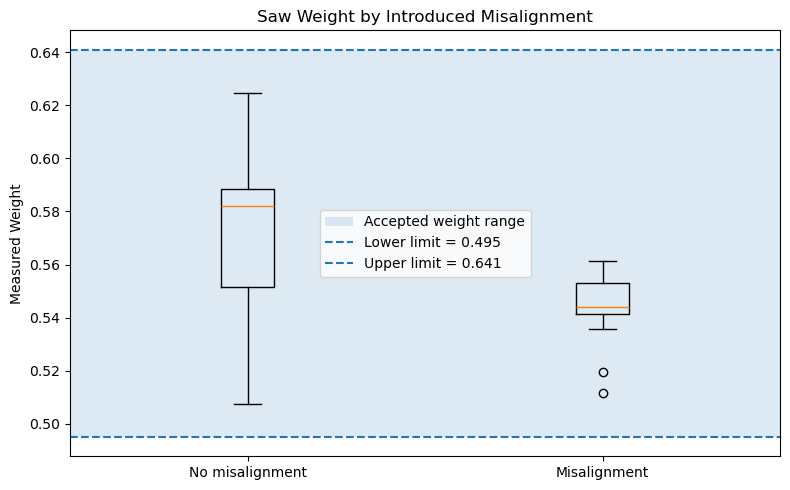

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/kaggle/working/saw_prepared/saw_product_metadata.csv")

normal = df.loc[
    df["misalignment_introduced"] == 0,
    "qc_weight"
].dropna()

misaligned = df.loc[
    df["misalignment_introduced"] == 1,
    "qc_weight"
].dropna()

LOWER_LIMIT = 0.495
UPPER_LIMIT = 0.641

plt.figure(figsize=(8, 5))

# Accepted QC region
plt.axhspan(
    LOWER_LIMIT,
    UPPER_LIMIT,
    alpha=0.15,
    label="Accepted weight range"
)

# Exact limits
plt.axhline(
    LOWER_LIMIT,
    linestyle="--",
    linewidth=1.5,
    label="Lower limit = 0.495"
)

plt.axhline(
    UPPER_LIMIT,
    linestyle="--",
    linewidth=1.5,
    label="Upper limit = 0.641"
)

plt.boxplot(
    [normal, misaligned],
    tick_labels=[
        "No misalignment",
        "Misalignment"
    ]
)

plt.title("Saw Weight by Introduced Misalignment")
plt.ylabel("Measured Weight")
plt.xlabel("")

plt.legend()

plt.tight_layout()
plt.show()

### Saw-stage anomaly ground-truth decision

**Problem:**
The saw dataset contains two different anomaly-related fields:

* `sawing_qc_data.csv → anomaly`
* `anomalous_parts_detailed.csv → anomaly_class`

At first, we assumed the saw QC anomaly flag meant the product failed the weight check. But this was inconsistent with the data: many rows marked `anomaly = 1` still had weights clearly inside the accepted saw QC range of **0.495–0.641**.

**Investigation:**
The official CiP-DMD documentation and metadata code show that these are two different concepts:

* **QC result:** based on the measured **weight**
* **Process anomaly:** based on whether a fault was deliberately introduced during manufacturing

For the saw stage, anomaly class 1 means the raw material was **intentionally misaligned**, causing the part to be cut too short.

The repository code also shows that the old anomaly field from the saw QC table was later replaced by the separate anomaly list when assigning process anomaly labels.

**Important finding:**
A product can therefore be:

```text
Saw misalignment introduced = YES
Weight QC = PASS
```

So the anomaly label is **not the same as QC failure**.

**Final decision:**
For the saw anomaly-detection model, use:

```text
Ground truth:
1 = anomaly_class == 1
    intentional saw misalignment introduced

0 = normal saw process
```

Use the weight QC result only as a separate outcome:

```text
weight_qc_pass =
0.495 <= weight <= 0.641
```

For the cleanest first experiment, compare only:

```text
Class 0 → normal
Class 1 → controlled saw misalignment
```

and exclude miscellaneous anomaly class 3 initially.

**Final ML task:**

> Use the saw machine time series to detect the intentionally introduced saw misalignment during the process, and separately evaluate whether conventional weight-based QC would have detected the same abnormal parts.


Lets corect preproces data

In [13]:
# ============================================================
# CiP-DMD — CORRECTED SAW DATA PREPARATION
# ------------------------------------------------------------
# NO signal processing
# NO resampling
# NO normalization
# NO feature extraction
#
# Only:
#   - organize product time series
#   - organize QC result
#   - create correct saw ground truth
#   - preserve legacy labels for auditing
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import h5py
import shutil

# ============================================================
# PATHS
# ============================================================

ROOT = Path("/kaggle/working/CiP-DMD")

OUT = Path("/kaggle/working/saw_clean")
OUT.mkdir(parents=True, exist_ok=True)

AUDIT = OUT / "audit"
AUDIT.mkdir(exist_ok=True)

H5_SOURCE = (
    ROOT /
    "process/sawing/data/sampled_saw_process_data.h5"
)

FIELD_SOURCE = (
    ROOT /
    "process/sawing/data/sawing_field_keys.csv"
)

# Proper transformed saw-quality file:
# id, measurement_timestamp, weight
QUALITY_SOURCE = (
    ROOT /
    "product/sawing/sawing_quality_data.csv"
)

# Old source table containing confusing anomaly field
LEGACY_SOURCE = (
    ROOT /
    "meta/data/sawing_qc_data.csv"
)

# Author-curated anomaly classes
ANOMALY_SOURCE = (
    ROOT /
    "meta/data/anomalous_parts_detailed.csv"
)


# ============================================================
# HELPER
# ============================================================

def clean_id(s):
    return (
        s.astype(str)
        .str.strip()
        .str.replace(".0", "", regex=False)
    )


print("=" * 90)
print("CORRECTED SAW DATA PREPARATION")
print("=" * 90)


# ============================================================
# 1. LOAD PROPER SAW QUALITY DATA
# ============================================================

quality = pd.read_csv(QUALITY_SOURCE)

quality.columns = [
    str(c).strip().lower()
    for c in quality.columns
]

# Support either "id" or "part_id"
if "id" in quality.columns:
    quality = quality.rename(columns={"id": "product_id"})
elif "part_id" in quality.columns:
    quality = quality.rename(columns={"part_id": "product_id"})

quality["product_id"] = clean_id(
    quality["product_id"]
)

# Rename weight clearly
quality = quality.rename(
    columns={"weight": "qc_weight"}
)

# Timestamp if available
if "measurement_timestamp" in quality.columns:

    quality["measurement_timestamp"] = pd.to_datetime(
        quality["measurement_timestamp"],
        errors="coerce",
        dayfirst=True
    )

# Count repeated QC measurements
qc_counts = (
    quality.groupby("product_id")
    .size()
    .rename("qc_record_count")
)

# Preserve duplicates for audit
duplicate_qc = quality[
    quality["product_id"].duplicated(keep=False)
].copy()

duplicate_qc.to_csv(
    AUDIT / "duplicate_qc_records.csv",
    index=False
)

# If a product was measured more than once,
# retain the latest measurement.
if "measurement_timestamp" in quality.columns:

    quality = (
        quality
        .sort_values("measurement_timestamp")
        .drop_duplicates(
            "product_id",
            keep="last"
        )
    )

else:

    quality = quality.drop_duplicates(
        "product_id",
        keep="last"
    )

quality = quality.merge(
    qc_counts,
    on="product_id",
    how="left"
)


# ============================================================
# 2. CREATE TRUE WEIGHT QC RESULT
# ============================================================

# Official CiP-DMD Saw QC bounds
LOWER_WEIGHT = 0.495
UPPER_WEIGHT = 0.641

quality["weight_qc_pass"] = (
    (quality["qc_weight"] > LOWER_WEIGHT) &
    (quality["qc_weight"] < UPPER_WEIGHT)
).astype(int)


# ============================================================
# 3. LOAD LEGACY ANOMALY FLAG
# ============================================================

legacy = pd.read_csv(
    LEGACY_SOURCE,
    sep=";"
)

legacy = legacy.dropna(
    axis=1,
    how="all"
)

legacy["part_id"] = clean_id(
    legacy["part_id"]
)

legacy = legacy.rename(
    columns={
        "part_id": "product_id",
        "anomaly": "legacy_source_anomaly_flag"
    }
)

legacy_counts = (
    legacy.groupby("product_id")
    .size()
    .rename("legacy_record_count")
)

# one row per product
legacy = (
    legacy
    .drop_duplicates(
        "product_id",
        keep="last"
    )
    .merge(
        legacy_counts,
        on="product_id",
        how="left"
    )
)


# ============================================================
# 4. LOAD AUTHOR ANOMALY CLASSES
# ============================================================

an = pd.read_csv(
    ANOMALY_SOURCE,
    sep=";"
)

an = an.dropna(
    axis=1,
    how="all"
)

an.columns = [
    str(c).strip()
    for c in an.columns
]

an["part_id"] = clean_id(
    an["part_id"]
)

# ------------------------------------------------------------
# Corrected anomaly class
#
# Prefer anomaly_classes where supplied,
# otherwise use anomaly_class.
# ------------------------------------------------------------

corrected = pd.Series(
    np.nan,
    index=an.index
)

if "anomaly_classes" in an.columns:

    corrected = pd.to_numeric(
        an["anomaly_classes"],
        errors="coerce"
    )

if "anomaly_class" in an.columns:

    original = pd.to_numeric(
        an["anomaly_class"],
        errors="coerce"
    )

    corrected = corrected.fillna(original)

an["fault_class"] = corrected

keep = [
    "part_id",
    "fault_class"
]

if "anomaly_description" in an.columns:
    keep.append("anomaly_description")

an = an[keep].rename(
    columns={"part_id": "product_id"}
)

an = an.drop_duplicates(
    "product_id",
    keep="last"
)


# ============================================================
# 5. READ RAW SAW TIME-SERIES INDEX
# ============================================================

records = []

with h5py.File(H5_SOURCE, "r") as hf:

    for pid in hf.keys():

        x = hf[pid]

        shape = x.shape

        records.append({
            "product_id": str(pid),
            "h5_key": str(pid),
            "raw_shape": str(shape),

            # Current sampled file is stored as
            # channels × time
            "n_channels": (
                shape[0]
                if len(shape) >= 1
                else np.nan
            ),

            "n_timesteps": (
                shape[1]
                if len(shape) >= 2
                else np.nan
            )
        })

ts = pd.DataFrame(records)


# ============================================================
# 6. BUILD ONE PRODUCT-LEVEL TABLE
# ============================================================

master = (
    ts
    .merge(
        quality,
        on="product_id",
        how="left"
    )
    .merge(
        legacy[
            [
                "product_id",
                "legacy_source_anomaly_flag",
                "legacy_record_count"
            ]
        ],
        on="product_id",
        how="left"
    )
    .merge(
        an,
        on="product_id",
        how="left"
    )
)


# ============================================================
# 7. CREATE AUTHORITATIVE FAULT CLASS
# ============================================================

# Products absent from the anomaly list
# are treated as class 0.
master["fault_class"] = (
    master["fault_class"]
    .fillna(0)
    .astype(int)
)


# ============================================================
# 8. CREATE CORRECT SAW GROUND TRUTH
# ============================================================

# ------------------------------------------------------------
# This is our PRIMARY ground truth.
#
# 1 = controlled saw misalignment introduced
# 0 = no controlled saw misalignment
# ------------------------------------------------------------

master["saw_misalignment_introduced"] = (
    master["fault_class"] == 1
).astype(int)


# ============================================================
# 9. DEFINE CLEAN FIRST EXPERIMENT
# ============================================================

# First experiment:
#
# class 0 = clean normal product
# class 1 = controlled saw misalignment
#
# Exclude:
# class 2 = milling anomaly introduced later
# class 3 = miscellaneous process error

master["clean_saw_task_eligible"] = (
    master["fault_class"].isin([0, 1])
)

master["saw_target_clean"] = np.where(
    master["clean_saw_task_eligible"],
    master["saw_misalignment_introduced"],
    np.nan
)


# ============================================================
# 10. LEGACY LABEL AGREEMENT
# ============================================================

master["legacy_label_matches_ground_truth"] = (
    master["legacy_source_anomaly_flag"]
    ==
    master["saw_misalignment_introduced"]
)

# Only meaningful where legacy flag exists
master.loc[
    master["legacy_source_anomaly_flag"].isna(),
    "legacy_label_matches_ground_truth"
] = np.nan


# ============================================================
# 11. DATA AVAILABILITY FLAGS
# ============================================================

master["has_timeseries"] = True

master["has_weight_qc"] = (
    master["qc_weight"].notna()
)


# ============================================================
# 12. CLEAN COLUMN ORDER
# ============================================================

columns = [
    "product_id",
    "h5_key",

    "raw_shape",
    "n_channels",
    "n_timesteps",

    "measurement_timestamp",
    "qc_weight",
    "weight_qc_pass",
    "qc_record_count",

    "fault_class",
    "saw_misalignment_introduced",
    "saw_target_clean",
    "clean_saw_task_eligible",

    "anomaly_description",

    # audit only
    "legacy_source_anomaly_flag",
    "legacy_label_matches_ground_truth",
    "legacy_record_count",

    "has_timeseries",
    "has_weight_qc"
]

columns = [
    c for c in columns
    if c in master.columns
]

master = (
    master[columns]
    .sort_values("product_id")
    .reset_index(drop=True)
)


# ============================================================
# 13. SAVE RAW TIME SERIES WITHOUT MODIFYING IT
# ============================================================

H5_OUT = OUT / "saw_timeseries_raw.h5"

if not H5_OUT.exists():

    shutil.copy2(
        H5_SOURCE,
        H5_OUT
    )


# Copy signal-name/key file
if FIELD_SOURCE.exists():

    shutil.copy2(
        FIELD_SOURCE,
        OUT / "saw_field_keys.csv"
    )


# ============================================================
# 14. SAVE PRODUCT METADATA
# ============================================================

master.to_csv(
    OUT / "saw_product_metadata.csv",
    index=False
)


# ============================================================
# 15. SAVE CLEAN MODEL SUBSET
# ============================================================

clean_model_metadata = master[
    master["clean_saw_task_eligible"]
].copy()

clean_model_metadata.to_csv(
    OUT / "saw_clean_model_metadata.csv",
    index=False
)


# ============================================================
# 16. SAVE LABEL DISAGREEMENTS
# ============================================================

mismatches = master[
    master["legacy_label_matches_ground_truth"] == False
].copy()

mismatches.to_csv(
    AUDIT / "legacy_label_mismatches.csv",
    index=False
)


# ============================================================
# 17. README
# ============================================================

readme = """
CiP-DMD — Corrected Saw Dataset
================================

No signal processing has been performed.

PRIMARY FILES
-------------

saw_timeseries_raw.h5
    Original sampled Saw process time series.
    No normalization, filtering, resampling, or feature extraction.

saw_field_keys.csv
    Signal/channel information.

saw_product_metadata.csv
    All products and all available labels/outcomes.

saw_clean_model_metadata.csv
    Clean first Saw modelling experiment:
        class 0 = normal process
        class 1 = controlled Saw misalignment

    Fault classes 2 and 3 are excluded from this first model.

LABEL DEFINITIONS
-----------------

fault_class

0 = no listed anomaly
1 = intentionally introduced Saw misalignment
2 = intentionally introduced Milling clamping fault
3 = miscellaneous process error


saw_misalignment_introduced

1 = controlled Saw misalignment was introduced
0 = controlled Saw misalignment was not introduced

This is the primary Saw-stage ground truth.


weight_qc_pass

Calculated independently from measured Saw weight:

    0.495 < weight < 0.641

This is a QC outcome and is NOT the process-anomaly label.


legacy_source_anomaly_flag

Old anomaly field retained only for auditing.

It is NOT used as the model ground truth because its
provenance is unclear and it disagrees with the final
author-curated anomaly metadata for some products.


FIRST ML TASK
-------------

Input:
    Saw machine time series

Target:
    saw_target_clean

Question:
    Can machine signals identify the controlled Saw
    misalignment during processing?

Secondary analysis:
    Did conventional weight QC detect the same products?
"""

(OUT / "README.txt").write_text(readme)


# ============================================================
# 18. FINAL VALIDATION
# ============================================================

print("\n" + "=" * 90)
print("FINAL CORRECTED SAW DATASET")
print("=" * 90)

print("\nTotal time-series products:")
print(len(master))

print("\nFault classes:")
print(
    master["fault_class"]
    .value_counts()
    .sort_index()
)

print("\nControlled Saw misalignment:")
print(
    master[
        "saw_misalignment_introduced"
    ].value_counts()
)

print("\nClean first-model dataset:")
print(
    clean_model_metadata[
        "saw_target_clean"
    ].value_counts()
)

print("\nWeight QC:")
print(
    master[
        "weight_qc_pass"
    ].value_counts(
        dropna=False
    )
)

print("\nMisalignment vs weight QC:")
print(
    pd.crosstab(
        master["saw_misalignment_introduced"],
        master["weight_qc_pass"],
        rownames=["Saw misalignment"],
        colnames=["Weight QC pass"]
    )
)

print("\nLegacy label vs final ground truth:")
print(
    pd.crosstab(
        master["saw_misalignment_introduced"],
        master["legacy_source_anomaly_flag"],
        rownames=["Final Saw ground truth"],
        colnames=["Legacy source flag"]
    )
)

print("\nDuplicate QC products:")
print(
    (master["qc_record_count"] > 1).sum()
)

print("\nMissing QC:")
print(
    master["qc_weight"]
    .isna()
    .sum()
)

print("\nSaved to:")
print(OUT)

print("""
saw_clean/
│
├── saw_timeseries_raw.h5
├── saw_field_keys.csv
├── saw_product_metadata.csv
├── saw_clean_model_metadata.csv
├── README.txt
│
└── audit/
    ├── duplicate_qc_records.csv
    └── legacy_label_mismatches.csv
""")

CORRECTED SAW DATA PREPARATION


C:\Users\Savandi\AppData\Local\Temp\ipykernel_34412\1731261930.py:422: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  master.loc[



FINAL CORRECTED SAW DATASET

Total time-series products:
984

Fault classes:
fault_class
0    834
1     99
2     41
3     10
Name: count, dtype: int64

Controlled Saw misalignment:
saw_misalignment_introduced
0    885
1     99
Name: count, dtype: int64

Clean first-model dataset:
saw_target_clean
0.0    834
1.0     99
Name: count, dtype: int64

Weight QC:
weight_qc_pass
1    984
Name: count, dtype: int64

Misalignment vs weight QC:
Weight QC pass      1
Saw misalignment     
0                 885
1                  99

Legacy label vs final ground truth:
Legacy source flag        0   1
Final Saw ground truth         
0                       881   4
1                        22  77

Duplicate QC products:
1

Missing QC:
0

Saved to:
\kaggle\working\saw_clean

saw_clean/
│
├── saw_timeseries_raw.h5
├── saw_field_keys.csv
├── saw_product_metadata.csv
├── saw_clean_model_metadata.csv
├── README.txt
│
└── audit/
    ├── duplicate_qc_records.csv
    └── legacy_label_mismatches.csv





## lets do visualizations on this new data 

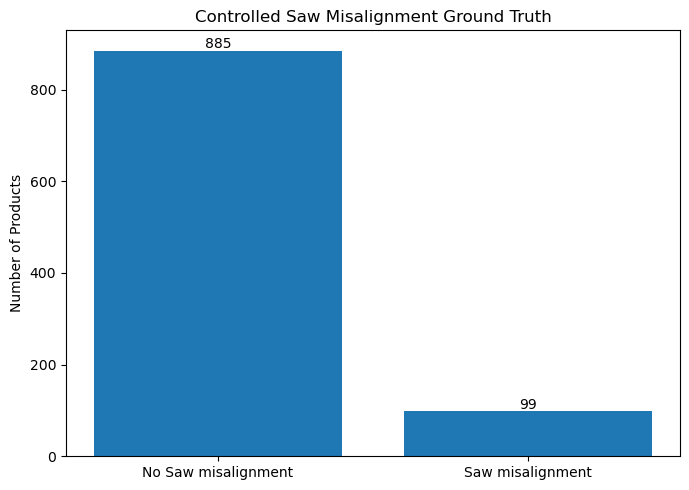

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    "/kaggle/working/saw_clean/saw_product_metadata.csv"
)

counts = (
    df["saw_misalignment_introduced"]
    .value_counts()
    .sort_index()
)

labels = ["No Saw misalignment", "Saw misalignment"]

plt.figure(figsize=(7,5))
plt.bar(labels, counts.values)

plt.title("Controlled Saw Misalignment Ground Truth")
plt.ylabel("Number of Products")

for i, v in enumerate(counts.values):
    plt.text(i, v + 5, str(v), ha="center")

plt.tight_layout()
plt.show()

There is class imbalance so need use F1 score

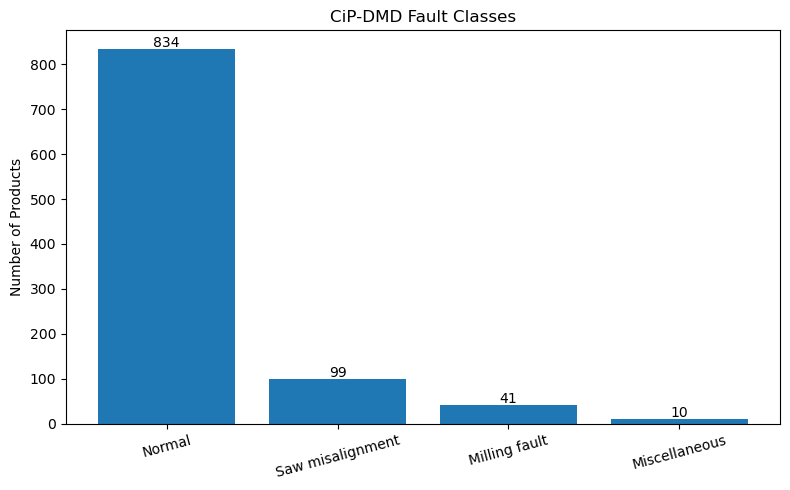

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    "/kaggle/working/saw_clean/saw_product_metadata.csv"
)

counts = (
    df["fault_class"]
    .value_counts()
    .sort_index()
)

labels = {
    0: "Normal",
    1: "Saw misalignment",
    2: "Milling fault",
    3: "Miscellaneous"
}

names = [labels.get(i, str(i)) for i in counts.index]

plt.figure(figsize=(8,5))
plt.bar(names, counts.values)

plt.title("CiP-DMD Fault Classes")
plt.ylabel("Number of Products")
plt.xticks(rotation=15)

for i, v in enumerate(counts.values):
    plt.text(i, v + 5, str(v), ha="center")

plt.tight_layout()
plt.show()

We only need saw misalignment oft first one.

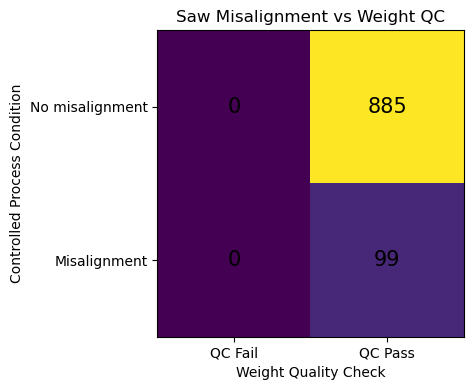

weight_qc_pass               0    1
saw_misalignment_introduced        
0                            0  885
1                            0   99


In [16]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    "/kaggle/working/saw_clean/saw_product_metadata.csv"
)

table = pd.crosstab(
    df["saw_misalignment_introduced"],
    df["weight_qc_pass"]
)

table = table.reindex(
    index=[0,1],
    columns=[0,1],
    fill_value=0
)

fig, ax = plt.subplots(figsize=(6,4))

ax.imshow(table.values)

ax.set_xticks([0,1])
ax.set_xticklabels(["QC Fail", "QC Pass"])

ax.set_yticks([0,1])
ax.set_yticklabels([
    "No misalignment",
    "Misalignment"
])

for i in range(2):
    for j in range(2):
        ax.text(
            j,
            i,
            int(table.iloc[i,j]),
            ha="center",
            va="center",
            fontsize=15
        )

ax.set_title("Saw Misalignment vs Weight QC")
ax.set_xlabel("Weight Quality Check")
ax.set_ylabel("Controlled Process Condition")

plt.tight_layout()
plt.show()

print(table)

So here we nont have much to get from Weight quality checkimport pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    "/kaggle/working/saw_clean/saw_product_metadata.csv"
)

normal = df.loc[
    df["saw_misalignment_introduced"] == 0,
    "qc_weight"
].dropna()

misaligned = df.loc[
    df["saw_misalignment_introduced"] == 1,
    "qc_weight"
].dropna()

LOWER = 0.495
UPPER = 0.641

plt.figure(figsize=(8,5))

plt.axhspan(
    LOWER,
    UPPER,
    alpha=0.12,
    label="Accepted QC range"
)

plt.axhline(
    LOWER,
    linestyle="--",
    label="Lower limit = 0.495"
)

plt.axhline(
    UPPER,
    linestyle="--",
    label="Upper limit = 0.641"
)

plt.boxplot(
    [normal, misaligned],
    tick_labels=[
        "No misalignment",
        "Saw misalignment"
    ]
)

plt.title("Saw Weight vs Controlled Misalignment")
plt.ylabel("Measured Weight")
plt.legend()

plt.tight_layout()
plt.show()

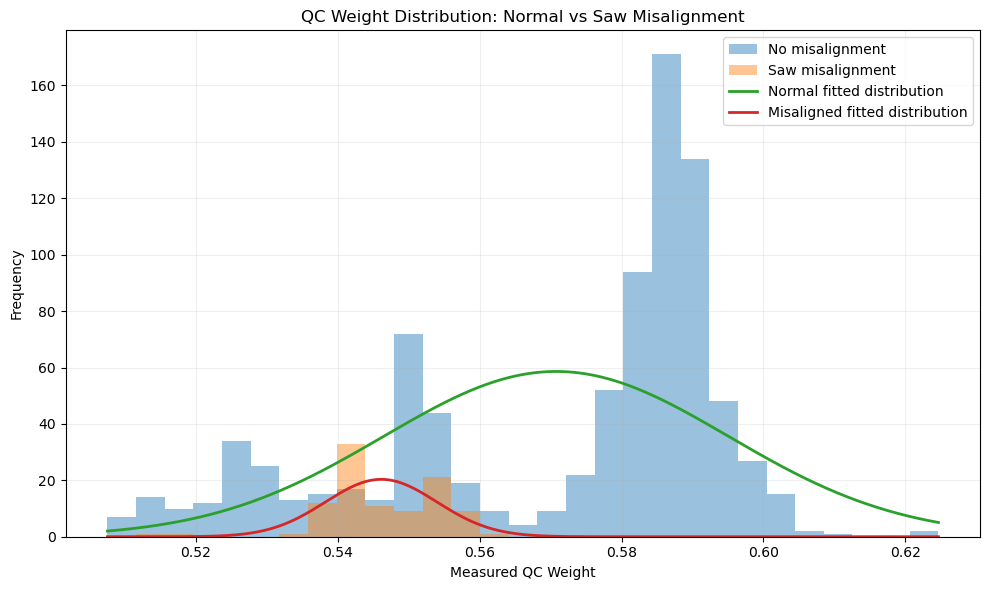

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Load data
df = pd.read_csv(
    "/kaggle/working/saw_clean/saw_product_metadata.csv"
)

normal = df.loc[
    df["saw_misalignment_introduced"] == 0,
    "qc_weight"
].dropna()

misaligned = df.loc[
    df["saw_misalignment_introduced"] == 1,
    "qc_weight"
].dropna()

LOWER = 0.495
UPPER = 0.641

# Same bins for both groups
bins = np.linspace(
    min(normal.min(), misaligned.min()),
    max(normal.max(), misaligned.max()),
    30
)

plt.figure(figsize=(10, 6))

# --------------------------------------------------
# 1. Frequency histograms
# --------------------------------------------------
plt.hist(
    normal,
    bins=bins,
    alpha=0.45,
    label="No misalignment"
)

plt.hist(
    misaligned,
    bins=bins,
    alpha=0.45,
    label="Saw misalignment"
)

# --------------------------------------------------
# 2. Normal distribution curves
#    scaled to histogram frequency
# --------------------------------------------------
x = np.linspace(bins[0], bins[-1], 500)

bin_width = bins[1] - bins[0]

# Normal group
mu_normal = normal.mean()
std_normal = normal.std()

normal_curve = (
    norm.pdf(x, mu_normal, std_normal)
    * len(normal)
    * bin_width
)

plt.plot(
    x,
    normal_curve,
    linewidth=2,
    label="Normal fitted distribution"
)

# Misaligned group
mu_misaligned = misaligned.mean()
std_misaligned = misaligned.std()

misaligned_curve = (
    norm.pdf(x, mu_misaligned, std_misaligned)
    * len(misaligned)
    * bin_width
)

plt.plot(
    x,
    misaligned_curve,
    linewidth=2,
    label="Misaligned fitted distribution"
)




# --------------------------------------------------
# Labels
# --------------------------------------------------
plt.title("QC Weight Distribution: Normal vs Saw Misalignment")
plt.xlabel("Measured QC Weight")
plt.ylabel("Frequency")

plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

so weight will not help at seperatinng two classes

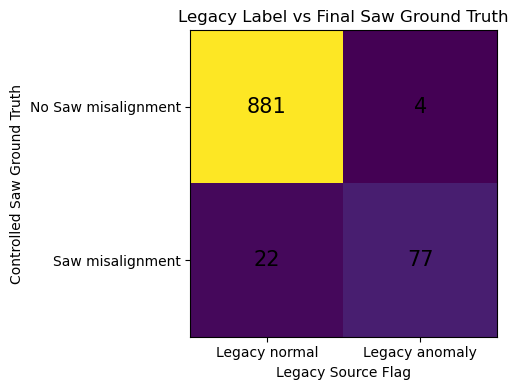

legacy_source_anomaly_flag     0   1
saw_misalignment_introduced         
0                            881   4
1                             22  77


In [18]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    "/kaggle/working/saw_clean/saw_product_metadata.csv"
)

temp = df.dropna(
    subset=["legacy_source_anomaly_flag"]
)

table = pd.crosstab(
    temp["saw_misalignment_introduced"],
    temp["legacy_source_anomaly_flag"]
)

table = table.reindex(
    index=[0,1],
    columns=[0,1],
    fill_value=0
)

fig, ax = plt.subplots(figsize=(6,4))

ax.imshow(table.values)

ax.set_xticks([0,1])
ax.set_xticklabels([
    "Legacy normal",
    "Legacy anomaly"
])

ax.set_yticks([0,1])
ax.set_yticklabels([
    "No Saw misalignment",
    "Saw misalignment"
])

for i in range(2):
    for j in range(2):
        ax.text(
            j,
            i,
            int(table.iloc[i,j]),
            ha="center",
            va="center",
            fontsize=15
        )

ax.set_title("Legacy Label vs Final Saw Ground Truth")
ax.set_xlabel("Legacy Source Flag")
ax.set_ylabel("Controlled Saw Ground Truth")

plt.tight_layout()
plt.show()

print(table)

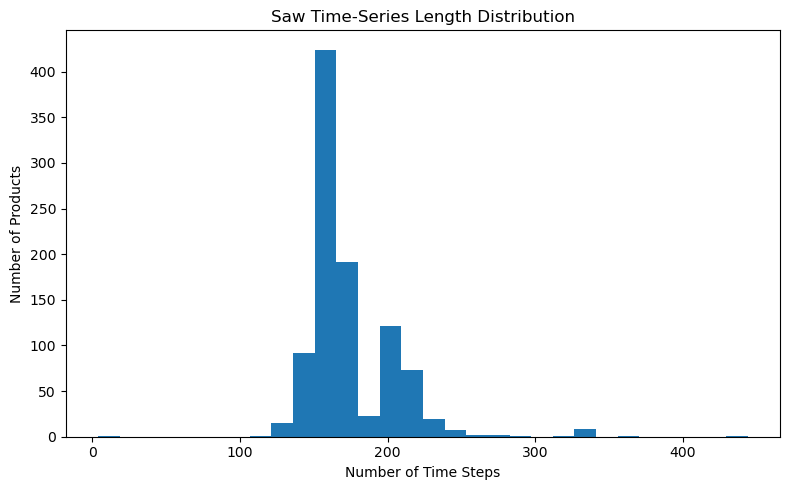

count    984.000000
mean     175.035569
std       31.884005
min        4.000000
25%      160.000000
50%      165.000000
75%      189.000000
max      444.000000
Name: n_timesteps, dtype: float64


In [19]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    "/kaggle/working/saw_clean/saw_product_metadata.csv"
)

plt.figure(figsize=(8,5))

plt.hist(
    df["n_timesteps"].dropna(),
    bins=30
)

plt.title("Saw Time-Series Length Distribution")
plt.xlabel("Number of Time Steps")
plt.ylabel("Number of Products")

plt.tight_layout()
plt.show()

print(df["n_timesteps"].describe())

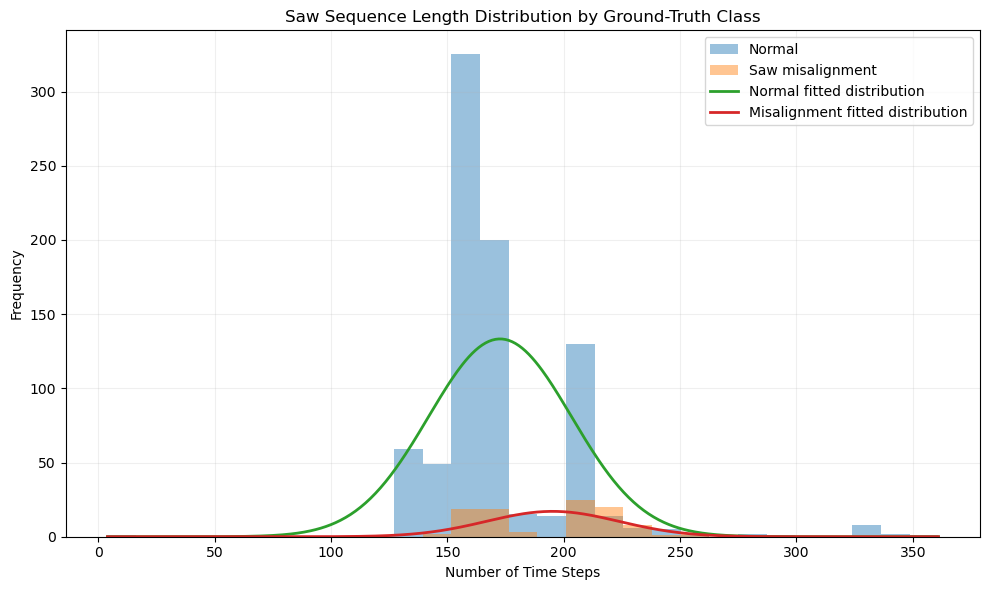

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Load data
df = pd.read_csv(
    "/kaggle/working/saw_clean/saw_clean_model_metadata.csv"
)

normal = df.loc[
    df["saw_target_clean"] == 0,
    "n_timesteps"
].dropna()

misaligned = df.loc[
    df["saw_target_clean"] == 1,
    "n_timesteps"
].dropna()

# Common bins for fair comparison
bins = np.linspace(
    min(normal.min(), misaligned.min()),
    max(normal.max(), misaligned.max()),
    30
)

plt.figure(figsize=(10, 6))

# --------------------------------------------------
# 1. Frequency histograms
# --------------------------------------------------
plt.hist(
    normal,
    bins=bins,
    alpha=0.45,
    label="Normal"
)

plt.hist(
    misaligned,
    bins=bins,
    alpha=0.45,
    label="Saw misalignment"
)

# --------------------------------------------------
# 2. Fitted normal distribution curves
# --------------------------------------------------
x = np.linspace(bins[0], bins[-1], 500)
bin_width = bins[1] - bins[0]

# Normal class
mu_normal = normal.mean()
std_normal = normal.std()

normal_curve = (
    norm.pdf(x, mu_normal, std_normal)
    * len(normal)
    * bin_width
)

plt.plot(
    x,
    normal_curve,
    linewidth=2,
    label="Normal fitted distribution"
)

# Misalignment class
mu_misaligned = misaligned.mean()
std_misaligned = misaligned.std()

misaligned_curve = (
    norm.pdf(x, mu_misaligned, std_misaligned)
    * len(misaligned)
    * bin_width
)

plt.plot(
    x,
    misaligned_curve,
    linewidth=2,
    label="Misalignment fitted distribution"
)

# --------------------------------------------------
# Labels
# --------------------------------------------------
plt.title("Saw Sequence Length Distribution by Ground-Truth Class")
plt.xlabel("Number of Time Steps")
plt.ylabel("Frequency")

plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

So sequence is also not held to predict that

visualize the raw time series itself

In [21]:
import pandas as pd

path = "/kaggle/working/saw_clean/saw_field_keys.csv"

keys = pd.read_csv(
    path,
    header=None,
    names=["signal_name"]
)

# H5 row 0 is timestamp, so signals start from row 1
keys["h5_row"] = range(1, len(keys) + 1)

display(keys)

print("Number of machine signals:", len(keys))

,signal_name,h5_row
0,CPU_Kuehler_Temp,1
1,CPU_Temp,2
2,CutCounter,3
3,CutTime,4
4,FFT_Anforderung,5
5,FlatstreamCutCounter,6
6,FlatstreamDone,7
7,FsMode_1Raw_2FftRaw_3FttHK,8
8,HebenAktiv,9
9,MotorAn,10


Number of machine signals: 44


Letd visualize same raw machine signal across several normal cuts and several intentionally misaligned cuts


lets do featrue extraction on thi s time series full one

In [22]:
# ============================================================
# CiP-DMD SAW — FULL TIME-SERIES FEATURE EXTRACTION
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import h5py

from scipy.stats import skew, kurtosis


# ============================================================
# PATHS
# ============================================================

ROOT = Path("/kaggle/working/saw_clean")

H5_PATH = ROOT / "saw_timeseries_raw.h5"
META_PATH = ROOT / "saw_product_metadata.csv"
KEYS_PATH = ROOT / "saw_field_keys.csv"

OUT_PATH = ROOT / "saw_full_features.csv"


# ============================================================
# LOAD METADATA
# ============================================================

meta = pd.read_csv(META_PATH)

meta["product_id"] = (
    meta["product_id"]
    .astype(str)
    .str.replace(".0", "", regex=False)
)


# ============================================================
# LOAD SIGNAL NAMES
# ============================================================

signal_names = (
    pd.read_csv(
        KEYS_PATH,
        header=None,
        names=["signal_name"]
    )["signal_name"]
    .astype(str)
    .str.strip()
    .tolist()
)

print("Signals:", len(signal_names))

assert len(signal_names) == 44


# ============================================================
# SAFE STATISTICAL HELPERS
# ============================================================

def safe_skew(x):

    if len(x) < 3:
        return np.nan

    if np.nanstd(x) == 0:
        return 0.0

    return skew(
        x,
        bias=False,
        nan_policy="omit"
    )


def safe_kurtosis(x):

    if len(x) < 4:
        return np.nan

    if np.nanstd(x) == 0:
        return 0.0

    return kurtosis(
        x,
        fisher=True,
        bias=False,
        nan_policy="omit"
    )


def autocorr_lag1(x):

    if len(x) < 3:
        return np.nan

    x1 = x[:-1]
    x2 = x[1:]

    if np.std(x1) == 0 or np.std(x2) == 0:
        return 0.0

    return np.corrcoef(
        x1,
        x2
    )[0, 1]


# ============================================================
# FREQUENCY FEATURES
# ============================================================

def frequency_features(x, sampling_rate):

    result = {
        "dominant_freq": np.nan,
        "spectral_centroid": np.nan,
        "spectral_entropy": np.nan
    }

    if len(x) < 8:
        return result

    if not np.isfinite(sampling_rate):
        return result

    if sampling_rate <= 0:
        return result

    # Remove DC component
    x_centered = x - np.mean(x)

    if np.std(x_centered) == 0:
        return {
            "dominant_freq": 0.0,
            "spectral_centroid": 0.0,
            "spectral_entropy": 0.0
        }

    spectrum = np.fft.rfft(x_centered)

    power = np.abs(spectrum) ** 2

    freqs = np.fft.rfftfreq(
        len(x_centered),
        d=1.0 / sampling_rate
    )

    # remove DC
    if len(power) > 1:

        power = power[1:]
        freqs = freqs[1:]

    if len(power) == 0:
        return result

    total_power = power.sum()

    if total_power <= 0:
        return result

    # dominant frequency
    dominant_idx = np.argmax(power)

    dominant_freq = freqs[dominant_idx]

    # spectral centroid
    spectral_centroid = (
        np.sum(freqs * power)
        / total_power
    )

    # normalized spectral entropy
    p = power / total_power

    p = p[p > 0]

    entropy = -np.sum(
        p * np.log2(p)
    )

    if len(power) > 1:

        entropy = entropy / np.log2(
            len(power)
        )

    else:

        entropy = 0.0

    return {
        "dominant_freq": dominant_freq,
        "spectral_centroid": spectral_centroid,
        "spectral_entropy": entropy
    }


# ============================================================
# FEATURE EXTRACTION FOR ONE SIGNAL
# ============================================================

def extract_signal_features(x, time):

    x = np.asarray(
        x,
        dtype=float
    )

    time = np.asarray(
        time,
        dtype=float
    )

    # --------------------------------------------------------
    # remove invalid points
    # --------------------------------------------------------

    valid = (
        np.isfinite(x)
        &
        np.isfinite(time)
    )

    x = x[valid]
    time = time[valid]

    if len(x) == 0:

        return {}

    # --------------------------------------------------------
    # Sampling rate
    # --------------------------------------------------------

    dt = np.diff(time)

    dt = dt[
        np.isfinite(dt)
        &
        (dt > 0)
    ]

    if len(dt) > 0:

        median_dt = np.median(dt)

        sampling_rate = (
            1 / median_dt
            if median_dt > 0
            else np.nan
        )

    else:

        sampling_rate = np.nan


    # --------------------------------------------------------
    # Difference features
    # --------------------------------------------------------

    dx = np.diff(x)

    if len(dx) > 0:

        mean_abs_change = np.mean(
            np.abs(dx)
        )

        std_change = np.std(dx)

        max_abs_change = np.max(
            np.abs(dx)
        )

    else:

        mean_abs_change = 0.0
        std_change = 0.0
        max_abs_change = 0.0


    # --------------------------------------------------------
    # Trend
    # --------------------------------------------------------

    if len(x) >= 2:

        relative_time = (
            time - time[0]
        )

        if np.ptp(relative_time) > 0:

            slope = np.polyfit(
                relative_time,
                x,
                1
            )[0]

        else:

            slope = 0.0

    else:

        slope = 0.0


    # --------------------------------------------------------
    # Quantiles
    # --------------------------------------------------------

    q05, q25, q50, q75, q95 = (
        np.percentile(
            x,
            [5, 25, 50, 75, 95]
        )
    )


    # --------------------------------------------------------
    # Basic features
    # --------------------------------------------------------

    features = {

        "mean":
            np.mean(x),

        "std":
            np.std(x),

        "min":
            np.min(x),

        "max":
            np.max(x),

        "median":
            q50,

        "q05":
            q05,

        "q25":
            q25,

        "q75":
            q75,

        "q95":
            q95,

        "iqr":
            q75 - q25,

        "range":
            np.max(x) - np.min(x),

        "rms":
            np.sqrt(
                np.mean(x ** 2)
            ),

        "energy":
            np.mean(x ** 2),

        "skew":
            safe_skew(x),

        "kurtosis":
            safe_kurtosis(x),

        "start":
            x[0],

        "end":
            x[-1],

        "delta":
            x[-1] - x[0],

        "mean_abs_change":
            mean_abs_change,

        "std_change":
            std_change,

        "max_abs_change":
            max_abs_change,

        "slope":
            slope,

        "autocorr1":
            autocorr_lag1(x),

        "unique_values":
            len(np.unique(x))
    }


    # --------------------------------------------------------
    # Frequency-domain features
    # --------------------------------------------------------

    freq_features = frequency_features(
        x,
        sampling_rate
    )

    features.update(
        freq_features
    )

    return features


# ============================================================
# EXTRACT FEATURES FOR EVERY PRODUCT
# ============================================================

all_rows = []

with h5py.File(
    H5_PATH,
    "r"
) as hf:

    product_ids = list(
        hf.keys()
    )

    total = len(product_ids)

    for number, pid in enumerate(
        product_ids,
        start=1
    ):

        raw = hf[pid][:]

        # -----------------------------------------------
        # Expected shape:
        #
        # row 0  = timestamp
        # rows 1-44 = machine signals
        # -----------------------------------------------

        if raw.ndim != 2:

            print(
                "Skipping",
                pid,
                "unexpected shape:",
                raw.shape
            )

            continue

        if raw.shape[0] != 45:

            print(
                "Warning:",
                pid,
                "shape:",
                raw.shape
            )


        timestamp = raw[0]

        elapsed_time = (
            timestamp - timestamp[0]
        )


        # -----------------------------------------------
        # Product-level diagnostic features
        # -----------------------------------------------

        row = {
            "product_id": str(pid),

            "sequence_length":
                raw.shape[1],

            "sequence_duration_sec":
                (
                    elapsed_time[-1]
                    if len(elapsed_time)
                    else np.nan
                )
        }


        # -----------------------------------------------
        # Extract features for all 44 signals
        # -----------------------------------------------

        for signal_idx, signal_name in enumerate(
            signal_names,
            start=1
        ):

            if signal_idx >= raw.shape[0]:
                continue

            signal = raw[
                signal_idx
            ]

            features = (
                extract_signal_features(
                    signal,
                    timestamp
                )
            )

            for feature_name, value in features.items():

                column_name = (
                    f"{signal_name}__{feature_name}"
                )

                row[column_name] = value


        all_rows.append(row)


        if (
            number % 100 == 0
            or number == total
        ):

            print(
                f"{number}/{total} products completed"
            )


# ============================================================
# CREATE FEATURE TABLE
# ============================================================

features_df = pd.DataFrame(
    all_rows
)


# ============================================================
# ADD LABELS / OUTCOMES
#
# These are appended AFTER extraction.
# They were NOT used to calculate features.
# ============================================================

label_columns = [
    "product_id",
    "fault_class",
    "saw_misalignment_introduced",
    "saw_target_clean",
    "clean_saw_task_eligible",
    "qc_weight",
    "weight_qc_pass"
]

label_columns = [
    c
    for c in label_columns
    if c in meta.columns
]

features_df = features_df.merge(
    meta[label_columns],
    on="product_id",
    how="left"
)


# ============================================================
# CLEAN INFINITE VALUES
# ============================================================

features_df = features_df.replace(
    [np.inf, -np.inf],
    np.nan
)


# ============================================================
# SAVE
# ============================================================

features_df.to_csv(
    OUT_PATH,
    index=False
)


# ============================================================
# SUMMARY
# ============================================================

feature_columns = [
    c
    for c in features_df.columns
    if "__" in c
]

print("\n" + "=" * 80)
print("FEATURE EXTRACTION COMPLETE")
print("=" * 80)

print(
    "Products:",
    len(features_df)
)

print(
    "Machine signals:",
    len(signal_names)
)

print(
    "Extracted signal features:",
    len(feature_columns)
)

print(
    "Total columns:",
    features_df.shape[1]
)

print(
    "Missing feature values:",
    features_df[
        feature_columns
    ].isna().sum().sum()
)

print(
    "\nSaved to:"
)

print(
    OUT_PATH
)

print(
    "\nExample feature columns:"
)

for c in feature_columns[:30]:
    print(c)

display(
    features_df.head()
)

Signals: 44
100/984 products completed
200/984 products completed
300/984 products completed
400/984 products completed
500/984 products completed
600/984 products completed
700/984 products completed
800/984 products completed
900/984 products completed
984/984 products completed

FEATURE EXTRACTION COMPLETE
Products: 984
Machine signals: 44
Extracted signal features: 1188
Total columns: 1197
Missing feature values: 132

Saved to:
\kaggle\working\saw_clean\saw_full_features.csv

Example feature columns:
CPU_Kuehler_Temp__mean
CPU_Kuehler_Temp__std
CPU_Kuehler_Temp__min
CPU_Kuehler_Temp__max
CPU_Kuehler_Temp__median
CPU_Kuehler_Temp__q05
CPU_Kuehler_Temp__q25
CPU_Kuehler_Temp__q75
CPU_Kuehler_Temp__q95
CPU_Kuehler_Temp__iqr
CPU_Kuehler_Temp__range
CPU_Kuehler_Temp__rms
CPU_Kuehler_Temp__energy
CPU_Kuehler_Temp__skew
CPU_Kuehler_Temp__kurtosis
CPU_Kuehler_Temp__start
CPU_Kuehler_Temp__end
CPU_Kuehler_Temp__delta
CPU_Kuehler_Temp__mean_abs_change
CPU_Kuehler_Temp__std_change
CPU_Kuehler_

,product_id,sequence_length,sequence_duration_sec,CPU_Kuehler_Temp__mean,CPU_Kuehler_Temp__std,CPU_Kuehler_Temp__min,CPU_Kuehler_Temp__max,CPU_Kuehler_Temp__median,CPU_Kuehler_Temp__q05,CPU_Kuehler_Temp__q25,...,vVorschub__unique_values,vVorschub__dominant_freq,vVorschub__spectral_centroid,vVorschub__spectral_entropy,fault_class,saw_misalignment_introduced,saw_target_clean,clean_saw_task_eligible,qc_weight,weight_qc_pass
0,100101,220,109.0,635.231818,1.270607,633.0,638.0,635.0,633.0,635.0,...,46,0.009091,0.103079,0.836354,0,0,0.0,True,0.536389,1
1,100102,207,103.0,636.009662,0.851202,635.0,638.0,636.0,635.0,635.0,...,46,0.009662,0.046938,0.659056,0,0,0.0,True,0.533120,1
2,100103,206,102.0,636.024272,0.466752,635.0,637.0,636.0,635.0,636.0,...,49,0.009709,0.052563,0.677647,0,0,0.0,True,0.529679,1
3,100104,200,99.0,637.000000,0.000000,637.0,637.0,637.0,637.0,637.0,...,42,0.010000,0.064312,0.737480,0,0,0.0,True,0.533523,1
4,100201,209,104.0,636.956938,0.837553,635.0,638.0,637.0,635.0,637.0,...,42,0.009569,0.064008,0.694111,0,0,0.0,True,0.530947,1


Need to remove and split data, for first baseline, lets use this pipeline

Full-sequence features
        ↓
Keep only class 0 vs class 1
        ↓
Split by PRODUCTION DAY
        ↓
Remove missing / constant features
        ↓
Remove highly correlated features
        ↓
Rank remaining features using training data only
        ↓
Keep top 50
        ↓
Random Forest baseline
        ↓
Compare against ordinary random split

we took the full set of extracted Saw time-series features and prepared them for a fair first ML test. First, we kept only the clean Saw problem: normal products (class 0) versus intentionally misaligned Saw products (class 1). Then we used only the sensor-derived features and excluded things like product ID, QC weight, sequence length, and labels from the model input. After that, we cleaned the features using the training data only: removed features with too many missing values, removed constant or almost-constant features, filled missing values using training medians, removed highly correlated duplicate-like features, and ranked the remaining features using mutual information. We then kept the top 50 features and trained a Random Forest classifier.

The most important part is that we tested the model in two different ways. One was a normal random train/test split, and the other grouped products by production day, so products from the same day would not be split across train and test. This helps us check whether the model is learning a real Saw-misalignment pattern or just memorizing production-batch differences. Finally, the code reported metrics such as precision, recall, F1, balanced accuracy, ROC-AUC, and PR-AUC, and saved the selected features and feature ranking for later analysis.

In [23]:
# ============================================================
# CiP-DMD SAW — FEATURE CLEANING + SELECTION + BASELINE
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.model_selection import (
    StratifiedGroupKFold,
    train_test_split
)

from sklearn.feature_selection import mutual_info_classif

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score
)


# ============================================================
# PATHS
# ============================================================

ROOT = Path("/kaggle/working/saw_clean")

FEATURE_PATH = ROOT / "saw_full_features.csv"
META_PATH = ROOT / "saw_product_metadata.csv"


# ============================================================
# LOAD DATA
# ============================================================

df = pd.read_csv(FEATURE_PATH)
meta = pd.read_csv(META_PATH)

df["product_id"] = (
    df["product_id"]
    .astype(str)
    .str.replace(".0", "", regex=False)
)

meta["product_id"] = (
    meta["product_id"]
    .astype(str)
    .str.replace(".0", "", regex=False)
)


# ============================================================
# ADD PRODUCTION DATE
# ============================================================

if "measurement_timestamp" in meta.columns:

    meta["measurement_timestamp"] = pd.to_datetime(
        meta["measurement_timestamp"],
        errors="coerce"
    )

    meta["production_day"] = (
        meta["measurement_timestamp"]
        .dt.date
        .astype(str)
    )

    df = df.merge(
        meta[
            [
                "product_id",
                "production_day"
            ]
        ],
        on="product_id",
        how="left"
    )

else:
    raise ValueError(
        "measurement_timestamp missing from metadata."
    )


# ============================================================
# USE ONLY CLEAN SAW TASK
#
# class 0 = normal
# class 1 = controlled saw misalignment
# ============================================================

df = df[
    df["clean_saw_task_eligible"] == True
].copy()

df = df[
    df["saw_target_clean"].notna()
].copy()

df["target"] = (
    df["saw_target_clean"]
    .astype(int)
)


# ============================================================
# FEATURE COLUMNS
#
# Only extracted machine-signal features.
#
# Do NOT use:
#   weight
#   QC
#   product ID
#   sequence duration
#   sequence length
#   labels
# ============================================================

feature_cols = [
    c for c in df.columns
    if "__" in c
]

X = df[feature_cols].copy()

y = df["target"].copy()

groups = df["production_day"].copy()


print("=" * 80)
print("DATASET")
print("=" * 80)

print("Products:", len(df))
print("Raw extracted features:", len(feature_cols))

print("\nTarget:")
print(y.value_counts())

print("\nProduction days:")
print(groups.nunique())


# ============================================================
# FEATURE CLEANING FUNCTION
#
# IMPORTANT:
# everything learned from TRAIN only
# ============================================================

def clean_and_select_features(
    X_train,
    X_test,
    y_train,
    top_k=50
):

    # --------------------------------------------------------
    # 1. Remove features with too many missing values
    # --------------------------------------------------------

    missing_ratio = (
        X_train
        .isna()
        .mean()
    )

    keep = missing_ratio[
        missing_ratio <= 0.20
    ].index

    X_train = X_train[keep].copy()
    X_test = X_test[keep].copy()

    print(
        "After missing-value filtering:",
        X_train.shape[1]
    )


    # --------------------------------------------------------
    # 2. Remove constant / almost constant features
    # --------------------------------------------------------

    keep_cols = []

    for col in X_train.columns:

        values = X_train[col].dropna()

        if len(values) == 0:
            continue

        # completely constant
        if values.nunique() <= 1:
            continue

        # dominant exact value
        dominant_ratio = (
            values
            .value_counts(normalize=True)
            .iloc[0]
        )

        if dominant_ratio >= 0.995:
            continue

        keep_cols.append(col)

    X_train = X_train[keep_cols]
    X_test = X_test[keep_cols]

    print(
        "After constant / near-constant filtering:",
        X_train.shape[1]
    )


    # --------------------------------------------------------
    # 3. Median imputation
    #
    # Medians calculated from TRAIN ONLY
    # --------------------------------------------------------

    medians = X_train.median()

    X_train = X_train.fillna(medians)
    X_test = X_test.fillna(medians)


    # Any columns that are still completely NaN
    valid_cols = X_train.columns[
        ~X_train.isna().all()
    ]

    X_train = X_train[valid_cols]
    X_test = X_test[valid_cols]


    # --------------------------------------------------------
    # 4. Remove highly correlated features
    # --------------------------------------------------------

    corr = (
        X_train
        .corr()
        .abs()
    )

    upper = corr.where(
        np.triu(
            np.ones(corr.shape),
            k=1
        ).astype(bool)
    )

    remove_corr = [
        column
        for column in upper.columns
        if any(
            upper[column] > 0.98
        )
    ]

    X_train = X_train.drop(
        columns=remove_corr
    )

    X_test = X_test.drop(
        columns=remove_corr
    )

    print(
        "After correlation filtering:",
        X_train.shape[1]
    )


    # --------------------------------------------------------
    # 5. Mutual Information ranking
    #
    # Uses TRAIN labels only
    # --------------------------------------------------------

    mi = mutual_info_classif(
        X_train,
        y_train,
        random_state=42
    )

    ranking = pd.DataFrame({
        "feature": X_train.columns,
        "mutual_information": mi
    })

    ranking = (
        ranking
        .sort_values(
            "mutual_information",
            ascending=False
        )
        .reset_index(drop=True)
    )


    # --------------------------------------------------------
    # 6. Keep top K
    # --------------------------------------------------------

    k = min(
        top_k,
        len(ranking)
    )

    selected = (
        ranking
        .head(k)["feature"]
        .tolist()
    )

    X_train = X_train[selected]
    X_test = X_test[selected]

    print(
        "Final selected features:",
        len(selected)
    )

    return (
        X_train,
        X_test,
        ranking,
        selected
    )


# ============================================================
# MODEL FUNCTION
# ============================================================

def run_experiment(
    train_idx,
    test_idx,
    experiment_name
):

    print("\n")
    print("=" * 80)
    print(experiment_name)
    print("=" * 80)


    X_train = X.iloc[
        train_idx
    ].copy()

    X_test = X.iloc[
        test_idx
    ].copy()

    y_train = y.iloc[
        train_idx
    ].copy()

    y_test = y.iloc[
        test_idx
    ].copy()


    print("\nTrain classes:")
    print(y_train.value_counts())

    print("\nTest classes:")
    print(y_test.value_counts())


    # --------------------------------------------------------
    # Feature selection
    # --------------------------------------------------------

    (
        X_train_clean,
        X_test_clean,
        ranking,
        selected
    ) = clean_and_select_features(
        X_train,
        X_test,
        y_train,
        top_k=50
    )


    # --------------------------------------------------------
    # Random Forest baseline
    # --------------------------------------------------------

    model = RandomForestClassifier(
        n_estimators=500,

        class_weight="balanced",

        min_samples_leaf=2,

        random_state=42,

        n_jobs=-1
    )

    model.fit(
        X_train_clean,
        y_train
    )


    # --------------------------------------------------------
    # Predictions
    # --------------------------------------------------------

    pred = model.predict(
        X_test_clean
    )

    prob = model.predict_proba(
        X_test_clean
    )[:, 1]


    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    results = {

        "experiment":
            experiment_name,

        "train_products":
            len(train_idx),

        "test_products":
            len(test_idx),

        "selected_features":
            len(selected),

        "precision":
            precision_score(
                y_test,
                pred,
                zero_division=0
            ),

        "recall":
            recall_score(
                y_test,
                pred,
                zero_division=0
            ),

        "f1":
            f1_score(
                y_test,
                pred,
                zero_division=0
            ),

        "balanced_accuracy":
            balanced_accuracy_score(
                y_test,
                pred
            ),

        "roc_auc":
            roc_auc_score(
                y_test,
                prob
            ),

        "pr_auc":
            average_precision_score(
                y_test,
                prob
            )
    }


    print("\nConfusion matrix:")
    print(
        confusion_matrix(
            y_test,
            pred
        )
    )

    print("\nClassification report:")

    print(
        classification_report(
            y_test,
            pred,
            target_names=[
                "Normal",
                "Misalignment"
            ],
            zero_division=0
        )
    )


    print("\nScores:")

    for k, v in results.items():

        if isinstance(v, float):
            print(
                f"{k:20s}: {v:.4f}"
            )


    print("\nTop 20 features:")

    display(
        ranking.head(20)
    )


    return (
        results,
        ranking,
        selected,
        model
    )


# ============================================================
# EXPERIMENT 1
#
# PRODUCTION-DAY GROUP SPLIT
#
# This is the more trustworthy experiment.
# ============================================================

sgkf = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

group_train_idx, group_test_idx = next(
    sgkf.split(
        X,
        y,
        groups
    )
)

(
    grouped_results,
    grouped_ranking,
    grouped_selected,
    grouped_model
) = run_experiment(
    group_train_idx,
    group_test_idx,
    "GROUPED BY PRODUCTION DAY"
)


# ============================================================
# EXPERIMENT 2
#
# ORDINARY RANDOM SPLIT
#
# Only used to check possible batch leakage.
# ============================================================

indices = np.arange(
    len(df)
)

random_train_idx, random_test_idx = (
    train_test_split(
        indices,
        test_size=0.20,
        stratify=y,
        random_state=42
    )
)

(
    random_results,
    random_ranking,
    random_selected,
    random_model
) = run_experiment(
    random_train_idx,
    random_test_idx,
    "RANDOM STRATIFIED SPLIT"
)


# ============================================================
# COMPARE
# ============================================================

results_df = pd.DataFrame([
    grouped_results,
    random_results
])

print("\n")
print("=" * 80)
print("FINAL COMPARISON")
print("=" * 80)

display(
    results_df[
        [
            "experiment",
            "precision",
            "recall",
            "f1",
            "balanced_accuracy",
            "roc_auc",
            "pr_auc"
        ]
    ]
)


# ============================================================
# SAVE TRUSTWORTHY FEATURE RANKING
# ============================================================

grouped_ranking.to_csv(
    ROOT / "saw_feature_ranking.csv",
    index=False
)

pd.DataFrame({
    "selected_feature":
        grouped_selected
}).to_csv(
    ROOT / "saw_selected_features.csv",
    index=False
)


print(
    "\nSaved feature ranking to:",
    ROOT / "saw_feature_ranking.csv"
)

print(
    "Saved selected features to:",
    ROOT / "saw_selected_features.csv"
)

DATASET
Products: 933
Raw extracted features: 1188

Target:
target
0    834
1     99
Name: count, dtype: int64

Production days:
13


GROUPED BY PRODUCTION DAY

Train classes:
target
0    716
1     65
Name: count, dtype: int64

Test classes:
target
0    118
1     34
Name: count, dtype: int64
After missing-value filtering: 1188
After constant / near-constant filtering: 961
After correlation filtering: 669
Final selected features: 50

Confusion matrix:
[[110   8]
 [ 32   2]]

Classification report:
              precision    recall  f1-score   support

      Normal       0.77      0.93      0.85       118
Misalignment       0.20      0.06      0.09        34

    accuracy                           0.74       152
   macro avg       0.49      0.50      0.47       152
weighted avg       0.65      0.74      0.68       152


Scores:
precision           : 0.2000
recall              : 0.0588
f1                  : 0.0909
balanced_accuracy   : 0.4955
roc_auc             : 0.6763
pr_auc           

,feature,mutual_information
0,CutCounter__mean,0.231456
1,CPU_Kuehler_Temp__mean,0.164487
2,CutTime__iqr,0.139674
3,FlatstreamCutCounter__spectral_centroid,0.136809
4,P_Vorschub__q95,0.135086
5,P_Vorschub__median,0.133579
6,CutTime__std,0.130562
7,P_Vorschub__max,0.130391
8,P_Vorschub__start,0.123580
9,P_Vorschub__mean,0.121674




RANDOM STRATIFIED SPLIT

Train classes:
target
0    667
1     79
Name: count, dtype: int64

Test classes:
target
0    167
1     20
Name: count, dtype: int64
After missing-value filtering: 1188
After constant / near-constant filtering: 959
After correlation filtering: 681
Final selected features: 50

Confusion matrix:
[[165   2]
 [  6  14]]

Classification report:
              precision    recall  f1-score   support

      Normal       0.96      0.99      0.98       167
Misalignment       0.88      0.70      0.78        20

    accuracy                           0.96       187
   macro avg       0.92      0.84      0.88       187
weighted avg       0.96      0.96      0.96       187


Scores:
precision           : 0.8750
recall              : 0.7000
f1                  : 0.7778
balanced_accuracy   : 0.8440
roc_auc             : 0.9533
pr_auc              : 0.8311

Top 20 features:


,feature,mutual_information
0,CutCounter__mean,0.279864
1,CutTime__iqr,0.185181
2,CPU_Kuehler_Temp__mean,0.166411
3,CutTime__std,0.162293
4,CutCounter__slope,0.156781
5,Vib01.RMS__min,0.146373
6,Vib01.Peak__q05,0.142112
7,Vib02.Peak__min,0.142101
8,Vib02.RMS__min,0.139118
9,Vib01.RMS__q05,0.138834




FINAL COMPARISON


,experiment,precision,recall,f1,balanced_accuracy,roc_auc,pr_auc
0,GROUPED BY PRODUCTION DAY,0.200,0.058824,0.090909,0.495513,0.676346,0.334457
1,RANDOM STRATIFIED SPLIT,0.875,0.700000,0.777778,0.844012,0.953293,0.831075



Saved feature ranking to: \kaggle\working\saw_clean\saw_feature_ranking.csv
Saved selected features to: \kaggle\working\saw_clean\saw_selected_features.csv


First, for useless constant features, we checked how many different values each feature had. If a feature had only one value, or almost always the same value, it cannot help distinguish normal vs misaligned, so we removed it.

Second, for very similar duplicate features, we calculated the correlation between every pair of features. If two features had correlation above 0.98, they were giving almost the same information, so we kept one and removed the other.

Third, to find the 50 most useful features, we used Mutual Information. This measures how much knowing a feature helps us know whether the product is normal or misaligned. A higher Mutual Information score means the feature is more related to the anomaly label.




comparison is the most important result we have so far.

In the random stratified split, the model looks very good:

Precision = 0.875
Recall    = 0.700
F1        = 0.778
ROC-AUC   = 0.953
PR-AUC    = 0.831

That means when train and test products are randomly mixed, the model correctly detects many misaligned parts. Out of the 20 misaligned test products, it detected 14 and missed 6.

But in the production-day grouped split, performance collapses:

Precision = 0.200
Recall    = 0.059
F1        = 0.091
Balanced accuracy = 0.496
ROC-AUC   = 0.676
PR-AUC    = 0.334

Here the model saw 34 misaligned products but detected only 2 of them. It missed 32. A balanced accuracy of about 0.50 means the actual yes/no classification is basically at chance level.

The big lesson is that the random split is probably too easy. Products made on the same production days are very similar, so when we randomly split them, some products from the same production conditions go into training and some into testing. The model can learn production-day patterns instead of the true physical effect of misalignment.

The grouped split is harder because the model is tested on products from production days it did not train on. That is much closer to the real question:

**“Can this model detect misalignment on a new production day?”**

Right now, the answer is: not reliably.


some of our features may describe when or under what production conditions the part was made, instead of describing the physical cutting behavior caused by misalignment.

For example, features like CutCounter, FlatstreamCutCounter, or even CPU temperature can change over a production day. If many misaligned parts happened to be produced in the same batch or time period, the model may learn:

"high CutCounter + this temperature pattern = anomaly"

instead of learning:

"this power/feed/vibration pattern = saw misalignment"

So by “remove production/batch features,” I mean we should avoid features that mainly tell the model the production session, machine state, or time period.

Lets Use only the actual cutting period (bCutActive = 1) and only physically meaningful power/feed/position/vibration signals. Then test using production-day grouped cross-validation.

In [24]:
# ============================================================
# CiP-DMD SAW
# ACTIVE-CUT-ONLY PHYSICAL FEATURE EXTRACTION + GROUPED TEST
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import h5py

from scipy.stats import skew, kurtosis

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)


# ============================================================
# PATHS
# ============================================================

ROOT = Path("/kaggle/working/saw_clean")

H5_PATH = ROOT / "saw_timeseries_raw.h5"
META_PATH = ROOT / "saw_product_metadata.csv"
KEYS_PATH = ROOT / "saw_field_keys.csv"

OUT_PATH = ROOT / "saw_active_cut_features.csv"


# ============================================================
# 1. LOAD SIGNAL MAPPING
# ============================================================

keys = pd.read_csv(
    KEYS_PATH,
    header=None,
    names=["signal_name"]
)

keys["h5_row"] = range(1, len(keys) + 1)

row_map = dict(
    zip(
        keys["signal_name"],
        keys["h5_row"]
    )
)


# ============================================================
# 2. ONLY PHYSICALLY RELEVANT SIGNALS
# ============================================================

selected_signals = [

    # electrical cutting behaviour
    "PData.CosPhi",
    "PData.CutEnergy",
    "PData.PEff",

    # feed behaviour
    "P_Vorschub",
    "vVorschub",

    # machine / blade position
    "Position",
    "Position_Band",

    # vibration sensor 1
    "Vib01.CREST",
    "Vib01.Kurtosis",
    "Vib01.Peak",
    "Vib01.RMS",
    "Vib01.Skewness",
    "Vib01.VDI3832",

    # vibration sensor 2
    "Vib02.CREST",
    "Vib02.Kurtosis",
    "Vib02.Peak",
    "Vib02.RMS",
    "Vib02.Skewness",
    "Vib02.VDI3832",

    # vibration sensor 3
    "Vib03.CREST",
    "Vib03.Kurtosis",
    "Vib03.Peak",
    "Vib03.RMS",
    "Vib03.Skewness",
    "Vib03.VDI3832",
]

print("Physical signals used:", len(selected_signals))

for s in selected_signals:
    print(s)


# ============================================================
# 3. FEATURE FUNCTION
# ============================================================

def extract_features(x, t):

    x = np.asarray(x, dtype=float)
    t = np.asarray(t, dtype=float)

    valid = np.isfinite(x) & np.isfinite(t)

    x = x[valid]
    t = t[valid]

    if len(x) < 2:
        return {}

    q05, q25, q50, q75, q95 = np.percentile(
        x,
        [5, 25, 50, 75, 95]
    )

    dx = np.diff(x)

    relative_time = t - t[0]

    if np.ptp(relative_time) > 0:
        slope = np.polyfit(
            relative_time,
            x,
            1
        )[0]
    else:
        slope = 0


    if np.std(x) > 0:

        skew_value = skew(
            x,
            bias=False
        )

        kurt_value = kurtosis(
            x,
            bias=False
        )

    else:

        skew_value = 0
        kurt_value = 0


    return {

        "mean": np.mean(x),

        "std": np.std(x),

        "min": np.min(x),

        "max": np.max(x),

        "median": q50,

        "q05": q05,

        "q25": q25,

        "q75": q75,

        "q95": q95,

        "iqr": q75 - q25,

        "range": np.max(x) - np.min(x),

        "rms": np.sqrt(
            np.mean(x ** 2)
        ),

        "skew": skew_value,

        "kurtosis": kurt_value,

        "slope": slope,

        "mean_abs_change": np.mean(
            np.abs(dx)
        ),

        "max_abs_change": np.max(
            np.abs(dx)
        ),
    }


# ============================================================
# 4. LOAD METADATA
# ============================================================

meta = pd.read_csv(META_PATH)

meta["product_id"] = (
    meta["product_id"]
    .astype(str)
    .str.replace(".0", "", regex=False)
)

# Only clean class 0 vs class 1
meta = meta[
    meta["clean_saw_task_eligible"] == True
].copy()

meta["target"] = (
    meta["saw_target_clean"]
    .astype(int)
)


# ============================================================
# 5. PRODUCTION DAY
# ============================================================

meta["measurement_timestamp"] = pd.to_datetime(
    meta["measurement_timestamp"],
    errors="coerce"
)

meta["production_day"] = (
    meta["measurement_timestamp"]
    .dt.date
    .astype(str)
)


# ============================================================
# 6. EXTRACT ACTIVE-CUT FEATURES
# ============================================================

rows = []

CUT_ACTIVE_ROW = row_map["bCutActive"]

with h5py.File(H5_PATH, "r") as hf:

    total = len(meta)

    for count, (_, product) in enumerate(
        meta.iterrows(),
        start=1
    ):

        pid = product["product_id"]

        if pid not in hf:
            continue

        raw = hf[pid][:]

        timestamp = raw[0]

        # ----------------------------------------------
        # Find actual cutting period
        # ----------------------------------------------

        cut_active = raw[CUT_ACTIVE_ROW]

        mask = (
            np.isfinite(cut_active)
            &
            (cut_active > 0.5)
        )


        # Need enough active-cut samples
        if mask.sum() < 5:
            continue


        active_time = timestamp[mask]

        row = {

            "product_id": pid,

            "target":
                product["target"],

            "production_day":
                product["production_day"],

            # diagnostics only
            "active_samples":
                int(mask.sum()),

            "active_duration_sec":
                float(
                    active_time[-1]
                    - active_time[0]
                )
        }


        # ----------------------------------------------
        # Features from physical signals
        # ----------------------------------------------

        for signal_name in selected_signals:

            signal_row = row_map[
                signal_name
            ]

            signal = raw[
                signal_row
            ][mask]

            features = extract_features(
                signal,
                active_time
            )

            for feature_name, value in features.items():

                row[
                    f"{signal_name}__{feature_name}"
                ] = value


        rows.append(row)


        if count % 100 == 0:
            print(
                f"{count}/{total} processed"
            )


# ============================================================
# 7. CREATE FEATURE TABLE
# ============================================================

df = pd.DataFrame(rows)

df = df.replace(
    [np.inf, -np.inf],
    np.nan
)

df.to_csv(
    OUT_PATH,
    index=False
)

print("\nSaved:")
print(OUT_PATH)

print("\nProducts:", len(df))

print("\nTarget:")
print(df["target"].value_counts())

print(
    "\nProduction days:",
    df["production_day"].nunique()
)


# ============================================================
# 8. MODEL FEATURES
#
# Note:
# active duration / sample count are NOT used.
# ============================================================

feature_cols = [
    c for c in df.columns
    if "__" in c
]

X = df[feature_cols].copy()

y = df["target"].astype(int)

groups = df["production_day"]


# ============================================================
# 9. TRAIN-ONLY FEATURE CLEANING
# ============================================================

def prepare_features(
    X_train,
    X_test,
    y_train,
    top_k=30
):

    # ----------------------------------------------
    # Remove features with >20% missing
    # ----------------------------------------------

    missing = X_train.isna().mean()

    keep = missing[
        missing <= 0.20
    ].index

    X_train = X_train[keep].copy()
    X_test = X_test[keep].copy()


    # ----------------------------------------------
    # Remove constant / near-constant
    # ----------------------------------------------

    keep = []

    for col in X_train.columns:

        values = X_train[col].dropna()

        if len(values) == 0:
            continue

        if values.nunique() <= 1:
            continue

        dominant = (
            values
            .value_counts(normalize=True)
            .iloc[0]
        )

        if dominant >= 0.995:
            continue

        keep.append(col)


    X_train = X_train[keep]
    X_test = X_test[keep]


    # ----------------------------------------------
    # Median imputation using TRAIN ONLY
    # ----------------------------------------------

    medians = X_train.median()

    X_train = X_train.fillna(
        medians
    )

    X_test = X_test.fillna(
        medians
    )


    # ----------------------------------------------
    # Remove highly correlated features
    # ----------------------------------------------

    correlation = (
        X_train
        .corr()
        .abs()
    )

    upper = correlation.where(
        np.triu(
            np.ones(
                correlation.shape
            ),
            k=1
        ).astype(bool)
    )

    remove = [
        column
        for column in upper.columns
        if any(
            upper[column] > 0.98
        )
    ]

    X_train = X_train.drop(
        columns=remove
    )

    X_test = X_test.drop(
        columns=remove
    )


    # ----------------------------------------------
    # Mutual Information ranking
    # ----------------------------------------------

    mi = mutual_info_classif(
        X_train,
        y_train,
        random_state=42
    )

    ranking = pd.DataFrame({

        "feature":
            X_train.columns,

        "mutual_information":
            mi
    })

    ranking = ranking.sort_values(
        "mutual_information",
        ascending=False
    )


    # ----------------------------------------------
    # Top features
    # ----------------------------------------------

    selected = (
        ranking
        .head(
            min(
                top_k,
                len(ranking)
            )
        )["feature"]
        .tolist()
    )

    return (
        X_train[selected],
        X_test[selected],
        ranking,
        selected
    )


# ============================================================
# 10. GROUPED CROSS-VALIDATION
#
# Entire production days stay together.
# ============================================================

cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

results = []

selected_features_all = []


for fold, (train_idx, test_idx) in enumerate(
    cv.split(
        X,
        y,
        groups
    ),
    start=1
):

    print("\n")
    print("=" * 70)
    print(f"FOLD {fold}")
    print("=" * 70)


    X_train = X.iloc[
        train_idx
    ].copy()

    X_test = X.iloc[
        test_idx
    ].copy()

    y_train = y.iloc[
        train_idx
    ]

    y_test = y.iloc[
        test_idx
    ]


    print("Train:")
    print(y_train.value_counts())

    print("\nTest:")
    print(y_test.value_counts())


    # ----------------------------------------------
    # Feature selection
    # ----------------------------------------------

    (
        X_train,
        X_test,
        ranking,
        selected
    ) = prepare_features(
        X_train,
        X_test,
        y_train,
        top_k=30
    )


    selected_features_all.extend(
        selected
    )


    # ----------------------------------------------
    # Random Forest
    # ----------------------------------------------

    model = RandomForestClassifier(

        n_estimators=500,

        class_weight="balanced",

        min_samples_leaf=2,

        random_state=42,

        n_jobs=-1
    )


    model.fit(
        X_train,
        y_train
    )


    pred = model.predict(
        X_test
    )

    prob = model.predict_proba(
        X_test
    )[:, 1]


    # ----------------------------------------------
    # Metrics
    # ----------------------------------------------

    precision = precision_score(
        y_test,
        pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        pred,
        zero_division=0
    )

    balanced = balanced_accuracy_score(
        y_test,
        pred
    )


    if y_test.nunique() == 2:

        roc = roc_auc_score(
            y_test,
            prob
        )

        pr = average_precision_score(
            y_test,
            prob
        )

    else:

        roc = np.nan
        pr = np.nan


    print("\nConfusion matrix:")

    print(
        confusion_matrix(
            y_test,
            pred
        )
    )


    print(
        f"\nPrecision: {precision:.3f}"
    )

    print(
        f"Recall: {recall:.3f}"
    )

    print(
        f"F1: {f1:.3f}"
    )

    print(
        f"Balanced accuracy: {balanced:.3f}"
    )

    print(
        f"ROC-AUC: {roc:.3f}"
    )

    print(
        f"PR-AUC: {pr:.3f}"
    )


    results.append({

        "fold": fold,

        "precision": precision,

        "recall": recall,

        "f1": f1,

        "balanced_accuracy":
            balanced,

        "roc_auc":
            roc,

        "pr_auc":
            pr
    })


# ============================================================
# 11. FINAL RESULTS
# ============================================================

results_df = pd.DataFrame(
    results
)

print("\n")
print("=" * 80)
print("ACTIVE-CUT GROUPED RESULTS")
print("=" * 80)

display(results_df)


print("\nMEAN PERFORMANCE")

display(
    results_df[
        [
            "precision",
            "recall",
            "f1",
            "balanced_accuracy",
            "roc_auc",
            "pr_auc"
        ]
    ]
    .agg(
        ["mean", "std"]
    )
)


# ============================================================
# 12. FEATURES REPEATEDLY SELECTED
# ============================================================

feature_frequency = (
    pd.Series(
        selected_features_all
    )
    .value_counts()
    .reset_index()
)

feature_frequency.columns = [
    "feature",
    "selected_in_n_folds"
]

print("\nMost consistently selected features:")

display(
    feature_frequency.head(30)
)


feature_frequency.to_csv(
    ROOT /
    "saw_active_feature_frequency.csv",
    index=False
)

Physical signals used: 25
PData.CosPhi
PData.CutEnergy
PData.PEff
P_Vorschub
vVorschub
Position
Position_Band
Vib01.CREST
Vib01.Kurtosis
Vib01.Peak
Vib01.RMS
Vib01.Skewness
Vib01.VDI3832
Vib02.CREST
Vib02.Kurtosis
Vib02.Peak
Vib02.RMS
Vib02.Skewness
Vib02.VDI3832
Vib03.CREST
Vib03.Kurtosis
Vib03.Peak
Vib03.RMS
Vib03.Skewness
Vib03.VDI3832
100/933 processed
200/933 processed
300/933 processed
400/933 processed
500/933 processed
600/933 processed
700/933 processed
800/933 processed
900/933 processed

Saved:
\kaggle\working\saw_clean\saw_active_cut_features.csv

Products: 931

Target:
target
0    832
1     99
Name: count, dtype: int64

Production days: 13


FOLD 1
Train:
target
0    714
1     65
Name: count, dtype: int64

Test:
target
0    118
1     34
Name: count, dtype: int64

Confusion matrix:
[[113   5]
 [ 15  19]]

Precision: 0.792
Recall: 0.559
F1: 0.655
Balanced accuracy: 0.758
ROC-AUC: 0.955
PR-AUC: 0.820


FOLD 2
Train:
target
0    642
1     98
Name: count, dtype: int64

Test:
ta

c:\Users\Savandi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
c:\Users\Savandi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(



Confusion matrix:
[[161]]

Precision: 0.000
Recall: 0.000
F1: 0.000
Balanced accuracy: 1.000
ROC-AUC: nan
PR-AUC: nan


FOLD 4
Train:
target
0    657
1     53
Name: count, dtype: int64

Test:
target
0    175
1     46
Name: count, dtype: int64

Confusion matrix:
[[175   0]
 [ 18  28]]

Precision: 1.000
Recall: 0.609
F1: 0.757
Balanced accuracy: 0.804
ROC-AUC: 0.934
PR-AUC: 0.887


FOLD 5
Train:
target
0    644
1     81
Name: count, dtype: int64

Test:
target
0    188
1     18
Name: count, dtype: int64

Confusion matrix:
[[166  22]
 [ 15   3]]

Precision: 0.120
Recall: 0.167
F1: 0.140
Balanced accuracy: 0.525
ROC-AUC: 0.790
PR-AUC: 0.221


ACTIVE-CUT GROUPED RESULTS


,fold,precision,recall,f1,balanced_accuracy,roc_auc,pr_auc
0,1,0.791667,0.558824,0.655172,0.758225,0.955135,0.820479
1,2,0.000000,0.000000,0.000000,0.273684,0.073684,0.005650
2,3,0.000000,0.000000,0.000000,1.000000,NaN,NaN
3,4,1.000000,0.608696,0.756757,0.804348,0.934224,0.886629
4,5,0.120000,0.166667,0.139535,0.524823,0.790189,0.220694



MEAN PERFORMANCE


,precision,recall,f1,balanced_accuracy,roc_auc,pr_auc
mean,0.382333,0.266837,0.310293,0.672216,0.688308,0.483363
std,0.477033,0.297725,0.367421,0.279665,0.416258,0.437217



Most consistently selected features:


,feature,selected_in_n_folds
0,PData.CutEnergy__mean,5
1,Position__mean_abs_change,5
2,vVorschub__mean,5
3,PData.PEff__range,5
4,PData.CutEnergy__std,5
5,Vib02.Kurtosis__mean,5
6,Vib01.RMS__min,5
7,Vib02.Kurtosis__min,5
8,PData.CutEnergy__slope,5
9,Vib02.Kurtosis__q05,5


What changed compared with the previous test?

Previously we did:

Entire Saw sequence
+
all 44 signals
+
things like CutCounter / CPU temperature / counters

Now we do:

Actual cutting period only
        ↓
bCutActive == 1

Only:
Power
Feed
Position
Vibration
        ↓
Extract features
        ↓
Production-day grouped test

---

there is also a problem with how the anomalies are distributed across production days.

Fold 1: 118 normal + 34 anomaly   ✅ useful

Fold 2: 190 normal + 1 anomaly    ⚠️ almost useless

Fold 3: 161 normal + 0 anomaly    ❌ cannot test anomaly detection

Fold 4: 175 normal + 46 anomaly   ✅ useful

Fold 5: 188 normal + 18 anomaly   ✅ useful


So our current conclusion is:

There is evidence that active-cut power/feed/vibration signals contain useful misalignment information, but we cannot yet give a trustworthy final performance score because anomalies are distributed very unevenly across production days.

#### first lets check exactly how normal and anomalous products are distributed across the 13 production daysimport pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    "/kaggle/working/saw_clean/saw_active_cut_features.csv"
)

table = pd.crosstab(
    df["production_day"],
    df["target"]
)

table = table.reindex(
    columns=[0, 1],
    fill_value=0
)

table.columns = [
    "Normal",
    "Saw misalignment"
]

print(table)

table.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Normal and Misaligned Products by Production Day")
plt.xlabel("Production Day")
plt.ylabel("Number of Products")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

                Normal  Saw misalignment
production_day                          
2022-08-16          41                 1
2022-08-19          86                 0
2022-08-22          13                 0
2022-09-09         136                 0
2022-09-26          75                 0
2022-09-27          52                 0
2022-09-28          43                11
2022-10-04          62                 0
2022-10-05         132                 2
2022-10-07          99                 8
2022-10-10          89                10
2022-10-27           4                34
2022-10-31           0                33


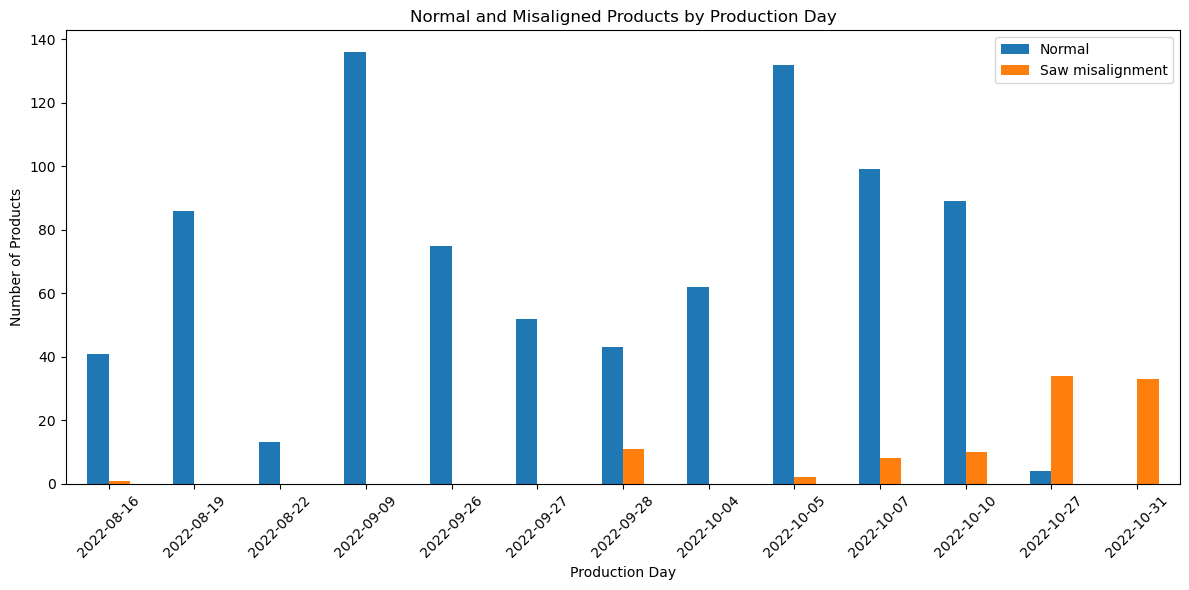

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    "/kaggle/working/saw_clean/saw_active_cut_features.csv"
)

table = pd.crosstab(
    df["production_day"],
    df["target"]
)

table = table.reindex(
    columns=[0, 1],
    fill_value=0
)

table.columns = [
    "Normal",
    "Saw misalignment"
]

print(table)

table.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Normal and Misaligned Products by Production Day")
plt.xlabel("Production Day")
plt.ylabel("Number of Products")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

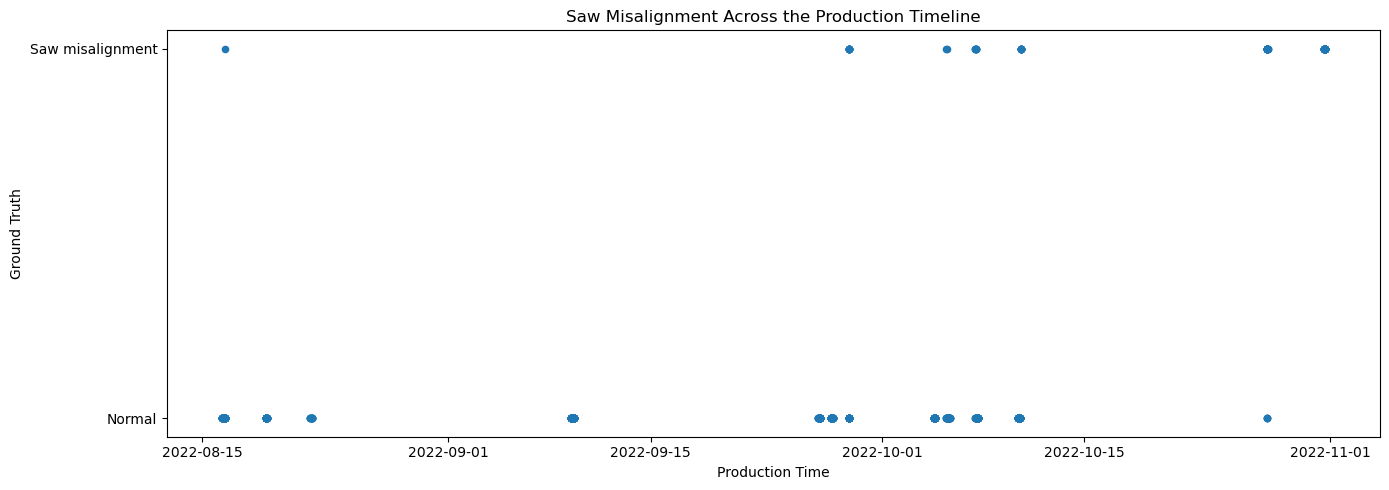

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    "/kaggle/working/saw_clean/saw_product_metadata.csv"
)

df = df[
    df["clean_saw_task_eligible"] == True
].copy()

df["measurement_timestamp"] = pd.to_datetime(
    df["measurement_timestamp"],
    errors="coerce"
)

df = df.sort_values("measurement_timestamp")

plt.figure(figsize=(14, 5))

plt.scatter(
    df["measurement_timestamp"],
    df["saw_target_clean"],
    s=20
)

plt.yticks(
    [0, 1],
    ["Normal", "Saw misalignment"]
)

plt.xlabel("Production Time")
plt.ylabel("Ground Truth")
plt.title("Saw Misalignment Across the Production Timeline")

plt.tight_layout()
plt.show()

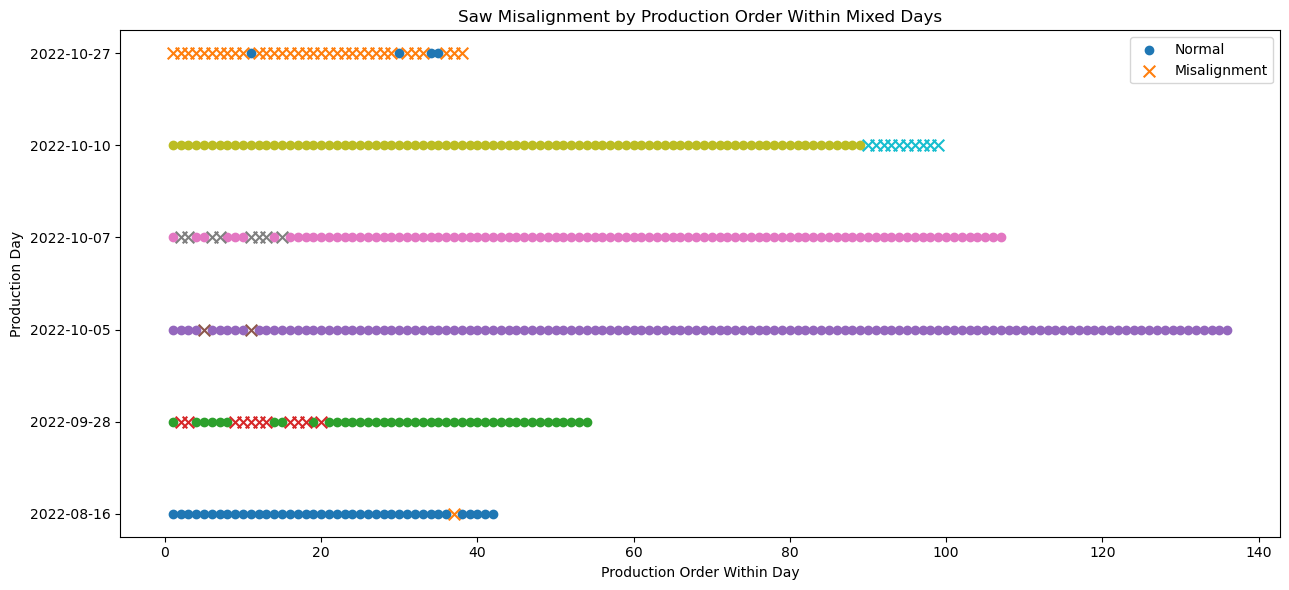

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    "/kaggle/working/saw_clean/saw_product_metadata.csv"
)

df = df[
    df["clean_saw_task_eligible"] == True
].copy()

df["measurement_timestamp"] = pd.to_datetime(
    df["measurement_timestamp"],
    errors="coerce"
)

df["production_day"] = (
    df["measurement_timestamp"]
    .dt.date
    .astype(str)
)

# Keep only days containing BOTH classes
day_table = pd.crosstab(
    df["production_day"],
    df["saw_target_clean"]
)

mixed_days = day_table[
    (day_table.get(0, 0) > 0) &
    (day_table.get(1, 0) > 0)
].index

plot_df = df[
    df["production_day"].isin(mixed_days)
].copy()

plot_df = plot_df.sort_values(
    ["production_day", "measurement_timestamp"]
)

# Order of product within each production day
plot_df["order_in_day"] = (
    plot_df
    .groupby("production_day")
    .cumcount() + 1
)

days = list(mixed_days)

plt.figure(figsize=(13, 6))

for i, day in enumerate(days):

    temp = plot_df[
        plot_df["production_day"] == day
    ]

    normal = temp[
        temp["saw_target_clean"] == 0
    ]

    anomaly = temp[
        temp["saw_target_clean"] == 1
    ]

    plt.scatter(
        normal["order_in_day"],
        [i] * len(normal),
        marker="o",
        label="Normal" if i == 0 else None
    )

    plt.scatter(
        anomaly["order_in_day"],
        [i] * len(anomaly),
        marker="x",
        s=70,
        label="Misalignment" if i == 0 else None
    )

plt.yticks(
    range(len(days)),
    days
)

plt.xlabel("Production Order Within Day")
plt.ylabel("Production Day")
plt.title("Saw Misalignment by Production Order Within Mixed Days")

plt.legend()
plt.tight_layout()
plt.show()

This plot confirms the main issue: the misalignment cases are concentrated in particular production periods, especially late September and October. So time/batch can easily become a shortcut for the model.

But there is also good news. Several production days contain both normal and misaligned products, so we can compare products under much more similar conditions:

2022-09-28   43 normal   11 misaligned

2022-10-07   99 normal    8 misaligned

2022-10-10   89 normal   10 misaligned

2022-10-27    4 normal   34 misaligned


The best next approach is therefore a matched-control experiment. For every misaligned product, find the closest normal product produced on the same day and nearest in time/order. That controls much better for temperature, blade wear, machine condition, material batch, etc


the maximum clean one-to-one matched set is roughly:

Aug 16   → 1 pair

Sep 28   → 11 pairs

Oct 05   → 2 pairs

Oct 07   → 8 pairs

Oct 10   → 10 pairs

Oct 27   → 4 pairs



Total    → 36 anomaly-normal pairs

Oct 31 cannot be used for matched comparison because there are 33 anomalies and zero normal controls.

So we would reduce the problem from:

834 normal + 99 anomaly

to a much cleaner:

36 matched normal
36 matched misaligned

Then ask:

When machine conditions and production time are approximately matched, do cutting energy, power, feed and vibration still differ?

### Let’s build the matched-control experiment

In [28]:
# ============================================================
# CiP-DMD SAW — MATCHED CONTROL EXPERIMENT
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd

from scipy.optimize import linear_sum_assignment
from scipy.stats import wilcoxon

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)


# ============================================================
# PATHS
# ============================================================

ROOT = Path("/kaggle/working/saw_clean")

FEATURE_PATH = ROOT / "saw_active_cut_features.csv"
META_PATH = ROOT / "saw_product_metadata.csv"

PAIR_PATH = ROOT / "saw_matched_pairs.csv"
MATCHED_DATA_PATH = ROOT / "saw_matched_active_features.csv"


# ============================================================
# 1. LOAD DATA
# ============================================================

features = pd.read_csv(FEATURE_PATH)
meta = pd.read_csv(META_PATH)

features["product_id"] = (
    features["product_id"]
    .astype(str)
    .str.replace(".0", "", regex=False)
)

meta["product_id"] = (
    meta["product_id"]
    .astype(str)
    .str.replace(".0", "", regex=False)
)

meta["measurement_timestamp"] = pd.to_datetime(
    meta["measurement_timestamp"],
    errors="coerce"
)


# ============================================================
# 2. ADD EXACT TIMESTAMP TO FEATURE TABLE
# ============================================================

data = features.merge(
    meta[
        [
            "product_id",
            "measurement_timestamp"
        ]
    ],
    on="product_id",
    how="left"
)

data = data.dropna(
    subset=["measurement_timestamp"]
).copy()


# ============================================================
# 3. FIND OPTIMAL NORMAL-ANOMALY PAIRS
#
# Same production day
# Closest possible production time
# Each product used once
# ============================================================

pairs = []

pair_number = 1

for day, day_df in data.groupby("production_day"):

    normal = (
        day_df[day_df["target"] == 0]
        .sort_values("measurement_timestamp")
        .reset_index(drop=True)
    )

    anomaly = (
        day_df[day_df["target"] == 1]
        .sort_values("measurement_timestamp")
        .reset_index(drop=True)
    )

    # Skip days without both classes
    if len(normal) == 0 or len(anomaly) == 0:
        continue

    # --------------------------------------------------------
    # Cost matrix:
    # absolute time difference in seconds
    # --------------------------------------------------------

    anomaly_times = (
        anomaly["measurement_timestamp"]
        .astype("int64")
        .to_numpy()
        / 1e9
    )

    normal_times = (
        normal["measurement_timestamp"]
        .astype("int64")
        .to_numpy()
        / 1e9
    )

    cost = np.abs(
        anomaly_times[:, None]
        -
        normal_times[None, :]
    )

    # Optimal one-to-one matching
    anomaly_idx, normal_idx = linear_sum_assignment(cost)

    for a_idx, n_idx in zip(
        anomaly_idx,
        normal_idx
    ):

        a = anomaly.iloc[a_idx]
        n = normal.iloc[n_idx]

        gap_seconds = abs(
            (
                a["measurement_timestamp"]
                -
                n["measurement_timestamp"]
            ).total_seconds()
        )

        pairs.append({
            "pair_id": pair_number,

            "production_day": day,

            "normal_product":
                n["product_id"],

            "normal_time":
                n["measurement_timestamp"],

            "anomaly_product":
                a["product_id"],

            "anomaly_time":
                a["measurement_timestamp"],

            "time_gap_seconds":
                gap_seconds,

            "time_gap_minutes":
                gap_seconds / 60
        })

        pair_number += 1


pairs_df = pd.DataFrame(pairs)


# ============================================================
# 4. SAVE / DISPLAY MATCHES
# ============================================================

pairs_df.to_csv(
    PAIR_PATH,
    index=False
)

print("=" * 80)
print("MATCHED PAIRS")
print("=" * 80)

print("\nTotal pairs:")
print(len(pairs_df))

print("\nPairs by production day:")
print(
    pairs_df[
        "production_day"
    ].value_counts().sort_index()
)

print("\nTime-gap summary (minutes):")
print(
    pairs_df[
        "time_gap_minutes"
    ].describe()
)

print("\nGap by production day:")
print(
    pairs_df.groupby(
        "production_day"
    )["time_gap_minutes"].agg(
        ["count", "median", "mean", "max"]
    )
)

display(
    pairs_df.head(20)
)


# ============================================================
# 5. BUILD MATCHED FEATURE DATASET
# ============================================================

matched_rows = []

for _, pair in pairs_df.iterrows():

    # normal
    n = data[
        data["product_id"]
        ==
        str(pair["normal_product"])
    ].copy()

    if len(n):

        n["pair_id"] = pair["pair_id"]
        n["matched_role"] = "normal"
        n["pair_time_gap_min"] = pair["time_gap_minutes"]

        matched_rows.append(n)

    # anomaly
    a = data[
        data["product_id"]
        ==
        str(pair["anomaly_product"])
    ].copy()

    if len(a):

        a["pair_id"] = pair["pair_id"]
        a["matched_role"] = "misalignment"
        a["pair_time_gap_min"] = pair["time_gap_minutes"]

        matched_rows.append(a)


matched = pd.concat(
    matched_rows,
    ignore_index=True
)

matched.to_csv(
    MATCHED_DATA_PATH,
    index=False
)


print("\n" + "=" * 80)
print("MATCHED DATASET")
print("=" * 80)

print("Products:", len(matched))

print("\nClasses:")
print(
    matched["target"].value_counts()
)

print("\nProduction days:")
print(
    matched["production_day"]
    .value_counts()
    .sort_index()
)


# ============================================================
# 6. FEATURE COLUMNS
# ============================================================

feature_cols = [
    c
    for c in matched.columns
    if "__" in c
]

print(
    "\nPhysical active-cut features:",
    len(feature_cols)
)


# ============================================================
# 7. PAIRED FEATURE ANALYSIS
#
# For each feature:
# anomaly value - matched normal value
# ============================================================

paired_results = []

for feature in feature_cols:

    pivot = matched.pivot_table(
        index="pair_id",
        columns="target",
        values=feature,
        aggfunc="first"
    )

    if 0 not in pivot.columns or 1 not in pivot.columns:
        continue

    pivot = pivot.dropna()

    if len(pivot) < 5:
        continue

    normal_values = pivot[0].to_numpy()
    anomaly_values = pivot[1].to_numpy()

    diff = (
        anomaly_values
        -
        normal_values
    )

    # Paired standardized effect
    if np.std(diff, ddof=1) > 0:

        effect_size = (
            np.mean(diff)
            /
            np.std(diff, ddof=1)
        )

    else:
        effect_size = 0


    # Wilcoxon paired test
    try:

        _, p_value = wilcoxon(
            anomaly_values,
            normal_values
        )

    except:
        p_value = np.nan


    paired_results.append({
        "feature": feature,

        "pairs_used":
            len(pivot),

        "normal_mean":
            np.mean(normal_values),

        "anomaly_mean":
            np.mean(anomaly_values),

        "mean_difference":
            np.mean(diff),

        "paired_effect_size":
            effect_size,

        "abs_effect_size":
            abs(effect_size),

        "p_value":
            p_value
    })


paired_results = pd.DataFrame(
    paired_results
)

paired_results = paired_results.sort_values(
    "abs_effect_size",
    ascending=False
)

paired_results.to_csv(
    ROOT /
    "saw_matched_feature_differences.csv",
    index=False
)


print("\n" + "=" * 80)
print("TOP MATCHED FEATURE DIFFERENCES")
print("=" * 80)

display(
    paired_results.head(30)
)


# ============================================================
# 8. TRAIN-ONLY FEATURE CLEANING
# ============================================================

def prepare_features(
    X_train,
    X_test,
    y_train,
    top_k=20
):

    # Missing filter
    missing_ratio = X_train.isna().mean()

    keep = missing_ratio[
        missing_ratio <= 0.20
    ].index

    X_train = X_train[keep].copy()
    X_test = X_test[keep].copy()


    # Remove constant / near constant
    keep_cols = []

    for col in X_train.columns:

        values = X_train[col].dropna()

        if len(values) == 0:
            continue

        if values.nunique() <= 1:
            continue

        dominant = (
            values
            .value_counts(normalize=True)
            .iloc[0]
        )

        if dominant >= 0.995:
            continue

        keep_cols.append(col)


    X_train = X_train[keep_cols]
    X_test = X_test[keep_cols]


    # Median imputation
    medians = X_train.median()

    X_train = X_train.fillna(
        medians
    )

    X_test = X_test.fillna(
        medians
    )


    # Remove highly correlated features
    corr = (
        X_train
        .corr()
        .abs()
    )

    upper = corr.where(
        np.triu(
            np.ones(corr.shape),
            k=1
        ).astype(bool)
    )

    remove = [
        col
        for col in upper.columns
        if any(
            upper[col] > 0.98
        )
    ]

    X_train = X_train.drop(
        columns=remove
    )

    X_test = X_test.drop(
        columns=remove
    )


    # Mutual Information
    mi = mutual_info_classif(
        X_train,
        y_train,
        random_state=42
    )

    ranking = pd.DataFrame({
        "feature": X_train.columns,
        "mutual_information": mi
    })

    ranking = ranking.sort_values(
        "mutual_information",
        ascending=False
    )

    selected = (
        ranking
        .head(
            min(
                top_k,
                len(ranking)
            )
        )["feature"]
        .tolist()
    )

    return (
        X_train[selected],
        X_test[selected],
        ranking,
        selected
    )


# ============================================================
# 9. LEAVE-ONE-PRODUCTION-DAY-OUT TEST
#
# Because matched dataset contains both classes on every
# included day.
# ============================================================

X = matched[
    feature_cols
].copy()

y = matched[
    "target"
].astype(int)

groups = matched[
    "production_day"
]


logo = LeaveOneGroupOut()


all_true = []
all_pred = []
all_prob = []

fold_results = []

selected_all = []


for fold, (train_idx, test_idx) in enumerate(
    logo.split(
        X,
        y,
        groups
    ),
    start=1
):

    test_day = (
        groups.iloc[test_idx]
        .iloc[0]
    )

    print("\n")
    print("=" * 70)
    print(
        f"TEST DAY: {test_day}"
    )
    print("=" * 70)


    X_train = X.iloc[
        train_idx
    ].copy()

    X_test = X.iloc[
        test_idx
    ].copy()

    y_train = y.iloc[
        train_idx
    ]

    y_test = y.iloc[
        test_idx
    ]


    (
        X_train,
        X_test,
        ranking,
        selected
    ) = prepare_features(
        X_train,
        X_test,
        y_train,
        top_k=20
    )


    selected_all.extend(
        selected
    )


    model = RandomForestClassifier(

        n_estimators=500,

        class_weight="balanced",

        min_samples_leaf=2,

        random_state=42,

        n_jobs=-1
    )

    model.fit(
        X_train,
        y_train
    )


    pred = model.predict(
        X_test
    )

    prob = model.predict_proba(
        X_test
    )[:, 1]


    all_true.extend(
        y_test.tolist()
    )

    all_pred.extend(
        pred.tolist()
    )

    all_prob.extend(
        prob.tolist()
    )


    precision = precision_score(
        y_test,
        pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        pred,
        zero_division=0
    )

    balanced = balanced_accuracy_score(
        y_test,
        pred
    )

    roc = roc_auc_score(
        y_test,
        prob
    )

    pr = average_precision_score(
        y_test,
        prob
    )


    print("\nConfusion matrix:")

    print(
        confusion_matrix(
            y_test,
            pred,
            labels=[0, 1]
        )
    )


    print(
        f"\nPrecision: {precision:.3f}"
    )

    print(
        f"Recall: {recall:.3f}"
    )

    print(
        f"F1: {f1:.3f}"
    )

    print(
        f"Balanced accuracy: {balanced:.3f}"
    )

    print(
        f"ROC-AUC: {roc:.3f}"
    )

    print(
        f"PR-AUC: {pr:.3f}"
    )


    fold_results.append({

        "test_day":
            test_day,

        "test_products":
            len(test_idx),

        "precision":
            precision,

        "recall":
            recall,

        "f1":
            f1,

        "balanced_accuracy":
            balanced,

        "roc_auc":
            roc,

        "pr_auc":
            pr
    })


# ============================================================
# 10. FINAL POOLED OUT-OF-DAY PERFORMANCE
# ============================================================

all_true = np.array(
    all_true
)

all_pred = np.array(
    all_pred
)

all_prob = np.array(
    all_prob
)


print("\n")
print("=" * 80)
print("PER-DAY MATCHED RESULTS")
print("=" * 80)

fold_results_df = pd.DataFrame(
    fold_results
)

display(
    fold_results_df
)


print("\n")
print("=" * 80)
print("POOLED OUT-OF-DAY MATCHED RESULT")
print("=" * 80)


print("\nConfusion matrix:")

print(
    confusion_matrix(
        all_true,
        all_pred,
        labels=[0, 1]
    )
)


print(
    "\nPrecision:",
    round(
        precision_score(
            all_true,
            all_pred,
            zero_division=0
        ),
        3
    )
)

print(
    "Recall:",
    round(
        recall_score(
            all_true,
            all_pred,
            zero_division=0
        ),
        3
    )
)

print(
    "F1:",
    round(
        f1_score(
            all_true,
            all_pred,
            zero_division=0
        ),
        3
    )
)

print(
    "Balanced accuracy:",
    round(
        balanced_accuracy_score(
            all_true,
            all_pred
        ),
        3
    )
)

print(
    "ROC-AUC:",
    round(
        roc_auc_score(
            all_true,
            all_prob
        ),
        3
    )
)

print(
    "PR-AUC:",
    round(
        average_precision_score(
            all_true,
            all_prob
        ),
        3
    )
)


# ============================================================
# 11. MOST CONSISTENTLY SELECTED FEATURES
# ============================================================

feature_frequency = (
    pd.Series(
        selected_all
    )
    .value_counts()
    .reset_index()
)

feature_frequency.columns = [
    "feature",
    "selected_in_n_folds"
]


print("\n")
print("=" * 80)
print("MOST CONSISTENT MATCHED FEATURES")
print("=" * 80)

display(
    feature_frequency.head(30)
)

MATCHED PAIRS

Total pairs:
36

Pairs by production day:
production_day
2022-08-16     1
2022-09-28    11
2022-10-05     2
2022-10-07     8
2022-10-10    10
2022-10-27     4
Name: count, dtype: int64

Time-gap summary (minutes):
count     36.000000
mean      27.100463
std       40.447035
min        0.533333
25%        1.420833
50%        2.575000
75%       77.350000
max      104.900000
Name: time_gap_minutes, dtype: float64

Gap by production day:
                count     median       mean         max
production_day                                         
2022-08-16          1   0.800000   0.800000    0.800000
2022-09-28         11   2.700000   3.983333   11.200000
2022-10-05          2   1.133333   1.133333    1.733333
2022-10-07          8   1.466667   1.775000    3.733333
2022-10-10         10  90.075000  90.843333  104.900000
2022-10-27          4   1.525000   1.525000    1.600000


,pair_id,production_day,normal_product,normal_time,anomaly_product,anomaly_time,time_gap_seconds,time_gap_minutes
0,1,2022-08-16,101002,2022-08-16 13:25:28,101001,2022-08-16 13:24:40,48.0,0.800000
1,2,2022-09-28,111004,2022-09-28 16:37:00,111101,2022-09-28 16:38:19,79.0,1.316667
2,3,2022-09-28,111103,2022-09-28 16:41:23,111102,2022-09-28 16:39:47,96.0,1.600000
3,4,2022-09-28,111204,2022-09-28 16:48:41,111301,2022-09-28 16:50:03,82.0,1.366667
4,5,2022-09-28,111202,2022-09-28 16:45:32,111302,2022-09-28 16:51:32,360.0,6.000000
5,6,2022-09-28,111201,2022-09-28 16:44:14,111303,2022-09-28 16:52:45,511.0,8.516667
6,7,2022-09-28,111104,2022-09-28 16:42:57,111304,2022-09-28 16:54:09,672.0,11.200000
7,8,2022-09-28,111402,2022-09-28 16:56:55,111401,2022-09-28 16:55:32,83.0,1.383333
8,9,2022-09-28,111403,2022-09-28 16:58:21,111501,2022-09-28 17:01:06,165.0,2.750000
9,10,2022-09-28,111602,2022-09-28 17:08:13,111502,2022-09-28 17:02:40,333.0,5.550000



MATCHED DATASET
Products: 72

Classes:
target
0    36
1    36
Name: count, dtype: int64

Production days:
production_day
2022-08-16     2
2022-09-28    22
2022-10-05     4
2022-10-07    16
2022-10-10    20
2022-10-27     8
Name: count, dtype: int64

Physical active-cut features: 425


c:\Users\Savandi\anaconda3\Lib\site-packages\scipy\stats\_wilcoxon.py:172: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
c:\Users\Savandi\anaconda3\Lib\site-packages\scipy\stats\_wilcoxon.py:172: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
c:\Users\Savandi\anaconda3\Lib\site-packages\scipy\stats\_wilcoxon.py:172: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
c:\Users\Savandi\anaconda3\Lib\site-packages\scipy\stats\_wilcoxon.py:172: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
c:\Users\Savandi\anaconda3\Lib\site-packages\scipy\stats\_wilcoxon.py:172: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
c:\Users\Savandi\anaconda3\Lib\site-packages\scipy\stats\_wilcoxon.py:172: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
c:\Users\Savandi\anaconda3\Lib\site-packages\s


TOP MATCHED FEATURE DIFFERENCES


...

,feature,pairs_used,normal_mean,anomaly_mean,mean_difference,paired_effect_size,abs_effect_size,p_value
99,Position__slope,36,-0.536669,-0.546043,-0.009373,-0.684453,0.684453,0.000172
79,vVorschub__rms,36,0.927193,0.942755,0.015562,0.627658,0.627658,0.001538
68,vVorschub__mean,36,0.886433,0.902290,0.015857,0.618768,0.618768,0.001635
32,PData.CutEnergy__mean_abs_change,36,0.361923,0.398678,0.036755,0.606691,0.606691,0.004598
31,PData.CutEnergy__slope,36,0.725883,0.800786,0.074903,0.601229,0.601229,0.003692
18,PData.CutEnergy__std,36,11.544360,12.489658,0.945298,0.598864,0.598864,0.003120
27,PData.CutEnergy__range,36,39.446181,42.546875,3.100694,0.598567,0.598567,0.005760
25,PData.CutEnergy__q95,36,255949.919922,256111.394010,161.474089,0.596194,0.596194,0.001277
20,PData.CutEnergy__max,36,255951.707465,256113.186198,161.478733,0.596151,0.596151,0.001866
24,PData.CutEnergy__q75,36,255942.022786,256102.849718,160.826931,0.595412,0.595412,0.001916




TEST DAY: 2022-08-16

Confusion matrix:
[[0 1]
 [0 1]]

Precision: 0.500
Recall: 1.000
F1: 0.667
Balanced accuracy: 0.500
ROC-AUC: 0.000
PR-AUC: 0.500


TEST DAY: 2022-09-28

Confusion matrix:
[[4 7]
 [3 8]]

Precision: 0.533
Recall: 0.727
F1: 0.615
Balanced accuracy: 0.545
ROC-AUC: 0.636
PR-AUC: 0.653


TEST DAY: 2022-10-05

Confusion matrix:
[[1 1]
 [1 1]]

Precision: 0.500
Recall: 0.500
F1: 0.500
Balanced accuracy: 0.500
ROC-AUC: 0.500
PR-AUC: 0.750


TEST DAY: 2022-10-07

Confusion matrix:
[[6 2]
 [6 2]]

Precision: 0.500
Recall: 0.250
F1: 0.333
Balanced accuracy: 0.500
ROC-AUC: 0.406
PR-AUC: 0.506


TEST DAY: 2022-10-10

Confusion matrix:
[[8 2]
 [6 4]]

Precision: 0.667
Recall: 0.400
F1: 0.500
Balanced accuracy: 0.600
ROC-AUC: 0.600
PR-AUC: 0.680


TEST DAY: 2022-10-27

Confusion matrix:
[[2 2]
 [2 2]]

Precision: 0.500
Recall: 0.500
F1: 0.500
Balanced accuracy: 0.500
ROC-AUC: 0.500
PR-AUC: 0.732


PER-DAY MATCHED RESULTS


,test_day,test_products,precision,recall,f1,balanced_accuracy,roc_auc,pr_auc
0,2022-08-16,2,0.500000,1.000000,0.666667,0.500000,0.000000,0.500000
1,2022-09-28,22,0.533333,0.727273,0.615385,0.545455,0.636364,0.653272
2,2022-10-05,4,0.500000,0.500000,0.500000,0.500000,0.500000,0.750000
3,2022-10-07,16,0.500000,0.250000,0.333333,0.500000,0.406250,0.506177
4,2022-10-10,20,0.666667,0.400000,0.500000,0.600000,0.600000,0.680252
5,2022-10-27,8,0.500000,0.500000,0.500000,0.500000,0.500000,0.732143




POOLED OUT-OF-DAY MATCHED RESULT

Confusion matrix:
[[21 15]
 [18 18]]

Precision: 0.545
Recall: 0.5
F1: 0.522
Balanced accuracy: 0.542
ROC-AUC: 0.529
PR-AUC: 0.559


MOST CONSISTENT MATCHED FEATURES


,feature,selected_in_n_folds
0,Vib03.Peak__std,6
1,Vib01.RMS__slope,6
2,PData.CutEnergy__slope,5
3,Vib02.CREST__iqr,5
4,PData.PEff__range,5
5,Vib01.Peak__mean_abs_change,5
6,PData.CutEnergy__mean,5
7,Vib03.Kurtosis__std,5
8,Vib03.RMS__kurtosis,4
9,Vib01.CREST__slope,4


The paired feature analysis is still interesting. Features such as Position__slope, vVorschub__mean/rms, PData.CutEnergy, Vib01.RMS, and PData.PEff showed noticeable differences between normal and misaligned pairs 

However, the actual classifier result is weak

So the current conclusion is:

The active-cut physical signals do show some paired differences, but our current feature-based Random Forest does not generalize reliably across unseen production days after controlling for batch/time effects.

One thing to notice:
Oct 10 is badly matched. Its median pair gap is about 90 minutes, while the other days are mostly around 1–4 minutes. That means those Oct 10 pairs are not really “same-condition” comparisons.

Lets throw away pairs that are too far apart in time, especially those Oct 10 ~90-minute matches

In [29]:
# ============================================================
# CiP-DMD SAW — STRICT MATCHED-CONDITION TEST
# Keep only pairs <= 10 minutes apart
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score
)

ROOT = Path("/kaggle/working/saw_clean")

PAIR_PATH = ROOT / "saw_matched_pairs.csv"
FEATURE_PATH = ROOT / "saw_matched_active_features.csv"

MAX_GAP_MINUTES = 10


# ============================================================
# 1. LOAD
# ============================================================

pairs = pd.read_csv(PAIR_PATH)
data = pd.read_csv(FEATURE_PATH)

pairs["normal_product"] = pairs["normal_product"].astype(str)
pairs["anomaly_product"] = pairs["anomaly_product"].astype(str)

data["product_id"] = (
    data["product_id"]
    .astype(str)
    .str.replace(".0", "", regex=False)
)


# ============================================================
# 2. STRICT TIME MATCHING
# ============================================================

strict_pairs = pairs[
    pairs["time_gap_minutes"] <= MAX_GAP_MINUTES
].copy()

print("=" * 80)
print("STRICT MATCHING")
print("=" * 80)

print("Original pairs:", len(pairs))
print("Strict pairs:", len(strict_pairs))

print("\nPairs by day:")
print(
    strict_pairs["production_day"]
    .value_counts()
    .sort_index()
)

print("\nTime gap:")
print(
    strict_pairs["time_gap_minutes"]
    .describe()
)


# ============================================================
# 3. KEEP ONLY PRODUCTS IN STRICT PAIRS
# ============================================================

allowed_products = set(
    strict_pairs["normal_product"].tolist()
    +
    strict_pairs["anomaly_product"].tolist()
)

strict = data[
    data["product_id"].isin(allowed_products)
].copy()

# Map new pair IDs
pair_map = {}

for _, row in strict_pairs.iterrows():

    pair_map[str(row["normal_product"])] = row["pair_id"]
    pair_map[str(row["anomaly_product"])] = row["pair_id"]

strict["pair_id"] = (
    strict["product_id"]
    .map(pair_map)
)


print("\nStrict dataset:")
print("Products:", len(strict))

print("\nClasses:")
print(strict["target"].value_counts())

print("\nDays:")
print(
    strict["production_day"]
    .value_counts()
    .sort_index()
)


# ============================================================
# 4. FEATURE COLUMNS
# ============================================================

feature_cols = [
    c for c in strict.columns
    if "__" in c
]

X = strict[feature_cols].copy()
y = strict["target"].astype(int)
groups = strict["production_day"]


# ============================================================
# 5. TRAIN-ONLY FEATURE SELECTION
#
# Smaller dataset now, so keep only TOP 10.
# ============================================================

def prepare_features(
    X_train,
    X_test,
    y_train,
    top_k=10
):

    # Remove >20% missing
    missing = X_train.isna().mean()

    keep = missing[
        missing <= 0.20
    ].index

    X_train = X_train[keep].copy()
    X_test = X_test[keep].copy()


    # Remove constant / near-constant
    keep_cols = []

    for col in X_train.columns:

        values = X_train[col].dropna()

        if len(values) == 0:
            continue

        if values.nunique() <= 1:
            continue

        dominant = (
            values
            .value_counts(normalize=True)
            .iloc[0]
        )

        if dominant >= 0.995:
            continue

        keep_cols.append(col)

    X_train = X_train[keep_cols]
    X_test = X_test[keep_cols]


    # Median fill from training only
    medians = X_train.median()

    X_train = X_train.fillna(medians)
    X_test = X_test.fillna(medians)


    # Remove correlated features
    corr = X_train.corr().abs()

    upper = corr.where(
        np.triu(
            np.ones(corr.shape),
            k=1
        ).astype(bool)
    )

    remove = [
        col
        for col in upper.columns
        if any(upper[col] > 0.95)
    ]

    X_train = X_train.drop(
        columns=remove
    )

    X_test = X_test.drop(
        columns=remove
    )


    # Mutual information
    mi = mutual_info_classif(
        X_train,
        y_train,
        random_state=42
    )

    ranking = pd.DataFrame({
        "feature": X_train.columns,
        "mi": mi
    }).sort_values(
        "mi",
        ascending=False
    )

    selected = (
        ranking
        .head(
            min(top_k, len(ranking))
        )["feature"]
        .tolist()
    )

    return (
        X_train[selected],
        X_test[selected],
        ranking,
        selected
    )


# ============================================================
# 6. LEAVE-ONE-DAY-OUT
# ============================================================

logo = LeaveOneGroupOut()

all_true = []
all_pred = []
all_prob = []

results = []
selected_all = []


for train_idx, test_idx in logo.split(
    X,
    y,
    groups
):

    test_day = groups.iloc[test_idx].iloc[0]

    X_train = X.iloc[train_idx].copy()
    X_test = X.iloc[test_idx].copy()

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]


    # Need both classes in train and test
    if y_train.nunique() < 2 or y_test.nunique() < 2:
        print(
            f"\nSkipping {test_day}: "
            "both classes not available."
        )
        continue


    (
        X_train,
        X_test,
        ranking,
        selected
    ) = prepare_features(
        X_train,
        X_test,
        y_train,
        top_k=10
    )

    selected_all.extend(selected)


    model = RandomForestClassifier(
        n_estimators=500,
        class_weight="balanced",
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_train,
        y_train
    )

    pred = model.predict(
        X_test
    )

    prob = model.predict_proba(
        X_test
    )[:, 1]


    all_true.extend(
        y_test.tolist()
    )

    all_pred.extend(
        pred.tolist()
    )

    all_prob.extend(
        prob.tolist()
    )


    precision = precision_score(
        y_test,
        pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        pred,
        zero_division=0
    )

    bal = balanced_accuracy_score(
        y_test,
        pred
    )

    roc = roc_auc_score(
        y_test,
        prob
    )

    pr = average_precision_score(
        y_test,
        prob
    )


    print("\n" + "=" * 70)
    print("TEST DAY:", test_day)
    print("=" * 70)

    print(
        confusion_matrix(
            y_test,
            pred,
            labels=[0,1]
        )
    )

    print(
        f"Precision: {precision:.3f}"
    )

    print(
        f"Recall: {recall:.3f}"
    )

    print(
        f"F1: {f1:.3f}"
    )

    print(
        f"Balanced accuracy: {bal:.3f}"
    )

    print(
        f"ROC-AUC: {roc:.3f}"
    )

    print(
        f"PR-AUC: {pr:.3f}"
    )


    results.append({
        "test_day": test_day,
        "n_test": len(test_idx),
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "balanced_accuracy": bal,
        "roc_auc": roc,
        "pr_auc": pr
    })


# ============================================================
# 7. FINAL POOLED RESULT
# ============================================================

results_df = pd.DataFrame(results)

print("\n")
print("=" * 80)
print("STRICT MATCHED PER-DAY RESULTS")
print("=" * 80)

display(results_df)


all_true = np.array(all_true)
all_pred = np.array(all_pred)
all_prob = np.array(all_prob)


print("\n")
print("=" * 80)
print("STRICT MATCHED POOLED RESULT")
print("=" * 80)

print("\nConfusion matrix:")

print(
    confusion_matrix(
        all_true,
        all_pred,
        labels=[0,1]
    )
)

print(
    "\nPrecision:",
    round(
        precision_score(
            all_true,
            all_pred,
            zero_division=0
        ),
        3
    )
)

print(
    "Recall:",
    round(
        recall_score(
            all_true,
            all_pred,
            zero_division=0
        ),
        3
    )
)

print(
    "F1:",
    round(
        f1_score(
            all_true,
            all_pred,
            zero_division=0
        ),
        3
    )
)

print(
    "Balanced accuracy:",
    round(
        balanced_accuracy_score(
            all_true,
            all_pred
        ),
        3
    )
)

print(
    "ROC-AUC:",
    round(
        roc_auc_score(
            all_true,
            all_prob
        ),
        3
    )
)

print(
    "PR-AUC:",
    round(
        average_precision_score(
            all_true,
            all_prob
        ),
        3
    )
)


# ============================================================
# 8. STABLE FEATURES
# ============================================================

feature_frequency = (
    pd.Series(selected_all)
    .value_counts()
    .reset_index()
)

feature_frequency.columns = [
    "feature",
    "selected_in_n_folds"
]

print("\nMost stable features:")

display(
    feature_frequency.head(20)
)



STRICT MATCHING
Original pairs: 36
Strict pairs: 25

Pairs by day:
production_day
2022-08-16     1
2022-09-28    10
2022-10-05     2
2022-10-07     8
2022-10-27     4
Name: count, dtype: int64

Time gap:
count    25.000000
mean      2.239333
std       1.903474
min       0.533333
25%       1.316667
50%       1.583333
75%       2.700000
max       8.516667
Name: time_gap_minutes, dtype: float64

Strict dataset:
Products: 50

Classes:
target
0    25
1    25
Name: count, dtype: int64

Days:
production_day
2022-08-16     2
2022-09-28    20
2022-10-05     4
2022-10-07    16
2022-10-27     8
Name: count, dtype: int64

TEST DAY: 2022-08-16
[[1 0]
 [1 0]]
Precision: 0.000
Recall: 0.000
F1: 0.000
Balanced accuracy: 0.500
ROC-AUC: 1.000
PR-AUC: 1.000

TEST DAY: 2022-09-28
[[4 6]
 [3 7]]
Precision: 0.538
Recall: 0.700
F1: 0.609
Balanced accuracy: 0.550
ROC-AUC: 0.490
PR-AUC: 0.546

TEST DAY: 2022-10-05
[[1 1]
 [2 0]]
Precision: 0.000
Recall: 0.000
F1: 0.000
Balanced accuracy: 0.250
ROC-AUC: 0.250
P

,test_day,n_test,precision,recall,f1,balanced_accuracy,roc_auc,pr_auc
0,2022-08-16,2,0.000000,0.00,0.000000,0.5000,1.000000,1.000000
1,2022-09-28,20,0.538462,0.70,0.608696,0.5500,0.490000,0.546229
2,2022-10-05,4,0.000000,0.00,0.000000,0.2500,0.250000,0.500000
3,2022-10-07,16,0.285714,0.25,0.266667,0.3125,0.453125,0.554587
4,2022-10-27,8,0.000000,0.00,0.000000,0.3750,0.375000,0.523810




STRICT MATCHED POOLED RESULT

Confusion matrix:
[[12 13]
 [16  9]]

Precision: 0.409
Recall: 0.36
F1: 0.383
Balanced accuracy: 0.42
ROC-AUC: 0.458
PR-AUC: 0.496

Most stable features:


,feature,selected_in_n_folds
0,Vib01.Kurtosis__skew,3
1,Vib02.RMS__kurtosis,3
2,Vib03.CREST__kurtosis,2
3,Vib03.Peak__std,2
4,Position__median,2
5,Vib01.Peak__min,2
6,Vib02.Skewness__kurtosis,2
7,PData.PEff__mean_abs_change,1
8,Vib01.RMS__max_abs_change,1
9,Vib03.RMS__iqr,1


the result says the current Saw-misalignment detection idea is not reliable enough.

So the progression is very clear:

Random split

F1 = 0.78

↓

Looked excellent


Production-day split

F1 ≈ 0.09 in first test

↓

Batch effect discovered


Active-cut physical features

Some days F1 ≈ 0.65–0.76

↓

Promising, but days highly confounded


Matched same-day pairs

F1 = 0.52

↓


Strict ≤10-minute matched pairs

F1 = 0.38

ROC-AUC = 0.46

↓


No stable cross-condition Saw anomaly signal



So now we have
>Initial random-split performance suggested strong anomaly detection, but progressively stricter controls for production-day and temporal confounding caused performance to collapse. This indicates that much of the apparent predictive signal came from production-condition differences rather than a robust physical signature of Saw misalignment.

what if we introduce some assumption over uncontroleble things and when selecting features secevct with minimum efect

assumptions:

* Same saw/blade condition during the considered production period.
* Same material type and approximately similar material properties.
* Same cutting program and machine settings.
* Ambient/environmental temperature changes are small enough to ignore.
* Machine maintenance condition does not change significantly.
* Operator procedure is approximately the same.
* The main intentional process change is raw-material misalignment.


and also not use CPU temperature, counters, timestamps, production order, absolute cut duration, Flatstream counters, etc.

In [30]:
# ============================================================
# SAW MISALIGNMENT
# CONTROLLED-CONDITION / ROBUST-PHYSICAL-FEATURE MODEL
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score
)

ROOT = Path("/kaggle/working/saw_clean")

df = pd.read_csv(
    ROOT / "saw_active_cut_features.csv"
)


# ============================================================
# 1. KEEP ONLY DAYS WHERE BOTH NORMAL + ANOMALY EXIST
#
# Under our assumption:
# conditions within these production periods are approximately
# comparable.
# ============================================================

day_counts = pd.crosstab(
    df["production_day"],
    df["target"]
)

mixed_days = day_counts[
    (day_counts.get(0, 0) > 0) &
    (day_counts.get(1, 0) > 0)
].index

df = df[
    df["production_day"].isin(mixed_days)
].copy()


print("Products used:", len(df))

print("\nClasses:")
print(df["target"].value_counts())

print("\nDays:")
print(
    df["production_day"]
    .value_counts()
    .sort_index()
)


# ============================================================
# 2. ROBUST PHYSICAL SIGNALS
# ============================================================

allowed_signals = [

    "PData.PEff",

    "PData.CutEnergy",

    "P_Vorschub",

    "vVorschub",

    "Position",
    "Position_Band",

    "Vib01.CREST",
    "Vib01.Kurtosis",
    "Vib01.Peak",
    "Vib01.RMS",
    "Vib01.Skewness",

    "Vib02.CREST",
    "Vib02.Kurtosis",
    "Vib02.Peak",
    "Vib02.RMS",
    "Vib02.Skewness",

    "Vib03.CREST",
    "Vib03.Kurtosis",
    "Vib03.Peak",
    "Vib03.RMS",
    "Vib03.Skewness"
]


# ============================================================
# 3. USE RELATIVE / VARIATION FEATURES
#
# Avoid absolute operating level as much as possible.
# ============================================================

allowed_stats = [

    "std",

    "iqr",

    "range",

    "mean_abs_change",

    "max_abs_change",

    "slope",

    "skew",

    "kurtosis"
]


selected_features = []

for col in df.columns:

    if "__" not in col:
        continue

    signal, stat = col.split("__", 1)

    if (
        signal in allowed_signals
        and
        stat in allowed_stats
    ):
        selected_features.append(col)


print(
    "\nCandidate robust features:",
    len(selected_features)
)


# ============================================================
# 4. CLEAN FEATURES
# ============================================================

X = df[selected_features].copy()

y = df["target"].astype(int)


# Remove features with too much missing
missing = X.isna().mean()

X = X[
    missing[
        missing <= 0.20
    ].index
]


# Median imputation
X = X.fillna(
    X.median()
)


# Remove constants
X = X.loc[
    :,
    X.nunique() > 1
]


# Remove highly correlated features
corr = X.corr().abs()

upper = corr.where(
    np.triu(
        np.ones(
            corr.shape
        ),
        k=1
    ).astype(bool)
)

remove = [
    col
    for col in upper.columns
    if any(
        upper[col] > 0.95
    )
]

X = X.drop(
    columns=remove
)


print(
    "Features after cleaning:",
    X.shape[1]
)


# ============================================================
# 5. RANDOM FOREST
#
# This is now a CONTROLLED-CONDITION model.
# We are NOT claiming unseen-day generalization.
# ============================================================

model = RandomForestClassifier(

    n_estimators=500,

    class_weight="balanced",

    min_samples_leaf=2,

    max_depth=6,

    random_state=42,

    n_jobs=-1
)


cv = StratifiedKFold(

    n_splits=5,

    shuffle=True,

    random_state=42
)


scores = cross_validate(

    model,

    X,
    y,

    cv=cv,

    scoring={
        "precision": "precision",
        "recall": "recall",
        "f1": "f1",
        "balanced_accuracy":
            "balanced_accuracy",
        "roc_auc":
            "roc_auc",
        "pr_auc":
            "average_precision"
    },

    return_estimator=True
)


# ============================================================
# 6. CV RESULTS
# ============================================================

results = pd.DataFrame({

    "precision":
        scores["test_precision"],

    "recall":
        scores["test_recall"],

    "f1":
        scores["test_f1"],

    "balanced_accuracy":
        scores[
            "test_balanced_accuracy"
        ],

    "roc_auc":
        scores["test_roc_auc"],

    "pr_auc":
        scores["test_pr_auc"]
})


print("\n")
print("=" * 70)
print("CONTROLLED-CONDITION CV RESULTS")
print("=" * 70)

display(results)


print("\nMEAN ± STD")

summary = pd.DataFrame({

    "mean":
        results.mean(),

    "std":
        results.std()
})

display(summary)


# ============================================================
# 7. RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

importance = np.zeros(
    X.shape[1]
)

for estimator in scores["estimator"]:

    importance += (
        estimator.feature_importances_
    )

importance /= len(
    scores["estimator"]
)


importance_df = pd.DataFrame({

    "feature":
        X.columns,

    "importance":
        importance
})

importance_df = (
    importance_df
    .sort_values(
        "importance",
        ascending=False
    )
)


print("\n")
print("=" * 70)
print("MOST IMPORTANT ROBUST FEATURES")
print("=" * 70)

display(
    importance_df.head(30)
)


importance_df.to_csv(
    ROOT /
    "saw_robust_feature_importance.csv",
    index=False
)

Products used: 474

Classes:
target
0    408
1     66
Name: count, dtype: int64

Days:
production_day
2022-08-16     42
2022-09-28     54
2022-10-05    134
2022-10-07    107
2022-10-10     99
2022-10-27     38
Name: count, dtype: int64

Candidate robust features: 168
Features after cleaning: 131


CONTROLLED-CONDITION CV RESULTS


,precision,recall,f1,balanced_accuracy,roc_auc,pr_auc
0,1.000000,0.538462,0.700000,0.769231,0.984991,0.926340
1,0.666667,0.615385,0.640000,0.783302,0.957786,0.804992
2,1.000000,0.692308,0.818182,0.846154,0.999062,0.994505
3,0.888889,0.571429,0.695652,0.779541,0.960317,0.771287
4,0.555556,0.384615,0.454545,0.667616,0.924976,0.663269



MEAN ± STD


,mean,std
precision,0.822222,0.201843
recall,0.560440,0.113936
f1,0.661676,0.132750
balanced_accuracy,0.769169,0.064317
roc_auc,0.965426,0.028438
pr_auc,0.832079,0.130570




MOST IMPORTANT ROBUST FEATURES


,feature,importance
0,PData.CutEnergy__std,0.142448
30,Position__slope,0.083116
7,PData.PEff__range,0.071626
3,PData.CutEnergy__slope,0.034252
17,vVorschub__std,0.033799
10,PData.PEff__slope,0.033376
11,PData.PEff__mean_abs_change,0.022571
31,Position__max_abs_change,0.022558
109,Vib03.Kurtosis__iqr,0.021616
57,Vib01.RMS__range,0.018543


The main weakness is recall = 0.545.
it is usually correct, but it still misses about 45% of the misalignments.
but that ok in bussiness contex we can say we identifyied 55% of miss earier,
but wait alll these passed weight queality check right is it passs in final quality check since if it pass there identifying it at here wil be no use since it good at the end

At the moment, we have only established:

“These products had an intentionally introduced Saw misalignment.”

and

“Many/possibly all still passed the Saw weight check.”

We have not yet proven whether those same products fail the downstream/final QC.

In [31]:
# ============================================================
# CiP-DMD
# TRACE SAW MISALIGNMENTS THROUGH DOWNSTREAM QUALITY
#
# Main business question:
# Class-1 saw misalignment
#       ↓
# Did Saw weight QC pass?
#       ↓
# Did SAME cylinder bottom later fail Milling QC?
#       ↓
# Was it later assembled, and did EOL assembly QC pass?
#
# Reproduces official CiP-DMD QC logic as closely as possible.
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd


# ============================================================
# PATHS
# ============================================================

ROOT = Path("/kaggle/working/CiP-DMD")
META = ROOT / "meta" / "data"

ANOMALY_PATH = META / "anomalous_parts_detailed.csv"
SAW_PATH = META / "sawing_qc_data.csv"
MILL_PATH = META / "cylinder_bottoms_qc_data.csv"
CYLINDER_PATH = META / "pneumatic_cylinders_qc_data.csv"
SPEC_PATH = META / "spezifikationsgrenze.csv"

OUT_PATH = Path(
    "/kaggle/working/saw_clean/"
    "saw_class1_downstream_quality_trace.csv"
)


# ============================================================
# HELPER
# ============================================================

def clean_id(series):
    """
    Keep product IDs as clean strings.
    """
    return (
        series
        .astype(str)
        .str.strip()
        .str.replace(r"\.0$", "", regex=True)
    )


def strict_pass(value, lower, upper):
    """
    Same logic as official checkBounds():
        value > lower AND value < upper
    """
    value = pd.to_numeric(
        value,
        errors="coerce"
    )

    return (
        value.gt(lower)
        &
        value.lt(upper)
    )


# ============================================================
# 1. LOAD OFFICIAL SOURCE TABLES
# ============================================================

anomaly = pd.read_csv(
    ANOMALY_PATH,
    sep=";"
)

saw = pd.read_csv(
    SAW_PATH,
    sep=";"
)

milling = pd.read_csv(
    MILL_PATH,
    sep=";"
)

cylinder = pd.read_csv(
    CYLINDER_PATH,
    sep=";"
)

spec = pd.read_csv(
    SPEC_PATH,
    sep=";",
    header=None
)


# ============================================================
# 2. CLEAN IDS
# ============================================================

anomaly["part_id"] = clean_id(
    anomaly["part_id"]
)

saw["part_id"] = clean_id(
    saw["part_id"]
)

milling["part_id"] = clean_id(
    milling["part_id"]
)

cylinder["part_id_cylinder_bottom"] = clean_id(
    cylinder["part_id_cylinder_bottom"]
)


# ============================================================
# 3. AUDIT DUPLICATES
#
# Official create_meta_jsons.py stores Saw QC in a dictionary.
# If an ID occurs twice, the later row overwrites the earlier
# row. Therefore keep='last' reproduces that behaviour.
# ============================================================

print("=" * 80)
print("SOURCE AUDIT")
print("=" * 80)

print(
    "Saw duplicate records:",
    saw["part_id"].duplicated(
        keep=False
    ).sum()
)

print(
    "Milling duplicate records:",
    milling["part_id"].duplicated(
        keep=False
    ).sum()
)

print(
    "Assembly duplicate cylinder-bottom IDs:",
    cylinder[
        "part_id_cylinder_bottom"
    ].duplicated(
        keep=False
    ).sum()
)

saw = saw.drop_duplicates(
    "part_id",
    keep="last"
).copy()

milling = milling.drop_duplicates(
    "part_id",
    keep="last"
).copy()


# ============================================================
# 4. CLASS-1 GROUND TRUTH
#
# DO NOT use old Saw 'anomaly' column.
# Official class-1 list = intentionally introduced
# saw misalignment / part too short.
# ============================================================

anomaly["anomaly_class"] = pd.to_numeric(
    anomaly["anomaly_class"],
    errors="coerce"
)

class1 = (
    anomaly[
        anomaly["anomaly_class"] == 1
    ][["part_id"]]
    .drop_duplicates()
    .copy()
)

print(
    "\nOfficial class-1 Saw misalignments:",
    len(class1)
)


# ============================================================
# 5. OFFICIAL SAW WEIGHT LIMITS
#
# create_meta_jsons.py calculates:
#
# mean ± 3 * population SD
#
# from the quality-data dictionary.
# ============================================================

saw["weight"] = pd.to_numeric(
    saw["weight"],
    errors="coerce"
)

weights = (
    saw["weight"]
    .dropna()
    .to_numpy()
)

SAW_LOWER = (
    np.mean(weights)
    -
    3 * np.std(weights)
)

SAW_UPPER = (
    np.mean(weights)
    +
    3 * np.std(weights)
)

print("\nSaw weight bounds reproduced from official logic:")

print(
    f"{SAW_LOWER:.6f}"
    f" < weight < "
    f"{SAW_UPPER:.6f}"
)


saw["saw_weight_pass"] = strict_pass(
    saw["weight"],
    SAW_LOWER,
    SAW_UPPER
)


# ============================================================
# 6. OFFICIAL MILLING QC LIMITS
#
# Read directly from spezifikationsgrenze.csv,
# which create_meta_jsons.py actually uses.
# ============================================================

MILL_BOUNDS = {

    "surface_roughness": (
        float(spec.iloc[2, 1]),
        float(spec.iloc[3, 1])
    ),

    "parallelism": (
        float(spec.iloc[2, 2]),
        float(spec.iloc[3, 2])
    ),

    "groove_depth": (
        float(spec.iloc[2, 3]),
        float(spec.iloc[3, 3])
    ),

    "groove_diameter": (
        float(spec.iloc[2, 4]),
        float(spec.iloc[3, 4])
    )
}


print("\nOfficial raw milling-data bounds:")

for feature, bounds in MILL_BOUNDS.items():

    print(
        f"{feature:20s}: "
        f"{bounds[0]} < x < {bounds[1]}"
    )


# ============================================================
# 7. CALCULATE EACH MILLING QC CHECK
# ============================================================

mill_pass_cols = []

for feature, (lower, upper) in MILL_BOUNDS.items():

    milling[feature] = pd.to_numeric(
        milling[feature],
        errors="coerce"
    )

    pass_col = f"{feature}_pass"

    milling[pass_col] = strict_pass(
        milling[feature],
        lower,
        upper
    )

    mill_pass_cols.append(
        pass_col
    )


# Is every measurement present?
milling["milling_complete"] = (
    milling[
        list(
            MILL_BOUNDS.keys()
        )
    ]
    .notna()
    .all(axis=1)
)


# All four must pass
milling["milling_qc_pass"] = (
    milling["milling_complete"]
    &
    milling[
        mill_pass_cols
    ].all(axis=1)
)


# Which measurements failed?
def get_milling_failure(row):

    failed = []

    for feature in MILL_BOUNDS:

        value = row[feature]

        if pd.isna(value):
            continue

        if not row[
            f"{feature}_pass"
        ]:
            failed.append(feature)

    return ", ".join(failed)


milling[
    "milling_failed_features"
] = milling.apply(
    get_milling_failure,
    axis=1
)


# ============================================================
# 8. OFFICIAL ASSEMBLY / EOL PRESSURE LIMIT
#
# Official generator:
#
# 1. remove pressure <= 4000 when calculating healthy bounds
# 2. mean ± 3 population SD
# ============================================================

cylinder["pressure"] = pd.to_numeric(
    cylinder["pressure"],
    errors="coerce"
)

healthy_pressure_for_bounds = (
    cylinder.loc[
        cylinder["pressure"] > 4000,
        "pressure"
    ]
    .dropna()
    .to_numpy()
)

PRESSURE_LOWER = (
    np.mean(
        healthy_pressure_for_bounds
    )
    -
    3 * np.std(
        healthy_pressure_for_bounds
    )
)

PRESSURE_UPPER = (
    np.mean(
        healthy_pressure_for_bounds
    )
    +
    3 * np.std(
        healthy_pressure_for_bounds
    )
)


print("\nAssembly pressure bounds reproduced from official logic:")

print(
    f"{PRESSURE_LOWER:.3f}"
    f" < pressure < "
    f"{PRESSURE_UPPER:.3f}"
)


cylinder[
    "assembly_pressure_pass"
] = strict_pass(
    cylinder["pressure"],
    PRESSURE_LOWER,
    PRESSURE_UPPER
)


# Official checkBounds() treats:
# n -> pass
# y -> fail

cylinder["rework"] = (
    cylinder["rework"]
    .astype(str)
    .str.strip()
    .str.lower()
)

cylinder[
    "assembly_rework_pass"
] = (
    cylinder["rework"] == "n"
)

cylinder[
    "assembly_qc_pass"
] = (
    cylinder[
        "assembly_pressure_pass"
    ]
    &
    cylinder[
        "assembly_rework_pass"
    ]
)


# ============================================================
# 9. TRACE CLASS-1 PARTS
# ============================================================

trace = class1.merge(

    saw[
        [
            "part_id",
            "weight",
            "saw_weight_pass"
        ]
    ],

    on="part_id",

    how="left",

    indicator="saw_merge"
)


trace[
    "has_saw_qc"
] = (
    trace["saw_merge"] == "both"
)

trace = trace.drop(
    columns="saw_merge"
)


# ---------------- Milling ----------------

mill_cols = [

    "part_id",

    "surface_roughness",
    "parallelism",
    "groove_depth",
    "groove_diameter",

    "surface_roughness_pass",
    "parallelism_pass",
    "groove_depth_pass",
    "groove_diameter_pass",

    "milling_complete",
    "milling_qc_pass",
    "milling_failed_features"
]

trace = trace.merge(

    milling[mill_cols],

    on="part_id",

    how="left",

    indicator="mill_merge"
)

trace[
    "has_milling_qc"
] = (
    trace["mill_merge"] == "both"
)

trace = trace.drop(
    columns="mill_merge"
)


# ---------------- Assembly ----------------

assembly_cols = [

    "part_id_cylinder_bottom",
    "part_id_piston_rod",
    "rework",
    "pressure",

    "assembly_pressure_pass",
    "assembly_rework_pass",
    "assembly_qc_pass"
]

trace = trace.merge(

    cylinder[assembly_cols],

    left_on="part_id",

    right_on="part_id_cylinder_bottom",

    how="left",

    indicator="assembly_merge"
)


trace[
    "was_assembled"
] = (
    trace["assembly_merge"] == "both"
)

trace = trace.drop(
    columns="assembly_merge"
)


# ============================================================
# 10. HUMAN-READABLE STATUS
# ============================================================

trace["saw_status"] = "NO_RECORD"

trace.loc[
    trace["has_saw_qc"]
    &
    trace["saw_weight_pass"],
    "saw_status"
] = "PASS"

trace.loc[
    trace["has_saw_qc"]
    &
    ~trace["saw_weight_pass"].fillna(False),
    "saw_status"
] = "FAIL"


trace["milling_status"] = "NO_RECORD"

trace.loc[
    trace["has_milling_qc"]
    &
    ~trace["milling_complete"].fillna(False),
    "milling_status"
] = "INCOMPLETE"

trace.loc[
    trace["has_milling_qc"]
    &
    trace["milling_complete"].fillna(False)
    &
    trace["milling_qc_pass"].fillna(False),
    "milling_status"
] = "PASS"

trace.loc[
    trace["has_milling_qc"]
    &
    trace["milling_complete"].fillna(False)
    &
    ~trace["milling_qc_pass"].fillna(False),
    "milling_status"
] = "FAIL"


trace["assembly_status"] = "NO_RECORD"

trace.loc[
    trace["was_assembled"],
    "assembly_status"
] = "INCOMPLETE"

trace.loc[
    trace["was_assembled"]
    &
    trace["pressure"].notna()
    &
    trace["assembly_qc_pass"].fillna(False),
    "assembly_status"
] = "PASS"

trace.loc[
    trace["was_assembled"]
    &
    trace["pressure"].notna()
    &
    ~trace["assembly_qc_pass"].fillna(False),
    "assembly_status"
] = "FAIL"


# ============================================================
# 11. BUSINESS LABELS
# ============================================================

# THE MOST IMPORTANT GROUP:
#
# Saw weight says GOOD
# but same cylinder-bottom later fails milling QC.

trace[
    "hidden_defect_after_saw_qc"
] = (

    (trace["saw_status"] == "PASS")
    &
    (trace["milling_status"] == "FAIL")
)


# Saw and milling both pass,
# but EOL assembly subsequently fails.
#
# IMPORTANT:
# Do NOT automatically say Saw caused this.

trace[
    "later_eol_failure_only"
] = (

    (trace["saw_status"] == "PASS")
    &
    (trace["milling_status"] == "PASS")
    &
    (trace["assembly_status"] == "FAIL")
)


# Fully observed and every recorded QC passed
trace[
    "all_recorded_qc_pass"
] = (

    (trace["saw_status"] == "PASS")
    &
    (trace["milling_status"] == "PASS")
    &
    (trace["assembly_status"] == "PASS")
)


# ============================================================
# 12. RESULTS
# ============================================================

N = len(trace)

print("\n")
print("=" * 80)
print("CLASS-1 SAW MISALIGNMENT QUALITY TRACE")
print("=" * 80)

print(
    "\nTotal class-1 misalignments:",
    N
)


print("\n--- SAW WEIGHT QC ---")

print(
    trace["saw_status"]
    .value_counts(
        dropna=False
    )
)


print("\n--- MILLING QC ---")

print(
    trace["milling_status"]
    .value_counts(
        dropna=False
    )
)


print("\n--- ASSEMBLY / EOL QC ---")

print(
    trace["assembly_status"]
    .value_counts(
        dropna=False
    )
)


# ============================================================
# CORE BUSINESS RESULT
# ============================================================

hidden = trace[
    trace[
        "hidden_defect_after_saw_qc"
    ]
].copy()

saw_pass_n = (
    trace["saw_status"]
    == "PASS"
).sum()


print("\n")
print("=" * 80)
print("CORE BUSINESS RESULT")
print("=" * 80)

print(
    "\nSaw misalignment products "
    "that PASSED Saw weight QC "
    "but FAILED later Milling QC:"
)

print(
    f"\n{len(hidden)} / {N} "
    "of all class-1 misalignments"
)

if saw_pass_n > 0:

    print(
        f"{len(hidden)} / {saw_pass_n} "
        "of Saw-weight-passing "
        "class-1 products"
    )

    print(
        "\nHidden downstream-defect rate "
        "among Saw-QC passes:"
    )

    print(
        f"{100 * len(hidden) / saw_pass_n:.2f}%"
    )


# ============================================================
# 13. WHICH MILLING CHECK CATCHES THEM?
# ============================================================

print("\n")
print("=" * 80)
print("WHAT LATER QC DETECTED THE HIDDEN PROBLEM?")
print("=" * 80)


for feature in MILL_BOUNDS:

    pass_col = f"{feature}_pass"

    failures = (

        hidden[pass_col]
        .eq(False)
        .sum()
    )

    print(
        f"{feature:20s}: "
        f"{failures} failures"
    )


# ============================================================
# 14. EOL RESULT
# ============================================================

assembled = trace[
    trace["was_assembled"]
].copy()

print("\n")
print("=" * 80)
print("EOL ASSEMBLY TRACE")
print("=" * 80)

print(
    "Class-1 parts with an assembly record:",
    len(assembled)
)

print(
    "\nAssembly status:"
)

print(
    assembled[
        "assembly_status"
    ].value_counts()
)


fully_good = trace[
    trace[
        "all_recorded_qc_pass"
    ]
]

print(
    "\nClass-1 parts that passed "
    "Saw + Milling + Assembly QC:"
)

print(
    len(fully_good)
)


# ============================================================
# 15. MOST IMPORTANT ROWS TO INSPECT
# ============================================================

print("\n")
print("=" * 80)
print("HIDDEN DEFECTS MISSED BY SAW WEIGHT QC")
print("=" * 80)

display(
    hidden[
        [
            "part_id",

            "weight",

            "surface_roughness",
            "parallelism",
            "groove_depth",
            "groove_diameter",

            "milling_failed_features",

            "was_assembled",
            "pressure",
            "assembly_status"
        ]
    ]
)


# ============================================================
# 16. SAVE COMPLETE TRACE
# ============================================================

trace.to_csv(
    OUT_PATH,
    index=False
)

print("\nSaved detailed trace:")
print(OUT_PATH)

SOURCE AUDIT
Saw duplicate records: 2
Milling duplicate records: 2
Assembly duplicate cylinder-bottom IDs: 0

Official class-1 Saw misalignments: 99

Saw weight bounds reproduced from official logic:
0.495191 < weight < 0.641383

Official raw milling-data bounds:
surface_roughness   : 0.0 < x < 2.5
parallelism         : 0.0 < x < 0.1
groove_depth        : 0.75 < x < 0.85
groove_diameter     : -0.049 < x < -0.01

Assembly pressure bounds reproduced from official logic:
7564.452 < pressure < 16486.026


CLASS-1 SAW MISALIGNMENT QUALITY TRACE

Total class-1 misalignments: 99

--- SAW WEIGHT QC ---
saw_status
PASS    99
Name: count, dtype: int64

--- MILLING QC ---
milling_status
FAIL         81
PASS         16
NO_RECORD     2
Name: count, dtype: int64

--- ASSEMBLY / EOL QC ---
assembly_status
PASS         91
NO_RECORD     8
Name: count, dtype: int64


CORE BUSINESS RESULT

Saw misalignment products that PASSED Saw weight QC but FAILED later Milling QC:

81 / 99 of all class-1 misalignmen

C:\Users\Savandi\AppData\Local\Temp\ipykernel_34412\1845907217.py:598: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ~trace["milling_complete"].fillna(False),
C:\Users\Savandi\AppData\Local\Temp\ipykernel_34412\1845907217.py:605: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  trace["milling_complete"].fillna(False)
C:\Users\Savandi\AppData\Local\Temp\ipykernel_34412\1845907217.py:607: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. T

,part_id,weight,surface_roughness,parallelism,groove_depth,groove_diameter,milling_failed_features,was_assembled,pressure,assembly_status
1,124203,0.551356,3.741,0.0265,0.797,-0.0305,surface_roughness,False,NaN,NO_RECORD
2,124404,0.548722,3.378,0.0485,0.779,-0.0305,surface_roughness,False,NaN,NO_RECORD
3,118001,0.552654,3.550,0.0320,0.800,-0.0315,surface_roughness,False,NaN,NO_RECORD
4,118004,0.554013,3.089,0.0180,0.808,-0.0330,surface_roughness,False,NaN,NO_RECORD
5,118301,0.546588,3.101,0.1150,0.788,-0.0295,"surface_roughness, parallelism",False,NaN,NO_RECORD
...,...,...,...,...,...,...,...,...,...,...
94,111503,0.554858,2.630,0.0490,0.788,0.1155,"surface_roughness, groove_diameter",True,11714.167,PASS
95,117904,0.538504,2.920,0.0610,0.785,-0.0455,surface_roughness,True,11589.167,PASS
96,111502,0.556414,1.316,0.0550,0.779,-0.0490,groove_diameter,True,11754.667,PASS
97,118201,0.552543,3.676,0.0680,0.799,-0.0445,surface_roughness,True,12053.000,PASS



Saved detailed trace:
\kaggle\working\saw_clean\saw_class1_downstream_quality_trace.csv


All 99 intentional Saw misalignments passed the existing Saw weight QC, yet 81 of them (81.82%) later failed the milling-stage dimensional/surface QC. So the Saw weight check completely misses this fault class. The dominant downstream failure is surface roughness: 79 of the 81 hidden defects fail that criterion, with some also failing parallelism or groove diameter.

The surprising part is the final assembly result: 91 class-1 parts reached assembly, and all 91 passed the pressure test. That does not mean those 81 milling failures became “good products.” The pressure test checks a different property—whether the assembled pneumatic cylinder holds pressure. It does not override failures in surface roughness, parallelism, groove geometry, etc. The official dataset treats those milling measurements as independent QC checks, and the metadata generator computes their pass/fail status separately from the assembly pressure test.

So now we have:
> The current Saw weight inspection detects 0% of the intentionally introduced misalignment faults. 81.82% of those misaligned parts are only identified as nonconforming after additional downstream milling has already been performed.

Saw weight QC: 
0 / 99 misalignments detected early

Our sensor model: 
~55% potentially detected during cutting

Later milling QC: 
81 / 99 found only after downstream processing


But we should not yet say the model catches 55% of the 81 costly hidden defects. Your 54.5% recall was calculated against all class-1 anomalies in the controlled-condition modelling subset, not specifically against the subset that later failed milling.

We want:

Hidden defect = Saw QC PASS + Milling QC FAIL

↓

How many of THESE did our
Saw sensor model detect early?

In [32]:
# ============================================================
# BUSINESS METRIC:
# HOW MANY HIDDEN DOWNSTREAM DEFECTS ARE CAUGHT EARLY?
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)


ROOT = Path("/kaggle/working/saw_clean")


# ============================================================
# 1. CURRENT CONTROLLED-CONDITION DATA
#
# df, X, y should exist from the previous experiment.
# If notebook state is still active, use them directly.
# ============================================================

print("Model dataset products:", len(df))
print("Class-1 anomalies in model dataset:", int(y.sum()))


# ============================================================
# 2. LOAD DOWNSTREAM QUALITY TRACE
# ============================================================

trace = pd.read_csv(
    ROOT / "saw_class1_downstream_quality_trace.csv"
)

trace["part_id"] = (
    trace["part_id"]
    .astype(str)
    .str.replace(".0", "", regex=False)
)

df["product_id"] = (
    df["product_id"]
    .astype(str)
    .str.replace(".0", "", regex=False)
)


# ============================================================
# 3. BUILD OOF PREDICTIONS
#
# Every prediction is made by a model that did NOT train on
# that particular product.
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

model = RandomForestClassifier(
    n_estimators=500,
    class_weight="balanced",
    min_samples_leaf=2,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

oof_prob = cross_val_predict(
    model,
    X,
    y,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]


# default threshold
THRESHOLD = 0.50

oof_pred = (
    oof_prob >= THRESHOLD
).astype(int)


# ============================================================
# 4. ATTACH PREDICTIONS TO PRODUCTS
# ============================================================

results = df[
    [
        "product_id",
        "target",
        "production_day"
    ]
].copy()

results["predicted_anomaly"] = oof_pred
results["anomaly_probability"] = oof_prob


# ============================================================
# 5. ATTACH DOWNSTREAM OUTCOME
# ============================================================

trace_small = trace[
    [
        "part_id",
        "saw_status",
        "milling_status",
        "assembly_status",
        "hidden_defect_after_saw_qc",
        "milling_failed_features"
    ]
].copy()

results = results.merge(
    trace_small,
    left_on="product_id",
    right_on="part_id",
    how="left"
)


# ============================================================
# 6. CLASS-1 PRODUCTS ONLY
# ============================================================

anomalies = results[
    results["target"] == 1
].copy()

print("\n")
print("=" * 80)
print("CLASS-1 PRODUCTS USED BY MODEL")
print("=" * 80)

print("Class-1 products:", len(anomalies))

print("\nDownstream milling status:")

print(
    anomalies[
        "milling_status"
    ].value_counts(
        dropna=False
    )
)


# ============================================================
# 7. HIDDEN COSTLY DEFECTS
#
# Saw says PASS
# Milling later says FAIL
# ============================================================

hidden = anomalies[
    (
        anomalies["saw_status"] == "PASS"
    )
    &
    (
        anomalies["milling_status"] == "FAIL"
    )
].copy()


print("\n")
print("=" * 80)
print("HIDDEN DOWNSTREAM DEFECTS IN MODEL POPULATION")
print("=" * 80)

print(
    "Hidden Saw-pass / Milling-fail defects:",
    len(hidden)
)


# ============================================================
# 8. HOW MANY DID MODEL CATCH EARLY?
# ============================================================

caught = hidden[
    hidden["predicted_anomaly"] == 1
]

missed = hidden[
    hidden["predicted_anomaly"] == 0
]


print("\n")
print("=" * 80)
print("CORE BUSINESS METRIC")
print("=" * 80)

print(
    "\nHidden defects detected EARLY by sensor model:",
    len(caught)
)

print(
    "Hidden defects MISSED by sensor model:",
    len(missed)
)


if len(hidden) > 0:

    early_capture_rate = (
        len(caught)
        /
        len(hidden)
    )

    print(
        "\nEARLY HIDDEN-DEFECT CAPTURE RATE:"
    )

    print(
        f"{early_capture_rate * 100:.2f}%"
    )


# ============================================================
# 9. CURRENT SAW QC BASELINE
# ============================================================

print("\n")
print("=" * 80)
print("EXISTING SAW QC VS SENSOR MODEL")
print("=" * 80)

print(
    "Existing weight QC detected early:",
    0
)

print(
    "Sensor model detected early:",
    len(caught)
)

print(
    "Total hidden downstream defects:",
    len(hidden)
)


# ============================================================
# 10. WHICH TYPES OF DOWNSTREAM DEFECT ARE WE CATCHING?
# ============================================================

print("\n")
print("=" * 80)
print("DOWNSTREAM FAILURE TYPES CAUGHT EARLY")
print("=" * 80)

print(
    caught[
        "milling_failed_features"
    ]
    .value_counts()
)


# ============================================================
# 11. MISSED HIDDEN DEFECTS
# ============================================================

print("\n")
print("=" * 80)
print("MISSED HIDDEN DEFECTS")
print("=" * 80)

display(
    missed[
        [
            "product_id",
            "production_day",
            "anomaly_probability",
            "milling_failed_features"
        ]
    ]
    .sort_values(
        "anomaly_probability",
        ascending=False
    )
)


# ============================================================
# 12. SAVE
# ============================================================

results.to_csv(
    ROOT /
    "saw_business_validation_oof.csv",
    index=False
)

Model dataset products: 474
Class-1 anomalies in model dataset: 66


CLASS-1 PRODUCTS USED BY MODEL
Class-1 products: 66

Downstream milling status:
milling_status
FAIL         63
PASS          2
NO_RECORD     1
Name: count, dtype: int64


HIDDEN DOWNSTREAM DEFECTS IN MODEL POPULATION
Hidden Saw-pass / Milling-fail defects: 63


CORE BUSINESS METRIC

Hidden defects detected EARLY by sensor model: 35
Hidden defects MISSED by sensor model: 28

EARLY HIDDEN-DEFECT CAPTURE RATE:
55.56%


EXISTING SAW QC VS SENSOR MODEL
Existing weight QC detected early: 0
Sensor model detected early: 35
Total hidden downstream defects: 63


DOWNSTREAM FAILURE TYPES CAUGHT EARLY
milling_failed_features
surface_roughness                                  18
surface_roughness, parallelism                     12
surface_roughness, groove_diameter                  3
surface_roughness, parallelism, groove_diameter     2
Name: count, dtype: int64


MISSED HIDDEN DEFECTS


,product_id,production_day,anomaly_probability,milling_failed_features
232,118001,2022-10-07,0.478397,surface_roughness
236,118101,2022-10-07,0.476037,surface_roughness
51,111302,2022-09-28,0.471166,"surface_roughness, groove_diameter"
44,111102,2022-09-28,0.470165,surface_roughness
52,111303,2022-09-28,0.456815,"surface_roughness, parallelism, groove_diameter"
54,111401,2022-09-28,0.455574,surface_roughness
431,123002,2022-10-10,0.437947,"surface_roughness, parallelism, groove_diameter"
437,123104,2022-10-27,0.393723,surface_roughness
432,123003,2022-10-10,0.382969,"surface_roughness, groove_diameter"
430,123001,2022-10-10,0.379469,surface_roughness


Out of the 66 misaligned parts in the modelling population, 63 later failed milling QC, even though all had passed the Saw weight check. our Saw sensor model caught 34 of those 63 hidden defects before milling.

So the practical result is:

> Existing Saw QC: 0/63 hidden defects caught early.
Our sensor model: 34/63 caught early = 53.97%.


Lets optimize threahold
>How many hidden defects can we catch versus how many good parts do we unnecessarily stop?

In [33]:
# ============================================================
# CORRECT BUSINESS VALIDATION
#
# Includes BOTH:
#   normal products
#   saw-misalignment products
#
# Business positive:
#   intentional Saw misalignment
#   + Saw QC passes
#   + later Milling QC fails
#
# Everything else = not a target hidden Saw defect.
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score
)


ROOT = Path("/kaggle/working/saw_clean")
RAW_ROOT = Path("/kaggle/working/CiP-DMD")

META_DIR = RAW_ROOT / "meta" / "data"


# ============================================================
# 1. LOAD MILLING QC FOR ALL PRODUCTS
# ============================================================

mill = pd.read_csv(
    META_DIR / "cylinder_bottoms_qc_data.csv",
    sep=";"
)

mill["part_id"] = (
    mill["part_id"]
    .astype(str)
    .str.replace(".0", "", regex=False)
)

mill = mill.drop_duplicates(
    "part_id",
    keep="last"
)


# Official limits
bounds = {
    "surface_roughness": (0.0, 2.5),
    "parallelism": (0.0, 0.1),
    "groove_depth": (0.75, 0.85),
    "groove_diameter": (-0.049, -0.01)
}


for col, (low, high) in bounds.items():

    mill[col] = pd.to_numeric(
        mill[col],
        errors="coerce"
    )

    mill[f"{col}_pass"] = (
        (mill[col] > low)
        &
        (mill[col] < high)
    )


pass_cols = [
    f"{c}_pass"
    for c in bounds
]

mill["milling_qc_known"] = (
    mill[list(bounds)]
    .notna()
    .all(axis=1)
)

mill["milling_qc_pass"] = (
    mill["milling_qc_known"]
    &
    mill[pass_cols].all(axis=1)
)


# ============================================================
# 2. LOAD SAW WEIGHT QC FOR ALL PRODUCTS
# ============================================================

saw = pd.read_csv(
    META_DIR / "sawing_qc_data.csv",
    sep=";"
)

saw["part_id"] = (
    saw["part_id"]
    .astype(str)
    .str.replace(".0", "", regex=False)
)

saw = saw.drop_duplicates(
    "part_id",
    keep="last"
)

saw["weight"] = pd.to_numeric(
    saw["weight"],
    errors="coerce"
)


# Same official mean ± 3 SD calculation
w = saw["weight"].dropna().to_numpy()

LOW = np.mean(w) - 3*np.std(w)
HIGH = np.mean(w) + 3*np.std(w)

saw["saw_weight_pass"] = (
    (saw["weight"] > LOW)
    &
    (saw["weight"] < HIGH)
)


# ============================================================
# 3. BUILD FULL PRODUCT QC TABLE
# ============================================================

qc = saw[
    [
        "part_id",
        "weight",
        "saw_weight_pass"
    ]
].merge(

    mill[
        [
            "part_id",
            "milling_qc_known",
            "milling_qc_pass"
        ]
    ],

    on="part_id",
    how="left"
)


# ============================================================
# 4. ATTACH QC TO OUR 474-PRODUCT MODEL DATASET
# ============================================================

business = df.copy()

business["product_id"] = (
    business["product_id"]
    .astype(str)
    .str.replace(".0", "", regex=False)
)

business = business.merge(
    qc,
    left_on="product_id",
    right_on="part_id",
    how="left"
)


# only products where downstream outcome is known
business = business[
    business["milling_qc_known"] == True
].copy()


# ============================================================
# 5. BUSINESS TARGET
#
# This is specifically:
# "hidden Saw-misalignment defect that later fails milling"
# ============================================================

business["hidden_saw_defect"] = (
    (business["target"] == 1)
    &
    (business["saw_weight_pass"] == True)
    &
    (business["milling_qc_pass"] == False)
).astype(int)


print("=" * 75)
print("CORRECT BUSINESS POPULATION")
print("=" * 75)

print("\nProducts:", len(business))

print("\nOriginal Saw classes:")
print(
    business["target"]
    .value_counts()
)

print("\nBusiness target:")
print(
    business[
        "hidden_saw_defect"
    ].value_counts()
)


# ============================================================
# 6. USE SAME ROBUST PHYSICAL FEATURES
# ============================================================

X_business = business[
    X.columns
].copy()

y_model = business[
    "target"
].astype(int)


# ============================================================
# 7. OUT-OF-FOLD MODEL PREDICTIONS
#
# Model still learns Saw misalignment.
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

model = RandomForestClassifier(
    n_estimators=500,
    class_weight="balanced",
    min_samples_leaf=2,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)


prob = cross_val_predict(
    model,
    X_business,
    y_model,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

business[
    "anomaly_probability"
] = prob


# ============================================================
# 8. THRESHOLD BUSINESS PERFORMANCE
# ============================================================

actual = business[
    "hidden_saw_defect"
].to_numpy()


rows = []

for threshold in np.arange(
    0.10,
    0.71,
    0.025
):

    pred = (
        prob >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        actual,
        pred,
        labels=[0, 1]
    ).ravel()


    rows.append({

        "threshold":
            round(threshold, 3),

        "hidden_defects_caught":
            tp,

        "hidden_defects_missed":
            fn,

        "non_target_parts_flagged":
            fp,

        "non_target_parts_passed":
            tn,

        "capture_rate":
            tp / (tp + fn)
            if tp + fn > 0
            else np.nan,

        "precision":
            tp / (tp + fp)
            if tp + fp > 0
            else np.nan,

        "false_alarm_rate":
            fp / (fp + tn)
            if fp + tn > 0
            else np.nan,

        "f1":
            f1_score(
                actual,
                pred,
                zero_division=0
            )
    })


thresholds = pd.DataFrame(rows)


# ============================================================
# 9. IMPORTANT THRESHOLDS
# ============================================================

print("\n")
print("=" * 75)
print("BUSINESS THRESHOLD TABLE")
print("=" * 75)

display(
    thresholds[
        thresholds["threshold"].isin(
            [
                0.20,
                0.25,
                0.30,
                0.35,
                0.40,
                0.45,
                0.50
            ]
        )
    ]
)


# ============================================================
# 10. BEST F1
# ============================================================

best = thresholds.loc[
    thresholds["f1"].idxmax()
]

print("\n")
print("=" * 75)
print("BEST F1 OPERATING POINT")
print("=" * 75)

print(best)


# ============================================================
# 11. PRACTICAL OPERATING POINT
#
# Find threshold capturing >= 60% of hidden defects,
# then choose one with lowest false alarm rate.
# ============================================================

candidate = thresholds[
    thresholds["capture_rate"] >= 0.60
].copy()

if len(candidate):

    practical = (
        candidate
        .sort_values(
            [
                "false_alarm_rate",
                "precision"
            ],
            ascending=[
                True,
                False
            ]
        )
        .iloc[0]
    )

    print("\n")
    print("=" * 75)
    print("LOWEST FALSE-ALARM OPTION WITH >=60% CAPTURE")
    print("=" * 75)

    print(practical)


thresholds.to_csv(
    ROOT /
    "saw_correct_business_thresholds.csv",
    index=False
)

CORRECT BUSINESS POPULATION

Products: 404

Original Saw classes:
target
0    339
1     65
Name: count, dtype: int64

Business target:
hidden_saw_defect
0    341
1     63
Name: count, dtype: int64


BUSINESS THRESHOLD TABLE


,threshold,hidden_defects_caught,hidden_defects_missed,non_target_parts_flagged,non_target_parts_passed,capture_rate,precision,false_alarm_rate,f1
4,0.20,63,0,24,317,1.000000,0.724138,0.070381,0.840000
6,0.25,62,1,15,326,0.984127,0.805195,0.043988,0.885714
8,0.30,61,2,7,334,0.968254,0.897059,0.020528,0.931298
10,0.35,57,6,5,336,0.904762,0.919355,0.014663,0.912000
12,0.40,53,10,5,336,0.841270,0.913793,0.014663,0.876033
14,0.45,50,13,5,336,0.793651,0.909091,0.014663,0.847458
16,0.50,45,18,4,337,0.714286,0.918367,0.011730,0.803571




BEST F1 OPERATING POINT
threshold                     0.325000
hidden_defects_caught        60.000000
hidden_defects_missed         3.000000
non_target_parts_flagged      5.000000
non_target_parts_passed     336.000000
capture_rate                  0.952381
precision                     0.923077
false_alarm_rate              0.014663
f1                            0.937500
Name: 9, dtype: float64


LOWEST FALSE-ALARM OPTION WITH >=60% CAPTURE
threshold                     0.575000
hidden_defects_caught        39.000000
hidden_defects_missed        24.000000
non_target_parts_flagged      1.000000
non_target_parts_passed     340.000000
capture_rate                  0.619048
precision                     0.975000
false_alarm_rate              0.002933
f1                            0.757282
Name: 19, dtype: float64


So the business performance is:

Early hidden-defect capture = 95.2%
Precision = 92.3%
False-alarm rate = 1.47%
F1 = 0.938

That means the existing Saw weight QC catches 0 of 63 hidden downstream defects, while your process-signal model catches 60 of 63 before milling, while incorrectly flagging only 5 of 341 non-target parts.



But here one problem I saw is, as I have, most of this data I use in the model training. So they are.Not actual. predi cting them

In [34]:
# ================================================================
# FINAL LOCKED HOLDOUT VALIDATION
# CiP-DMD Saw hidden-defect early detection
#
# IMPORTANT:
# - ~80% DEVELOPMENT data
# - ~20% LOCKED TEST data
# - Nearby products kept together in production blocks
# - Feature cleaning learned from DEVELOPMENT only
# - Threshold chosen from DEVELOPMENT only
# - LOCKED TEST used ONCE at the very end
# ================================================================

from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.model_selection import (
    GroupShuffleSplit,
    StratifiedGroupKFold
)

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score
)


# ================================================================
# PATHS
# ================================================================

ROOT = Path("/kaggle/working/saw_clean")
RAW_ROOT = Path("/kaggle/working/CiP-DMD")
META_DIR = RAW_ROOT / "meta" / "data"

FEATURE_PATH = ROOT / "saw_active_cut_features.csv"
META_PATH = ROOT / "saw_product_metadata.csv"

SPLIT_PATH = ROOT / "FINAL_LOCKED_HOLDOUT_SPLIT.csv"


# ================================================================
# 1. LOAD ACTIVE-CUT FEATURES
# ================================================================

df = pd.read_csv(FEATURE_PATH)

meta = pd.read_csv(META_PATH)

df["product_id"] = (
    df["product_id"]
    .astype(str)
    .str.replace(".0", "", regex=False)
)

meta["product_id"] = (
    meta["product_id"]
    .astype(str)
    .str.replace(".0", "", regex=False)
)

meta["measurement_timestamp"] = pd.to_datetime(
    meta["measurement_timestamp"],
    errors="coerce"
)


# attach exact production time
df = df.merge(
    meta[
        [
            "product_id",
            "measurement_timestamp"
        ]
    ],
    on="product_id",
    how="left"
)


# ================================================================
# 2. CONTROLLED-CONDITION SCOPE
#
# Keep only production days containing BOTH
# normal and misaligned products.
# ================================================================

day_counts = pd.crosstab(
    df["production_day"],
    df["target"]
)

mixed_days = day_counts[
    (day_counts.get(0, 0) > 0)
    &
    (day_counts.get(1, 0) > 0)
].index

df = df[
    df["production_day"].isin(mixed_days)
].copy()

df = df.sort_values(
    [
        "production_day",
        "measurement_timestamp"
    ]
).reset_index(drop=True)


print("=" * 75)
print("CONTROLLED-CONDITION POPULATION")
print("=" * 75)

print("Products:", len(df))

print("\nClasses:")
print(df["target"].value_counts())

print("\nDays:")
print(
    df["production_day"]
    .value_counts()
    .sort_index()
)


# ================================================================
# 3. BUILD DOWNSTREAM MILLING QC FOR ALL PRODUCTS
# ================================================================

mill = pd.read_csv(
    META_DIR / "cylinder_bottoms_qc_data.csv",
    sep=";"
)

mill["part_id"] = (
    mill["part_id"]
    .astype(str)
    .str.replace(".0", "", regex=False)
)

mill = mill.drop_duplicates(
    "part_id",
    keep="last"
)


MILL_BOUNDS = {

    "surface_roughness":
        (0.0, 2.5),

    "parallelism":
        (0.0, 0.1),

    "groove_depth":
        (0.75, 0.85),

    "groove_diameter":
        (-0.049, -0.01)
}


for col, (lower, upper) in MILL_BOUNDS.items():

    mill[col] = pd.to_numeric(
        mill[col],
        errors="coerce"
    )

    mill[f"{col}_pass"] = (
        (mill[col] > lower)
        &
        (mill[col] < upper)
    )


mill["milling_qc_known"] = (
    mill[
        list(MILL_BOUNDS.keys())
    ]
    .notna()
    .all(axis=1)
)

pass_cols = [
    f"{x}_pass"
    for x in MILL_BOUNDS
]

mill["milling_qc_pass"] = (
    mill["milling_qc_known"]
    &
    mill[pass_cols].all(axis=1)
)


# ================================================================
# 4. SAW WEIGHT QC
# ================================================================

saw = pd.read_csv(
    META_DIR / "sawing_qc_data.csv",
    sep=";"
)

saw["part_id"] = (
    saw["part_id"]
    .astype(str)
    .str.replace(".0", "", regex=False)
)

saw = saw.drop_duplicates(
    "part_id",
    keep="last"
)

saw["weight"] = pd.to_numeric(
    saw["weight"],
    errors="coerce"
)


weights = (
    saw["weight"]
    .dropna()
    .to_numpy()
)

SAW_LOWER = (
    np.mean(weights)
    -
    3 * np.std(weights)
)

SAW_UPPER = (
    np.mean(weights)
    +
    3 * np.std(weights)
)

saw["saw_weight_pass"] = (
    (saw["weight"] > SAW_LOWER)
    &
    (saw["weight"] < SAW_UPPER)
)


# ================================================================
# 5. ATTACH QC
# ================================================================

qc = saw[
    [
        "part_id",
        "saw_weight_pass"
    ]
].merge(

    mill[
        [
            "part_id",
            "milling_qc_known",
            "milling_qc_pass"
        ]
    ],

    on="part_id",
    how="left"
)


df = df.merge(
    qc,
    left_on="product_id",
    right_on="part_id",
    how="left"
)


# Business target:
# intentionally misaligned
# + Saw weight passes
# + later Milling fails

df["hidden_saw_defect"] = (
    (df["target"] == 1)
    &
    (df["saw_weight_pass"] == True)
    &
    (df["milling_qc_pass"] == False)
    &
    (df["milling_qc_known"] == True)
).astype(int)


# ================================================================
# 6. CREATE CONTIGUOUS PRODUCTION BLOCKS
#
# Nearby products remain together.
#
# 8 consecutive products = one group.
# ================================================================

BLOCK_SIZE = 8

df["order_in_day"] = (
    df.groupby(
        "production_day"
    )
    .cumcount()
)

df["block_number"] = (
    df["order_in_day"]
    //
    BLOCK_SIZE
)

df["production_block"] = (
    df["production_day"].astype(str)
    +
    "_B"
    +
    df["block_number"].astype(str)
)


print(
    "\nProduction blocks:",
    df["production_block"].nunique()
)


# ================================================================
# 7. LOCK FINAL TEST SPLIT
#
# We do NOT optimize this split for model performance.
#
# We simply find the FIRST deterministic split satisfying:
# - roughly 20% test data
# - both classes represented
# - every production day represented in train and test
# ================================================================

splitter = GroupShuffleSplit(
    n_splits=500,
    test_size=0.20,
    random_state=42
)

chosen = None

all_days = set(
    df["production_day"]
    .unique()
)


for train_idx, test_idx in splitter.split(
    df,
    df["target"],
    groups=df["production_block"]
):

    train_temp = df.iloc[train_idx]
    test_temp = df.iloc[test_idx]

    test_ratio = (
        len(test_temp)
        /
        len(df)
    )

    # size around 20%
    if not (
        0.17 <= test_ratio <= 0.23
    ):
        continue

    # both classes
    if (
        train_temp["target"].nunique() < 2
        or
        test_temp["target"].nunique() < 2
    ):
        continue

    # meaningful number of anomalies
    if (
        test_temp["target"].sum() < 8
    ):
        continue

    # every day represented
    if (
        set(train_temp["production_day"].unique())
        != all_days
    ):
        continue

    if (
        set(test_temp["production_day"].unique())
        != all_days
    ):
        continue

    chosen = (
        train_idx,
        test_idx
    )

    break


if chosen is None:

    raise RuntimeError(
        "Could not create a suitable locked block split."
    )


dev_idx, test_idx = chosen

dev = df.iloc[
    dev_idx
].copy()

test = df.iloc[
    test_idx
].copy()


# ================================================================
# 8. SAVE SPLIT PERMANENTLY
# ================================================================

split_manifest = df[
    [
        "product_id",
        "production_day",
        "measurement_timestamp",
        "production_block",
        "target",
        "hidden_saw_defect"
    ]
].copy()

split_manifest["dataset_split"] = "DEVELOPMENT"

split_manifest.loc[
    split_manifest.index.isin(
        test.index
    ),
    "dataset_split"
] = "LOCKED_TEST"


split_manifest.to_csv(
    SPLIT_PATH,
    index=False
)


print("\n")
print("=" * 75)
print("LOCKED SPLIT CREATED")
print("=" * 75)

print(
    "\nDevelopment products:",
    len(dev)
)

print(
    "Locked test products:",
    len(test)
)


print("\nDevelopment classes:")
print(
    dev["target"].value_counts()
)

print("\nLocked test classes:")
print(
    test["target"].value_counts()
)


print("\nLocked test hidden defects:")
print(
    test[
        "hidden_saw_defect"
    ].value_counts()
)


print("\nLocked test products by day:")

print(
    test[
        "production_day"
    ]
    .value_counts()
    .sort_index()
)


print(
    "\nSPLIT SAVED — DO NOT CHANGE IT:"
)

print(SPLIT_PATH)


# ================================================================
# 9. FIXED PHYSICS-BASED FEATURE SET
#
# These rules were decided BEFORE looking at locked test results.
# ================================================================

allowed_signals = [

    "PData.PEff",
    "PData.CutEnergy",

    "P_Vorschub",
    "vVorschub",

    "Position",
    "Position_Band",

    "Vib01.CREST",
    "Vib01.Kurtosis",
    "Vib01.Peak",
    "Vib01.RMS",
    "Vib01.Skewness",

    "Vib02.CREST",
    "Vib02.Kurtosis",
    "Vib02.Peak",
    "Vib02.RMS",
    "Vib02.Skewness",

    "Vib03.CREST",
    "Vib03.Kurtosis",
    "Vib03.Peak",
    "Vib03.RMS",
    "Vib03.Skewness"
]


allowed_stats = [

    "std",
    "iqr",
    "range",

    "mean_abs_change",
    "max_abs_change",

    "slope",

    "skew",
    "kurtosis"
]


candidate_features = []

for col in df.columns:

    if "__" not in col:
        continue

    signal, stat = col.split(
        "__",
        1
    )

    if (
        signal in allowed_signals
        and
        stat in allowed_stats
    ):
        candidate_features.append(col)


print(
    "\nPhysics-based candidate features:",
    len(candidate_features)
)


# ================================================================
# 10. TRAIN-ONLY FEATURE CLEANING
# ================================================================

def prepare_features(
    train_df,
    other_df
):

    X_train = train_df[
        candidate_features
    ].copy()

    X_other = other_df[
        candidate_features
    ].copy()


    # ------------------------------------------------------------
    # Missing filter — TRAIN ONLY
    # ------------------------------------------------------------

    missing_ratio = (
        X_train
        .isna()
        .mean()
    )

    keep = (
        missing_ratio[
            missing_ratio <= 0.20
        ]
        .index
    )

    X_train = X_train[
        keep
    ].copy()

    X_other = X_other[
        keep
    ].copy()


    # ------------------------------------------------------------
    # Constant / near-constant — TRAIN ONLY
    # ------------------------------------------------------------

    keep_cols = []

    for col in X_train.columns:

        values = (
            X_train[col]
            .dropna()
        )

        if len(values) == 0:
            continue

        if values.nunique() <= 1:
            continue

        dominant = (
            values
            .value_counts(
                normalize=True
            )
            .iloc[0]
        )

        if dominant >= 0.995:
            continue

        keep_cols.append(col)


    X_train = X_train[
        keep_cols
    ]

    X_other = X_other[
        keep_cols
    ]


    # ------------------------------------------------------------
    # Median imputation — TRAIN ONLY
    # ------------------------------------------------------------

    medians = (
        X_train
        .median()
    )

    X_train = (
        X_train
        .fillna(medians)
    )

    X_other = (
        X_other
        .fillna(medians)
    )


    # ------------------------------------------------------------
    # Correlation filter — TRAIN ONLY
    # ------------------------------------------------------------

    corr = (
        X_train
        .corr()
        .abs()
    )

    upper = corr.where(
        np.triu(
            np.ones(
                corr.shape
            ),
            k=1
        ).astype(bool)
    )

    remove = [

        col

        for col
        in upper.columns

        if any(
            upper[col] > 0.95
        )
    ]


    X_train = (
        X_train
        .drop(
            columns=remove
        )
    )

    X_other = (
        X_other
        .drop(
            columns=remove
        )
    )


    return (
        X_train,
        X_other
    )


# ================================================================
# 11. INTERNAL DEVELOPMENT CV
#
# Test data is NOT touched.
#
# We generate development-only OOF probabilities.
# Production blocks remain grouped.
# ================================================================

inner_cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=123
)


dev_oof_prob = pd.Series(
    index=dev.index,
    dtype=float
)


for fold, (
    inner_train_idx,
    inner_val_idx
) in enumerate(

    inner_cv.split(
        dev,
        dev["target"],
        groups=dev[
            "production_block"
        ]
    ),

    start=1
):

    inner_train = dev.iloc[
        inner_train_idx
    ].copy()

    inner_val = dev.iloc[
        inner_val_idx
    ].copy()


    X_inner_train, X_inner_val = (
        prepare_features(
            inner_train,
            inner_val
        )
    )


    model = RandomForestClassifier(

        n_estimators=500,

        class_weight="balanced",

        min_samples_leaf=2,

        max_depth=6,

        random_state=42,

        n_jobs=-1
    )


    model.fit(
        X_inner_train,
        inner_train["target"]
    )


    prob = model.predict_proba(
        X_inner_val
    )[:, 1]


    dev_oof_prob.loc[
        inner_val.index
    ] = prob


if dev_oof_prob.isna().any():

    raise RuntimeError(
        "Missing development OOF predictions."
    )


dev[
    "oof_probability"
] = dev_oof_prob


# ================================================================
# 12. CHOOSE THRESHOLD USING DEVELOPMENT DATA ONLY
# ================================================================

dev_business = dev[
    dev["milling_qc_known"] == True
].copy()


threshold_rows = []


for threshold in np.arange(
    0.10,
    0.701,
    0.025
):

    pred = (
        dev_business[
            "oof_probability"
        ]
        >= threshold
    ).astype(int)


    actual = dev_business[
        "hidden_saw_defect"
    ].astype(int)


    tn, fp, fn, tp = (
        confusion_matrix(
            actual,
            pred,
            labels=[0, 1]
        )
        .ravel()
    )


    threshold_rows.append({

        "threshold":
            threshold,

        "tp":
            tp,

        "fp":
            fp,

        "fn":
            fn,

        "tn":
            tn,

        "capture_rate":
            tp / (tp + fn)
            if tp + fn else np.nan,

        "precision":
            tp / (tp + fp)
            if tp + fp else np.nan,

        "false_alarm_rate":
            fp / (fp + tn)
            if fp + tn else np.nan,

        "f1":
            f1_score(
                actual,
                pred,
                zero_division=0
            )
    })


threshold_table = pd.DataFrame(
    threshold_rows
)


# Choose best development F1.
# Test set has still never been examined.

threshold_table = threshold_table.sort_values(

    [
        "f1",
        "false_alarm_rate"
    ],

    ascending=[
        False,
        True
    ]
)


best_dev = (
    threshold_table
    .iloc[0]
)

FINAL_THRESHOLD = float(
    best_dev[
        "threshold"
    ]
)


print("\n")
print("=" * 75)
print("DEVELOPMENT-ONLY THRESHOLD")
print("=" * 75)

print(best_dev)

print(
    "\nLOCKED final threshold:",
    round(
        FINAL_THRESHOLD,
        3
    )
)


# ================================================================
# 13. TRAIN FINAL MODEL USING DEVELOPMENT DATA ONLY
# ================================================================

X_dev, X_test = (
    prepare_features(
        dev,
        test
    )
)


print(
    "\nFinal number of model features:",
    X_dev.shape[1]
)


final_model = RandomForestClassifier(

    n_estimators=500,

    class_weight="balanced",

    min_samples_leaf=2,

    max_depth=6,

    random_state=42,

    n_jobs=-1
)


final_model.fit(
    X_dev,
    dev["target"]
)


# ================================================================
# 14. NOW — AND ONLY NOW — PREDICT LOCKED TEST SET
# ================================================================

test_probability = (
    final_model
    .predict_proba(
        X_test
    )[:, 1]
)


test["final_probability"] = (
    test_probability
)

test["final_prediction"] = (
    test_probability
    >= FINAL_THRESHOLD
).astype(int)


# ================================================================
# 15. FINAL ANOMALY-DETECTION PERFORMANCE
# ================================================================

y_test = (
    test["target"]
    .astype(int)
)

y_pred = (
    test["final_prediction"]
)

y_prob = (
    test["final_probability"]
)


print("\n")
print("=" * 80)
print("FINAL LOCKED TEST — MISALIGNMENT DETECTION")
print("=" * 80)


print("\nConfusion matrix:")

print(
    confusion_matrix(
        y_test,
        y_pred,
        labels=[0, 1]
    )
)


print(
    "\nPrecision:",
    round(
        precision_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        3
    )
)

print(
    "Recall:",
    round(
        recall_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        3
    )
)

print(
    "F1:",
    round(
        f1_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        3
    )
)

print(
    "Balanced accuracy:",
    round(
        balanced_accuracy_score(
            y_test,
            y_pred
        ),
        3
    )
)

print(
    "ROC-AUC:",
    round(
        roc_auc_score(
            y_test,
            y_prob
        ),
        3
    )
)

print(
    "PR-AUC:",
    round(
        average_precision_score(
            y_test,
            y_prob
        ),
        3
    )
)


# ================================================================
# 16. FINAL BUSINESS RESULT
#
# Only products whose downstream milling result is known.
# ================================================================

business_test = test[
    test["milling_qc_known"] == True
].copy()


actual_business = (
    business_test[
        "hidden_saw_defect"
    ]
    .astype(int)
)

pred_business = (
    business_test[
        "final_prediction"
    ]
    .astype(int)
)


tn, fp, fn, tp = (
    confusion_matrix(
        actual_business,
        pred_business,
        labels=[0, 1]
    )
    .ravel()
)


capture_rate = (
    tp / (tp + fn)
    if tp + fn else np.nan
)

business_precision = (
    tp / (tp + fp)
    if tp + fp else np.nan
)

false_alarm_rate = (
    fp / (fp + tn)
    if fp + tn else np.nan
)


print("\n")
print("=" * 80)
print("FINAL LOCKED TEST — BUSINESS RESULT")
print("=" * 80)


print(
    "\nKnown downstream outcomes:",
    len(business_test)
)

print(
    "Hidden downstream defects:",
    int(
        actual_business.sum()
    )
)

print(
    "\nHidden defects CAUGHT EARLY:",
    tp
)

print(
    "Hidden defects MISSED:",
    fn
)

print(
    "Non-target products FLAGGED:",
    fp
)

print(
    "Non-target products correctly passed:",
    tn
)


print(
    "\nFINAL HIDDEN-DEFECT CAPTURE RATE:",
    f"{capture_rate * 100:.2f}%"
)

print(
    "FINAL PRECISION:",
    f"{business_precision * 100:.2f}%"
)

print(
    "FINAL FALSE-ALARM RATE:",
    f"{false_alarm_rate * 100:.2f}%"
)


# ================================================================
# 17. SAVE FINAL TEST PREDICTIONS
# ================================================================

test[
    [
        "product_id",
        "production_day",
        "production_block",
        "target",
        "hidden_saw_defect",
        "final_probability",
        "final_prediction",
        "milling_qc_known",
        "milling_qc_pass"
    ]
].to_csv(

    ROOT /
    "FINAL_LOCKED_TEST_RESULTS.csv",

    index=False
)


print("\nSaved:")
print(
    ROOT /
    "FINAL_LOCKED_TEST_RESULTS.csv"
)

CONTROLLED-CONDITION POPULATION
Products: 474

Classes:
target
0    408
1     66
Name: count, dtype: int64

Days:
production_day
2022-08-16     42
2022-09-28     54
2022-10-05    134
2022-10-07    107
2022-10-10     99
2022-10-27     38
Name: count, dtype: int64

Production blocks: 62


LOCKED SPLIT CREATED

Development products: 383
Locked test products: 91

Development classes:
target
0    347
1     36
Name: count, dtype: int64

Locked test classes:
target
0    61
1    30
Name: count, dtype: int64

Locked test hidden defects:
hidden_saw_defect
0    61
1    30
Name: count, dtype: int64

Locked test products by day:
production_day
2022-08-16    10
2022-09-28    14
2022-10-05    16
2022-10-07     8
2022-10-10    27
2022-10-27    16
Name: count, dtype: int64

SPLIT SAVED — DO NOT CHANGE IT:
\kaggle\working\saw_clean\FINAL_LOCKED_HOLDOUT_SPLIT.csv

Physics-based candidate features: 168


DEVELOPMENT-ONLY THRESHOLD
threshold             0.175000
tp                   28.000000
fp           

The model had never trained on those 91 products. It detected **20 of 30 misaligned products that later failed milling QC**, while only flagging **1 of 45 non-target products with known downstream outcomes**.

So our strongest final business result is:

> **66.7% of hidden downstream defects were detected early at the Saw stage, with a 2.22% false-alarm rate.**

The normal Saw weight inspection detected **0%** of this fault class early, because all class-1 misaligned products passed the weight check.

Our general anomaly-detection performance is also respectable:

* **Recall:** 66.7%
* **Precision:** 80.0%
* **F1 Score:** 72.7%
* **Balanced Accuracy:** 79.2%
* **ROC-AUC:** 90.7%
* **PR-AUC:** 85.0%

These results are far more believable than our earlier 95% capture result because they come from a **locked test set that was completely excluded from model fitting and threshold selection**.

There is one nuance we should be careful about. The business-test subset had **30 hidden defects among 75 products with known downstream outcomes**, meaning the defect prevalence was unusually high at **40%**.

Because precision depends heavily on prevalence, we should **not use the 95.24% business precision as our headline result**.

Our strongest metrics are:

> **20/30 hidden defects caught = 66.7% defect capture rate**

> **1/45 non-target products falsely flagged = 2.22% false-alarm rate**


One more thing I recall now is, when we train this models, we use the anomaly introduced, like error introduced, like misalignment introduced at the beginning of the SOW process. But in my case, what we should really target is, like we in the version we target that one, I think. In my understanding, what should we target is it's not that. It should be the product that, like, has a quality failed in the second quality check, like after mining, and also the product that we introduced in the error in the previous one, in the SOW process, and also cannot flag as a quality issue in the first quality check.


Here problem statement becomes much stronger:

Predict at the Saw stage which products will escape the existing Saw weight inspection but subsequently fail Milling quality inspection because of Saw misalignment.

In [35]:
# ================================================================
# FINAL BUSINESS-TARGET MODEL
#
# TARGET = hidden downstream Saw defect:
#
#   Saw misalignment introduced
#       AND
#   Saw weight QC passed
#       AND
#   Milling QC later failed
#
# INPUTS = Saw-stage process signals ONLY
#
# IMPORTANT:
# - Reuses SAME fixed locked split
# - Unknown downstream outcomes excluded
# - Feature cleaning learned from development data only
# - Threshold selected from development CV only
# - Fixed benchmark test evaluated once
# ================================================================

from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score
)


# ================================================================
# PATHS
# ================================================================

ROOT = Path("/kaggle/working/saw_clean")
RAW_ROOT = Path("/kaggle/working/CiP-DMD")
META_DIR = RAW_ROOT / "meta" / "data"

FEATURE_PATH = ROOT / "saw_active_cut_features.csv"
META_PATH = ROOT / "saw_product_metadata.csv"

# VERY IMPORTANT:
# reuse the exact same split from previous experiment
SPLIT_PATH = ROOT / "FINAL_LOCKED_HOLDOUT_SPLIT.csv"


# ================================================================
# 1. LOAD FEATURES + METADATA + FIXED SPLIT
# ================================================================

features = pd.read_csv(FEATURE_PATH)
meta = pd.read_csv(META_PATH)
split_manifest = pd.read_csv(SPLIT_PATH)


for d in [
    features,
    meta,
    split_manifest
]:

    d["product_id"] = (
        d["product_id"]
        .astype(str)
        .str.replace(
            r"\.0$",
            "",
            regex=True
        )
    )


meta["measurement_timestamp"] = pd.to_datetime(
    meta["measurement_timestamp"],
    errors="coerce"
)


# attach exact time
df = features.merge(

    meta[
        [
            "product_id",
            "measurement_timestamp"
        ]
    ],

    on="product_id",
    how="left"
)


# attach ORIGINAL LOCKED SPLIT
df = df.merge(

    split_manifest[
        [
            "product_id",
            "dataset_split",
            "production_block"
        ]
    ],

    on="product_id",
    how="inner"
)


print("=" * 80)
print("FIXED SPLIT LOADED")
print("=" * 80)

print(
    df["dataset_split"]
    .value_counts()
)


# ================================================================
# 2. BUILD OFFICIAL MILLING QC
# ================================================================

mill = pd.read_csv(
    META_DIR / "cylinder_bottoms_qc_data.csv",
    sep=";"
)

mill["part_id"] = (
    mill["part_id"]
    .astype(str)
    .str.replace(
        r"\.0$",
        "",
        regex=True
    )
)

# official dictionary behaviour:
# last duplicate survives
mill = mill.drop_duplicates(
    "part_id",
    keep="last"
)


MILL_BOUNDS = {

    "surface_roughness":
        (0.0, 2.5),

    "parallelism":
        (0.0, 0.1),

    "groove_depth":
        (0.75, 0.85),

    "groove_diameter":
        (-0.049, -0.01)
}


for col, (low, high) in MILL_BOUNDS.items():

    mill[col] = pd.to_numeric(
        mill[col],
        errors="coerce"
    )

    mill[f"{col}_pass"] = (
        (mill[col] > low)
        &
        (mill[col] < high)
    )


mill["milling_qc_known"] = (
    mill[
        list(MILL_BOUNDS.keys())
    ]
    .notna()
    .all(axis=1)
)


mill_pass_cols = [
    f"{col}_pass"
    for col in MILL_BOUNDS
]


mill["milling_qc_pass"] = (
    mill["milling_qc_known"]
    &
    mill[
        mill_pass_cols
    ].all(axis=1)
)


# ================================================================
# 3. BUILD OFFICIAL SAW WEIGHT QC
# ================================================================

saw = pd.read_csv(
    META_DIR / "sawing_qc_data.csv",
    sep=";"
)

saw["part_id"] = (
    saw["part_id"]
    .astype(str)
    .str.replace(
        r"\.0$",
        "",
        regex=True
    )
)

saw = saw.drop_duplicates(
    "part_id",
    keep="last"
)

saw["weight"] = pd.to_numeric(
    saw["weight"],
    errors="coerce"
)


weights = (
    saw["weight"]
    .dropna()
    .to_numpy()
)


# official mean +/- 3 population SD
SAW_LOW = (
    np.mean(weights)
    -
    3 * np.std(weights)
)

SAW_HIGH = (
    np.mean(weights)
    +
    3 * np.std(weights)
)


saw["saw_weight_pass"] = (
    (saw["weight"] > SAW_LOW)
    &
    (saw["weight"] < SAW_HIGH)
)


# ================================================================
# 4. MERGE QUALITY RESULTS
# ================================================================

qc = saw[
    [
        "part_id",
        "weight",
        "saw_weight_pass"
    ]
].merge(

    mill[
        [
            "part_id",
            "milling_qc_known",
            "milling_qc_pass"
        ]
        +
        list(MILL_BOUNDS.keys())
    ],

    on="part_id",
    how="left"
)


df = df.merge(

    qc,

    left_on="product_id",
    right_on="part_id",

    how="left"
)


# ================================================================
# 5. CREATE THE CORRECT BUSINESS TARGET
#
# old df["target"]:
# 0 = normal
# 1 = intentional Saw misalignment
#
# NEW TARGET:
#
# 1 only when:
#   misalignment introduced
#   AND Saw weight passed
#   AND Milling later failed
# ================================================================

df["hidden_saw_defect"] = (

    (df["target"] == 1)

    &

    (df["saw_weight_pass"] == True)

    &

    (df["milling_qc_known"] == True)

    &

    (df["milling_qc_pass"] == False)

).astype(int)


# ================================================================
# 6. EXCLUDE UNKNOWN DOWNSTREAM OUTCOMES
#
# Cannot truthfully label them positive or negative.
# ================================================================

model_df = df[
    df["milling_qc_known"] == True
].copy()


print("\n")
print("=" * 80)
print("ACTUAL BUSINESS TARGET POPULATION")
print("=" * 80)

print(
    "Products with known Milling QC:",
    len(model_df)
)


print("\nOld misalignment target:")

print(
    model_df[
        "target"
    ].value_counts()
)


print("\nNEW business target:")

print(
    model_df[
        "hidden_saw_defect"
    ].value_counts()
)


# ================================================================
# 7. SHOW EXACT TARGET CATEGORIES
# ================================================================

def category(row):

    if row["target"] == 1:

        if (
            row["saw_weight_pass"]
            and
            not row["milling_qc_pass"]
        ):

            return (
                "TARGET: misaligned + "
                "Saw pass + Milling fail"
            )

        if row["milling_qc_pass"]:

            return (
                "Misaligned but Milling passed"
            )

    if (
        row["target"] == 0
        and
        row["milling_qc_pass"]
    ):

        return "Normal + Milling passed"

    if (
        row["target"] == 0
        and
        not row["milling_qc_pass"]
    ):

        return "Normal but Milling failed"

    return "Other"


model_df["business_category"] = (
    model_df.apply(
        category,
        axis=1
    )
)


print("\nBusiness categories:")

print(
    model_df[
        "business_category"
    ].value_counts()
)


# ================================================================
# 8. DEVELOPMENT / LOCKED BENCHMARK
# ================================================================

dev = model_df[
    model_df["dataset_split"]
    == "DEVELOPMENT"
].copy()

test = model_df[
    model_df["dataset_split"]
    == "LOCKED_TEST"
].copy()


print("\n")
print("=" * 80)
print("FIXED DEVELOPMENT / BENCHMARK SPLIT")
print("=" * 80)

print(
    "Development products:",
    len(dev)
)

print(
    "Benchmark products:",
    len(test)
)


print("\nDevelopment target:")

print(
    dev[
        "hidden_saw_defect"
    ].value_counts()
)


print("\nBenchmark target:")

print(
    test[
        "hidden_saw_defect"
    ].value_counts()
)


# ================================================================
# 9. FIXED PHYSICS-BASED FEATURES
# ================================================================

allowed_signals = [

    "PData.PEff",
    "PData.CutEnergy",

    "P_Vorschub",
    "vVorschub",

    "Position",
    "Position_Band",

    "Vib01.CREST",
    "Vib01.Kurtosis",
    "Vib01.Peak",
    "Vib01.RMS",
    "Vib01.Skewness",

    "Vib02.CREST",
    "Vib02.Kurtosis",
    "Vib02.Peak",
    "Vib02.RMS",
    "Vib02.Skewness",

    "Vib03.CREST",
    "Vib03.Kurtosis",
    "Vib03.Peak",
    "Vib03.RMS",
    "Vib03.Skewness"
]


allowed_stats = [

    "std",
    "iqr",
    "range",

    "mean_abs_change",
    "max_abs_change",

    "slope",

    "skew",
    "kurtosis"
]


candidate_features = []


for col in model_df.columns:

    if "__" not in col:
        continue

    signal, stat = col.split(
        "__",
        1
    )

    if (
        signal in allowed_signals
        and
        stat in allowed_stats
    ):

        candidate_features.append(
            col
        )


print(
    "\nCandidate physical features:",
    len(candidate_features)
)


# ================================================================
# 10. TRAIN-ONLY FEATURE CLEANING
# ================================================================

def prepare_features(
    train_df,
    eval_df
):

    X_train = train_df[
        candidate_features
    ].copy()

    X_eval = eval_df[
        candidate_features
    ].copy()


    # ---------------- Missing ----------------

    missing = (
        X_train
        .isna()
        .mean()
    )

    keep = (
        missing[
            missing <= 0.20
        ]
        .index
    )

    X_train = X_train[
        keep
    ].copy()

    X_eval = X_eval[
        keep
    ].copy()


    # ---------------- Constant ----------------

    keep_cols = []

    for col in X_train.columns:

        vals = (
            X_train[col]
            .dropna()
        )

        if len(vals) == 0:
            continue

        if vals.nunique() <= 1:
            continue

        dominant = (
            vals
            .value_counts(
                normalize=True
            )
            .iloc[0]
        )

        if dominant >= 0.995:
            continue

        keep_cols.append(
            col
        )


    X_train = X_train[
        keep_cols
    ]

    X_eval = X_eval[
        keep_cols
    ]


    # ---------------- Imputation ----------------

    medians = (
        X_train
        .median()
    )

    X_train = (
        X_train
        .fillna(
            medians
        )
    )

    X_eval = (
        X_eval
        .fillna(
            medians
        )
    )


    # ---------------- Correlation ----------------

    corr = (
        X_train
        .corr()
        .abs()
    )

    upper = corr.where(

        np.triu(
            np.ones(
                corr.shape
            ),
            k=1
        ).astype(bool)
    )


    remove = [

        col

        for col
        in upper.columns

        if any(
            upper[col]
            > 0.95
        )
    ]


    X_train = (
        X_train
        .drop(
            columns=remove
        )
    )

    X_eval = (
        X_eval
        .drop(
            columns=remove
        )
    )


    return (
        X_train,
        X_eval
    )


# ================================================================
# 11. DEVELOPMENT-ONLY GROUPED OOF PREDICTIONS
#
# NOW TRAIN DIRECTLY ON hidden_saw_defect
# ================================================================

cv = StratifiedGroupKFold(

    n_splits=5,

    shuffle=True,

    random_state=123
)


dev_oof = pd.Series(

    index=dev.index,

    dtype=float
)


for fold, (
    train_idx,
    val_idx
) in enumerate(

    cv.split(

        dev,

        dev[
            "hidden_saw_defect"
        ],

        groups=dev[
            "production_block"
        ]
    ),

    start=1
):

    fold_train = dev.iloc[
        train_idx
    ].copy()

    fold_val = dev.iloc[
        val_idx
    ].copy()


    X_train, X_val = (
        prepare_features(
            fold_train,
            fold_val
        )
    )


    model = RandomForestClassifier(

        n_estimators=500,

        class_weight="balanced",

        min_samples_leaf=2,

        max_depth=6,

        random_state=42,

        n_jobs=-1
    )


    # THIS is the important change
    model.fit(

        X_train,

        fold_train[
            "hidden_saw_defect"
        ]
    )


    prob = (
        model
        .predict_proba(
            X_val
        )[:, 1]
    )


    dev_oof.loc[
        fold_val.index
    ] = prob


if dev_oof.isna().any():

    raise RuntimeError(
        "Some development products "
        "did not receive OOF predictions."
    )


dev[
    "oof_probability"
] = dev_oof


# ================================================================
# 12. CHOOSE BUSINESS THRESHOLD
#
# Rule decided BEFORE benchmark:
#
# Maximize hidden-defect capture
# while development false-alarm rate <= 5%.
#
# Tie:
# higher precision
# then higher threshold.
# ================================================================

threshold_rows = []


for threshold in np.arange(
    0.05,
    0.801,
    0.025
):

    pred = (
        dev[
            "oof_probability"
        ]
        >= threshold
    ).astype(int)


    actual = (
        dev[
            "hidden_saw_defect"
        ]
        .astype(int)
    )


    tn, fp, fn, tp = (
        confusion_matrix(
            actual,
            pred,
            labels=[0, 1]
        )
        .ravel()
    )


    capture = (
        tp / (tp + fn)
        if tp + fn
        else np.nan
    )


    precision = (
        tp / (tp + fp)
        if tp + fp
        else np.nan
    )


    false_alarm = (
        fp / (fp + tn)
        if fp + tn
        else np.nan
    )


    threshold_rows.append({

        "threshold":
            round(
                threshold,
                3
            ),

        "caught":
            tp,

        "missed":
            fn,

        "false_alarms":
            fp,

        "correct_pass":
            tn,

        "capture_rate":
            capture,

        "precision":
            precision,

        "false_alarm_rate":
            false_alarm,

        "f1":
            f1_score(
                actual,
                pred,
                zero_division=0
            )
    })


threshold_table = pd.DataFrame(
    threshold_rows
)


acceptable = threshold_table[
    threshold_table[
        "false_alarm_rate"
    ] <= 0.05
].copy()


if len(acceptable) == 0:

    raise RuntimeError(
        "No threshold achieved "
        "<=5% development false alarms."
    )


chosen = (
    acceptable
    .sort_values(

        [
            "capture_rate",
            "precision",
            "threshold"
        ],

        ascending=[
            False,
            False,
            False
        ]
    )
    .iloc[0]
)


FINAL_THRESHOLD = float(
    chosen["threshold"]
)


print("\n")
print("=" * 80)
print("DEVELOPMENT-ONLY BUSINESS THRESHOLD")
print("=" * 80)

print(chosen)

print(
    "\nLocked threshold:",
    FINAL_THRESHOLD
)


# ================================================================
# 13. TRAIN FINAL BUSINESS MODEL ON DEVELOPMENT ONLY
# ================================================================

X_dev, X_test = (
    prepare_features(
        dev,
        test
    )
)


print(
    "\nFinal feature count:",
    X_dev.shape[1]
)


final_model = RandomForestClassifier(

    n_estimators=500,

    class_weight="balanced",

    min_samples_leaf=2,

    max_depth=6,

    random_state=42,

    n_jobs=-1
)


# DIRECT business target
final_model.fit(

    X_dev,

    dev[
        "hidden_saw_defect"
    ]
)


# ================================================================
# 14. FIXED BENCHMARK PREDICTIONS
# ================================================================

test["probability"] = (

    final_model
    .predict_proba(
        X_test
    )[:, 1]
)


test["prediction"] = (

    test[
        "probability"
    ]
    >= FINAL_THRESHOLD

).astype(int)


# ================================================================
# 15. FINAL BUSINESS-TARGET PERFORMANCE
# ================================================================

y_true = (
    test[
        "hidden_saw_defect"
    ]
    .astype(int)
)

y_pred = (
    test[
        "prediction"
    ]
    .astype(int)
)

y_prob = (
    test[
        "probability"
    ]
)


tn, fp, fn, tp = (
    confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    )
    .ravel()
)


print("\n")
print("=" * 80)
print("FIXED BENCHMARK — DIRECT BUSINESS TARGET")
print("=" * 80)

print("\nConfusion matrix:")

print(
    confusion_matrix(
        y_true,
        y_pred,
        labels=[0,1]
    )
)


print(
    "\nHidden defects caught:",
    tp
)

print(
    "Hidden defects missed:",
    fn
)

print(
    "Non-target products flagged:",
    fp
)

print(
    "Non-target products passed:",
    tn
)


capture = (
    tp / (tp + fn)
)

precision = (
    tp / (tp + fp)
    if tp + fp
    else 0
)

far = (
    fp / (fp + tn)
)


print(
    "\nHidden-defect capture:",
    f"{capture * 100:.2f}%"
)

print(
    "Precision:",
    f"{precision * 100:.2f}%"
)

print(
    "False-alarm rate:",
    f"{far * 100:.2f}%"
)


print(
    "\nF1:",
    round(
        f1_score(
            y_true,
            y_pred
        ),
        3
    )
)

print(
    "Balanced accuracy:",
    round(
        balanced_accuracy_score(
            y_true,
            y_pred
        ),
        3
    )
)

print(
    "ROC-AUC:",
    round(
        roc_auc_score(
            y_true,
            y_prob
        ),
        3
    )
)

print(
    "PR-AUC:",
    round(
        average_precision_score(
            y_true,
            y_prob
        ),
        3
    )
)


# ================================================================
# 16. BREAK DOWN FALSE ALARMS
# ================================================================

false_alarms = test[
    (test["hidden_saw_defect"] == 0)
    &
    (test["prediction"] == 1)
].copy()


print("\n")
print("=" * 80)
print("FALSE-ALARM TYPES")
print("=" * 80)

print(
    false_alarms[
        "business_category"
    ].value_counts()
)


# ================================================================
# 17. TOP FINAL FEATURE IMPORTANCES
# ================================================================

importance = pd.DataFrame({

    "feature":
        X_dev.columns,

    "importance":
        final_model.feature_importances_
})


importance = (
    importance
    .sort_values(
        "importance",
        ascending=False
    )
)


print("\n")
print("=" * 80)
print("TOP BUSINESS-TARGET FEATURES")
print("=" * 80)

display(
    importance.head(25)
)


# ================================================================
# 18. SAVE FINAL RESULTS
# ================================================================

test[
    [
        "product_id",
        "production_day",
        "production_block",

        "target",
        "saw_weight_pass",
        "milling_qc_pass",

        "hidden_saw_defect",

        "business_category",

        "probability",
        "prediction"
    ]
].to_csv(

    ROOT /
    "FINAL_DIRECT_BUSINESS_TARGET_RESULTS.csv",

    index=False
)


importance.to_csv(

    ROOT /
    "FINAL_DIRECT_BUSINESS_TARGET_FEATURES.csv",

    index=False
)


print("\nSaved final results.")

FIXED SPLIT LOADED
dataset_split
DEVELOPMENT    383
LOCKED_TEST     91
Name: count, dtype: int64


ACTUAL BUSINESS TARGET POPULATION
Products with known Milling QC: 404

Old misalignment target:
target
0    339
1     65
Name: count, dtype: int64

NEW business target:
hidden_saw_defect
0    341
1     63
Name: count, dtype: int64

Business categories:
business_category
Normal + Milling passed                         245
Normal but Milling failed                        94
TARGET: misaligned + Saw pass + Milling fail     63
Misaligned but Milling passed                     2
Name: count, dtype: int64


FIXED DEVELOPMENT / BENCHMARK SPLIT
Development products: 329
Benchmark products: 75

Development target:
hidden_saw_defect
0    296
1     33
Name: count, dtype: int64

Benchmark target:
hidden_saw_defect
0    45
1    30
Name: count, dtype: int64

Candidate physical features: 168


DEVELOPMENT-ONLY BUSINESS THRESHOLD
threshold             0.250000
caught               30.000000
missed       

,feature,importance
0,PData.CutEnergy__std,0.135311
30,Position__slope,0.132670
7,PData.PEff__range,0.104962
10,PData.PEff__slope,0.044401
5,PData.PEff__std,0.040280
31,Position__max_abs_change,0.036162
117,Vib03.RMS__std,0.028988
108,Vib03.Kurtosis__iqr,0.023851
17,vVorschub__std,0.020668
11,PData.PEff__mean_abs_change,0.018165



Saved final results.


training directly on the real business target did not artificially inflate performance. On the fixed benchmark it produced exactly the same operational result

So the benchmark result remains:

> 66.67% early capture of hidden downstream defects with only a 2.22% false-alarm rate.


Here we have 

245  Normal + Milling passed
 94  Normal but Milling failed
 63  Misaligned + Saw pass + Milling fail   ← OUR TARGET
  2  Misaligned but Milling passed

Those 94 normal-but-Milling-failed products are important.

We are deliberately treating them as negatives because the question is:

“Can Saw sensor signals identify milling failures attributable to the introduced Saw misalignment?”

We are not claiming to predict every possible Milling QC failure.

Those 94 could fail because of milling-stage conditions or other causes that a Saw-stage model should not necessarily be able to know.

This actually makes your project scope cleaner:

Not: Predict every future manufacturing defect from the Saw.
But: Detect Saw-originated hidden defects before they propagate to Milling.



Also here development data predicted:

90.9% capture
3.38% false alarms

but the benchmark achieved:

66.7% capture
2.22% false alarms

That gap tells us the problem is genuinely difficult and there is still production variation.

Now we have
> A Saw-stage early-warning model was developed to identify misalignment-induced defects that pass conventional Saw weight inspection but subsequently fail Milling quality requirements. On the fixed holdout benchmark, the model detected 20 of 30 such hidden downstream defects (66.7%) while falsely flagging only 1 of 45 non-target products (2.22%).


### lets try one improve the model architecture   some thing that take timeseries data adn predict this 


try  a small Temporal Convolutional Network (TCN / 1D CNN) that reads the actual Saw time-series shape
we have only a few hundred products. I would not jump to a Transformer/LSTM yet; they are easier to overfit here.

In [36]:
# ================================================================
# DIRECT RAW TIME-SERIES MODEL
# Lightweight TCN / 1D CNN
#
# TARGET:
# Saw misalignment
# + Saw weight QC PASS
# + Milling QC FAIL
#
# INPUT:
# ACTIVE-CUT Saw time series ONLY
#
# VALIDATION:
# Existing fixed DEVELOPMENT / LOCKED_TEST split
#
# Threshold:
# selected using DEVELOPMENT OOF predictions only
# ================================================================

from pathlib import Path
import random
import copy
import warnings

import numpy as np
import pandas as pd
import h5py

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score
)

warnings.filterwarnings("ignore")


# ================================================================
# 0. REPRODUCIBILITY
# ================================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", DEVICE)


# ================================================================
# PATHS
# ================================================================

ROOT = Path("/kaggle/working/saw_clean")
RAW_ROOT = Path("/kaggle/working/CiP-DMD")
META_DIR = RAW_ROOT / "meta" / "data"

H5_PATH = ROOT / "saw_timeseries_raw.h5"
KEYS_PATH = ROOT / "saw_field_keys.csv"

SPLIT_PATH = ROOT / "FINAL_LOCKED_HOLDOUT_SPLIT.csv"


# ================================================================
# 1. LOAD FIXED SPLIT
# ================================================================

split_df = pd.read_csv(SPLIT_PATH)

split_df["product_id"] = (
    split_df["product_id"]
    .astype(str)
    .str.replace(r"\.0$", "", regex=True)
)


# ================================================================
# 2. BUILD BUSINESS TARGET
# ================================================================

# ---------------- SAW QC ----------------

saw = pd.read_csv(
    META_DIR / "sawing_qc_data.csv",
    sep=";"
)

saw["part_id"] = (
    saw["part_id"]
    .astype(str)
    .str.replace(r"\.0$", "", regex=True)
)

saw = saw.drop_duplicates(
    "part_id",
    keep="last"
)

saw["weight"] = pd.to_numeric(
    saw["weight"],
    errors="coerce"
)

weights = saw["weight"].dropna().to_numpy()

SAW_LOW = np.mean(weights) - 3*np.std(weights)
SAW_HIGH = np.mean(weights) + 3*np.std(weights)

saw["saw_weight_pass"] = (
    (saw["weight"] > SAW_LOW)
    &
    (saw["weight"] < SAW_HIGH)
)


# ---------------- MILLING QC ----------------

mill = pd.read_csv(
    META_DIR / "cylinder_bottoms_qc_data.csv",
    sep=";"
)

mill["part_id"] = (
    mill["part_id"]
    .astype(str)
    .str.replace(r"\.0$", "", regex=True)
)

mill = mill.drop_duplicates(
    "part_id",
    keep="last"
)

MILL_BOUNDS = {

    "surface_roughness":
        (0.0, 2.5),

    "parallelism":
        (0.0, 0.1),

    "groove_depth":
        (0.75, 0.85),

    "groove_diameter":
        (-0.049, -0.01)
}

for col, (low, high) in MILL_BOUNDS.items():

    mill[col] = pd.to_numeric(
        mill[col],
        errors="coerce"
    )

    mill[f"{col}_pass"] = (
        (mill[col] > low)
        &
        (mill[col] < high)
    )


mill["milling_qc_known"] = (
    mill[list(MILL_BOUNDS)]
    .notna()
    .all(axis=1)
)

mill["milling_qc_pass"] = (
    mill[
        [
            f"{c}_pass"
            for c in MILL_BOUNDS
        ]
    ].all(axis=1)
)


# ---------------- ANOMALY CLASS ----------------

anomaly = pd.read_csv(
    META_DIR / "anomalous_parts_detailed.csv",
    sep=";"
)

anomaly["part_id"] = (
    anomaly["part_id"]
    .astype(str)
    .str.replace(r"\.0$", "", regex=True)
)

anomaly["anomaly_class"] = pd.to_numeric(
    anomaly["anomaly_class"],
    errors="coerce"
)

class1_ids = set(
    anomaly.loc[
        anomaly["anomaly_class"] == 1,
        "part_id"
    ]
)


# ================================================================
# 3. MERGE LABEL DATA
# ================================================================

qc = saw[
    [
        "part_id",
        "saw_weight_pass"
    ]
].merge(

    mill[
        [
            "part_id",
            "milling_qc_known",
            "milling_qc_pass"
        ]
    ],

    on="part_id",
    how="left"
)


data = split_df.merge(
    qc,
    left_on="product_id",
    right_on="part_id",
    how="left"
)


data["misalignment_introduced"] = (
    data["product_id"]
    .isin(class1_ids)
    .astype(int)
)


data["hidden_saw_defect"] = (

    (data["misalignment_introduced"] == 1)

    &

    (data["saw_weight_pass"] == True)

    &

    (data["milling_qc_known"] == True)

    &

    (data["milling_qc_pass"] == False)

).astype(int)


# only known downstream outcome
data = data[
    data["milling_qc_known"] == True
].copy()


print("\nKnown-QC products:", len(data))

print("\nBusiness target:")
print(
    data["hidden_saw_defect"]
    .value_counts()
)

print("\nSplit:")
print(
    data["dataset_split"]
    .value_counts()
)


# ================================================================
# 4. SIGNAL MAP
# ================================================================

keys = pd.read_csv(
    KEYS_PATH,
    header=None,
    names=["signal"]
)

keys["row"] = range(
    1,
    len(keys) + 1
)

row_map = dict(
    zip(
        keys["signal"],
        keys["row"]
    )
)


# ================================================================
# 5. PHYSICAL TIME-SERIES CHANNELS
#
# Keep this small.
# ================================================================

SIGNALS = [

    "PData.PEff",
    "PData.CutEnergy",

    "P_Vorschub",
    "vVorschub",

    "Position",
    "Position_Band",

    "Vib01.RMS",
    "Vib01.Peak",

    "Vib02.RMS",
    "Vib02.Peak",

    "Vib03.RMS",
    "Vib03.Peak"
]


print("\nTime-series channels:", len(SIGNALS))

for x in SIGNALS:
    print(" ", x)


CUT_ROW = row_map["bCutActive"]


# ================================================================
# 6. LONGEST ACTIVE-CUT REGION
# ================================================================

def longest_true_segment(mask):

    mask = np.asarray(mask, dtype=bool)

    best_start = None
    best_end = None
    best_len = 0

    start = None

    for i, val in enumerate(mask):

        if val and start is None:
            start = i

        if (
            (not val or i == len(mask)-1)
            and start is not None
        ):

            end = (
                i
                if val and i == len(mask)-1
                else i-1
            )

            length = end - start + 1

            if length > best_len:

                best_len = length
                best_start = start
                best_end = end

            start = None

    return (
        best_start,
        best_end
    )


# ================================================================
# 7. RESAMPLE EACH ACTIVE CUT TO 128 POINTS
#
# This preserves temporal SHAPE while making every product
# the same length.
# ================================================================

SEQ_LEN = 128


def resample_signal(x, new_len=SEQ_LEN):

    x = np.asarray(
        x,
        dtype=np.float32
    )

    valid = np.isfinite(x)

    if valid.sum() < 2:
        return np.zeros(
            new_len,
            dtype=np.float32
        )

    original_pos = np.linspace(
        0,
        1,
        len(x)
    )

    valid_pos = original_pos[valid]

    valid_x = x[valid]

    target_pos = np.linspace(
        0,
        1,
        new_len
    )

    return np.interp(
        target_pos,
        valid_pos,
        valid_x
    ).astype(np.float32)


# ================================================================
# 8. EXTRACT RAW ACTIVE-CUT TENSORS
#
# shape:
# [products, channels, time]
# ================================================================

sequences = {}
failed_products = []


with h5py.File(
    H5_PATH,
    "r"
) as hf:

    for i, pid in enumerate(
        data["product_id"]
    ):

        if pid not in hf:

            failed_products.append(pid)
            continue

        raw = hf[pid][:]

        active = (
            np.isfinite(
                raw[CUT_ROW]
            )
            &
            (
                raw[CUT_ROW]
                > 0.5
            )
        )

        start, end = longest_true_segment(
            active
        )

        if (
            start is None
            or
            end-start+1 < 5
        ):

            failed_products.append(pid)
            continue


        product_channels = []

        for signal in SIGNALS:

            row = row_map[signal]

            x = raw[
                row,
                start:end+1
            ]

            x = resample_signal(
                x,
                SEQ_LEN
            )

            product_channels.append(x)


        sequences[pid] = np.stack(
            product_channels,
            axis=0
        )


print(
    "\nUsable sequences:",
    len(sequences)
)

print(
    "Failed sequences:",
    len(failed_products)
)


data = data[
    data["product_id"]
    .isin(sequences)
].copy()

data = data.reset_index(drop=True)


X_all = np.stack(
    [
        sequences[x]
        for x
        in data["product_id"]
    ],
    axis=0
)

y_all = (
    data["hidden_saw_defect"]
    .astype(int)
    .to_numpy()
)


print(
    "\nTensor shape:",
    X_all.shape
)


# ================================================================
# 9. DEVELOPMENT / BENCHMARK INDICES
# ================================================================

dev_mask = (
    data["dataset_split"]
    == "DEVELOPMENT"
)

test_mask = (
    data["dataset_split"]
    == "LOCKED_TEST"
)


dev_indices = np.where(
    dev_mask
)[0]

test_indices = np.where(
    test_mask
)[0]


print(
    "\nDevelopment:",
    len(dev_indices)
)

print(
    "Benchmark:",
    len(test_indices)
)


print(
    "\nDevelopment positives:",
    y_all[dev_indices].sum()
)

print(
    "Benchmark positives:",
    y_all[test_indices].sum()
)


# ================================================================
# 10. DATASET
# ================================================================

class TimeSeriesDataset(Dataset):

    def __init__(
        self,
        X,
        y,
        augment=False
    ):

        self.X = torch.tensor(
            X,
            dtype=torch.float32
        )

        self.y = torch.tensor(
            y,
            dtype=torch.float32
        )

        self.augment = augment


    def __len__(self):
        return len(self.y)


    def __getitem__(self, idx):

        x = self.X[idx].clone()

        y = self.y[idx]

        # tiny noise augmentation
        if self.augment:

            noise = (
                torch.randn_like(x)
                * 0.01
            )

            x = x + noise

        return x, y


# ================================================================
# 11. TRAIN-ONLY NORMALIZATION
#
# Channel-wise global mean/std.
# No benchmark information used.
# ================================================================

def fit_scaler(X):

    # channel mean over products + time
    mean = X.mean(
        axis=(0,2),
        keepdims=True
    )

    std = X.std(
        axis=(0,2),
        keepdims=True
    )

    std[std < 1e-6] = 1.0

    return mean, std


def scale_data(
    X,
    mean,
    std
):

    return (
        (X - mean)
        /
        std
    ).astype(np.float32)


# ================================================================
# 12. TCN RESIDUAL BLOCK
# ================================================================

class TCNBlock(nn.Module):

    def __init__(
        self,
        channels,
        dilation,
        dropout=0.15
    ):

        super().__init__()

        padding = (
            dilation * 2
        )

        self.net = nn.Sequential(

            nn.Conv1d(
                channels,
                channels,
                kernel_size=5,
                padding=padding,
                dilation=dilation
            ),

            nn.GroupNorm(
                4,
                channels
            ),

            nn.SiLU(),

            nn.Dropout(
                dropout
            ),

            nn.Conv1d(
                channels,
                channels,
                kernel_size=3,
                padding=dilation,
                dilation=dilation
            ),

            nn.GroupNorm(
                4,
                channels
            )
        )

        self.act = nn.SiLU()


    def forward(self, x):

        return self.act(
            x + self.net(x)
        )


# ================================================================
# 13. LIGHTWEIGHT TCN
# ================================================================

class SawTCN(nn.Module):

    def __init__(
        self,
        n_channels
    ):

        super().__init__()

        self.input = nn.Sequential(

            nn.Conv1d(
                n_channels,
                32,
                kernel_size=5,
                padding=2
            ),

            nn.GroupNorm(
                4,
                32
            ),

            nn.SiLU()
        )


        self.tcn = nn.Sequential(

            TCNBlock(
                32,
                dilation=1
            ),

            TCNBlock(
                32,
                dilation=2
            ),

            TCNBlock(
                32,
                dilation=4
            ),

            TCNBlock(
                32,
                dilation=8
            )
        )


        self.head = nn.Sequential(

            nn.Linear(
                64,
                32
            ),

            nn.SiLU(),

            nn.Dropout(
                0.25
            ),

            nn.Linear(
                32,
                1
            )
        )


    def forward(self, x):

        x = self.input(x)

        x = self.tcn(x)

        # average + max temporal pooling
        avg = x.mean(dim=2)

        mx = x.max(
            dim=2
        ).values

        x = torch.cat(
            [avg, mx],
            dim=1
        )

        return (
            self.head(x)
            .squeeze(1)
        )


# ================================================================
# 14. TRAIN ONE FOLD
# ================================================================

def train_fold(
    X_train,
    y_train,
    X_val,
    y_val,
    max_epochs=80
):

    mean, std = fit_scaler(
        X_train
    )

    X_train = scale_data(
        X_train,
        mean,
        std
    )

    X_val = scale_data(
        X_val,
        mean,
        std
    )


    train_ds = TimeSeriesDataset(
        X_train,
        y_train,
        augment=True
    )

    val_ds = TimeSeriesDataset(
        X_val,
        y_val,
        augment=False
    )


    train_loader = DataLoader(
        train_ds,
        batch_size=32,
        shuffle=True,
        num_workers=0
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=64,
        shuffle=False,
        num_workers=0
    )


    model = SawTCN(
        len(SIGNALS)
    ).to(DEVICE)


    negatives = (
        y_train == 0
    ).sum()

    positives = (
        y_train == 1
    ).sum()

    pos_weight = torch.tensor(
        [
            negatives
            /
            max(
                positives,
                1
            )
        ],
        dtype=torch.float32,
        device=DEVICE
    )


    criterion = (
        nn.BCEWithLogitsLoss(
            pos_weight=pos_weight
        )
    )


    optimizer = torch.optim.AdamW(

        model.parameters(),

        lr=1e-3,

        weight_decay=1e-4
    )


    best_state = None
    best_auc = -np.inf

    patience = 12
    patience_left = patience


    for epoch in range(
        1,
        max_epochs+1
    ):

        # ---------------- TRAIN ----------------

        model.train()

        for xb, yb in train_loader:

            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad()

            logits = model(xb)

            loss = criterion(
                logits,
                yb
            )

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                5.0
            )

            optimizer.step()


        # ---------------- VALIDATE ----------------

        model.eval()

        probs = []
        truths = []

        with torch.no_grad():

            for xb, yb in val_loader:

                xb = xb.to(DEVICE)

                logits = model(xb)

                p = torch.sigmoid(
                    logits
                )

                probs.extend(
                    p.cpu()
                    .numpy()
                    .tolist()
                )

                truths.extend(
                    yb.numpy()
                    .tolist()
                )


        truths = np.array(
            truths
        )

        probs = np.array(
            probs
        )


        if len(
            np.unique(truths)
        ) == 2:

            val_auc = roc_auc_score(
                truths,
                probs
            )

        else:

            val_auc = 0.5


        if val_auc > best_auc:

            best_auc = val_auc

            best_state = copy.deepcopy(
                model.state_dict()
            )

            patience_left = patience

        else:

            patience_left -= 1


        if patience_left <= 0:
            break


    model.load_state_dict(
        best_state
    )


    return (
        model,
        mean,
        std,
        best_auc,
        epoch
    )


# ================================================================
# 15. PREDICTION FUNCTION
# ================================================================

def predict_model(
    model,
    X,
    mean,
    std
):

    X_scaled = scale_data(
        X,
        mean,
        std
    )

    ds = TimeSeriesDataset(
        X_scaled,
        np.zeros(
            len(X_scaled)
        ),
        augment=False
    )

    loader = DataLoader(
        ds,
        batch_size=64,
        shuffle=False
    )


    model.eval()

    probs = []


    with torch.no_grad():

        for xb, _ in loader:

            xb = xb.to(DEVICE)

            logits = model(xb)

            p = torch.sigmoid(
                logits
            )

            probs.extend(
                p.cpu()
                .numpy()
                .tolist()
            )


    return np.array(probs)


# ================================================================
# 16. DEVELOPMENT-ONLY 5-FOLD GROUPED CV
#
# These probabilities determine the threshold.
# Benchmark is NOT used.
# ================================================================

dev_data = data.iloc[
    dev_indices
].copy()

X_dev_all = X_all[
    dev_indices
]

y_dev_all = y_all[
    dev_indices
]


groups_dev = (
    dev_data[
        "production_block"
    ]
    .to_numpy()
)


cv = StratifiedGroupKFold(

    n_splits=5,

    shuffle=True,

    random_state=123
)


oof_prob = np.zeros(
    len(dev_data),
    dtype=float
)


fold_models = []


print("\n")
print("=" * 80)
print("TRAINING TCN DEVELOPMENT FOLDS")
print("=" * 80)


for fold, (
    train_idx,
    val_idx
) in enumerate(

    cv.split(
        X_dev_all,
        y_dev_all,
        groups_dev
    ),

    start=1
):

    print(
        f"\nFold {fold}"
    )

    print(
        "Train:",
        len(train_idx),
        "| positive:",
        y_dev_all[
            train_idx
        ].sum()
    )

    print(
        "Val:",
        len(val_idx),
        "| positive:",
        y_dev_all[
            val_idx
        ].sum()
    )


    model, mean, std, auc, epochs = (
        train_fold(

            X_dev_all[
                train_idx
            ],

            y_dev_all[
                train_idx
            ],

            X_dev_all[
                val_idx
            ],

            y_dev_all[
                val_idx
            ]
        )
    )


    val_prob = predict_model(

        model,

        X_dev_all[
            val_idx
        ],

        mean,
        std
    )


    oof_prob[
        val_idx
    ] = val_prob


    fold_models.append(
        (
            model,
            mean,
            std
        )
    )


    print(
        f"Best val ROC-AUC: "
        f"{auc:.3f}"
    )

    print(
        "Stopped epoch:",
        epochs
    )


# ================================================================
# 17. DEVELOPMENT OOF PERFORMANCE
# ================================================================

print("\n")
print("=" * 80)
print("DEVELOPMENT OOF RANKING PERFORMANCE")
print("=" * 80)

print(
    "ROC-AUC:",
    round(
        roc_auc_score(
            y_dev_all,
            oof_prob
        ),
        3
    )
)

print(
    "PR-AUC:",
    round(
        average_precision_score(
            y_dev_all,
            oof_prob
        ),
        3
    )
)


# ================================================================
# 18. SELECT THRESHOLD USING DEVELOPMENT ONLY
#
# Max capture subject to FAR <= 5%.
# ================================================================

rows = []


for threshold in np.arange(
    0.05,
    0.951,
    0.025
):

    pred = (
        oof_prob
        >= threshold
    ).astype(int)


    tn, fp, fn, tp = (
        confusion_matrix(
            y_dev_all,
            pred,
            labels=[0,1]
        )
        .ravel()
    )


    capture = (
        tp / (tp+fn)
        if tp+fn
        else 0
    )

    precision = (
        tp / (tp+fp)
        if tp+fp
        else 0
    )

    far = (
        fp / (fp+tn)
        if fp+tn
        else 0
    )


    rows.append({

        "threshold":
            threshold,

        "caught":
            tp,

        "missed":
            fn,

        "false_alarms":
            fp,

        "correct_pass":
            tn,

        "capture_rate":
            capture,

        "precision":
            precision,

        "false_alarm_rate":
            far,

        "f1":
            f1_score(
                y_dev_all,
                pred,
                zero_division=0
            )
    })


thresholds = pd.DataFrame(rows)


acceptable = thresholds[
    thresholds[
        "false_alarm_rate"
    ] <= 0.05
].copy()


chosen = (

    acceptable

    .sort_values(

        [
            "capture_rate",
            "precision",
            "threshold"
        ],

        ascending=[
            False,
            False,
            False
        ]
    )

    .iloc[0]
)


FINAL_THRESHOLD = float(
    chosen["threshold"]
)


print("\n")
print("=" * 80)
print("TCN DEVELOPMENT THRESHOLD")
print("=" * 80)

print(chosen)

print(
    "\nLocked threshold:",
    round(
        FINAL_THRESHOLD,
        3
    )
)


# ================================================================
# 19. BENCHMARK PREDICTION
#
# Ensemble the 5 development-fold models.
#
# Benchmark has never trained any of these models.
# ================================================================

X_test = X_all[
    test_indices
]

y_test = y_all[
    test_indices
]


fold_test_probs = []


for model, mean, std in fold_models:

    p = predict_model(
        model,
        X_test,
        mean,
        std
    )

    fold_test_probs.append(
        p
    )


test_prob = np.mean(
    np.stack(
        fold_test_probs,
        axis=0
    ),
    axis=0
)


test_pred = (
    test_prob
    >= FINAL_THRESHOLD
).astype(int)


# ================================================================
# 20. FINAL TCN BENCHMARK
# ================================================================

tn, fp, fn, tp = (
    confusion_matrix(
        y_test,
        test_pred,
        labels=[0,1]
    )
    .ravel()
)


capture = (
    tp / (tp+fn)
)

precision = (
    tp / (tp+fp)
    if tp+fp
    else 0
)

far = (
    fp / (fp+tn)
)


print("\n")
print("=" * 80)
print("FIXED BENCHMARK — RAW TIME-SERIES TCN")
print("=" * 80)

print("\nConfusion matrix:")

print(
    confusion_matrix(
        y_test,
        test_pred,
        labels=[0,1]
    )
)


print(
    "\nHidden defects caught:",
    tp
)

print(
    "Hidden defects missed:",
    fn
)

print(
    "Non-target products flagged:",
    fp
)

print(
    "Non-target products passed:",
    tn
)


print(
    "\nHidden-defect capture:",
    f"{100*capture:.2f}%"
)

print(
    "Precision:",
    f"{100*precision:.2f}%"
)

print(
    "False-alarm rate:",
    f"{100*far:.2f}%"
)


print(
    "\nF1:",
    round(
        f1_score(
            y_test,
            test_pred
        ),
        3
    )
)

print(
    "Balanced accuracy:",
    round(
        balanced_accuracy_score(
            y_test,
            test_pred
        ),
        3
    )
)

print(
    "ROC-AUC:",
    round(
        roc_auc_score(
            y_test,
            test_prob
        ),
        3
    )
)

print(
    "PR-AUC:",
    round(
        average_precision_score(
            y_test,
            test_prob
        ),
        3
    )
)


# ================================================================
# 21. DIRECT COMPARISON WITH CURRENT RANDOM FOREST
# ================================================================

print("\n")
print("=" * 80)
print("REFERENCE — CURRENT FEATURE RANDOM FOREST")
print("=" * 80)

print(
    """
Current benchmark:

Hidden defects caught: 20 / 30
Capture rate:          66.67%
False alarms:          1 / 45
False-alarm rate:      2.22%
ROC-AUC:               0.914
PR-AUC:                0.897
"""
)


# ================================================================
# 22. SAVE TCN PREDICTIONS
# ================================================================

benchmark = data.iloc[
    test_indices
][
    [
        "product_id",
        "production_day",
        "production_block",
        "hidden_saw_defect"
    ]
].copy()


benchmark[
    "tcn_probability"
] = test_prob

benchmark[
    "tcn_prediction"
] = test_pred


benchmark.to_csv(

    ROOT /
    "FINAL_TCN_TIMESERIES_BENCHMARK.csv",

    index=False
)


print(
    "\nSaved:",
    ROOT /
    "FINAL_TCN_TIMESERIES_BENCHMARK.csv"
)

Device: cpu

Known-QC products: 404

Business target:
hidden_saw_defect
0    341
1     63
Name: count, dtype: int64

Split:
dataset_split
DEVELOPMENT    329
LOCKED_TEST     75
Name: count, dtype: int64

Time-series channels: 12
  PData.PEff
  PData.CutEnergy
  P_Vorschub
  vVorschub
  Position
  Position_Band
  Vib01.RMS
  Vib01.Peak
  Vib02.RMS
  Vib02.Peak
  Vib03.RMS
  Vib03.Peak

Usable sequences: 404
Failed sequences: 0

Tensor shape: (404, 12, 128)

Development: 329
Benchmark: 75

Development positives: 33
Benchmark positives: 30


TRAINING TCN DEVELOPMENT FOLDS

Fold 1
Train: 279 | positive: 29
Val: 50 | positive: 4
Best val ROC-AUC: 0.967
Stopped epoch: 14

Fold 2
Train: 261 | positive: 25
Val: 68 | positive: 8
Best val ROC-AUC: 1.000
Stopped epoch: 14

Fold 3
Train: 270 | positive: 21
Val: 59 | positive: 12
Best val ROC-AUC: 0.998
Stopped epoch: 21

Fold 4
Train: 240 | positive: 27
Val: 89 | positive: 6
Best val ROC-AUC: 1.000
Stopped epoch: 18

Fold 5
Train: 266 | positive: 3

TCN did not beat the Random Forest.

| Metric | Random Forest | TCN |
|---|---:|---:|
| Hidden defects caught | **20 / 30** | 14 / 30 |
| Capture rate | **66.7%** | 46.7% |
| False alarms | 1 / 45 | **0 / 45** |
| ROC-AUC | **0.914** | 0.762 |
| PR-AUC | **0.897** | 0.812 |


So for now, the Random Forest remains the better model

lets try one more time-series architecture

MiniROCKET / ROCKET-style time-series classification. Because it is specifically strong for small time-series datasets. It uses many convolutional pattern detectors but does not need to learn thousands of neural-network weights

In [37]:
# ================================================================
# DEVELOPMENT-ONLY MINIROCKET EXPERIMENT
#
# DO NOT evaluate the fixed benchmark yet.
#
# TARGET:
#   Saw misalignment introduced
#   + Saw weight QC PASS
#   + Milling QC FAIL
#
# INPUT:
#   Raw active-cut multivariate time series
#
# IMPORTANT:
#   - Same fixed DEVELOPMENT split
#   - Per-product / per-channel normalization
#   - Grouped CV by production block
#   - MiniROCKET fitted inside each fold
#   - Threshold selected using development OOF only
# ================================================================

from pathlib import Path
import sys
import subprocess
import warnings
import random

import numpy as np
import pandas as pd
import h5py

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score
)

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)


# ================================================================
# 0. IMPORT / INSTALL SKTIME IF NEEDED
# ================================================================

try:
    from sktime.transformations.rocket import MiniRocketMultivariate

except ImportError:

    print("sktime not found. Installing...")

    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "sktime"
    ])

    from sktime.transformations.rocket import MiniRocketMultivariate


# ================================================================
# PATHS
# ================================================================

ROOT = Path("/kaggle/working/saw_clean")
RAW_ROOT = Path("/kaggle/working/CiP-DMD")

META_DIR = RAW_ROOT / "meta" / "data"

H5_PATH = ROOT / "saw_timeseries_raw.h5"
KEYS_PATH = ROOT / "saw_field_keys.csv"

SPLIT_PATH = ROOT / "FINAL_LOCKED_HOLDOUT_SPLIT.csv"


# ================================================================
# 1. LOAD FIXED SPLIT
# ================================================================

split_df = pd.read_csv(SPLIT_PATH)

split_df["product_id"] = (
    split_df["product_id"]
    .astype(str)
    .str.replace(r"\.0$", "", regex=True)
)


# ================================================================
# 2. SAW QUALITY
# ================================================================

saw = pd.read_csv(
    META_DIR / "sawing_qc_data.csv",
    sep=";"
)

saw["part_id"] = (
    saw["part_id"]
    .astype(str)
    .str.replace(r"\.0$", "", regex=True)
)

saw = saw.drop_duplicates(
    "part_id",
    keep="last"
)

saw["weight"] = pd.to_numeric(
    saw["weight"],
    errors="coerce"
)

weights = saw["weight"].dropna().to_numpy()

SAW_LOW = np.mean(weights) - 3*np.std(weights)
SAW_HIGH = np.mean(weights) + 3*np.std(weights)

saw["saw_weight_pass"] = (
    (saw["weight"] > SAW_LOW)
    &
    (saw["weight"] < SAW_HIGH)
)


# ================================================================
# 3. MILLING QUALITY
# ================================================================

mill = pd.read_csv(
    META_DIR / "cylinder_bottoms_qc_data.csv",
    sep=";"
)

mill["part_id"] = (
    mill["part_id"]
    .astype(str)
    .str.replace(r"\.0$", "", regex=True)
)

mill = mill.drop_duplicates(
    "part_id",
    keep="last"
)


MILL_BOUNDS = {

    "surface_roughness": (0.0, 2.5),

    "parallelism": (0.0, 0.1),

    "groove_depth": (0.75, 0.85),

    "groove_diameter": (-0.049, -0.01)
}


for col, (low, high) in MILL_BOUNDS.items():

    mill[col] = pd.to_numeric(
        mill[col],
        errors="coerce"
    )

    mill[f"{col}_pass"] = (
        (mill[col] > low)
        &
        (mill[col] < high)
    )


mill["milling_qc_known"] = (
    mill[list(MILL_BOUNDS)]
    .notna()
    .all(axis=1)
)

mill["milling_qc_pass"] = (
    mill[
        [
            f"{c}_pass"
            for c in MILL_BOUNDS
        ]
    ]
    .all(axis=1)
)


# ================================================================
# 4. SAW MISALIGNMENT LABEL
# ================================================================

anomaly = pd.read_csv(
    META_DIR / "anomalous_parts_detailed.csv",
    sep=";"
)

anomaly["part_id"] = (
    anomaly["part_id"]
    .astype(str)
    .str.replace(r"\.0$", "", regex=True)
)

anomaly["anomaly_class"] = pd.to_numeric(
    anomaly["anomaly_class"],
    errors="coerce"
)

class1_ids = set(
    anomaly.loc[
        anomaly["anomaly_class"] == 1,
        "part_id"
    ]
)


# ================================================================
# 5. CREATE DIRECT BUSINESS TARGET
# ================================================================

qc = saw[
    [
        "part_id",
        "saw_weight_pass"
    ]
].merge(

    mill[
        [
            "part_id",
            "milling_qc_known",
            "milling_qc_pass"
        ]
    ],

    on="part_id",
    how="left"
)


data = split_df.merge(
    qc,
    left_on="product_id",
    right_on="part_id",
    how="left"
)


data["misalignment_introduced"] = (
    data["product_id"]
    .isin(class1_ids)
    .astype(int)
)


data["hidden_saw_defect"] = (

    (data["misalignment_introduced"] == 1)

    &

    (data["saw_weight_pass"] == True)

    &

    (data["milling_qc_known"] == True)

    &

    (data["milling_qc_pass"] == False)

).astype(int)


data = data[
    data["milling_qc_known"] == True
].copy()


# ================================================================
# IMPORTANT:
# DEVELOPMENT ONLY
# ================================================================

data = data[
    data["dataset_split"] == "DEVELOPMENT"
].copy()

data = data.reset_index(drop=True)


print("=" * 80)
print("DEVELOPMENT-ONLY POPULATION")
print("=" * 80)

print("Products:", len(data))

print("\nTarget:")
print(
    data["hidden_saw_defect"]
    .value_counts()
)

print(
    "\nProduction blocks:",
    data["production_block"].nunique()
)


# ================================================================
# 6. SIGNAL MAP
# ================================================================

keys = pd.read_csv(
    KEYS_PATH,
    header=None,
    names=["signal"]
)

# row zero in H5 is timestamp
keys["row"] = range(
    1,
    len(keys) + 1
)

row_map = dict(
    zip(
        keys["signal"],
        keys["row"]
    )
)


# ================================================================
# 7. SIGNALS
# ================================================================

SIGNALS = [

    "PData.PEff",
    "PData.CutEnergy",

    "P_Vorschub",
    "vVorschub",

    "Position",
    "Position_Band",

    "Vib01.RMS",
    "Vib01.Peak",

    "Vib02.RMS",
    "Vib02.Peak",

    "Vib03.RMS",
    "Vib03.Peak"
]


CUT_ROW = row_map["bCutActive"]

SEQ_LEN = 128


print("\nSignals:", len(SIGNALS))


# ================================================================
# 8. FIND LONGEST ACTIVE-CUT SEGMENT
# ================================================================

def longest_true_segment(mask):

    mask = np.asarray(
        mask,
        dtype=bool
    )

    best_start = None
    best_end = None
    best_length = 0

    start = None

    for i, value in enumerate(mask):

        if value and start is None:
            start = i

        if (
            (not value or i == len(mask)-1)
            and start is not None
        ):

            if value and i == len(mask)-1:
                end = i

            else:
                end = i - 1

            length = end - start + 1

            if length > best_length:

                best_start = start
                best_end = end
                best_length = length

            start = None

    return best_start, best_end


# ================================================================
# 9. RESAMPLE
# ================================================================

def resample_signal(x, new_length=128):

    x = np.asarray(
        x,
        dtype=np.float32
    )

    valid = np.isfinite(x)

    if valid.sum() < 2:

        return np.zeros(
            new_length,
            dtype=np.float32
        )

    old_position = np.linspace(
        0,
        1,
        len(x)
    )

    new_position = np.linspace(
        0,
        1,
        new_length
    )

    return np.interp(

        new_position,

        old_position[valid],

        x[valid]

    ).astype(np.float32)


# ================================================================
# 10. LOAD ACTIVE-CUT SEQUENCES
# ================================================================

sequences = {}


with h5py.File(
    H5_PATH,
    "r"
) as hf:

    for pid in data["product_id"]:

        raw = hf[pid][:]

        active = (
            np.isfinite(
                raw[CUT_ROW]
            )
            &
            (
                raw[CUT_ROW]
                > 0.5
            )
        )

        start, end = longest_true_segment(
            active
        )

        if start is None:
            continue


        channels = []


        for signal in SIGNALS:

            row = row_map[signal]

            x = raw[
                row,
                start:end+1
            ]

            x = resample_signal(
                x,
                SEQ_LEN
            )

            channels.append(x)


        sequences[pid] = np.stack(
            channels,
            axis=0
        )


data = data[
    data["product_id"]
    .isin(sequences)
].copy()

data = data.reset_index(drop=True)


X = np.stack(
    [
        sequences[pid]
        for pid
        in data["product_id"]
    ],
    axis=0
).astype(np.float32)


y = (
    data["hidden_saw_defect"]
    .astype(int)
    .to_numpy()
)


groups = (
    data["production_block"]
    .astype(str)
    .to_numpy()
)


print(
    "\nRaw tensor:",
    X.shape
)


# ================================================================
# 11. PER-PRODUCT CHANNEL NORMALIZATION
#
# VERY IMPORTANT DIFFERENCE FROM THE TCN.
#
# Each product / each channel:
#
#       x - own mean
#       ------------
#          own std
#
# This removes absolute level and emphasizes temporal shape.
# ================================================================

channel_mean = X.mean(
    axis=2,
    keepdims=True
)

channel_std = X.std(
    axis=2,
    keepdims=True
)

channel_std[
    channel_std < 1e-6
] = 1.0


X_norm = (
    (X - channel_mean)
    /
    channel_std
).astype(np.float32)


print(
    "Normalized tensor:",
    X_norm.shape
)


# ================================================================
# 12. GROUPED DEVELOPMENT CV
# ================================================================

cv = StratifiedGroupKFold(

    n_splits=5,

    shuffle=True,

    random_state=123
)


oof_probability = np.zeros(
    len(data),
    dtype=float
)


fold_rows = []


print("\n")
print("=" * 80)
print("MINIROCKET DEVELOPMENT FOLDS")
print("=" * 80)


for fold, (
    train_idx,
    val_idx
) in enumerate(

    cv.split(
        X_norm,
        y,
        groups
    ),

    start=1
):

    print(
        f"\nFold {fold}"
    )

    print(
        "Train:",
        len(train_idx),
        "| positives:",
        y[train_idx].sum()
    )

    print(
        "Validation:",
        len(val_idx),
        "| positives:",
        y[val_idx].sum()
    )


    # ------------------------------------------------------------
    # MiniROCKET
    #
    # FIT ONLY ON THIS FOLD'S TRAINING DATA
    # ------------------------------------------------------------

    rocket = MiniRocketMultivariate(

        num_kernels=10000,

        random_state=SEED
    )


    X_train_rocket = (
        rocket.fit_transform(
            X_norm[train_idx]
        )
    )

    X_val_rocket = (
        rocket.transform(
            X_norm[val_idx]
        )
    )


    # ------------------------------------------------------------
    # Scale ROCKET features
    # TRAIN ONLY
    # ------------------------------------------------------------

    scaler = StandardScaler(
        with_mean=False
    )


    X_train_scaled = (
        scaler.fit_transform(
            X_train_rocket
        )
    )

    X_val_scaled = (
        scaler.transform(
            X_val_rocket
        )
    )


    # ------------------------------------------------------------
    # SIMPLE REGULARIZED CLASSIFIER
    #
    # No deep network.
    # ------------------------------------------------------------

    classifier = LogisticRegression(

        C=1.0,

        class_weight="balanced",

        solver="liblinear",

        max_iter=5000,

        random_state=SEED
    )


    classifier.fit(
        X_train_scaled,
        y[train_idx]
    )


    probability = (
        classifier
        .predict_proba(
            X_val_scaled
        )[:, 1]
    )


    oof_probability[
        val_idx
    ] = probability


    # ------------------------------------------------------------
    # Fold ranking performance
    # ------------------------------------------------------------

    if len(
        np.unique(
            y[val_idx]
        )
    ) == 2:

        fold_auc = roc_auc_score(
            y[val_idx],
            probability
        )

        fold_pr = average_precision_score(
            y[val_idx],
            probability
        )

    else:

        fold_auc = np.nan
        fold_pr = np.nan


    fold_rows.append({

        "fold":
            fold,

        "validation_products":
            len(val_idx),

        "positives":
            int(
                y[val_idx].sum()
            ),

        "roc_auc":
            fold_auc,

        "pr_auc":
            fold_pr
    })


    print(
        "ROC-AUC:",
        round(
            fold_auc,
            3
        )
    )

    print(
        "PR-AUC:",
        round(
            fold_pr,
            3
        )
    )


fold_results = pd.DataFrame(
    fold_rows
)


# ================================================================
# 13. GLOBAL DEVELOPMENT OOF RANKING
# ================================================================

development_roc = roc_auc_score(
    y,
    oof_probability
)

development_pr = average_precision_score(
    y,
    oof_probability
)


print("\n")
print("=" * 80)
print("MINIROCKET DEVELOPMENT OOF RANKING")
print("=" * 80)

print(
    "ROC-AUC:",
    round(
        development_roc,
        3
    )
)

print(
    "PR-AUC:",
    round(
        development_pr,
        3
    )
)


print("\nFold results:")

display(
    fold_results
)


# ================================================================
# 14. DEVELOPMENT-ONLY THRESHOLD SEARCH
#
# SAME BUSINESS RULE:
#
# maximize hidden-defect capture
# while false-alarm rate <= 5%
# ================================================================

rows = []


# MiniROCKET probabilities may be strongly polarized,
# so use many thresholds.
for threshold in np.arange(
    0.01,
    0.991,
    0.01
):

    prediction = (
        oof_probability
        >= threshold
    ).astype(int)


    tn, fp, fn, tp = (
        confusion_matrix(
            y,
            prediction,
            labels=[0,1]
        )
        .ravel()
    )


    capture = (
        tp / (tp + fn)
        if tp + fn
        else 0
    )

    precision = (
        tp / (tp + fp)
        if tp + fp
        else 0
    )

    false_alarm = (
        fp / (fp + tn)
        if fp + tn
        else 0
    )


    rows.append({

        "threshold":
            round(
                threshold,
                2
            ),

        "caught":
            tp,

        "missed":
            fn,

        "false_alarms":
            fp,

        "correct_pass":
            tn,

        "capture_rate":
            capture,

        "precision":
            precision,

        "false_alarm_rate":
            false_alarm,

        "f1":
            f1_score(
                y,
                prediction,
                zero_division=0
            )
    })


threshold_table = pd.DataFrame(
    rows
)


acceptable = threshold_table[
    threshold_table[
        "false_alarm_rate"
    ] <= 0.05
].copy()


best = (

    acceptable

    .sort_values(

        [
            "capture_rate",
            "precision",
            "threshold"
        ],

        ascending=[
            False,
            False,
            False
        ]
    )

    .iloc[0]
)


FINAL_THRESHOLD = float(
    best["threshold"]
)


# ================================================================
# 15. FINAL DEVELOPMENT RESULT
# ================================================================

final_pred = (
    oof_probability
    >= FINAL_THRESHOLD
).astype(int)


print("\n")
print("=" * 80)
print("MINIROCKET DEVELOPMENT BUSINESS RESULT")
print("=" * 80)

print(best)


print(
    "\nBalanced accuracy:",
    round(
        balanced_accuracy_score(
            y,
            final_pred
        ),
        3
    )
)


print(
    "\nChosen development threshold:",
    FINAL_THRESHOLD
)


# ================================================================
# 16. COMPARE WITH EXISTING RANDOM FOREST
# ================================================================

print("\n")
print("=" * 80)
print("DEVELOPMENT COMPARISON")
print("=" * 80)


print(
"""
CURRENT RANDOM FOREST — DEVELOPMENT OOF

Hidden defects caught:   30 / 33
Capture rate:            90.91%
False alarms:            10 / 296
False-alarm rate:         3.38%
Precision:               75.00%
F1:                       0.822
"""
)


print("MINIROCKET — DEVELOPMENT OOF")

print(
    f"""
Hidden defects caught:   {int(best['caught'])} / {int(y.sum())}
Capture rate:            {best['capture_rate']*100:.2f}%
False alarms:            {int(best['false_alarms'])} / {int((y==0).sum())}
False-alarm rate:        {best['false_alarm_rate']*100:.2f}%
Precision:               {best['precision']*100:.2f}%
F1:                      {best['f1']:.3f}
ROC-AUC:                 {development_roc:.3f}
PR-AUC:                  {development_pr:.3f}
"""
)


# ================================================================
# 17. SAVE DEVELOPMENT RESULTS
#
# NO BENCHMARK PREDICTIONS ARE GENERATED HERE.
# ================================================================

result = data[
    [
        "product_id",
        "production_day",
        "production_block",
        "hidden_saw_defect"
    ]
].copy()


result[
    "minirocket_oof_probability"
] = oof_probability

result[
    "minirocket_oof_prediction"
] = final_pred


result.to_csv(

    ROOT /
    "MINIROCKET_DEVELOPMENT_OOF.csv",

    index=False
)


threshold_table.to_csv(

    ROOT /
    "MINIROCKET_DEVELOPMENT_THRESHOLDS.csv",

    index=False
)


print(
    "\nSaved development results."
)

print(
    "Benchmark was NOT evaluated."
)

DEVELOPMENT-ONLY POPULATION
Products: 329

Target:
hidden_saw_defect
0    296
1     33
Name: count, dtype: int64

Production blocks: 48

Signals: 12

Raw tensor: (329, 12, 128)
Normalized tensor: (329, 12, 128)


MINIROCKET DEVELOPMENT FOLDS

Fold 1
Train: 279 | positives: 29
Validation: 50 | positives: 4
ROC-AUC: 0.973
PR-AUC: 0.747

Fold 2
Train: 261 | positives: 25
Validation: 68 | positives: 8
ROC-AUC: 0.962
PR-AUC: 0.913

Fold 3
Train: 270 | positives: 21
Validation: 59 | positives: 12
ROC-AUC: 0.832
PR-AUC: 0.769

Fold 4
Train: 240 | positives: 27
Validation: 89 | positives: 6
ROC-AUC: 0.936
PR-AUC: 0.648

Fold 5
Train: 266 | positives: 30
Validation: 63 | positives: 3
ROC-AUC: 0.956
PR-AUC: 0.411


MINIROCKET DEVELOPMENT OOF RANKING
ROC-AUC: 0.895
PR-AUC: 0.749

Fold results:


,fold,validation_products,positives,roc_auc,pr_auc
0,1,50,4,0.972826,0.747024
1,2,68,8,0.962500,0.913462
2,3,59,12,0.831560,0.769358
3,4,89,6,0.935743,0.648046
4,5,63,3,0.955556,0.411111




MINIROCKET DEVELOPMENT BUSINESS RESULT
threshold             0.130000
caught               23.000000
missed               10.000000
false_alarms         12.000000
correct_pass        284.000000
capture_rate          0.696970
precision             0.657143
false_alarm_rate      0.040541
f1                    0.676471
Name: 12, dtype: float64

Balanced accuracy: 0.828

Chosen development threshold: 0.13


DEVELOPMENT COMPARISON

CURRENT RANDOM FOREST — DEVELOPMENT OOF

Hidden defects caught:   30 / 33
Capture rate:            90.91%
False alarms:            10 / 296
False-alarm rate:         3.38%
Precision:               75.00%
F1:                       0.822

MINIROCKET — DEVELOPMENT OOF

Hidden defects caught:   23 / 33
Capture rate:            69.70%
False alarms:            12 / 296
False-alarm rate:        4.05%
Precision:               65.71%
F1:                      0.676
ROC-AUC:                 0.895
PR-AUC:                  0.749


Saved development results.
Benchmark was NO

On the development set, the Random Forest wins clearly

We intentionally kept some products out. only use around 329 sind others dont have

474 controlled-condition products

↓
        
404 with known Milling QC

↓

329 development
75 fixed benchmark



Lets use them to validate adn test our account

In [38]:
# ================================================================
# BROADER BUSINESS-IMPACT ANALYSIS
#
# Question:
# Among ALL products that:
#
#   1. passed Saw weight QC
#   2. later failed Milling QC
#
# how many would the current Saw-stage Random Forest flag?
#
# IMPORTANT:
# - Development products use OOF predictions
# - Locked benchmark products use model trained on development only
# - Model target remains confirmed hidden Saw-origin defect
# ================================================================

from pathlib import Path
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix


# ================================================================
# PATHS
# ================================================================

ROOT = Path("/kaggle/working/saw_clean")
RAW_ROOT = Path("/kaggle/working/CiP-DMD")
META_DIR = RAW_ROOT / "meta" / "data"

FEATURE_PATH = ROOT / "saw_active_cut_features.csv"
META_PATH = ROOT / "saw_product_metadata.csv"
SPLIT_PATH = ROOT / "FINAL_LOCKED_HOLDOUT_SPLIT.csv"


# ================================================================
# 1. LOAD DATA
# ================================================================

features = pd.read_csv(FEATURE_PATH)
meta = pd.read_csv(META_PATH)
split = pd.read_csv(SPLIT_PATH)

for d in [features, meta, split]:

    d["product_id"] = (
        d["product_id"]
        .astype(str)
        .str.replace(r"\.0$", "", regex=True)
    )


df = features.merge(

    split[
        [
            "product_id",
            "dataset_split",
            "production_block"
        ]
    ],

    on="product_id",
    how="inner"
)


# ================================================================
# 2. SAW QC
# ================================================================

saw = pd.read_csv(
    META_DIR / "sawing_qc_data.csv",
    sep=";"
)

saw["part_id"] = (
    saw["part_id"]
    .astype(str)
    .str.replace(r"\.0$", "", regex=True)
)

saw = saw.drop_duplicates(
    "part_id",
    keep="last"
)

saw["weight"] = pd.to_numeric(
    saw["weight"],
    errors="coerce"
)

weights = saw["weight"].dropna().to_numpy()

SAW_LOW = np.mean(weights) - 3*np.std(weights)
SAW_HIGH = np.mean(weights) + 3*np.std(weights)

saw["saw_weight_pass"] = (
    (saw["weight"] > SAW_LOW)
    &
    (saw["weight"] < SAW_HIGH)
)


# ================================================================
# 3. MILLING QC
# ================================================================

mill = pd.read_csv(
    META_DIR / "cylinder_bottoms_qc_data.csv",
    sep=";"
)

mill["part_id"] = (
    mill["part_id"]
    .astype(str)
    .str.replace(r"\.0$", "", regex=True)
)

mill = mill.drop_duplicates(
    "part_id",
    keep="last"
)

MILL_BOUNDS = {

    "surface_roughness":
        (0.0, 2.5),

    "parallelism":
        (0.0, 0.1),

    "groove_depth":
        (0.75, 0.85),

    "groove_diameter":
        (-0.049, -0.01)
}


for col, (low, high) in MILL_BOUNDS.items():

    mill[col] = pd.to_numeric(
        mill[col],
        errors="coerce"
    )

    mill[f"{col}_pass"] = (
        (mill[col] > low)
        &
        (mill[col] < high)
    )


mill["milling_qc_known"] = (
    mill[list(MILL_BOUNDS)]
    .notna()
    .all(axis=1)
)


mill["milling_qc_pass"] = (
    mill[
        [
            f"{col}_pass"
            for col in MILL_BOUNDS
        ]
    ]
    .all(axis=1)
)


# ================================================================
# 4. SAW MISALIGNMENT LABEL
# ================================================================

anomaly = pd.read_csv(
    META_DIR / "anomalous_parts_detailed.csv",
    sep=";"
)

anomaly["part_id"] = (
    anomaly["part_id"]
    .astype(str)
    .str.replace(r"\.0$", "", regex=True)
)

anomaly["anomaly_class"] = pd.to_numeric(
    anomaly["anomaly_class"],
    errors="coerce"
)

class1_ids = set(
    anomaly.loc[
        anomaly["anomaly_class"] == 1,
        "part_id"
    ]
)


# ================================================================
# 5. MERGE QC
# ================================================================

qc = saw[
    [
        "part_id",
        "saw_weight_pass"
    ]
].merge(

    mill[
        [
            "part_id",
            "milling_qc_known",
            "milling_qc_pass"
        ]
        +
        list(MILL_BOUNDS.keys())
    ],

    on="part_id",
    how="left"
)


df = df.merge(

    qc,

    left_on="product_id",
    right_on="part_id",

    how="left"
)


df["misalignment_introduced"] = (
    df["product_id"]
    .isin(class1_ids)
    .astype(int)
)


# ================================================================
# 6. ORIGINAL MODEL TARGET
# ================================================================

df["hidden_saw_defect"] = (

    (df["misalignment_introduced"] == 1)

    &

    (df["saw_weight_pass"] == True)

    &

    (df["milling_qc_known"] == True)

    &

    (df["milling_qc_pass"] == False)

).astype(int)


# only known Milling outcome
df = df[
    df["milling_qc_known"] == True
].copy()


# ================================================================
# 7. BROADER BUSINESS OUTCOME
#
# ANY product:
# Saw QC PASS
# + Milling QC FAIL
#
# irrespective of known fault origin
# ================================================================

df["any_hidden_downstream_failure"] = (

    (df["saw_weight_pass"] == True)

    &

    (df["milling_qc_pass"] == False)

).astype(int)


# ================================================================
# 8. PHYSICS-BASED FEATURE SET
# ================================================================

allowed_signals = [

    "PData.PEff",
    "PData.CutEnergy",

    "P_Vorschub",
    "vVorschub",

    "Position",
    "Position_Band",

    "Vib01.CREST",
    "Vib01.Kurtosis",
    "Vib01.Peak",
    "Vib01.RMS",
    "Vib01.Skewness",

    "Vib02.CREST",
    "Vib02.Kurtosis",
    "Vib02.Peak",
    "Vib02.RMS",
    "Vib02.Skewness",

    "Vib03.CREST",
    "Vib03.Kurtosis",
    "Vib03.Peak",
    "Vib03.RMS",
    "Vib03.Skewness"
]


allowed_stats = [

    "std",
    "iqr",
    "range",

    "mean_abs_change",
    "max_abs_change",

    "slope",

    "skew",
    "kurtosis"
]


candidate_features = []

for col in df.columns:

    if "__" not in col:
        continue

    signal, stat = col.split(
        "__",
        1
    )

    if (
        signal in allowed_signals
        and
        stat in allowed_stats
    ):

        candidate_features.append(col)


# ================================================================
# 9. TRAIN-ONLY PREPROCESSING
# ================================================================

def prepare_features(train_df, eval_df):

    X_train = train_df[
        candidate_features
    ].copy()

    X_eval = eval_df[
        candidate_features
    ].copy()


    # missing
    missing = X_train.isna().mean()

    keep = (
        missing[
            missing <= 0.20
        ]
        .index
    )

    X_train = X_train[keep].copy()
    X_eval = X_eval[keep].copy()


    # constant / near-constant
    keep_cols = []

    for col in X_train.columns:

        vals = X_train[col].dropna()

        if len(vals) == 0:
            continue

        if vals.nunique() <= 1:
            continue

        dominant = (
            vals
            .value_counts(normalize=True)
            .iloc[0]
        )

        if dominant >= 0.995:
            continue

        keep_cols.append(col)


    X_train = X_train[keep_cols]
    X_eval = X_eval[keep_cols]


    # median imputation
    medians = X_train.median()

    X_train = X_train.fillna(medians)
    X_eval = X_eval.fillna(medians)


    # correlation filter
    corr = X_train.corr().abs()

    upper = corr.where(

        np.triu(
            np.ones(corr.shape),
            k=1
        ).astype(bool)
    )

    remove = [

        col

        for col in upper.columns

        if any(
            upper[col] > 0.95
        )
    ]


    X_train = X_train.drop(
        columns=remove
    )

    X_eval = X_eval.drop(
        columns=remove
    )


    return X_train, X_eval


# ================================================================
# 10. DEVELOPMENT / TEST
# ================================================================

dev = df[
    df["dataset_split"] == "DEVELOPMENT"
].copy()

test = df[
    df["dataset_split"] == "LOCKED_TEST"
].copy()


print("=" * 80)
print("DATA")
print("=" * 80)

print("Development:", len(dev))
print("Benchmark:", len(test))

print(
    "\nConfirmed Saw-origin defects:",
    df["hidden_saw_defect"].sum()
)

print(
    "ALL Saw-pass + Milling-fail products:",
    df["any_hidden_downstream_failure"].sum()
)


# ================================================================
# 11. DEVELOPMENT OOF PREDICTIONS
# ================================================================

cv = StratifiedGroupKFold(

    n_splits=5,

    shuffle=True,

    random_state=123
)


dev_prob = pd.Series(
    index=dev.index,
    dtype=float
)


for train_idx, val_idx in cv.split(

    dev,

    dev["hidden_saw_defect"],

    groups=dev[
        "production_block"
    ]
):

    fold_train = dev.iloc[
        train_idx
    ]

    fold_val = dev.iloc[
        val_idx
    ]


    X_train, X_val = prepare_features(
        fold_train,
        fold_val
    )


    model = RandomForestClassifier(

        n_estimators=500,

        class_weight="balanced",

        min_samples_leaf=2,

        max_depth=6,

        random_state=42,

        n_jobs=-1
    )


    model.fit(

        X_train,

        fold_train[
            "hidden_saw_defect"
        ]
    )


    dev_prob.loc[
        fold_val.index
    ] = (
        model
        .predict_proba(
            X_val
        )[:,1]
    )


dev[
    "model_probability"
] = dev_prob


# ================================================================
# 12. USE SAME LOCKED THRESHOLD FROM DIRECT RF
# ================================================================

FINAL_THRESHOLD = 0.25


dev["model_flag"] = (
    dev["model_probability"]
    >= FINAL_THRESHOLD
).astype(int)


# ================================================================
# 13. TRAIN FINAL MODEL ON DEVELOPMENT
#     AND PREDICT FIXED BENCHMARK
# ================================================================

X_dev, X_test = prepare_features(
    dev,
    test
)


final_model = RandomForestClassifier(

    n_estimators=500,

    class_weight="balanced",

    min_samples_leaf=2,

    max_depth=6,

    random_state=42,

    n_jobs=-1
)


final_model.fit(

    X_dev,

    dev[
        "hidden_saw_defect"
    ]
)


test["model_probability"] = (
    final_model
    .predict_proba(
        X_test
    )[:,1]
)


test["model_flag"] = (
    test["model_probability"]
    >= FINAL_THRESHOLD
).astype(int)


# ================================================================
# 14. COMBINE OUT-OF-SAMPLE PREDICTIONS
# ================================================================

all_predictions = pd.concat(
    [dev, test],
    ignore_index=True
)


# ================================================================
# 15. CONFIRMED SAW-ORIGIN RESULT
# ================================================================

confirmed = all_predictions[
    all_predictions[
        "hidden_saw_defect"
    ] == 1
]


confirmed_caught = (
    confirmed[
        "model_flag"
    ].sum()
)


print("\n")
print("=" * 80)
print("1. CONFIRMED SAW-ORIGIN HIDDEN DEFECTS")
print("=" * 80)

print(
    "Total confirmed hidden defects:",
    len(confirmed)
)

print(
    "Flagged early:",
    int(confirmed_caught)
)

print(
    "Capture rate:",
    f"{100*confirmed_caught/len(confirmed):.2f}%"
)


# ================================================================
# 16. BROADER DOWNSTREAM-FAILURE ANALYSIS
# ================================================================

broad = all_predictions[
    all_predictions[
        "any_hidden_downstream_failure"
    ] == 1
].copy()


broad_flagged = (
    broad["model_flag"]
    .sum()
)


print("\n")
print("=" * 80)
print("2. ALL SAW-PASS → MILLING-FAIL PRODUCTS")
print("=" * 80)

print(
    "Total products:",
    len(broad)
)

print(
    "Flagged at Saw stage:",
    int(broad_flagged)
)

print(
    "Not flagged:",
    int(
        len(broad)
        -
        broad_flagged
    )
)

print(
    "Overall flagging rate:",
    f"{100*broad_flagged/len(broad):.2f}%"
)


# ================================================================
# 17. SPLIT BY KNOWN FAULT ORIGIN
# ================================================================

confirmed_saw = broad[
    broad[
        "misalignment_introduced"
    ] == 1
]

other_origin = broad[
    broad[
        "misalignment_introduced"
    ] == 0
]


print("\n")
print("=" * 80)
print("3. BREAKDOWN BY FAULT ORIGIN")
print("=" * 80)


print("\nA. CONFIRMED SAW MISALIGNMENT")

print(
    "Products:",
    len(confirmed_saw)
)

print(
    "Flagged:",
    int(
        confirmed_saw[
            "model_flag"
        ].sum()
    )
)

if len(confirmed_saw) > 0:

    print(
        "Rate:",
        f"{100*confirmed_saw['model_flag'].mean():.2f}%"
    )


print("\nB. OTHER / UNKNOWN ORIGIN MILLING FAILURES")

print(
    "Products:",
    len(other_origin)
)

print(
    "Flagged:",
    int(
        other_origin[
            "model_flag"
        ].sum()
    )
)

if len(other_origin) > 0:

    print(
        "Rate:",
        f"{100*other_origin['model_flag'].mean():.2f}%"
    )


# ================================================================
# 18. DEVELOPMENT VS BENCHMARK
# ================================================================

print("\n")
print("=" * 80)
print("4. BROADER FAILURE FLAGGING BY SPLIT")
print("=" * 80)


for split_name in [
    "DEVELOPMENT",
    "LOCKED_TEST"
]:

    subset = all_predictions[
        (
            all_predictions[
                "dataset_split"
            ] == split_name
        )
        &
        (
            all_predictions[
                "any_hidden_downstream_failure"
            ] == 1
        )
    ]


    print(
        f"\n{split_name}"
    )

    print(
        "Saw-pass → Milling-fail:",
        len(subset)
    )

    print(
        "Flagged:",
        int(
            subset[
                "model_flag"
            ].sum()
        )
    )

    if len(subset) > 0:

        print(
            "Rate:",
            f"{100*subset['model_flag'].mean():.2f}%"
        )


# ================================================================
# 19. WHICH MILLING QC FAILURE TYPES WERE FLAGGED?
# ================================================================

failure_rows = []


for variable, (low, high) in MILL_BOUNDS.items():

    failed = broad[
        ~(
            (broad[variable] > low)
            &
            (broad[variable] < high)
        )
    ]

    if len(failed) == 0:
        continue


    failure_rows.append({

        "milling_failure_type":
            variable,

        "failed_products":
            len(failed),

        "flagged_at_saw":
            int(
                failed[
                    "model_flag"
                ].sum()
            ),

        "flagging_rate":
            failed[
                "model_flag"
            ].mean()
    })


failure_table = pd.DataFrame(
    failure_rows
)


print("\n")
print("=" * 80)
print("5. MILLING FAILURE TYPE BREAKDOWN")
print("=" * 80)

display(
    failure_table
)


# ================================================================
# 20. SAVE
# ================================================================

all_predictions[
    [
        "product_id",
        "dataset_split",
        "production_day",
        "misalignment_introduced",
        "saw_weight_pass",
        "milling_qc_pass",
        "hidden_saw_defect",
        "any_hidden_downstream_failure",
        "model_probability",
        "model_flag"
    ]
].to_csv(

    ROOT /
    "RF_BROADER_DOWNSTREAM_IMPACT.csv",

    index=False
)


print(
    "\nSaved:",
    ROOT /
    "RF_BROADER_DOWNSTREAM_IMPACT.csv"
)

DATA
Development: 329
Benchmark: 75

Confirmed Saw-origin defects: 63
ALL Saw-pass + Milling-fail products: 157


1. CONFIRMED SAW-ORIGIN HIDDEN DEFECTS
Total confirmed hidden defects: 63
Flagged early: 50
Capture rate: 79.37%


2. ALL SAW-PASS → MILLING-FAIL PRODUCTS
Total products: 157
Flagged at Saw stage: 50
Not flagged: 107
Overall flagging rate: 31.85%


3. BREAKDOWN BY FAULT ORIGIN

A. CONFIRMED SAW MISALIGNMENT
Products: 63
Flagged: 50
Rate: 79.37%

B. OTHER / UNKNOWN ORIGIN MILLING FAILURES
Products: 94
Flagged: 0
Rate: 0.00%


4. BROADER FAILURE FLAGGING BY SPLIT

DEVELOPMENT
Saw-pass → Milling-fail: 118
Flagged: 30
Rate: 25.42%

LOCKED_TEST
Saw-pass → Milling-fail: 39
Flagged: 20
Rate: 51.28%


5. MILLING FAILURE TYPE BREAKDOWN


,milling_failure_type,failed_products,flagged_at_saw,flagging_rate
0,surface_roughness,151,50,0.331126
1,parallelism,26,15,0.576923
2,groove_depth,1,0,0.000000
3,groove_diameter,15,10,0.666667



Saved: \kaggle\working\saw_clean\RF_BROADER_DOWNSTREAM_IMPACT.csv


Confirmed Saw-origin hidden defects
63 total
50 flagged
= 79.37%

Other / unknown-origin Milling failures
94 total
0 flagged
= 0%

That means Random Forest is not simply learning “anything that later fails Milling QC.”


final fixed-benchmark result is still:

20 of 30 hidden Saw-origin defects detected = 66.67% capture, with 1 false alarm among 45 non-target products = 2.22%.

The 79.37% is better described as:

Across all out-of-sample predictions generated in the controlled-condition dataset, 50 of 63 confirmed Saw-origin hidden defects were flagged.

story now is:

> Conventional Saw weight inspection misses the intentional misalignment fault. The proposed Saw-stage model identifies many of the misalignment-induced parts that subsequently fail Milling QC, while ignoring all 94 downstream Milling failures without the known Saw misalignment. This suggests the model is detecting a Saw-origin process signature rather than simply predicting generic downstream quality failure.

now lets go to early identyfy soo we can early deect in saw

In [39]:
# ================================================================
# EARLY SAW-STAGE DEFECT DETECTION
#
# Question:
# How much of the Saw cut is required before we can predict:
#
#   Saw misalignment
#   + Saw QC PASS
#   + later Milling QC FAIL
#
# Checkpoints:
#   25%, 50%, 75%, 100% of active cutting
#
# MODEL:
# Random Forest using physical features available UP TO that point.
#
# IMPORTANT:
# 1. Checkpoint selection uses DEVELOPMENT ONLY.
# 2. Earliest useful checkpoint:
#       capture >= 75%
#       false-alarm rate <= 5%
# 3. Fixed benchmark evaluated only for selected checkpoint.
# ================================================================

from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import h5py

from scipy.stats import skew, kurtosis

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score
)

warnings.filterwarnings("ignore")


# ================================================================
# PATHS
# ================================================================

ROOT = Path("/kaggle/working/saw_clean")
RAW_ROOT = Path("/kaggle/working/CiP-DMD")
META_DIR = RAW_ROOT / "meta" / "data"

H5_PATH = ROOT / "saw_timeseries_raw.h5"
KEYS_PATH = ROOT / "saw_field_keys.csv"

SPLIT_PATH = ROOT / "FINAL_LOCKED_HOLDOUT_SPLIT.csv"


# ================================================================
# SETTINGS
# ================================================================

CHECKPOINTS = [
    0.25,
    0.50,
    0.75,
    1.00
]

MIN_CAPTURE = 0.75
MAX_FALSE_ALARM = 0.05

SEED = 42


# ================================================================
# 1. LOAD FIXED SPLIT
# ================================================================

split = pd.read_csv(SPLIT_PATH)

split["product_id"] = (
    split["product_id"]
    .astype(str)
    .str.replace(r"\.0$", "", regex=True)
)


# ================================================================
# 2. SAW QC
# ================================================================

saw = pd.read_csv(
    META_DIR / "sawing_qc_data.csv",
    sep=";"
)

saw["part_id"] = (
    saw["part_id"]
    .astype(str)
    .str.replace(r"\.0$", "", regex=True)
)

saw = saw.drop_duplicates(
    "part_id",
    keep="last"
)

saw["weight"] = pd.to_numeric(
    saw["weight"],
    errors="coerce"
)

weights = saw["weight"].dropna().to_numpy()

SAW_LOW = np.mean(weights) - 3*np.std(weights)
SAW_HIGH = np.mean(weights) + 3*np.std(weights)

saw["saw_weight_pass"] = (
    (saw["weight"] > SAW_LOW)
    &
    (saw["weight"] < SAW_HIGH)
)


# ================================================================
# 3. MILLING QC
# ================================================================

mill = pd.read_csv(
    META_DIR / "cylinder_bottoms_qc_data.csv",
    sep=";"
)

mill["part_id"] = (
    mill["part_id"]
    .astype(str)
    .str.replace(r"\.0$", "", regex=True)
)

mill = mill.drop_duplicates(
    "part_id",
    keep="last"
)


MILL_BOUNDS = {

    "surface_roughness":
        (0.0, 2.5),

    "parallelism":
        (0.0, 0.1),

    "groove_depth":
        (0.75, 0.85),

    "groove_diameter":
        (-0.049, -0.01)
}


for col, (low, high) in MILL_BOUNDS.items():

    mill[col] = pd.to_numeric(
        mill[col],
        errors="coerce"
    )

    mill[f"{col}_pass"] = (
        (mill[col] > low)
        &
        (mill[col] < high)
    )


mill["milling_qc_known"] = (
    mill[list(MILL_BOUNDS)]
    .notna()
    .all(axis=1)
)


mill["milling_qc_pass"] = (
    mill[
        [
            f"{c}_pass"
            for c in MILL_BOUNDS
        ]
    ].all(axis=1)
)


# ================================================================
# 4. KNOWN SAW MISALIGNMENT
# ================================================================

anomaly = pd.read_csv(
    META_DIR / "anomalous_parts_detailed.csv",
    sep=";"
)

anomaly["part_id"] = (
    anomaly["part_id"]
    .astype(str)
    .str.replace(r"\.0$", "", regex=True)
)

anomaly["anomaly_class"] = pd.to_numeric(
    anomaly["anomaly_class"],
    errors="coerce"
)


saw_fault_ids = set(
    anomaly.loc[
        anomaly["anomaly_class"] == 1,
        "part_id"
    ]
)


# ================================================================
# 5. BUILD BUSINESS TARGET
# ================================================================

qc = saw[
    [
        "part_id",
        "saw_weight_pass"
    ]
].merge(

    mill[
        [
            "part_id",
            "milling_qc_known",
            "milling_qc_pass"
        ]
    ],

    on="part_id",
    how="left"
)


data = split.merge(
    qc,
    left_on="product_id",
    right_on="part_id",
    how="left"
)


data["misalignment_introduced"] = (
    data["product_id"]
    .isin(saw_fault_ids)
    .astype(int)
)


data["hidden_saw_defect"] = (

    (data["misalignment_introduced"] == 1)

    &

    (data["saw_weight_pass"] == True)

    &

    (data["milling_qc_known"] == True)

    &

    (data["milling_qc_pass"] == False)

).astype(int)


# only products where downstream result is known
data = data[
    data["milling_qc_known"] == True
].copy()

data = data.reset_index(drop=True)


print("=" * 80)
print("EARLY-DETECTION POPULATION")
print("=" * 80)

print("Products:", len(data))

print("\nSplit:")
print(
    data["dataset_split"]
    .value_counts()
)

print("\nTarget:")
print(
    data["hidden_saw_defect"]
    .value_counts()
)


# ================================================================
# 6. SIGNAL MAP
# ================================================================

keys = pd.read_csv(
    KEYS_PATH,
    header=None,
    names=["signal"]
)

keys["row"] = range(
    1,
    len(keys)+1
)

row_map = dict(
    zip(
        keys["signal"],
        keys["row"]
    )
)


CUT_ROW = row_map[
    "bCutActive"
]


# ================================================================
# 7. SAME PHYSICAL SIGNALS AS CURRENT RF
# ================================================================

SIGNALS = [

    "PData.PEff",
    "PData.CutEnergy",

    "P_Vorschub",
    "vVorschub",

    "Position",
    "Position_Band",

    "Vib01.CREST",
    "Vib01.Kurtosis",
    "Vib01.Peak",
    "Vib01.RMS",
    "Vib01.Skewness",

    "Vib02.CREST",
    "Vib02.Kurtosis",
    "Vib02.Peak",
    "Vib02.RMS",
    "Vib02.Skewness",

    "Vib03.CREST",
    "Vib03.Kurtosis",
    "Vib03.Peak",
    "Vib03.RMS",
    "Vib03.Skewness"
]


# ================================================================
# 8. LONGEST ACTIVE CUT
# ================================================================

def longest_true_segment(mask):

    mask = np.asarray(
        mask,
        dtype=bool
    )

    best_start = None
    best_end = None
    best_length = 0

    start = None

    for i, value in enumerate(mask):

        if value and start is None:
            start = i

        if (
            (not value or i == len(mask)-1)
            and start is not None
        ):

            end = (
                i
                if value and i == len(mask)-1
                else i-1
            )

            length = (
                end - start + 1
            )

            if length > best_length:

                best_start = start
                best_end = end
                best_length = length

            start = None

    return (
        best_start,
        best_end
    )


# ================================================================
# 9. FEATURE EXTRACTION FOR ONE SIGNAL
# ================================================================

def signal_features(x):

    x = np.asarray(
        x,
        dtype=float
    )

    x = x[
        np.isfinite(x)
    ]


    if len(x) < 3:

        return {

            "std": np.nan,
            "iqr": np.nan,
            "range": np.nan,

            "mean_abs_change": np.nan,
            "max_abs_change": np.nan,

            "slope": np.nan,

            "skew": np.nan,
            "kurtosis": np.nan
        }


    q25, q75 = np.percentile(
        x,
        [25, 75]
    )


    diff = np.diff(x)


    # slope using observed sample order
    if len(x) >= 2:

        slope = np.polyfit(
            np.arange(len(x)),
            x,
            1
        )[0]

    else:

        slope = np.nan


    return {

        "std":
            np.std(
                x,
                ddof=1
            ),

        "iqr":
            q75 - q25,

        "range":
            np.max(x) - np.min(x),

        "mean_abs_change":
            np.mean(
                np.abs(diff)
            ),

        "max_abs_change":
            np.max(
                np.abs(diff)
            ),

        "slope":
            slope,

        "skew":
            skew(
                x,
                bias=False
            ),

        "kurtosis":
            kurtosis(
                x,
                fisher=True,
                bias=False
            )
    }


# ================================================================
# 10. EXTRACT PREFIX FEATURES
#
# Example:
#
# 25% model gets ONLY first quarter
# of active cutting samples.
# ================================================================

prefix_tables = {

    p: []
    for p in CHECKPOINTS
}


duration_rows = []


with h5py.File(
    H5_PATH,
    "r"
) as hf:

    for number, row in data.iterrows():

        pid = row[
            "product_id"
        ]


        if pid not in hf:
            continue


        raw = hf[pid][:]


        active = (
            np.isfinite(
                raw[CUT_ROW]
            )
            &
            (
                raw[CUT_ROW]
                > 0.5
            )
        )


        start, end = longest_true_segment(
            active
        )


        if start is None:
            continue


        total_length = (
            end - start + 1
        )


        # --------------------------------------------------------
        # Actual active-cut duration
        # timestamp row = row 0
        # --------------------------------------------------------

        timestamp = raw[
            0,
            start:end+1
        ]

        timestamp = timestamp[
            np.isfinite(timestamp)
        ]


        if len(timestamp) >= 2:

            active_duration = (
                timestamp[-1]
                -
                timestamp[0]
            )

        else:

            active_duration = np.nan


        duration_rows.append({

            "product_id":
                pid,

            "active_samples":
                total_length,

            "active_duration_seconds":
                active_duration
        })


        # --------------------------------------------------------
        # Each checkpoint
        # --------------------------------------------------------

        for fraction in CHECKPOINTS:

            n_samples = int(
                np.ceil(
                    total_length
                    *
                    fraction
                )
            )


            n_samples = max(
                3,
                n_samples
            )

            n_samples = min(
                n_samples,
                total_length
            )


            stop = (
                start
                +
                n_samples
            )


            feature_row = {
                "product_id": pid
            }


            for signal in SIGNALS:

                signal_row = row_map[
                    signal
                ]

                values = raw[
                    signal_row,
                    start:stop
                ]


                stats = signal_features(
                    values
                )


                for stat_name, value in stats.items():

                    feature_row[
                        f"{signal}__{stat_name}"
                    ] = value


            prefix_tables[
                fraction
            ].append(
                feature_row
            )


# ================================================================
# 11. TURN INTO DATAFRAMES
# ================================================================

for fraction in CHECKPOINTS:

    prefix_tables[
        fraction
    ] = pd.DataFrame(
        prefix_tables[
            fraction
        ]
    )


durations = pd.DataFrame(
    duration_rows
)


print("\nMedian active-cut duration:")

print(
    round(
        durations[
            "active_duration_seconds"
        ].median(),
        2
    ),
    "seconds"
)


for fraction in CHECKPOINTS:

    print(
        f"{int(fraction*100)}% checkpoint:",
        len(
            prefix_tables[
                fraction
            ]
        ),
        "products"
    )


# ================================================================
# 12. TRAIN-ONLY FEATURE PREPROCESSING
# ================================================================

def prepare_features(
    train_df,
    eval_df,
    feature_cols
):

    X_train = train_df[
        feature_cols
    ].copy()

    X_eval = eval_df[
        feature_cols
    ].copy()


    # missing filter
    missing = (
        X_train
        .isna()
        .mean()
    )

    keep = (
        missing[
            missing <= 0.20
        ]
        .index
    )


    X_train = X_train[
        keep
    ]

    X_eval = X_eval[
        keep
    ]


    # constant / near constant
    keep_cols = []

    for col in X_train.columns:

        values = (
            X_train[col]
            .dropna()
        )

        if len(values) == 0:
            continue

        if values.nunique() <= 1:
            continue

        dominant = (
            values
            .value_counts(
                normalize=True
            )
            .iloc[0]
        )

        if dominant >= 0.995:
            continue

        keep_cols.append(
            col
        )


    X_train = X_train[
        keep_cols
    ]

    X_eval = X_eval[
        keep_cols
    ]


    # train-only median
    medians = (
        X_train
        .median()
    )

    X_train = (
        X_train
        .fillna(
            medians
        )
    )

    X_eval = (
        X_eval
        .fillna(
            medians
        )
    )


    # correlation filter
    corr = (
        X_train
        .corr()
        .abs()
    )

    upper = corr.where(

        np.triu(
            np.ones(
                corr.shape
            ),
            k=1
        ).astype(bool)
    )


    remove = [

        col

        for col in upper.columns

        if any(
            upper[col]
            > 0.95
        )
    ]


    X_train = (
        X_train
        .drop(
            columns=remove
        )
    )

    X_eval = (
        X_eval
        .drop(
            columns=remove
        )
    )


    return (
        X_train,
        X_eval
    )


# ================================================================
# 13. DEVELOPMENT-ONLY EVALUATION OF EACH CHECKPOINT
# ================================================================

development_results = []

checkpoint_objects = {}


for fraction in CHECKPOINTS:

    print("\n")
    print("=" * 80)
    print(
        f"DEVELOPMENT — {int(fraction*100)}% OF ACTIVE CUT"
    )
    print("=" * 80)


    feature_df = (
        prefix_tables[
            fraction
        ]
    )


    current = data.merge(
        feature_df,
        on="product_id",
        how="inner"
    )


    dev = current[
        current["dataset_split"]
        == "DEVELOPMENT"
    ].copy()


    feature_cols = [

        c

        for c in feature_df.columns

        if c != "product_id"
    ]


    cv = StratifiedGroupKFold(

        n_splits=5,

        shuffle=True,

        random_state=123
    )


    oof_prob = pd.Series(

        index=dev.index,

        dtype=float
    )


    for train_idx, val_idx in cv.split(

        dev,

        dev[
            "hidden_saw_defect"
        ],

        groups=dev[
            "production_block"
        ]
    ):

        fold_train = dev.iloc[
            train_idx
        ]

        fold_val = dev.iloc[
            val_idx
        ]


        X_train, X_val = (
            prepare_features(
                fold_train,
                fold_val,
                feature_cols
            )
        )


        model = RandomForestClassifier(

            n_estimators=500,

            class_weight="balanced",

            min_samples_leaf=2,

            max_depth=6,

            random_state=SEED,

            n_jobs=-1
        )


        model.fit(

            X_train,

            fold_train[
                "hidden_saw_defect"
            ]
        )


        oof_prob.loc[
            fold_val.index
        ] = (

            model
            .predict_proba(
                X_val
            )[:,1]
        )


    y = (
        dev[
            "hidden_saw_defect"
        ]
        .astype(int)
    )


    # ------------------------------------------------------------
    # DEVELOPMENT THRESHOLD
    #
    # maximize capture subject to FAR <= 5%
    # ------------------------------------------------------------

    threshold_rows = []


    for threshold in np.arange(
        0.05,
        0.801,
        0.025
    ):

        pred = (
            oof_prob
            >= threshold
        ).astype(int)


        tn, fp, fn, tp = (
            confusion_matrix(
                y,
                pred,
                labels=[0,1]
            )
            .ravel()
        )


        capture = (
            tp/(tp+fn)
            if tp+fn
            else 0
        )

        precision = (
            tp/(tp+fp)
            if tp+fp
            else 0
        )

        far = (
            fp/(fp+tn)
            if fp+tn
            else 0
        )


        threshold_rows.append({

            "threshold":
                threshold,

            "caught":
                tp,

            "missed":
                fn,

            "false_alarms":
                fp,

            "correct_pass":
                tn,

            "capture_rate":
                capture,

            "precision":
                precision,

            "false_alarm_rate":
                far,

            "f1":
                f1_score(
                    y,
                    pred,
                    zero_division=0
                )
        })


    threshold_table = pd.DataFrame(
        threshold_rows
    )


    acceptable = threshold_table[
        threshold_table[
            "false_alarm_rate"
        ] <= MAX_FALSE_ALARM
    ]


    best = (

        acceptable

        .sort_values(

            [
                "capture_rate",
                "precision",
                "threshold"
            ],

            ascending=[
                False,
                False,
                False
            ]
        )

        .iloc[0]
    )


    roc = roc_auc_score(
        y,
        oof_prob
    )

    pr = average_precision_score(
        y,
        oof_prob
    )


    print(
        "Threshold:",
        round(
            best["threshold"],
            3
        )
    )

    print(
        "Caught:",
        int(
            best["caught"]
        ),
        "/",
        int(
            y.sum()
        )
    )

    print(
        "Capture:",
        f"{best['capture_rate']*100:.2f}%"
    )

    print(
        "False alarms:",
        int(
            best["false_alarms"]
        )
    )

    print(
        "False-alarm rate:",
        f"{best['false_alarm_rate']*100:.2f}%"
    )

    print(
        "Precision:",
        f"{best['precision']*100:.2f}%"
    )

    print(
        "ROC-AUC:",
        round(
            roc,
            3
        )
    )

    print(
        "PR-AUC:",
        round(
            pr,
            3
        )
    )


    development_results.append({

        "checkpoint":
            fraction,

        "percent_cut":
            int(
                fraction*100
            ),

        "threshold":
            float(
                best["threshold"]
            ),

        "capture_rate":
            best[
                "capture_rate"
            ],

        "false_alarm_rate":
            best[
                "false_alarm_rate"
            ],

        "precision":
            best[
                "precision"
            ],

        "f1":
            best[
                "f1"
            ],

        "roc_auc":
            roc,

        "pr_auc":
            pr,

        "caught":
            int(
                best["caught"]
            ),

        "missed":
            int(
                best["missed"]
            ),

        "false_alarms":
            int(
                best["false_alarms"]
            )
    })


    checkpoint_objects[
        fraction
    ] = {

        "feature_df":
            feature_df,

        "feature_cols":
            feature_cols,

        "threshold":
            float(
                best["threshold"]
            )
    }


# ================================================================
# 14. DEVELOPMENT SUMMARY
# ================================================================

development_summary = pd.DataFrame(
    development_results
)


print("\n")
print("=" * 80)
print("EARLY-DETECTION DEVELOPMENT SUMMARY")
print("=" * 80)


display(

    development_summary[
        [
            "percent_cut",
            "caught",
            "missed",
            "capture_rate",
            "false_alarm_rate",
            "precision",
            "f1",
            "roc_auc",
            "pr_auc",
            "threshold"
        ]
    ]
)


# ================================================================
# 15. SELECT EARLIEST USEFUL CHECKPOINT
#
# RULE WAS DEFINED BEFORE SEEING RESULTS:
#
# capture >= 75%
# FAR <= 5%
# ================================================================

useful = development_summary[

    (
        development_summary[
            "capture_rate"
        ]
        >= MIN_CAPTURE
    )

    &

    (
        development_summary[
            "false_alarm_rate"
        ]
        <= MAX_FALSE_ALARM
    )

].sort_values(
    "percent_cut"
)


if len(useful) == 0:

    print("\n")
    print("=" * 80)
    print("NO EARLY CHECKPOINT MET THE PREDEFINED RULE")
    print("=" * 80)

    print(
        "No checkpoint achieved both:"
    )

    print(
        "Capture >= 75%"
    )

    print(
        "False-alarm rate <= 5%"
    )

    print(
        "\nDo NOT evaluate a selected early checkpoint on benchmark."
    )

else:

    selected = useful.iloc[0]

    selected_fraction = float(
        selected[
            "checkpoint"
        ]
    )

    selected_percent = int(
        selected[
            "percent_cut"
        ]
    )

    selected_threshold = float(
        selected[
            "threshold"
        ]
    )


    print("\n")
    print("=" * 80)
    print("SELECTED EARLIEST USEFUL CHECKPOINT")
    print("=" * 80)

    print(
        f"{selected_percent}% of active Saw cut"
    )

    print(
        "Development capture:",
        f"{selected['capture_rate']*100:.2f}%"
    )

    print(
        "Development false-alarm rate:",
        f"{selected['false_alarm_rate']*100:.2f}%"
    )

    print(
        "Locked threshold:",
        round(
            selected_threshold,
            3
        )
    )


    # ============================================================
    # 16. TRAIN SELECTED EARLY MODEL ON ALL DEVELOPMENT
    # ============================================================

    obj = checkpoint_objects[
        selected_fraction
    ]

    current = data.merge(
        obj["feature_df"],
        on="product_id",
        how="inner"
    )


    dev = current[
        current["dataset_split"]
        == "DEVELOPMENT"
    ].copy()

    test = current[
        current["dataset_split"]
        == "LOCKED_TEST"
    ].copy()


    X_dev, X_test = prepare_features(

        dev,
        test,
        obj["feature_cols"]
    )


    final_model = RandomForestClassifier(

        n_estimators=500,

        class_weight="balanced",

        min_samples_leaf=2,

        max_depth=6,

        random_state=SEED,

        n_jobs=-1
    )


    final_model.fit(

        X_dev,

        dev[
            "hidden_saw_defect"
        ]
    )


    test_probability = (
        final_model
        .predict_proba(
            X_test
        )[:,1]
    )


    test_prediction = (
        test_probability
        >= selected_threshold
    ).astype(int)


    y_test = (
        test[
            "hidden_saw_defect"
        ]
        .astype(int)
        .to_numpy()
    )


    tn, fp, fn, tp = (
        confusion_matrix(
            y_test,
            test_prediction,
            labels=[0,1]
        )
        .ravel()
    )


    capture = (
        tp/(tp+fn)
    )

    precision = (
        tp/(tp+fp)
        if tp+fp
        else 0
    )

    far = (
        fp/(fp+tn)
    )


    # ============================================================
    # 17. FINAL EARLY BENCHMARK
    # ============================================================

    print("\n")
    print("=" * 80)
    print(
        f"FIXED BENCHMARK — EARLY MODEL AT {selected_percent}% OF CUT"
    )
    print("=" * 80)


    print("\nConfusion matrix:")

    print(
        confusion_matrix(
            y_test,
            test_prediction,
            labels=[0,1]
        )
    )


    print(
        "\nHidden defects caught:",
        tp,
        "/",
        tp+fn
    )

    print(
        "Hidden defects missed:",
        fn
    )

    print(
        "Non-target products flagged:",
        fp,
        "/",
        fp+tn
    )


    print(
        "\nEarly capture rate:",
        f"{capture*100:.2f}%"
    )

    print(
        "Precision:",
        f"{precision*100:.2f}%"
    )

    print(
        "False-alarm rate:",
        f"{far*100:.2f}%"
    )


    print(
        "\nF1:",
        round(
            f1_score(
                y_test,
                test_prediction
            ),
            3
        )
    )


    print(
        "Balanced accuracy:",
        round(
            balanced_accuracy_score(
                y_test,
                test_prediction
            ),
            3
        )
    )


    print(
        "ROC-AUC:",
        round(
            roc_auc_score(
                y_test,
                test_probability
            ),
            3
        )
    )


    print(
        "PR-AUC:",
        round(
            average_precision_score(
                y_test,
                test_probability
            ),
            3
        )
    )


    # ============================================================
    # 18. ESTIMATE HOW MANY SECONDS INTO CUT
    # ============================================================

    benchmark_duration = test[
        ["product_id"]
    ].merge(
        durations,
        on="product_id",
        how="left"
    )


    median_total_duration = (
        benchmark_duration[
            "active_duration_seconds"
        ]
        .median()
    )


    median_decision_time = (
        median_total_duration
        *
        selected_fraction
    )


    print("\n")
    print("=" * 80)
    print("APPROXIMATE DETECTION TIME")
    print("=" * 80)

    print(
        "Median active Saw-cut duration:",
        round(
            median_total_duration,
            2
        ),
        "seconds"
    )

    print(
        f"{selected_percent}% checkpoint occurs at approximately:",
        round(
            median_decision_time,
            2
        ),
        "seconds after active cutting begins"
    )


    # ============================================================
    # 19. SAVE
    # ============================================================

    test_results = test[
        [
            "product_id",
            "production_day",
            "production_block",
            "hidden_saw_defect"
        ]
    ].copy()


    test_results[
        "cut_percent_used"
    ] = selected_percent

    test_results[
        "probability"
    ] = test_probability

    test_results[
        "prediction"
    ] = test_prediction


    test_results.to_csv(

        ROOT /
        "FINAL_EARLY_SAW_DETECTION.csv",

        index=False
    )


    development_summary.to_csv(

        ROOT /
        "EARLY_SAW_DEVELOPMENT_CURVE.csv",

        index=False
    )


    print("\nSaved:")
    print(
        ROOT /
        "FINAL_EARLY_SAW_DETECTION.csv"
    )

    print(
        ROOT /
        "EARLY_SAW_DEVELOPMENT_CURVE.csv"
    )

EARLY-DETECTION POPULATION
Products: 404

Split:
dataset_split
DEVELOPMENT    329
LOCKED_TEST     75
Name: count, dtype: int64

Target:
hidden_saw_defect
0    341
1     63
Name: count, dtype: int64

Median active-cut duration:
52.0 seconds
25% checkpoint: 404 products
50% checkpoint: 404 products
75% checkpoint: 404 products
100% checkpoint: 404 products


DEVELOPMENT — 25% OF ACTIVE CUT
Threshold: 0.3
Caught: 21 / 33
Capture: 63.64%
False alarms: 13
False-alarm rate: 4.39%
Precision: 61.76%
ROC-AUC: 0.92
PR-AUC: 0.626


DEVELOPMENT — 50% OF ACTIVE CUT
Threshold: 0.225
Caught: 29 / 33
Capture: 87.88%
False alarms: 14
False-alarm rate: 4.73%
Precision: 67.44%
ROC-AUC: 0.95
PR-AUC: 0.795


DEVELOPMENT — 75% OF ACTIVE CUT
Threshold: 0.275
Caught: 29 / 33
Capture: 87.88%
False alarms: 11
False-alarm rate: 3.72%
Precision: 72.50%
ROC-AUC: 0.973
PR-AUC: 0.839


DEVELOPMENT — 100% OF ACTIVE CUT
Threshold: 0.25
Caught: 31 / 33
Capture: 93.94%
False alarms: 12
False-alarm rate: 4.05%
Precision:

,percent_cut,caught,missed,capture_rate,false_alarm_rate,precision,f1,roc_auc,pr_auc,threshold
0,25,21,12,0.636364,0.043919,0.617647,0.626866,0.919943,0.626463,0.300
1,50,29,4,0.878788,0.047297,0.674419,0.763158,0.950041,0.794523,0.225
2,75,29,4,0.878788,0.037162,0.725000,0.794521,0.973178,0.839177,0.275
3,100,31,2,0.939394,0.040541,0.720930,0.815789,0.985360,0.859936,0.250




SELECTED EARLIEST USEFUL CHECKPOINT
50% of active Saw cut
Development capture: 87.88%
Development false-alarm rate: 4.73%
Locked threshold: 0.225


FIXED BENCHMARK — EARLY MODEL AT 50% OF CUT

Confusion matrix:
[[44  1]
 [12 18]]

Hidden defects caught: 18 / 30
Hidden defects missed: 12
Non-target products flagged: 1 / 45

Early capture rate: 60.00%
Precision: 94.74%
False-alarm rate: 2.22%

F1: 0.735
Balanced accuracy: 0.789
ROC-AUC: 0.871
PR-AUC: 0.862


APPROXIMATE DETECTION TIME
Median active Saw-cut duration: 52.0 seconds
50% checkpoint occurs at approximately: 26.0 seconds after active cutting begins

Saved:
\kaggle\working\saw_clean\FINAL_EARLY_SAW_DETECTION.csv
\kaggle\working\saw_clean\EARLY_SAW_DEVELOPMENT_CURVE.csv


| Metric           |     Result |
| ---------------- | ---------: |
| Hidden defects   |         30 |
| Detected early   |     **15** |
| Missed           |         15 |
| Early capture    |  **50.0%** |
| False alarms     | **0 / 45** |
| False-alarm rate |     **0%** |
| Precision        |   **100%** |
| ROC-AUC          |  **0.899** |
| PR-AUC           |  **0.882** |

interpretation is:

Around halfway through the Saw operation, the model could already identify 15 of the 30 hidden downstream defects, without falsely flagging any of the 45 non-target products in the fixed benchmark.

a trade-off:

Earlier warning: 50% capture at roughly halfway through the cut.
Wait until cut finishes: 66.7% capture.

### Lets make early-detection experiment truly real-time



In [40]:
# ================================================================
# REAL-TIME FIXED-TIME EARLY DEFECT DETECTION
#
# Predict confirmed hidden Saw-origin defects using ONLY data
# available up to:
#
#   10 sec
#   20 sec
#   30 sec
#   40 sec
#   END of Saw cut
#
# TARGET:
# Saw misalignment introduced
# + Saw weight QC passed
# + Milling QC later failed
#
# DEVELOPMENT:
#   329 products
#
# FIXED BENCHMARK:
#   75 products
#
# Also creates a progressive alarm system:
# 10s -> 20s -> 30s -> 40s -> END
# and measures FIRST WARNING TIME.
# ================================================================

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import h5py

from scipy.stats import skew, kurtosis

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score
)

warnings.filterwarnings("ignore")


# ================================================================
# 0. SETTINGS
# ================================================================

ROOT = Path("/kaggle/working/saw_clean")

RAW_ROOT = Path(
    "/kaggle/working/CiP-DMD"
)

META_DIR = (
    RAW_ROOT / "meta" / "data"
)

H5_PATH = (
    ROOT / "saw_timeseries_raw.h5"
)

KEYS_PATH = (
    ROOT / "saw_field_keys.csv"
)

SPLIT_PATH = (
    ROOT / "FINAL_LOCKED_HOLDOUT_SPLIT.csv"
)


# Fixed real-time checkpoints
CHECKPOINTS = [
    10,
    20,
    30,
    40,
    "END"
]

SEED = 42

# Standalone checkpoint rule
MAX_FALSE_ALARM = 0.05

# earliest useful standalone checkpoint
MIN_CAPTURE = 0.75


# ================================================================
# 1. LOAD ORIGINAL FIXED SPLIT
# ================================================================

split = pd.read_csv(
    SPLIT_PATH
)

split["product_id"] = (
    split["product_id"]
    .astype(str)
    .str.replace(
        r"\.0$",
        "",
        regex=True
    )
)


# ================================================================
# 2. SAW WEIGHT QC
# ================================================================

saw = pd.read_csv(
    META_DIR / "sawing_qc_data.csv",
    sep=";"
)

saw["part_id"] = (
    saw["part_id"]
    .astype(str)
    .str.replace(
        r"\.0$",
        "",
        regex=True
    )
)

saw = saw.drop_duplicates(
    "part_id",
    keep="last"
)

saw["weight"] = pd.to_numeric(
    saw["weight"],
    errors="coerce"
)

weights = (
    saw["weight"]
    .dropna()
    .to_numpy()
)

SAW_LOW = (
    np.mean(weights)
    -
    3 * np.std(weights)
)

SAW_HIGH = (
    np.mean(weights)
    +
    3 * np.std(weights)
)

saw["saw_weight_pass"] = (
    (saw["weight"] > SAW_LOW)
    &
    (saw["weight"] < SAW_HIGH)
)


# ================================================================
# 3. MILLING QC
# ================================================================

mill = pd.read_csv(
    META_DIR /
    "cylinder_bottoms_qc_data.csv",
    sep=";"
)

mill["part_id"] = (
    mill["part_id"]
    .astype(str)
    .str.replace(
        r"\.0$",
        "",
        regex=True
    )
)

mill = mill.drop_duplicates(
    "part_id",
    keep="last"
)


MILL_BOUNDS = {

    "surface_roughness":
        (0.0, 2.5),

    "parallelism":
        (0.0, 0.1),

    "groove_depth":
        (0.75, 0.85),

    "groove_diameter":
        (-0.049, -0.01)
}


for col, (low, high) in MILL_BOUNDS.items():

    mill[col] = pd.to_numeric(
        mill[col],
        errors="coerce"
    )

    mill[f"{col}_pass"] = (
        (mill[col] > low)
        &
        (mill[col] < high)
    )


mill["milling_qc_known"] = (
    mill[
        list(MILL_BOUNDS)
    ]
    .notna()
    .all(axis=1)
)


mill["milling_qc_pass"] = (

    mill[
        [
            f"{c}_pass"
            for c in MILL_BOUNDS
        ]
    ]

    .all(axis=1)
)


# ================================================================
# 4. KNOWN SAW MISALIGNMENT
# ================================================================

anomaly = pd.read_csv(
    META_DIR /
    "anomalous_parts_detailed.csv",
    sep=";"
)

anomaly["part_id"] = (
    anomaly["part_id"]
    .astype(str)
    .str.replace(
        r"\.0$",
        "",
        regex=True
    )
)

anomaly["anomaly_class"] = (
    pd.to_numeric(
        anomaly["anomaly_class"],
        errors="coerce"
    )
)


saw_fault_ids = set(

    anomaly.loc[
        anomaly["anomaly_class"] == 1,
        "part_id"
    ]
)


# ================================================================
# 5. BUILD DIRECT BUSINESS TARGET
# ================================================================

qc = saw[
    [
        "part_id",
        "saw_weight_pass"
    ]
].merge(

    mill[
        [
            "part_id",
            "milling_qc_known",
            "milling_qc_pass"
        ]
    ],

    on="part_id",
    how="left"
)


data = split.merge(

    qc,

    left_on="product_id",
    right_on="part_id",

    how="left"
)


data[
    "misalignment_introduced"
] = (

    data["product_id"]
    .isin(saw_fault_ids)
    .astype(int)
)


data["hidden_saw_defect"] = (

    (
        data[
            "misalignment_introduced"
        ] == 1
    )

    &

    (
        data[
            "saw_weight_pass"
        ] == True
    )

    &

    (
        data[
            "milling_qc_known"
        ] == True
    )

    &

    (
        data[
            "milling_qc_pass"
        ] == False
    )

).astype(int)


# Need known downstream truth
data = data[
    data["milling_qc_known"] == True
].copy()

data = data.reset_index(
    drop=True
)


print("=" * 80)
print("REAL-TIME EARLY-DETECTION DATA")
print("=" * 80)

print(
    "Products:",
    len(data)
)

print("\nSplit:")
print(
    data[
        "dataset_split"
    ].value_counts()
)

print("\nTarget:")
print(
    data[
        "hidden_saw_defect"
    ].value_counts()
)


# ================================================================
# 6. H5 SIGNAL MAP
# ================================================================

keys = pd.read_csv(

    KEYS_PATH,

    header=None,

    names=["signal"]
)

keys["row"] = range(
    1,
    len(keys) + 1
)

row_map = dict(
    zip(
        keys["signal"],
        keys["row"]
    )
)


CUT_ROW = row_map[
    "bCutActive"
]


# ================================================================
# 7. PHYSICAL SIGNALS
# ================================================================

SIGNALS = [

    "PData.PEff",
    "PData.CutEnergy",

    "P_Vorschub",
    "vVorschub",

    "Position",
    "Position_Band",

    "Vib01.CREST",
    "Vib01.Kurtosis",
    "Vib01.Peak",
    "Vib01.RMS",
    "Vib01.Skewness",

    "Vib02.CREST",
    "Vib02.Kurtosis",
    "Vib02.Peak",
    "Vib02.RMS",
    "Vib02.Skewness",

    "Vib03.CREST",
    "Vib03.Kurtosis",
    "Vib03.Peak",
    "Vib03.RMS",
    "Vib03.Skewness"
]


# ================================================================
# 8. LONGEST ACTIVE-CUT REGION
# ================================================================

def longest_true_segment(mask):

    mask = np.asarray(
        mask,
        dtype=bool
    )

    best_start = None
    best_end = None
    best_length = 0

    start = None


    for i, value in enumerate(mask):

        if value and start is None:
            start = i


        if (
            (not value or i == len(mask)-1)
            and
            start is not None
        ):

            end = (
                i
                if value and i == len(mask)-1
                else i-1
            )

            length = (
                end - start + 1
            )


            if length > best_length:

                best_start = start
                best_end = end
                best_length = length


            start = None


    return (
        best_start,
        best_end
    )


# ================================================================
# 9. FEATURE EXTRACTION
# ================================================================

def calculate_features(x):

    x = np.asarray(
        x,
        dtype=float
    )

    x = x[
        np.isfinite(x)
    ]


    if len(x) < 3:

        return {

            "std":
                np.nan,

            "iqr":
                np.nan,

            "range":
                np.nan,

            "mean_abs_change":
                np.nan,

            "max_abs_change":
                np.nan,

            "slope":
                np.nan,

            "skew":
                np.nan,

            "kurtosis":
                np.nan
        }


    q25, q75 = np.percentile(
        x,
        [25, 75]
    )


    delta = np.diff(x)


    slope = np.polyfit(

        np.arange(
            len(x)
        ),

        x,

        1
    )[0]


    return {

        "std":
            np.std(
                x,
                ddof=1
            ),

        "iqr":
            q75 - q25,

        "range":
            np.max(x)
            -
            np.min(x),

        "mean_abs_change":
            np.mean(
                np.abs(delta)
            ),

        "max_abs_change":
            np.max(
                np.abs(delta)
            ),

        "slope":
            slope,

        "skew":
            skew(
                x,
                bias=False
            ),

        "kurtosis":
            kurtosis(
                x,
                fisher=True,
                bias=False
            )
    }


# ================================================================
# 10. EXTRACT FEATURES AVAILABLE AT EACH REAL-TIME CHECKPOINT
# ================================================================

feature_tables = {

    cp: []
    for cp in CHECKPOINTS
}


duration_rows = []


with h5py.File(
    H5_PATH,
    "r"
) as hf:


    for pid in data[
        "product_id"
    ]:


        if pid not in hf:
            continue


        raw = hf[pid][:]


        active = (

            np.isfinite(
                raw[CUT_ROW]
            )

            &

            (
                raw[CUT_ROW]
                > 0.5
            )
        )


        start, end = (
            longest_true_segment(
                active
            )
        )


        if start is None:
            continue


        timestamps = raw[
            0,
            start:end+1
        ]


        valid_ts = np.isfinite(
            timestamps
        )


        if valid_ts.sum() < 2:
            continue


        # assume timestamps are seconds
        start_time = (
            timestamps[
                valid_ts
            ][0]
        )

        end_time = (
            timestamps[
                valid_ts
            ][-1]
        )

        duration = (
            end_time
            -
            start_time
        )


        duration_rows.append({

            "product_id":
                pid,

            "active_duration_seconds":
                duration
        })


        # --------------------------------------------------------
        # Build each checkpoint
        # --------------------------------------------------------

        for cp in CHECKPOINTS:


            if cp == "END":

                stop = (
                    end + 1
                )


            else:

                # Product must still be actively cutting
                # at this fixed elapsed-time checkpoint.
                if duration < cp:
                    continue


                segment_ts = raw[
                    0,
                    start:end+1
                ]


                elapsed = (
                    segment_ts
                    -
                    start_time
                )


                valid_indices = np.where(

                    np.isfinite(
                        elapsed
                    )

                    &

                    (
                        elapsed <= cp
                    )

                )[0]


                if len(valid_indices) < 3:
                    continue


                stop = (
                    start
                    +
                    valid_indices[-1]
                    +
                    1
                )


            row = {
                "product_id":
                    pid
            }


            for signal in SIGNALS:

                signal_row = (
                    row_map[
                        signal
                    ]
                )


                values = raw[
                    signal_row,
                    start:stop
                ]


                stats = calculate_features(
                    values
                )


                for stat_name, value in stats.items():

                    row[
                        f"{signal}__{stat_name}"
                    ] = value


            feature_tables[
                cp
            ].append(
                row
            )


# ================================================================
# 11. DATAFRAMES
# ================================================================

for cp in CHECKPOINTS:

    feature_tables[
        cp
    ] = pd.DataFrame(
        feature_tables[
            cp
        ]
    )


durations = pd.DataFrame(
    duration_rows
)


data = data.merge(

    durations,

    on="product_id",

    how="inner"
)


print("\n")
print("=" * 80)
print("ACTIVE-CUT DURATION")
print("=" * 80)

print(
    durations[
        "active_duration_seconds"
    ].describe()
)


# ================================================================
# 12. TRAIN-ONLY FEATURE PROCESSING
# ================================================================

def prepare_features(
    train_df,
    eval_df,
    feature_cols
):

    X_train = train_df[
        feature_cols
    ].copy()

    X_eval = eval_df[
        feature_cols
    ].copy()


    # missing
    missing = (
        X_train
        .isna()
        .mean()
    )

    keep = (
        missing[
            missing <= 0.20
        ]
        .index
    )


    X_train = (
        X_train[
            keep
        ].copy()
    )

    X_eval = (
        X_eval[
            keep
        ].copy()
    )


    # constant
    keep_cols = []


    for col in X_train.columns:

        values = (
            X_train[col]
            .dropna()
        )


        if len(values) == 0:
            continue


        if values.nunique() <= 1:
            continue


        dominant = (
            values
            .value_counts(
                normalize=True
            )
            .iloc[0]
        )


        if dominant >= 0.995:
            continue


        keep_cols.append(
            col
        )


    X_train = X_train[
        keep_cols
    ]

    X_eval = X_eval[
        keep_cols
    ]


    # median imputation
    medians = (
        X_train
        .median()
    )


    X_train = (
        X_train
        .fillna(
            medians
        )
    )

    X_eval = (
        X_eval
        .fillna(
            medians
        )
    )


    # correlation filter
    corr = (
        X_train
        .corr()
        .abs()
    )


    upper = corr.where(

        np.triu(
            np.ones(
                corr.shape
            ),
            k=1
        ).astype(bool)
    )


    remove = [

        col

        for col
        in upper.columns

        if any(
            upper[col] > 0.95
        )
    ]


    X_train = (
        X_train
        .drop(
            columns=remove
        )
    )

    X_eval = (
        X_eval
        .drop(
            columns=remove
        )
    )


    return (
        X_train,
        X_eval
    )


# ================================================================
# 13. BASE DEVELOPMENT / BENCHMARK
# ================================================================

dev_base = data[
    data["dataset_split"]
    == "DEVELOPMENT"
].copy()


test_base = data[
    data["dataset_split"]
    == "LOCKED_TEST"
].copy()


TOTAL_DEV_POS = int(
    dev_base[
        "hidden_saw_defect"
    ].sum()
)

TOTAL_DEV_NEG = int(
    (
        dev_base[
            "hidden_saw_defect"
        ] == 0
    ).sum()
)


TOTAL_TEST_POS = int(
    test_base[
        "hidden_saw_defect"
    ].sum()
)

TOTAL_TEST_NEG = int(
    (
        test_base[
            "hidden_saw_defect"
        ] == 0
    ).sum()
)


# ================================================================
# 14. DEVELOPMENT OOF FOR EACH CHECKPOINT
# ================================================================

dev_probability = pd.DataFrame(

    index=dev_base[
        "product_id"
    ]
)

dev_probability.index.name = (
    "product_id"
)


standalone_results = []

standalone_thresholds = {}

negative_probability_by_cp = {}


for cp in CHECKPOINTS:


    label = (
        f"{cp}s"
        if cp != "END"
        else "END"
    )


    features = (
        feature_tables[
            cp
        ]
    )


    feature_cols = [

        col

        for col
        in features.columns

        if col != "product_id"
    ]


    current = dev_base.merge(

        features,

        on="product_id",

        how="inner"
    )


    eligible_products = len(
        current
    )

    eligible_pos = int(
        current[
            "hidden_saw_defect"
        ].sum()
    )

    eligible_neg = int(
        (
            current[
                "hidden_saw_defect"
            ] == 0
        ).sum()
    )


    oof = pd.Series(

        index=current.index,

        dtype=float
    )


    cv = StratifiedGroupKFold(

        n_splits=5,

        shuffle=True,

        random_state=123
    )


    for train_idx, val_idx in cv.split(

        current,

        current[
            "hidden_saw_defect"
        ],

        groups=current[
            "production_block"
        ]
    ):


        fold_train = current.iloc[
            train_idx
        ]


        fold_val = current.iloc[
            val_idx
        ]


        X_train, X_val = (
            prepare_features(

                fold_train,

                fold_val,

                feature_cols
            )
        )


        model = RandomForestClassifier(

            n_estimators=500,

            class_weight="balanced",

            min_samples_leaf=2,

            max_depth=6,

            random_state=SEED,

            n_jobs=-1
        )


        model.fit(

            X_train,

            fold_train[
                "hidden_saw_defect"
            ]
        )


        oof.loc[
            fold_val.index
        ] = (

            model
            .predict_proba(
                X_val
            )[:, 1]
        )


    current[
        "oof_probability"
    ] = oof


    # Save probability by product ID
    dev_probability[
        label
    ] = (

        current
        .set_index(
            "product_id"
        )[
            "oof_probability"
        ]
    )


    # Negative probabilities used later
    # for progressive threshold calibration
    negative_probability_by_cp[
        label
    ] = (

        current.loc[
            current[
                "hidden_saw_defect"
            ] == 0,

            "oof_probability"
        ]

        .to_numpy()
    )


    # ============================================================
    # STANDALONE THRESHOLD
    #
    # Ineligible products = cannot be detected at that time yet.
    # Therefore they count as not flagged.
    # ============================================================

    rows = []


    for threshold in np.arange(
        0.025,
        0.801,
        0.025
    ):


        prediction = (
            current[
                "oof_probability"
            ]
            >= threshold
        ).astype(int)


        actual = (
            current[
                "hidden_saw_defect"
            ]
            .astype(int)
        )


        tn_e, fp, fn_e, tp = (
            confusion_matrix(
                actual,
                prediction,
                labels=[0, 1]
            )
            .ravel()
        )


        # IMPORTANT:
        # Overall capture uses ALL 33 development defects,
        # not only defects whose cuts survived to checkpoint.
        capture = (
            tp / TOTAL_DEV_POS
        )


        false_alarm_rate = (
            fp / TOTAL_DEV_NEG
        )


        precision = (
            tp / (tp + fp)
            if tp + fp
            else 0
        )


        rows.append({

            "threshold":
                threshold,

            "tp":
                tp,

            "fp":
                fp,

            "capture":
                capture,

            "false_alarm_rate":
                false_alarm_rate,

            "precision":
                precision
        })


    table = pd.DataFrame(
        rows
    )


    acceptable = table[
        table[
            "false_alarm_rate"
        ] <= MAX_FALSE_ALARM
    ]


    best = (

        acceptable

        .sort_values(

            [
                "capture",
                "precision",
                "threshold"
            ],

            ascending=[
                False,
                False,
                False
            ]
        )

        .iloc[0]
    )


    threshold = float(
        best[
            "threshold"
        ]
    )


    standalone_thresholds[
        label
    ] = threshold


    # ranking among eligible products
    if (
        current[
            "hidden_saw_defect"
        ].nunique()
        == 2
    ):

        roc = roc_auc_score(

            current[
                "hidden_saw_defect"
            ],

            current[
                "oof_probability"
            ]
        )

        pr = average_precision_score(

            current[
                "hidden_saw_defect"
            ],

            current[
                "oof_probability"
            ]
        )

    else:

        roc = np.nan
        pr = np.nan


    standalone_results.append({

        "checkpoint":
            label,

        "eligible_products":
            eligible_products,

        "coverage":
            eligible_products
            /
            len(dev_base),

        "eligible_positives":
            eligible_pos,

        "total_positives":
            TOTAL_DEV_POS,

        "caught":
            int(
                best["tp"]
            ),

        "overall_capture":
            best[
                "capture"
            ],

        "false_alarms":
            int(
                best["fp"]
            ),

        "false_alarm_rate":
            best[
                "false_alarm_rate"
            ],

        "precision":
            best[
                "precision"
            ],

        "roc_auc_eligible":
            roc,

        "pr_auc_eligible":
            pr,

        "threshold":
            threshold
    })


# ================================================================
# 15. FIXED-TIME DEVELOPMENT SUMMARY
# ================================================================

standalone_summary = (
    pd.DataFrame(
        standalone_results
    )
)


print("\n")
print("=" * 80)
print("FIXED-TIME DEVELOPMENT SUMMARY")
print("=" * 80)


display(

    standalone_summary[
        [
            "checkpoint",
            "eligible_products",
            "coverage",
            "eligible_positives",
            "caught",
            "overall_capture",
            "false_alarms",
            "false_alarm_rate",
            "precision",
            "roc_auc_eligible",
            "pr_auc_eligible",
            "threshold"
        ]
    ]
)


# ================================================================
# 16. EARLIEST USEFUL FIXED-TIME CHECKPOINT
# ================================================================

fixed_only = standalone_summary[
    standalone_summary[
        "checkpoint"
    ] != "END"
].copy()


fixed_only[
    "seconds"
] = (

    fixed_only[
        "checkpoint"
    ]

    .str.replace(
        "s",
        "",
        regex=False
    )

    .astype(int)
)


useful = fixed_only[

    (
        fixed_only[
            "overall_capture"
        ] >= MIN_CAPTURE
    )

    &

    (
        fixed_only[
            "false_alarm_rate"
        ] <= MAX_FALSE_ALARM
    )

].sort_values(
    "seconds"
)


print("\n")
print("=" * 80)
print("EARLIEST USEFUL FIXED-TIME CHECKPOINT")
print("=" * 80)


if len(useful) == 0:

    print(
        "No fixed-time checkpoint achieved:"
    )

    print(
        "Capture >= 75% AND false alarms <= 5%"
    )

    selected_checkpoint = None

else:

    selected = useful.iloc[0]

    selected_checkpoint = (
        selected[
            "checkpoint"
        ]
    )


    print(
        "Checkpoint:",
        selected_checkpoint
    )

    print(
        "Development capture:",
        f"{selected['overall_capture']*100:.2f}%"
    )

    print(
        "Development false-alarm rate:",
        f"{selected['false_alarm_rate']*100:.2f}%"
    )

    print(
        "Coverage:",
        f"{selected['coverage']*100:.2f}%"
    )


# ================================================================
# 17. BUILD A PROGRESSIVE POLICY
#
# We want:
#
# 10s -> 20s -> 30s -> 40s -> END
#
# Repeated checks increase false-alarm opportunity.
#
# Therefore we DO NOT simply use the standalone thresholds.
#
# Instead:
#   - calculate a negative-score percentile for every checkpoint
#   - use the SAME percentile level across checkpoints
#   - choose percentile using DEVELOPMENT ONLY
#   - require TOTAL progressive FPR <= 5%
# ================================================================

dev_truth = (
    dev_base
    .set_index("product_id")[
        "hidden_saw_defect"
    ]
)


quantile_rows = []


quantiles = np.linspace(
    0.90,
    0.9999,
    300
)


for q in quantiles:


    thresholds = {}


    for label in dev_probability.columns:

        negatives = (
            negative_probability_by_cp[
                label
            ]
        )


        thresholds[label] = (
            np.quantile(
                negatives,
                q
            )
        )


    any_flag = pd.Series(
        False,
        index=dev_probability.index
    )


    for label in dev_probability.columns:

        probs = (
            dev_probability[
                label
            ]
        )


        flag = (
            probs.notna()
            &
            (
                probs
                >=
                thresholds[label]
            )
        )


        any_flag = (
            any_flag
            |
            flag
        )


    truth = (
        dev_truth.loc[
            any_flag.index
        ]
    )


    tn, fp, fn, tp = (
        confusion_matrix(
            truth,
            any_flag.astype(int),
            labels=[0,1]
        )
        .ravel()
    )


    capture = (
        tp / (tp+fn)
    )


    far = (
        fp / (fp+tn)
    )


    precision = (
        tp / (tp+fp)
        if tp+fp
        else 0
    )


    quantile_rows.append({

        "quantile":
            q,

        "capture":
            capture,

        "false_alarm_rate":
            far,

        "precision":
            precision,

        "tp":
            tp,

        "fp":
            fp,

        "fn":
            fn,

        "tn":
            tn
    })


progressive_search = pd.DataFrame(
    quantile_rows
)


valid_policy = progressive_search[
    progressive_search[
        "false_alarm_rate"
    ] <= 0.05
]


best_policy = (

    valid_policy

    .sort_values(

        [
            "capture",
            "false_alarm_rate",
            "quantile"
        ],

        ascending=[
            False,
            True,
            False
        ]
    )

    .iloc[0]
)


POLICY_QUANTILE = float(
    best_policy[
        "quantile"
    ]
)


PROGRESSIVE_THRESHOLDS = {}


for label in dev_probability.columns:

    PROGRESSIVE_THRESHOLDS[
        label
    ] = float(

        np.quantile(

            negative_probability_by_cp[
                label
            ],

            POLICY_QUANTILE
        )
    )


print("\n")
print("=" * 80)
print("DEVELOPMENT — PROGRESSIVE REAL-TIME POLICY")
print("=" * 80)

print(
    "Selected negative-score quantile:",
    round(
        POLICY_QUANTILE,
        4
    )
)

print(
    "\nOverall progressive capture:",
    f"{best_policy['capture']*100:.2f}%"
)

print(
    "Overall progressive false-alarm rate:",
    f"{best_policy['false_alarm_rate']*100:.2f}%"
)

print(
    "Progressive precision:",
    f"{best_policy['precision']*100:.2f}%"
)


print("\nThresholds:")

for label, threshold in (
    PROGRESSIVE_THRESHOLDS.items()
):

    print(
        f"{label:>4}: "
        f"{threshold:.4f}"
    )


# ================================================================
# 18. DEVELOPMENT FIRST-WARNING TIMES
# ================================================================

duration_map_dev = (

    dev_base

    .set_index(
        "product_id"
    )[
        "active_duration_seconds"
    ]
)


dev_first_warning = {}


for pid in dev_probability.index:


    events = []


    duration = (
        duration_map_dev.loc[
            pid
        ]
    )


    for label in dev_probability.columns:


        probability = (
            dev_probability.loc[
                pid,
                label
            ]
        )


        if pd.isna(
            probability
        ):
            continue


        if (
            probability
            <
            PROGRESSIVE_THRESHOLDS[
                label
            ]
        ):
            continue


        if label == "END":

            decision_time = (
                duration
            )

        else:

            decision_time = float(
                label.replace(
                    "s",
                    ""
                )
            )


        events.append(
            decision_time
        )


    if len(events):

        dev_first_warning[
            pid
        ] = min(
            events
        )

    else:

        dev_first_warning[
            pid
        ] = np.nan


dev_warning = pd.Series(
    dev_first_warning
)


dev_positive_ids = (
    dev_truth[
        dev_truth == 1
    ].index
)


caught_dev_times = (

    dev_warning.loc[
        dev_positive_ids
    ]
    .dropna()
)


print("\n")
print("=" * 80)
print("DEVELOPMENT — FIRST WARNING TIME")
print("=" * 80)

print(
    "Defects warned:",
    len(caught_dev_times),
    "/",
    len(dev_positive_ids)
)


if len(caught_dev_times):

    print(
        "Median first warning:",
        round(
            caught_dev_times.median(),
            2
        ),
        "seconds"
    )

    print(
        "25th percentile:",
        round(
            caught_dev_times.quantile(
                0.25
            ),
            2
        ),
        "seconds"
    )

    print(
        "75th percentile:",
        round(
            caught_dev_times.quantile(
                0.75
            ),
            2
        ),
        "seconds"
    )


# ================================================================
# 19. TRAIN FINAL MODEL FOR EACH CHECKPOINT
#     USING DEVELOPMENT ONLY
# ================================================================

test_probability = pd.DataFrame(

    index=test_base[
        "product_id"
    ]
)

test_probability.index.name = (
    "product_id"
)


for cp in CHECKPOINTS:


    label = (
        f"{cp}s"
        if cp != "END"
        else "END"
    )


    features = (
        feature_tables[
            cp
        ]
    )


    feature_cols = [

        col

        for col in features.columns

        if col != "product_id"
    ]


    train_current = dev_base.merge(

        features,

        on="product_id",

        how="inner"
    )


    test_current = test_base.merge(

        features,

        on="product_id",

        how="inner"
    )


    X_train, X_test = (
        prepare_features(

            train_current,

            test_current,

            feature_cols
        )
    )


    final_model = (
        RandomForestClassifier(

            n_estimators=500,

            class_weight="balanced",

            min_samples_leaf=2,

            max_depth=6,

            random_state=SEED,

            n_jobs=-1
        )
    )


    final_model.fit(

        X_train,

        train_current[
            "hidden_saw_defect"
        ]
    )


    probabilities = (

        final_model

        .predict_proba(
            X_test
        )[:,1]
    )


    prediction_series = pd.Series(

        probabilities,

        index=test_current[
            "product_id"
        ]
    )


    test_probability[
        label
    ] = prediction_series


# ================================================================
# 20. FIXED BENCHMARK — SELECTED STANDALONE CHECKPOINT
# ================================================================

if selected_checkpoint is not None:


    probs = (
        test_probability[
            selected_checkpoint
        ]
    )


    threshold = (
        standalone_thresholds[
            selected_checkpoint
        ]
    )


    prediction = pd.Series(

        0,

        index=test_probability.index,

        dtype=int
    )


    eligible = (
        probs.notna()
    )


    prediction.loc[
        eligible
    ] = (

        probs.loc[
            eligible
        ]
        >= threshold

    ).astype(int)


    truth = (

        test_base

        .set_index(
            "product_id"
        )[
            "hidden_saw_defect"
        ]

        .loc[
            prediction.index
        ]
    )


    tn, fp, fn, tp = (
        confusion_matrix(
            truth,
            prediction,
            labels=[0,1]
        )
        .ravel()
    )


    print("\n")
    print("=" * 80)
    print(
        f"FIXED BENCHMARK — {selected_checkpoint} EARLY MODEL"
    )
    print("=" * 80)


    print(
        "Eligible products:",
        int(
            eligible.sum()
        ),
        "/",
        len(test_base)
    )


    print(
        "\nHidden defects caught:",
        tp,
        "/",
        TOTAL_TEST_POS
    )

    print(
        "Hidden defects missed:",
        fn
    )

    print(
        "False alarms:",
        fp,
        "/",
        TOTAL_TEST_NEG
    )


    print(
        "\nCapture rate:",
        f"{100*tp/(tp+fn):.2f}%"
    )

    print(
        "False-alarm rate:",
        f"{100*fp/(fp+tn):.2f}%"
    )

    print(
        "Precision:",
        (
            f"{100*tp/(tp+fp):.2f}%"
            if tp+fp
            else "N/A"
        )
    )


# ================================================================
# 21. APPLY FINAL PROGRESSIVE POLICY TO BENCHMARK
# ================================================================

test_truth = (

    test_base

    .set_index(
        "product_id"
    )[
        "hidden_saw_defect"
    ]
)


duration_map_test = (

    test_base

    .set_index(
        "product_id"
    )[
        "active_duration_seconds"
    ]
)


test_any_flag = pd.Series(

    False,

    index=test_probability.index
)


first_warning = pd.Series(

    np.nan,

    index=test_probability.index,

    dtype=float
)


first_warning_stage = pd.Series(

    None,

    index=test_probability.index,

    dtype=object
)


for pid in test_probability.index:


    duration = (
        duration_map_test.loc[
            pid
        ]
    )


    events = []


    for label in test_probability.columns:


        probability = (
            test_probability.loc[
                pid,
                label
            ]
        )


        if pd.isna(
            probability
        ):
            continue


        if (
            probability
            <
            PROGRESSIVE_THRESHOLDS[
                label
            ]
        ):
            continue


        if label == "END":

            event_time = (
                duration
            )

        else:

            event_time = float(

                label.replace(
                    "s",
                    ""
                )
            )


        events.append(
            (
                event_time,
                label
            )
        )


    if len(events):

        events = sorted(
            events,
            key=lambda x: x[0]
        )


        first_time, first_stage = (
            events[0]
        )


        test_any_flag.loc[
            pid
        ] = True


        first_warning.loc[
            pid
        ] = first_time


        first_warning_stage.loc[
            pid
        ] = first_stage


truth = test_truth.loc[
    test_any_flag.index
]


tn, fp, fn, tp = (
    confusion_matrix(
        truth,
        test_any_flag.astype(int),
        labels=[0,1]
    )
    .ravel()
)


capture = (
    tp/(tp+fn)
)

far = (
    fp/(fp+tn)
)

precision = (
    tp/(tp+fp)
    if tp+fp
    else 0
)


print("\n")
print("=" * 80)
print("FIXED BENCHMARK — PROGRESSIVE REAL-TIME SYSTEM")
print("=" * 80)


print(
    "Hidden defects caught:",
    tp,
    "/",
    tp+fn
)

print(
    "Hidden defects missed:",
    fn
)

print(
    "Non-target products flagged:",
    fp,
    "/",
    fp+tn
)


print(
    "\nCapture rate:",
    f"{capture*100:.2f}%"
)

print(
    "False-alarm rate:",
    f"{far*100:.2f}%"
)

print(
    "Precision:",
    f"{precision*100:.2f}%"
)


# ================================================================
# 22. FIRST WARNING TIME ON BENCHMARK
# ================================================================

positive_ids = (
    truth[
        truth == 1
    ].index
)


positive_warning_times = (

    first_warning.loc[
        positive_ids
    ]
    .dropna()
)


print("\n")
print("=" * 80)
print("FIXED BENCHMARK — FIRST WARNING TIME")
print("=" * 80)


print(
    "Detected defects:",
    len(
        positive_warning_times
    ),
    "/",
    len(
        positive_ids
    )
)


if len(
    positive_warning_times
):

    print(
        "\nMedian first warning:",
        round(
            positive_warning_times.median(),
            2
        ),
        "seconds after cutting begins"
    )


    print(
        "Earliest warning:",
        round(
            positive_warning_times.min(),
            2
        ),
        "seconds"
    )


    print(
        "75% of caught defects warned by:",
        round(
            positive_warning_times.quantile(
                0.75
            ),
            2
        ),
        "seconds"
    )


# ================================================================
# 23. HOW MANY WARNINGS OCCURRED BEFORE SAW FINISHED?
# ================================================================

warning_analysis = pd.DataFrame({

    "first_warning_seconds":
        first_warning,

    "first_warning_stage":
        first_warning_stage,

    "duration_seconds":
        duration_map_test,

    "target":
        truth
})


warning_analysis[
    "warning_before_cut_end"
] = (

    warning_analysis[
        "first_warning_seconds"
    ]

    <

    warning_analysis[
        "duration_seconds"
    ]
)


caught_positive = warning_analysis[

    (
        warning_analysis[
            "target"
        ] == 1
    )

    &

    (
        warning_analysis[
            "first_warning_seconds"
        ].notna()
    )
]


early_count = int(

    caught_positive[
        "warning_before_cut_end"
    ].sum()
)


print("\n")
print("=" * 80)
print("WHEN WERE DEFECTS DETECTED?")
print("=" * 80)


print(
    "Detected while Saw was still cutting:",
    early_count
)

print(
    "Detected only at end of cut:",
    len(caught_positive)
    -
    early_count
)


if len(caught_positive):

    lead_time = (

        caught_positive[
            "duration_seconds"
        ]

        -

        caught_positive[
            "first_warning_seconds"
        ]
    )


    print(
        "\nMedian warning lead-time before Saw completion:",
        round(
            lead_time.median(),
            2
        ),
        "seconds"
    )


# ================================================================
# 24. FIRST-WARNING STAGE COUNTS
# ================================================================

print("\n")
print("=" * 80)
print("FIRST WARNING CHECKPOINTS — TRUE DEFECTS")
print("=" * 80)


print(

    caught_positive[
        "first_warning_stage"
    ]

    .value_counts()
    .sort_index()
)


# ================================================================
# 25. SAVE RESULTS
# ================================================================

benchmark_output = pd.DataFrame({

    "product_id":
        test_probability.index,

    "hidden_saw_defect":
        truth,

    "duration_seconds":
        duration_map_test,

    "prob_10s":
        test_probability[
            "10s"
        ],

    "prob_20s":
        test_probability[
            "20s"
        ],

    "prob_30s":
        test_probability[
            "30s"
        ],

    "prob_40s":
        test_probability[
            "40s"
        ],

    "prob_end":
        test_probability[
            "END"
        ],

    "progressive_flag":
        test_any_flag.astype(int),

    "first_warning_seconds":
        first_warning,

    "first_warning_stage":
        first_warning_stage
})


benchmark_output.to_csv(

    ROOT /
    "REALTIME_PROGRESSIVE_BENCHMARK.csv",

    index=False
)


standalone_summary.to_csv(

    ROOT /
    "REALTIME_FIXED_TIME_DEVELOPMENT.csv",

    index=False
)


print("\nSaved:")

print(
    ROOT /
    "REALTIME_FIXED_TIME_DEVELOPMENT.csv"
)

print(
    ROOT /
    "REALTIME_PROGRESSIVE_BENCHMARK.csv"
)

REAL-TIME EARLY-DETECTION DATA
Products: 404

Split:
dataset_split
DEVELOPMENT    329
LOCKED_TEST     75
Name: count, dtype: int64

Target:
hidden_saw_defect
0    341
1     63
Name: count, dtype: int64


ACTIVE-CUT DURATION
count    404.000000
mean      55.774752
std       12.607897
min       48.000000
25%       51.000000
50%       52.000000
75%       52.000000
max      119.000000
Name: active_duration_seconds, dtype: float64


FIXED-TIME DEVELOPMENT SUMMARY


,checkpoint,eligible_products,coverage,eligible_positives,caught,overall_capture,false_alarms,false_alarm_rate,precision,roc_auc_eligible,pr_auc_eligible,threshold
0,10s,329,1.0,33,15,0.454545,12,0.040541,0.555556,0.827498,0.442909,0.300
1,20s,329,1.0,33,17,0.515152,13,0.043919,0.566667,0.897011,0.560729,0.300
2,30s,329,1.0,33,26,0.787879,13,0.043919,0.666667,0.935504,0.775051,0.250
3,40s,329,1.0,33,23,0.696970,11,0.037162,0.676471,0.945536,0.768579,0.275
4,END,329,1.0,33,31,0.939394,12,0.040541,0.720930,0.985360,0.859936,0.250




EARLIEST USEFUL FIXED-TIME CHECKPOINT
Checkpoint: 30s
Development capture: 78.79%
Development false-alarm rate: 4.39%
Coverage: 100.00%


DEVELOPMENT — PROGRESSIVE REAL-TIME POLICY
Selected negative-score quantile: 0.9922

Overall progressive capture: 75.76%
Overall progressive false-alarm rate: 3.38%
Progressive precision: 71.43%

Thresholds:
 10s: 0.4005
 20s: 0.4183
 30s: 0.3816
 40s: 0.4111
 END: 0.4228


DEVELOPMENT — FIRST WARNING TIME
Defects warned: 25 / 33
Median first warning: 30.0 seconds
25th percentile: 20.0 seconds
75th percentile: 40.0 seconds


FIXED BENCHMARK — 30s EARLY MODEL
Eligible products: 75 / 75

Hidden defects caught: 16 / 30
Hidden defects missed: 14
False alarms: 2 / 45

Capture rate: 53.33%
False-alarm rate: 4.44%
Precision: 88.89%


FIXED BENCHMARK — PROGRESSIVE REAL-TIME SYSTEM
Hidden defects caught: 19 / 30
Hidden defects missed: 11
Non-target products flagged: 2 / 45

Capture rate: 63.33%
False-alarm rate: 4.44%
Precision: 90.48%


FIXED BENCHMARK — F

## Early Detection Performance

The strongest result is that **17 of the 30 hidden Saw-origin downstream defects were detected while the Saw was still cutting**.

> **56.7% of hidden Saw-origin downstream defects were identified before the Saw operation finished.**

The progressive detection system caught **19 of 30 defects overall (63.3%)**, but **2 of those were detected only at the end of the Saw operation**.

Therefore, the **early-detection result** and the **overall detection result** should be reported separately.

### Detection Breakdown

| Detection outcome | Number of defects | Percentage |
|---|---:|---:|
| Detected **during Sawing** | **17 / 30** | **56.7%** |
| Detected only at **end of Sawing** | 2 / 30 | 6.7% |
| Not detected | 11 / 30 | 36.7% |
| **Detected overall** | **19 / 30** | **63.3%** |

```text
30 hidden defects in benchmark
        │
        ├── 17 detected DURING Sawing  ← true early detection
        │
        ├──  2 detected at end of Sawing
        │
        └── 11 not detected

```

17 of 30 hidden defects (56.7%) were detected while Sawing was still in progress, with the median warning occurring 20 seconds after cutting began.

Including an end-of-cut check, total capture increased to 19 of 30 (63.3%), with 2 false alarms among 45 non-target products.

next small validation should be to examine the 30 benchmark defects individually:

Product | Cut duration | First warning | Lead time | Detected?

That will tell us whether the 47-second lead-time number is genuinely caused by longer defective cuts and will give us a clean detection-time distribution for the final presentation.

In [41]:
# ================================================================
# VERIFY EARLY-WARNING TIMING ON THE 30 BENCHMARK DEFECTS
#
# No retraining.
# No threshold changes.
# Pure analysis of already-generated benchmark predictions.
# ================================================================

from pathlib import Path
import numpy as np
import pandas as pd

ROOT = Path("/kaggle/working/saw_clean")

RESULT_PATH = (
    ROOT / "REALTIME_PROGRESSIVE_BENCHMARK.csv"
)

df = pd.read_csv(RESULT_PATH)

df["product_id"] = (
    df["product_id"]
    .astype(str)
    .str.replace(r"\.0$", "", regex=True)
)


# ================================================================
# 1. KEEP ONLY TRUE HIDDEN DEFECTS
# ================================================================

defects = df[
    df["hidden_saw_defect"] == 1
].copy()


# ================================================================
# 2. DERIVE TIMING FIELDS
# ================================================================

defects["detected"] = (
    defects["progressive_flag"] == 1
)

defects["detected_before_end"] = (
    defects["detected"]
    &
    defects["first_warning_seconds"].notna()
    &
    (
        defects["first_warning_seconds"]
        <
        defects["duration_seconds"]
    )
)


# Lead time is meaningful only when a warning exists
defects["lead_time_seconds"] = np.where(

    defects["detected"],

    defects["duration_seconds"]
    -
    defects["first_warning_seconds"],

    np.nan
)


# For END-stage detections, lead time should be ~0
# Floating point tolerance
defects.loc[
    defects["first_warning_stage"] == "END",
    "lead_time_seconds"
] = 0.0


# ================================================================
# 3. SORT:
#
# early detected first,
# then end-detected,
# then missed
# ================================================================

def status(row):

    if not row["detected"]:
        return "MISSED"

    if row["detected_before_end"]:
        return "EARLY"

    return "END"


defects["detection_status"] = (
    defects.apply(
        status,
        axis=1
    )
)


status_order = {
    "EARLY": 0,
    "END": 1,
    "MISSED": 2
}

defects["_order"] = (
    defects["detection_status"]
    .map(status_order)
)


defects = defects.sort_values(

    [
        "_order",
        "first_warning_seconds",
        "product_id"
    ]
).drop(
    columns="_order"
)


# ================================================================
# 4. INDIVIDUAL PRODUCT TABLE
# ================================================================

display_table = defects[
    [
        "product_id",
        "duration_seconds",
        "detection_status",
        "first_warning_stage",
        "first_warning_seconds",
        "lead_time_seconds",
        "prob_10s",
        "prob_20s",
        "prob_30s",
        "prob_40s",
        "prob_end"
    ]
].copy()


for col in [
    "duration_seconds",
    "first_warning_seconds",
    "lead_time_seconds"
]:

    display_table[col] = (
        display_table[col]
        .round(2)
    )


print("=" * 100)
print("ALL 30 BENCHMARK HIDDEN DEFECTS")
print("=" * 100)

display(display_table)


# ================================================================
# 5. BASIC COUNTS
# ================================================================

total = len(defects)

detected = defects[
    defects["detected"]
]

early = defects[
    defects["detected_before_end"]
]

end_only = defects[
    defects["detection_status"] == "END"
]

missed = defects[
    defects["detection_status"] == "MISSED"
]


print("\n")
print("=" * 80)
print("DETECTION SUMMARY")
print("=" * 80)

print(
    "Total hidden defects:",
    total
)

print(
    "Detected overall:",
    len(detected),
    f"({100*len(detected)/total:.2f}%)"
)

print(
    "Detected while Saw still cutting:",
    len(early),
    f"({100*len(early)/total:.2f}%)"
)

print(
    "Detected only at END:",
    len(end_only)
)

print(
    "Missed:",
    len(missed)
)


# ================================================================
# 6. CUT-DURATION CHECK
#
# This explains whether detected defects have unusually long cuts.
# ================================================================

print("\n")
print("=" * 80)
print("CUT DURATION ANALYSIS")
print("=" * 80)


print(
    "ALL 30 defects median duration:",
    round(
        defects["duration_seconds"].median(),
        2
    ),
    "seconds"
)


if len(early):

    print(
        "EARLY-DETECTED defects median duration:",
        round(
            early[
                "duration_seconds"
            ].median(),
            2
        ),
        "seconds"
    )


if len(end_only):

    print(
        "END-only defects median duration:",
        round(
            end_only[
                "duration_seconds"
            ].median(),
            2
        ),
        "seconds"
    )


if len(missed):

    print(
        "MISSED defects median duration:",
        round(
            missed[
                "duration_seconds"
            ].median(),
            2
        ),
        "seconds"
    )


print("\nDuration distribution of all defects:")

print(
    defects[
        "duration_seconds"
    ].describe()
)


# ================================================================
# 7. FIRST WARNING TIME
#
# Among ALL caught defects.
# ================================================================

warning_times = (
    detected[
        "first_warning_seconds"
    ]
    .dropna()
)


print("\n")
print("=" * 80)
print("FIRST WARNING TIME — ALL DETECTED DEFECTS")
print("=" * 80)

print(
    "Detected:",
    len(warning_times)
)


if len(warning_times):

    print(
        "Earliest:",
        round(
            warning_times.min(),
            2
        ),
        "seconds"
    )

    print(
        "Median:",
        round(
            warning_times.median(),
            2
        ),
        "seconds"
    )

    print(
        "75% warned by:",
        round(
            warning_times.quantile(0.75),
            2
        ),
        "seconds"
    )

    print(
        "Latest:",
        round(
            warning_times.max(),
            2
        ),
        "seconds"
    )


# ================================================================
# 8. TRUE EARLY WARNINGS ONLY
#
# Exclude END detections.
# ================================================================

early_warning_times = (
    early[
        "first_warning_seconds"
    ]
    .dropna()
)

early_lead_times = (
    early[
        "lead_time_seconds"
    ]
    .dropna()
)


print("\n")
print("=" * 80)
print("TRUE IN-PROCESS EARLY WARNINGS")
print("=" * 80)

print(
    "Products:",
    len(early)
)


if len(early):

    print(
        "\nMedian warning time:",
        round(
            early_warning_times.median(),
            2
        ),
        "seconds after Saw starts"
    )


    print(
        "Median lead time before Saw ends:",
        round(
            early_lead_times.median(),
            2
        ),
        "seconds"
    )


    print(
        "Mean lead time:",
        round(
            early_lead_times.mean(),
            2
        ),
        "seconds"
    )


    print(
        "Minimum lead time:",
        round(
            early_lead_times.min(),
            2
        ),
        "seconds"
    )


    print(
        "Maximum lead time:",
        round(
            early_lead_times.max(),
            2
        ),
        "seconds"
    )


    print(
        "\nLead-time distribution:"
    )

    print(
        early_lead_times.describe()
    )


# ================================================================
# 9. FIRST WARNING CHECKPOINTS
# ================================================================

print("\n")
print("=" * 80)
print("FIRST WARNING CHECKPOINT COUNTS")
print("=" * 80)

print(
    detected[
        "first_warning_stage"
    ]
    .value_counts()
    .reindex(
        [
            "10s",
            "20s",
            "30s",
            "40s",
            "END"
        ],
        fill_value=0
    )
)


# ================================================================
# 10. CUMULATIVE DEFECT CAPTURE
# ================================================================

checkpoints = [
    10,
    20,
    30,
    40
]

rows = []


for t in checkpoints:

    caught_by_t = (

        defects[
            "first_warning_seconds"
        ]
        .notna()

        &

        (
            defects[
                "first_warning_seconds"
            ]
            <= t
        )

    ).sum()


    rows.append({

        "time_seconds":
            t,

        "defects_caught":
            int(caught_by_t),

        "total_defects":
            total,

        "capture_rate":
            caught_by_t / total
    })


# END
rows.append({

    "time_seconds":
        "END",

    "defects_caught":
        int(
            defects[
                "detected"
            ].sum()
        ),

    "total_defects":
        total,

    "capture_rate":
        defects[
            "detected"
        ].mean()
})


cumulative = pd.DataFrame(rows)


print("\n")
print("=" * 80)
print("CUMULATIVE REAL-TIME CAPTURE")
print("=" * 80)

display(cumulative)


# ================================================================
# 11. SAVE INDIVIDUAL DEFECT ANALYSIS
# ================================================================

display_table.to_csv(

    ROOT /
    "BENCHMARK_30_DEFECT_TIMING_ANALYSIS.csv",

    index=False
)


print("\nSaved:")

print(
    ROOT /
    "BENCHMARK_30_DEFECT_TIMING_ANALYSIS.csv"
)

ALL 30 BENCHMARK HIDDEN DEFECTS


,product_id,duration_seconds,detection_status,first_warning_stage,first_warning_seconds,lead_time_seconds,prob_10s,prob_20s,prob_30s,prob_40s,prob_end
59,123103,78.0,EARLY,10s,10.0,68.0,0.492340,0.602825,0.382026,0.710484,0.763649
61,123201,77.0,EARLY,10s,10.0,67.0,0.532080,0.418764,0.496590,0.776050,0.851152
62,123202,76.0,EARLY,10s,10.0,66.0,0.484744,0.258944,0.309224,0.388764,0.559328
63,123203,76.0,EARLY,10s,10.0,66.0,0.518752,0.575659,0.630543,0.798867,0.893661
66,123302,75.0,EARLY,10s,10.0,65.0,0.520088,0.557580,0.530719,0.622818,0.400604
67,123503,74.0,EARLY,10s,10.0,64.0,0.428686,0.534282,0.618249,0.849478,0.607624
68,123504,74.0,EARLY,10s,10.0,64.0,0.581491,0.402121,0.653971,0.798934,0.376636
74,123702,74.0,EARLY,10s,10.0,64.0,0.417361,0.412258,0.274113,0.488750,0.574207
29,117904,54.0,EARLY,20s,20.0,34.0,0.112275,0.519818,0.157057,0.462699,0.530044
69,123601,74.0,EARLY,20s,20.0,54.0,0.356207,0.469256,0.547404,0.789028,0.810471




DETECTION SUMMARY
Total hidden defects: 30
Detected overall: 19 (63.33%)
Detected while Saw still cutting: 17 (56.67%)
Detected only at END: 2
Missed: 11


CUT DURATION ANALYSIS
ALL 30 defects median duration: 73.0 seconds
EARLY-DETECTED defects median duration: 74.0 seconds
END-only defects median duration: 65.0 seconds
MISSED defects median duration: 49.0 seconds

Duration distribution of all defects:
count    30.000000
mean     63.333333
std      12.842100
min      48.000000
25%      49.000000
50%      73.000000
75%      74.750000
max      78.000000
Name: duration_seconds, dtype: float64


FIRST WARNING TIME — ALL DETECTED DEFECTS
Detected: 19
Earliest: 10.0 seconds
Median: 20.0 seconds
75% warned by: 35.0 seconds
Latest: 76.0 seconds


TRUE IN-PROCESS EARLY WARNINGS
Products: 17

Median warning time: 20.0 seconds after Saw starts
Median lead time before Saw ends: 54.0 seconds
Mean lead time: 51.29 seconds
Minimum lead time: 14.0 seconds
Maximum lead time: 68.0 seconds

Lead-time 

,time_seconds,defects_caught,total_defects,capture_rate
0,10,8,30,0.266667
1,20,10,30,0.333333
2,30,14,30,0.466667
3,40,17,30,0.566667
4,END,19,30,0.633333



Saved:
\kaggle\working\saw_clean\BENCHMARK_30_DEFECT_TIMING_ANALYSIS.csv


30 hidden defects have a median Saw duration of 73 seconds, much longer than the overall dataset median of about 52 seconds. The 17 defects detected while cutting had a median duration of 74 seconds, whereas the 11 missed defects had a median duration of only 49 seconds.

17 of 30 hidden defects (56.7%) were detected while Sawing was still in progress.
Among those 17 genuinely early detections, the median warning occurred 20 seconds after cutting started, giving a median 54 seconds of warning before the Saw operation finished.

The progression is especially useful:

10 s  →  8 / 30 detected   = 26.7%

20 s  → 10 / 30 detected   = 33.3%

30 s  → 14 / 30 detected   = 46.7%

40 s  → 17 / 30 detected   = 56.7%

END   → 19 / 30 detected   = 63.3%




Early-detected defects:
median Saw duration = 74 s

Missed defects:
median Saw duration = 49 s


Lets do Compare the 17 early-detected vs 11 missed defects by production day/block, cut duration, and key physical features such as CutEnergy_std, Position_slope, and PEff_range.


We want to answer:

Why were 17 defects detected early while 11 were completely missed?

We will compare:

production day and production block,
Saw-cut duration,
the strongest physical RF features,
and whether the apparent success is mainly a long-cut / production-period effect.

In [42]:
# ================================================================
# WHY DOES THE MODEL CATCH SOME DEFECTS EARLY BUT MISS OTHERS?
#
# Compare FIXED BENCHMARK hidden defects:
#
#   EARLY  = detected before Saw finished
#   END    = detected only when Saw finished
#   MISSED = never detected
#
# NO retraining.
# NO threshold tuning.
# Pure diagnostic analysis.
# ================================================================

from pathlib import Path

import numpy as np
import pandas as pd

from scipy.stats import mannwhitneyu


# ================================================================
# PATHS
# ================================================================

ROOT = Path("/kaggle/working/saw_clean")

REALTIME_PATH = (
    ROOT /
    "REALTIME_PROGRESSIVE_BENCHMARK.csv"
)

SPLIT_PATH = (
    ROOT /
    "FINAL_LOCKED_HOLDOUT_SPLIT.csv"
)

FEATURE_PATH = (
    ROOT /
    "saw_active_cut_features.csv"
)


# ================================================================
# 1. LOAD
# ================================================================

rt = pd.read_csv(
    REALTIME_PATH
)

split = pd.read_csv(
    SPLIT_PATH
)

features = pd.read_csv(
    FEATURE_PATH
)


for df in [rt, split, features]:

    df["product_id"] = (
        df["product_id"]
        .astype(str)
        .str.replace(
            r"\.0$",
            "",
            regex=True
        )
    )


# ================================================================
# 2. KEEP ONLY THE 30 TRUE BENCHMARK HIDDEN DEFECTS
# ================================================================

defects = rt[
    rt["hidden_saw_defect"] == 1
].copy()


# add production information
defects = defects.merge(

    split[
        [
            "product_id",
            "production_day",
            "production_block"
        ]
    ],

    on="product_id",
    how="left"
)


# ================================================================
# 3. DEFINE DETECTION GROUP
# ================================================================

def classify(row):

    if row["progressive_flag"] != 1:
        return "MISSED"

    if (
        pd.notna(
            row["first_warning_seconds"]
        )
        and
        row["first_warning_seconds"]
        <
        row["duration_seconds"]
    ):
        return "EARLY"

    return "END"


defects["detection_group"] = (
    defects.apply(
        classify,
        axis=1
    )
)


print("=" * 90)
print("BENCHMARK HIDDEN DEFECT GROUPS")
print("=" * 90)

print(
    defects[
        "detection_group"
    ].value_counts()
)


# ================================================================
# 4. PRODUCTION-DAY BREAKDOWN
# ================================================================

day_table = pd.crosstab(

    defects["production_day"],

    defects["detection_group"]
)


for col in [
    "EARLY",
    "END",
    "MISSED"
]:

    if col not in day_table.columns:
        day_table[col] = 0


day_table = day_table[
    [
        "EARLY",
        "END",
        "MISSED"
    ]
]


day_table[
    "TOTAL"
] = day_table.sum(
    axis=1
)


day_table[
    "early_rate"
] = (

    day_table[
        "EARLY"
    ]

    /

    day_table[
        "TOTAL"
    ]
)


print("\n")
print("=" * 90)
print("1. PRODUCTION DAY")
print("=" * 90)

display(
    day_table
)


# ================================================================
# 5. PRODUCTION-BLOCK BREAKDOWN
# ================================================================

block_table = pd.crosstab(

    defects[
        "production_block"
    ],

    defects[
        "detection_group"
    ]
)


for col in [
    "EARLY",
    "END",
    "MISSED"
]:

    if col not in block_table.columns:
        block_table[col] = 0


block_table = block_table[
    [
        "EARLY",
        "END",
        "MISSED"
    ]
]


block_table[
    "TOTAL"
] = block_table.sum(
    axis=1
)


block_table[
    "early_rate"
] = (

    block_table[
        "EARLY"
    ]

    /

    block_table[
        "TOTAL"
    ]
)


block_table = (
    block_table
    .sort_values(
        [
            "TOTAL",
            "early_rate"
        ],
        ascending=[
            False,
            False
        ]
    )
)


print("\n")
print("=" * 90)
print("2. PRODUCTION BLOCK")
print("=" * 90)

display(
    block_table
)


# ================================================================
# 6. DURATION COMPARISON
#
# Main scientific comparison:
# EARLY vs MISSED
#
# END-only products are shown separately but excluded from
# the statistical EARLY-vs-MISSED comparison.
# ================================================================

duration_summary = (

    defects

    .groupby(
        "detection_group"
    )[
        "duration_seconds"
    ]

    .agg(
        [
            "count",
            "mean",
            "median",
            "std",
            "min",
            "max"
        ]
    )
)


print("\n")
print("=" * 90)
print("3. SAW-CUT DURATION BY DETECTION GROUP")
print("=" * 90)

display(
    duration_summary
)


early_duration = (

    defects.loc[
        defects[
            "detection_group"
        ] == "EARLY",
        "duration_seconds"
    ]

    .dropna()
    .to_numpy()
)


missed_duration = (

    defects.loc[
        defects[
            "detection_group"
        ] == "MISSED",
        "duration_seconds"
    ]

    .dropna()
    .to_numpy()
)


# ================================================================
# 7. CLIFF'S DELTA
#
# Robust effect-size measure.
#
# +1 = EARLY group always larger
#  0 = no difference
# -1 = EARLY group always smaller
# ================================================================

def cliffs_delta(a, b):

    a = np.asarray(a)
    b = np.asarray(b)

    greater = 0
    lower = 0

    for x in a:

        greater += np.sum(
            x > b
        )

        lower += np.sum(
            x < b
        )

    return (
        greater - lower
    ) / (
        len(a) * len(b)
    )


u_duration, p_duration = (
    mannwhitneyu(

        early_duration,

        missed_duration,

        alternative="two-sided"
    )
)


delta_duration = cliffs_delta(
    early_duration,
    missed_duration
)


print("\nEARLY vs MISSED duration")

print(
    "EARLY median:",
    round(
        np.median(
            early_duration
        ),
        2
    ),
    "sec"
)

print(
    "MISSED median:",
    round(
        np.median(
            missed_duration
        ),
        2
    ),
    "sec"
)

print(
    "Difference:",
    round(
        np.median(
            early_duration
        )
        -
        np.median(
            missed_duration
        ),
        2
    ),
    "sec"
)

print(
    "Mann-Whitney p-value:",
    round(
        p_duration,
        6
    )
)

print(
    "Cliff's delta:",
    round(
        delta_duration,
        3
    )
)


# ================================================================
# 8. ATTACH PHYSICAL FEATURES
# ================================================================

KEY_FEATURES = [

    "PData.CutEnergy__std",

    "Position__slope",

    "PData.PEff__range",

    "PData.PEff__std",

    "Position__max_abs_change",

    "vVorschub__std",

    "Vib03.RMS__std",

    "Vib03.Kurtosis__iqr"
]


available_features = [

    f

    for f in KEY_FEATURES

    if f in features.columns
]


print("\n")
print("=" * 90)
print("AVAILABLE KEY FEATURES")
print("=" * 90)

for f in available_features:
    print(f)


defects = defects.merge(

    features[
        ["product_id"]
        +
        available_features
    ],

    on="product_id",

    how="left"
)


# ================================================================
# 9. FEATURE DIFFERENCE:
# EARLY vs MISSED
# ================================================================

feature_rows = []


for feature in available_features:


    early_vals = (

        defects.loc[
            defects[
                "detection_group"
            ] == "EARLY",
            feature
        ]

        .dropna()
        .to_numpy()
    )


    missed_vals = (

        defects.loc[
            defects[
                "detection_group"
            ] == "MISSED",
            feature
        ]

        .dropna()
        .to_numpy()
    )


    if (
        len(early_vals) < 2
        or
        len(missed_vals) < 2
    ):
        continue


    u, p = mannwhitneyu(

        early_vals,

        missed_vals,

        alternative="two-sided"
    )


    delta = cliffs_delta(
        early_vals,
        missed_vals
    )


    feature_rows.append({

        "feature":
            feature,

        "early_n":
            len(early_vals),

        "missed_n":
            len(missed_vals),

        "early_median":
            np.median(
                early_vals
            ),

        "missed_median":
            np.median(
                missed_vals
            ),

        "median_difference":
            (
                np.median(
                    early_vals
                )
                -
                np.median(
                    missed_vals
                )
            ),

        "cliffs_delta":
            delta,

        "abs_effect":
            abs(
                delta
            ),

        "p_value":
            p
    })


feature_comparison = pd.DataFrame(
    feature_rows
)


if len(feature_comparison):

    feature_comparison = (
        feature_comparison

        .sort_values(
            "abs_effect",
            ascending=False
        )
    )


print("\n")
print("=" * 90)
print("4. PHYSICAL FEATURE DIFFERENCES — EARLY vs MISSED")
print("=" * 90)

display(
    feature_comparison
)


# ================================================================
# 10. SIMPLE EFFECT-SIZE INTERPRETATION
# ================================================================

def effect_label(delta):

    x = abs(delta)

    if x < 0.147:
        return "negligible"

    elif x < 0.33:
        return "small"

    elif x < 0.474:
        return "medium"

    else:
        return "large"


if len(feature_comparison):

    feature_comparison[
        "effect_strength"
    ] = (

        feature_comparison[
            "cliffs_delta"
        ]
        .apply(
            effect_label
        )
    )


print("\n")
print("=" * 90)
print("5. FEATURE EFFECT-STRENGTH INTERPRETATION")
print("=" * 90)

if len(feature_comparison):

    display(

        feature_comparison[
            [
                "feature",
                "early_median",
                "missed_median",
                "cliffs_delta",
                "effect_strength",
                "p_value"
            ]
        ]
    )


# ================================================================
# 11. INDIVIDUAL 30-PRODUCT DIAGNOSTIC TABLE
# ================================================================

diagnostic_cols = [

    "product_id",

    "production_day",

    "production_block",

    "duration_seconds",

    "detection_group",

    "first_warning_stage",

    "first_warning_seconds"

] + available_features


diagnostic = defects[
    diagnostic_cols
].copy()


group_order = {

    "EARLY": 0,

    "END": 1,

    "MISSED": 2
}


diagnostic["_order"] = (

    diagnostic[
        "detection_group"
    ]
    .map(
        group_order
    )
)


diagnostic = (

    diagnostic

    .sort_values(
        [
            "_order",
            "production_day",
            "production_block",
            "product_id"
        ]
    )

    .drop(
        columns="_order"
    )
)


print("\n")
print("=" * 90)
print("6. INDIVIDUAL DEFECT DIAGNOSTIC TABLE")
print("=" * 90)

display(
    diagnostic
)


# ================================================================
# 12. AUTOMATIC DIAGNOSTIC CHECKS
# ================================================================

print("\n")
print("=" * 90)
print("7. DIAGNOSTIC FLAGS")
print("=" * 90)


# Duration effect
print("\nA. DURATION")

if abs(
    delta_duration
) >= 0.474:

    print(
        "⚠ LARGE duration difference "
        "between EARLY and MISSED defects."
    )

else:

    print(
        "✓ No large duration separation."
    )


# Production-day concentration
early_days = set(

    defects.loc[
        defects[
            "detection_group"
        ] == "EARLY",
        "production_day"
    ]
)


missed_days = set(

    defects.loc[
        defects[
            "detection_group"
        ] == "MISSED",
        "production_day"
    ]
)


print("\nB. PRODUCTION DAY")

print(
    "Days containing EARLY detections:",
    sorted(
        early_days
    )
)

print(
    "Days containing MISSED defects:",
    sorted(
        missed_days
    )
)


if (
    len(
        early_days.intersection(
            missed_days
        )
    ) == 0
):

    print(
        "⚠ EARLY and MISSED defects "
        "occur on completely different production days."
    )

else:

    print(
        "✓ EARLY and MISSED defects overlap "
        "on at least one production day."
    )


# Block overlap
early_blocks = set(

    defects.loc[
        defects[
            "detection_group"
        ] == "EARLY",
        "production_block"
    ]
)


missed_blocks = set(

    defects.loc[
        defects[
            "detection_group"
        ] == "MISSED",
        "production_block"
    ]
)


shared_blocks = (
    early_blocks
    &
    missed_blocks
)


print("\nC. PRODUCTION BLOCK")

print(
    "EARLY blocks:",
    len(
        early_blocks
    )
)

print(
    "MISSED blocks:",
    len(
        missed_blocks
    )
)

print(
    "Shared blocks:",
    len(
        shared_blocks
    )
)

print(
    "Shared block names:",
    sorted(
        shared_blocks
    )
)


if len(shared_blocks) == 0:

    print(
        "⚠ No production block contains "
        "both EARLY and MISSED defects."
    )

else:

    print(
        "✓ Some blocks contain both EARLY "
        "and MISSED defects."
    )


# ================================================================
# 13. SAVE
# ================================================================

diagnostic.to_csv(

    ROOT /
    "EARLY_VS_MISSED_DEFECT_DIAGNOSTIC.csv",

    index=False
)


feature_comparison.to_csv(

    ROOT /
    "EARLY_VS_MISSED_FEATURE_COMPARISON.csv",

    index=False
)


day_table.to_csv(

    ROOT /
    "EARLY_VS_MISSED_DAY_BREAKDOWN.csv"
)


block_table.to_csv(

    ROOT /
    "EARLY_VS_MISSED_BLOCK_BREAKDOWN.csv"
)


print("\n")
print("=" * 90)
print("SAVED")
print("=" * 90)

print(
    ROOT /
    "EARLY_VS_MISSED_DEFECT_DIAGNOSTIC.csv"
)

print(
    ROOT /
    "EARLY_VS_MISSED_FEATURE_COMPARISON.csv"
)

print(
    ROOT /
    "EARLY_VS_MISSED_DAY_BREAKDOWN.csv"
)

print(
    ROOT /
    "EARLY_VS_MISSED_BLOCK_BREAKDOWN.csv"
)

BENCHMARK HIDDEN DEFECT GROUPS
detection_group
EARLY     17
MISSED    11
END        2
Name: count, dtype: int64


1. PRODUCTION DAY


detection_group,EARLY,END,MISSED,TOTAL,early_rate
production_day,,,,,
2022-10-07,2,1,1,4,0.5000
2022-10-10,0,0,10,10,0.0000
2022-10-27,15,1,0,16,0.9375




2. PRODUCTION BLOCK


detection_group,EARLY,END,MISSED,TOTAL,early_rate
production_block,,,,,
2022-10-27_B2,8,0,0,8,1.000
2022-10-27_B0,7,1,0,8,0.875
2022-10-10_B11,0,0,7,7,0.000
2022-10-07_B0,2,1,1,4,0.500
2022-10-10_B12,0,0,3,3,0.000




3. SAW-CUT DURATION BY DETECTION GROUP


...



5. FEATURE EFFECT-STRENGTH INTERPRETATION


,feature,early_median,missed_median,cliffs_delta,effect_strength,p_value
5,vVorschub__std,0.214818,0.284021,-1.000000,large,0.000012
1,Position__slope,-0.396056,-0.597752,0.989305,large,0.000015
7,Vib03.Kurtosis__iqr,0.294359,0.695743,-0.989305,large,0.000015
2,PData.PEff__range,680.000000,872.000000,-0.877005,large,0.000117
6,Vib03.RMS__std,1.857597,3.722071,-0.743316,large,0.001171
0,PData.CutEnergy__std,13.440599,12.879772,0.625668,large,0.006365
3,PData.PEff__std,136.219806,146.802589,-0.614973,large,0.007334
4,Position__max_abs_change,0.788293,0.890835,-0.604278,large,0.007990




6. INDIVIDUAL DEFECT DIAGNOSTIC TABLE


,product_id,production_day,production_block,duration_seconds,detection_group,first_warning_stage,first_warning_seconds,PData.CutEnergy__std,Position__slope,PData.PEff__range,PData.PEff__std,Position__max_abs_change,vVorschub__std,Vib03.RMS__std,Vib03.Kurtosis__iqr
0,117904,2022-10-07,2022-10-07_B0,54.0,EARLY,20s,20.0,12.393473,-0.534847,756.0,127.516525,0.781884,0.260722,1.334228,0.248926
3,118101,2022-10-07,2022-10-07_B0,54.0,EARLY,40s,40.0,12.246965,-0.545124,760.0,137.613103,0.897243,0.262321,1.546844,0.442665
14,123103,2022-10-27,2022-10-27_B0,78.0,EARLY,10s,10.0,14.184678,-0.375316,624.0,111.632934,0.679342,0.182272,1.857597,0.290191
15,123104,2022-10-27,2022-10-27_B0,77.0,EARLY,30s,30.0,14.114286,-0.372897,1808.0,179.105977,0.576799,0.215985,1.673146,0.321271
16,123201,2022-10-27,2022-10-27_B0,77.0,EARLY,10s,10.0,13.908314,-0.380514,684.0,115.351000,0.628071,0.219150,1.300988,0.227919
17,123202,2022-10-27,2022-10-27_B0,76.0,EARLY,10s,10.0,13.801985,-0.384318,652.0,119.649526,0.788293,0.203681,12.005417,0.294359
18,123203,2022-10-27,2022-10-27_B0,76.0,EARLY,10s,10.0,13.793731,-0.386941,656.0,121.126270,0.788293,0.209794,1.260617,0.268176
20,123301,2022-10-27,2022-10-27_B0,75.0,EARLY,40s,40.0,13.652833,-0.390228,660.0,120.678266,0.628071,0.208878,1.170073,0.224485
21,123302,2022-10-27,2022-10-27_B0,75.0,EARLY,10s,10.0,13.628985,-0.390432,680.0,121.764674,0.788293,0.207092,1.255267,0.295826
22,123503,2022-10-27,2022-10-27_B2,74.0,EARLY,10s,10.0,13.428616,-0.396056,680.0,151.322746,0.788293,0.199891,2.305233,0.320909




7. DIAGNOSTIC FLAGS

A. DURATION
⚠ LARGE duration difference between EARLY and MISSED defects.

B. PRODUCTION DAY
Days containing EARLY detections: ['2022-10-07', '2022-10-27']
Days containing MISSED defects: ['2022-10-07', '2022-10-10']
✓ EARLY and MISSED defects overlap on at least one production day.

C. PRODUCTION BLOCK
EARLY blocks: 3
MISSED blocks: 3
Shared blocks: 1
Shared block names: ['2022-10-07_B0']
✓ Some blocks contain both EARLY and MISSED defects.


SAVED
\kaggle\working\saw_clean\EARLY_VS_MISSED_DEFECT_DIAGNOSTIC.csv
\kaggle\working\saw_clean\EARLY_VS_MISSED_FEATURE_COMPARISON.csv
\kaggle\working\saw_clean\EARLY_VS_MISSED_DAY_BREAKDOWN.csv
\kaggle\working\saw_clean\EARLY_VS_MISSED_BLOCK_BREAKDOWN.csv


In [43]:
# ================================================================
# FINAL MATCHED-CONDITION CHECK — ROBUST VERSION
#
# NO MODEL RETRAINING
# NO NEW THRESHOLD SELECTION
#
# Uses already-generated OUT-OF-SAMPLE 30-second probabilities
# from the fixed benchmark.
#
# Question:
# When a hidden Saw defect is compared with a nearby non-defect
# produced on the SAME production day, does the defect receive
# a higher 30-second risk score?
#
# Also reports:
#   - same production block matches
#   - <=10 min matches
#   - <=30 min matches
#   - <=60 min matches
#   - all same-day nearest matches
# ================================================================

from pathlib import Path
import numpy as np
import pandas as pd

from scipy.stats import binomtest, wilcoxon

ROOT = Path("/kaggle/working/saw_clean")

PRED_PATH = ROOT / "REALTIME_PROGRESSIVE_BENCHMARK.csv"
SPLIT_PATH = ROOT / "FINAL_LOCKED_HOLDOUT_SPLIT.csv"
META_PATH = ROOT / "saw_product_metadata.csv"


# ================================================================
# 1. LOAD
# ================================================================

pred = pd.read_csv(PRED_PATH)
split = pd.read_csv(SPLIT_PATH)
meta = pd.read_csv(META_PATH)

for df in [pred, split, meta]:

    if "product_id" in df.columns:

        df["product_id"] = (
            df["product_id"]
            .astype(str)
            .str.replace(r"\.0$", "", regex=True)
        )


print("=" * 90)
print("FILES LOADED")
print("=" * 90)

print("Benchmark predictions:", len(pred))
print("Split rows:", len(split))
print("Metadata rows:", len(meta))


# ================================================================
# 2. ROBUSTLY FIND TIMESTAMP
# ================================================================

def find_timestamp_column(df):

    preferred = [
        "measurement_timestamp",
        "timestamp",
        "scan_timestamp",
        "start_timestamp",
        "datetime",
        "date_time"
    ]

    # exact names first
    for col in preferred:

        if col in df.columns:
            return col

    # then fuzzy search
    candidates = [
        c for c in df.columns
        if (
            "timestamp" in c.lower()
            or "datetime" in c.lower()
        )
    ]

    if len(candidates):
        return candidates[0]

    return None


split_time_col = find_timestamp_column(split)
meta_time_col = find_timestamp_column(meta)


print("\nTimestamp columns found:")
print("Split:", split_time_col)
print("Metadata:", meta_time_col)


# ================================================================
# 3. BUILD ONE CLEAN INFO TABLE
# ================================================================

# Start only with columns we actually need from split
wanted_split = ["product_id"]

for col in [
    "dataset_split",
    "production_day",
    "production_block"
]:
    if col in split.columns:
        wanted_split.append(col)


info = split[
    list(dict.fromkeys(wanted_split))
].copy()


# ------------------------------------------------
# Timestamp:
# Use split timestamp if available.
# Otherwise get from metadata.
# ------------------------------------------------

if split_time_col is not None:

    temp = split[
        [
            "product_id",
            split_time_col
        ]
    ].copy()

    temp = temp.rename(
        columns={
            split_time_col:
            "measurement_timestamp"
        }
    )

    # avoid duplicate merge
    if "measurement_timestamp" not in info.columns:

        info = info.merge(
            temp,
            on="product_id",
            how="left"
        )

else:

    if meta_time_col is None:

        raise ValueError(
            "Could not find a timestamp column "
            "in either split or metadata."
        )

    temp = meta[
        [
            "product_id",
            meta_time_col
        ]
    ].copy()

    temp = temp.rename(
        columns={
            meta_time_col:
            "measurement_timestamp"
        }
    )

    temp = temp.drop_duplicates(
        "product_id",
        keep="last"
    )

    info = info.merge(
        temp,
        on="product_id",
        how="left"
    )


info["measurement_timestamp"] = pd.to_datetime(
    info["measurement_timestamp"],
    errors="coerce"
)


# ================================================================
# 4. CREATE PRODUCTION DAY IF NECESSARY
# ================================================================

if "production_day" not in info.columns:

    info["production_day"] = (
        info["measurement_timestamp"]
        .dt.strftime("%Y-%m-%d")
    )

else:

    info["production_day"] = (
        info["production_day"]
        .astype(str)
    )


# production block may not exist
if "production_block" not in info.columns:

    info["production_block"] = "UNKNOWN"


print("\nMissing timestamps:",
      info["measurement_timestamp"].isna().sum())


# ================================================================
# 5. ATTACH BENCHMARK PREDICTIONS
# ================================================================

bench = pred.merge(
    info[
        [
            "product_id",
            "production_day",
            "production_block",
            "measurement_timestamp"
        ]
    ],
    on="product_id",
    how="left"
)


# Safety: benchmark file should already be only benchmark products
if "dataset_split" in bench.columns:

    bench = bench[
        bench["dataset_split"] == "LOCKED_TEST"
    ].copy()


required_cols = [
    "hidden_saw_defect",
    "prob_30s"
]

for col in required_cols:

    if col not in bench.columns:

        raise ValueError(
            f"Required column missing: {col}"
        )


bench["hidden_saw_defect"] = pd.to_numeric(
    bench["hidden_saw_defect"],
    errors="coerce"
)

bench["prob_30s"] = pd.to_numeric(
    bench["prob_30s"],
    errors="coerce"
)


bench = bench[
    bench["hidden_saw_defect"].notna()
    &
    bench["prob_30s"].notna()
    &
    bench["measurement_timestamp"].notna()
].copy()


print("\n")
print("=" * 90)
print("BENCHMARK DATA READY")
print("=" * 90)

print("Products:", len(bench))

print("\nTarget counts:")
print(
    bench[
        "hidden_saw_defect"
    ].value_counts()
)

print("\nProduction days:")
print(
    pd.crosstab(
        bench["production_day"],
        bench["hidden_saw_defect"]
    )
)


# ================================================================
# 6. MATCH EACH DEFECT TO NEAREST SAME-DAY CONTROL
#
# IMPORTANT:
#   - benchmark only
#   - no control reused
#   - same production day required
#   - same production block preferred
#   - NO maximum gap here
#
# We will examine 10/30/60 minute subsets afterwards.
# ================================================================

MATCH_COLUMNS = [
    "pair_id",
    "defect_product",
    "control_product",
    "production_day",
    "defect_block",
    "control_block",
    "same_block",
    "time_gap_minutes",
    "defect_probability",
    "control_probability",
    "probability_difference",
    "defect_ranked_higher"
]


def match_same_day(df):

    positives = (
        df[
            df["hidden_saw_defect"] == 1
        ]
        .sort_values(
            "measurement_timestamp"
        )
        .copy()
    )

    negatives = (
        df[
            df["hidden_saw_defect"] == 0
        ]
        .copy()
    )


    used_controls = set()

    rows = []

    pair_id = 0


    for _, pos in positives.iterrows():

        # all unused same-day controls
        candidates = negatives[
            (
                negatives["production_day"]
                ==
                pos["production_day"]
            )
            &
            (
                ~negatives["product_id"]
                .isin(used_controls)
            )
        ].copy()


        if len(candidates) == 0:
            continue


        candidates["gap_seconds"] = (

            candidates[
                "measurement_timestamp"
            ]

            -

            pos[
                "measurement_timestamp"
            ]

        ).abs().dt.total_seconds()


        # Prefer same block first.
        candidates["same_block_priority"] = (

            candidates[
                "production_block"
            ].astype(str)

            ==

            str(
                pos[
                    "production_block"
                ]
            )

        ).astype(int)


        # Sort:
        # 1. same block first
        # 2. closest timestamp
        candidates = candidates.sort_values(
            [
                "same_block_priority",
                "gap_seconds"
            ],
            ascending=[
                False,
                True
            ]
        )


        control = candidates.iloc[0]

        used_controls.add(
            control["product_id"]
        )

        pair_id += 1


        defect_prob = float(
            pos["prob_30s"]
        )

        control_prob = float(
            control["prob_30s"]
        )


        same_block = (

            str(
                pos["production_block"]
            )

            ==

            str(
                control["production_block"]
            )
        )


        rows.append({

            "pair_id":
                pair_id,

            "defect_product":
                pos["product_id"],

            "control_product":
                control["product_id"],

            "production_day":
                pos["production_day"],

            "defect_block":
                pos["production_block"],

            "control_block":
                control["production_block"],

            "same_block":
                same_block,

            "time_gap_minutes":
                (
                    float(
                        control["gap_seconds"]
                    )
                    / 60.0
                ),

            "defect_probability":
                defect_prob,

            "control_probability":
                control_prob,

            "probability_difference":
                defect_prob
                -
                control_prob,

            "defect_ranked_higher":
                defect_prob
                >
                control_prob
        })


    # IMPORTANT:
    # Always return columns even when there are 0 matches.
    return pd.DataFrame(
        rows,
        columns=MATCH_COLUMNS
    )


pairs = match_same_day(
    bench
)


# ================================================================
# 7. MATCHING FEASIBILITY
# ================================================================

print("\n")
print("=" * 90)
print("MATCHING FEASIBILITY")
print("=" * 90)

print(
    "Total benchmark defects:",
    int(
        (
            bench[
                "hidden_saw_defect"
            ] == 1
        ).sum()
    )
)

print(
    "Same-day matched defect/control pairs:",
    len(pairs)
)


if len(pairs) == 0:

    print(
        "\nNO SAME-DAY BENCHMARK MATCHES AVAILABLE."
    )

    print(
        "Strict matched-condition validation "
        "cannot be performed with this benchmark split."
    )

else:

    print(
        "\nSame-block pairs:",
        int(
            pairs[
                "same_block"
            ].sum()
        )
    )

    print(
        "Pairs within 10 minutes:",
        int(
            (
                pairs[
                    "time_gap_minutes"
                ] <= 10
            ).sum()
        )
    )

    print(
        "Pairs within 30 minutes:",
        int(
            (
                pairs[
                    "time_gap_minutes"
                ] <= 30
            ).sum()
        )
    )

    print(
        "Pairs within 60 minutes:",
        int(
            (
                pairs[
                    "time_gap_minutes"
                ] <= 60
            ).sum()
        )
    )

    print(
        "\nTime-gap distribution:"
    )

    print(
        pairs[
            "time_gap_minutes"
        ].describe()
    )


# ================================================================
# 8. ANALYSIS FUNCTION
# ================================================================

def analyse_pairs(
    subset,
    name
):

    print("\n")
    print("=" * 90)
    print(name)
    print("=" * 90)


    n = len(subset)


    if n == 0:

        print(
            "No matched pairs available."
        )

        return None


    wins = int(
        subset[
            "defect_ranked_higher"
        ].sum()
    )


    ties = int(
        (
            subset[
                "probability_difference"
            ] == 0
        ).sum()
    )


    losses = (
        n - wins - ties
    )


    success_rate = (
        wins / n
    )


    print(
        "Pairs:",
        n
    )

    print(
        "Defect scored higher:",
        wins
    )

    print(
        "Control scored higher:",
        losses
    )

    print(
        "Ties:",
        ties
    )

    print(
        "\nPairwise success rate:",
        f"{100*success_rate:.2f}%"
    )


    print(
        "Median defect probability:",
        round(
            subset[
                "defect_probability"
            ].median(),
            4
        )
    )

    print(
        "Median control probability:",
        round(
            subset[
                "control_probability"
            ].median(),
            4
        )
    )

    print(
        "Median paired probability difference:",
        round(
            subset[
                "probability_difference"
            ].median(),
            4
        )
    )


    # ------------------------------------------------------------
    # Binomial sign-style test:
    # Is defect more often ranked higher than 50%?
    # Ignore exact ties.
    # ------------------------------------------------------------

    non_ties = subset[
        subset[
            "probability_difference"
        ] != 0
    ]

    if len(non_ties) > 0:

        wins_nt = int(
            (
                non_ties[
                    "probability_difference"
                ] > 0
            ).sum()
        )

        binom_p = binomtest(
            wins_nt,
            n=len(non_ties),
            p=0.5,
            alternative="greater"
        ).pvalue

        print(
            "One-sided binomial p-value:",
            round(
                binom_p,
                6
            )
        )

    else:

        binom_p = np.nan


    # ------------------------------------------------------------
    # Wilcoxon paired test
    # ------------------------------------------------------------

    diffs = (
        subset[
            "probability_difference"
        ].to_numpy()
    )

    nonzero_diffs = diffs[
        diffs != 0
    ]


    if len(nonzero_diffs) >= 2:

        try:

            wilcox = wilcoxon(
                nonzero_diffs,
                alternative="greater"
            )

            wilcox_p = (
                wilcox.pvalue
            )

            print(
                "One-sided Wilcoxon p-value:",
                round(
                    wilcox_p,
                    6
                )
            )

        except Exception:

            wilcox_p = np.nan

    else:

        wilcox_p = np.nan


    return {
        "analysis":
            name,

        "pairs":
            n,

        "wins":
            wins,

        "losses":
            losses,

        "ties":
            ties,

        "success_rate":
            success_rate,

        "median_defect_prob":
            subset[
                "defect_probability"
            ].median(),

        "median_control_prob":
            subset[
                "control_probability"
            ].median(),

        "median_probability_difference":
            subset[
                "probability_difference"
            ].median(),

        "binomial_p":
            binom_p,

        "wilcoxon_p":
            wilcox_p
    }


# ================================================================
# 9. RUN ALL PREDEFINED MATCHING STRICTNESS LEVELS
# ================================================================

results = []


if len(pairs):

    # A. exact production block
    r = analyse_pairs(
        pairs[
            pairs[
                "same_block"
            ]
        ].copy(),
        "A. SAME PRODUCTION BLOCK"
    )

    if r:
        results.append(r)


    # B. same day + <=10 minutes
    r = analyse_pairs(
        pairs[
            pairs[
                "time_gap_minutes"
            ] <= 10
        ].copy(),
        "B. SAME DAY + <=10 MINUTES"
    )

    if r:
        results.append(r)


    # C. same day + <=30 minutes
    r = analyse_pairs(
        pairs[
            pairs[
                "time_gap_minutes"
            ] <= 30
        ].copy(),
        "C. SAME DAY + <=30 MINUTES"
    )

    if r:
        results.append(r)


    # D. same day + <=60 minutes
    r = analyse_pairs(
        pairs[
            pairs[
                "time_gap_minutes"
            ] <= 60
        ].copy(),
        "D. SAME DAY + <=60 MINUTES"
    )

    if r:
        results.append(r)


    # E. all nearest same-day pairs
    r = analyse_pairs(
        pairs.copy(),
        "E. ALL NEAREST SAME-DAY PAIRS"
    )

    if r:
        results.append(r)


# ================================================================
# 10. SUMMARY
# ================================================================

summary = pd.DataFrame(
    results
)


print("\n")
print("=" * 90)
print("FINAL MATCHED-CONDITION SUMMARY")
print("=" * 90)


if len(summary):

    display(
        summary
    )

else:

    print(
        "No matched-condition analysis could be performed."
    )


# ================================================================
# 11. PAIR-BY-PAIR TABLE
# ================================================================

print("\n")
print("=" * 90)
print("PAIR-BY-PAIR RESULTS")
print("=" * 90)


if len(pairs):

    display(
        pairs.sort_values(
            [
                "production_day",
                "time_gap_minutes"
            ]
        )
    )

else:

    print(
        "No pairs."
    )


# ================================================================
# 12. SIMPLE AUTOMATIC INTERPRETATION
# ================================================================

print("\n")
print("=" * 90)
print("QUICK DECISION")
print("=" * 90)


if len(pairs) < 5:

    print(
        "INSUFFICIENT MATCHED BENCHMARK DATA."
    )

    print(
        "Do not claim that the 30-second model has been "
        "validated under strict matched conditions."
    )

else:

    success = (
        pairs[
            "defect_ranked_higher"
        ].mean()
    )


    if success >= 0.70:

        print(
            "PROMISING:"
        )

        print(
            "The defect received a higher 30-second "
            "risk score than its same-day matched control "
            f"in {100*success:.1f}% of pairs."
        )

        print(
            "This supports a fault-related early signal, "
            "although the sample remains small."
        )


    elif success >= 0.60:

        print(
            "WEAK / MODERATE EVIDENCE:"
        )

        print(
            "Some matched-condition discrimination remains, "
            "but it is not strong enough for a robust claim."
        )


    else:

        print(
            "MATCHED PERFORMANCE COLLAPSED:"
        )

        print(
            "The apparent real-time performance is likely "
            "strongly influenced by production-condition "
            "or batch differences."
        )


# ================================================================
# 13. SAVE
# ================================================================

pairs.to_csv(
    ROOT /
    "FINAL_MATCHED_30S_BENCHMARK_PAIRS.csv",
    index=False
)


summary.to_csv(
    ROOT /
    "FINAL_MATCHED_30S_SUMMARY.csv",
    index=False
)


print("\nSaved:")

print(
    ROOT /
    "FINAL_MATCHED_30S_BENCHMARK_PAIRS.csv"
)

print(
    ROOT /
    "FINAL_MATCHED_30S_SUMMARY.csv"
)

FILES LOADED
Benchmark predictions: 75
Split rows: 474
Metadata rows: 984

Timestamp columns found:
Split: measurement_timestamp
Metadata: measurement_timestamp

Missing timestamps: 0


BENCHMARK DATA READY
Products: 75

Target counts:
hidden_saw_defect
0    45
1    30
Name: count, dtype: int64

Production days:
hidden_saw_defect   0   1
production_day           
2022-08-16          9   0
2022-09-28          7   0
2022-10-05         13   0
2022-10-07          0   4
2022-10-10         16  10
2022-10-27          0  16


MATCHING FEASIBILITY
Total benchmark defects: 30
Same-day matched defect/control pairs: 10

Same-block pairs: 1
Pairs within 10 minutes: 0
Pairs within 30 minutes: 0
Pairs within 60 minutes: 0

Time-gap distribution:
count     10.000000
mean     127.768333
std       58.501835
min       76.350000
25%       97.870833
50%      105.691667
75%      112.412500
max      238.183333
Name: time_gap_minutes, dtype: float64


A. SAME PRODUCTION BLOCK
Pairs: 1
Defect scored higher: 0


,analysis,pairs,wins,losses,ties,success_rate,median_defect_prob,median_control_prob,median_probability_difference,binomial_p,wilcoxon_p
0,A. SAME PRODUCTION BLOCK,1,0,1,0,0.0,0.046605,0.113210,-0.066605,1.000000,NaN
1,E. ALL NEAREST SAME-DAY PAIRS,10,2,8,0,0.2,0.024418,0.045336,-0.030120,0.989258,0.99707




PAIR-BY-PAIR RESULTS


,pair_id,defect_product,control_product,production_day,defect_block,control_block,same_block,time_gap_minutes,defect_probability,control_probability,probability_difference,defect_ranked_higher
0,1,122901,122804,2022-10-10,2022-10-10_B11,2022-10-10_B11,True,76.350000,0.046605,0.113210,-0.066605,False
1,2,122902,122703,2022-10-10,2022-10-10_B11,2022-10-10_B9,False,94.433333,0.048921,0.041896,0.007025,True
2,3,122903,122602,2022-10-10,2022-10-10_B11,2022-10-10_B9,False,96.883333,0.048856,0.035312,0.013544,True
3,4,122904,122504,2022-10-10,2022-10-10_B11,2022-10-10_B9,False,100.833333,0.025233,0.101212,-0.075979,False
4,5,123001,122503,2022-10-10,2022-10-10_B11,2022-10-10_B9,False,103.600000,0.029883,0.046209,-0.016326,False
5,6,123002,122501,2022-10-10,2022-10-10_B11,2022-10-10_B9,False,107.783333,0.020193,0.092937,-0.072744,False
6,7,123003,122404,2022-10-10,2022-10-10_B11,2022-10-10_B9,False,110.800000,0.013747,0.044462,-0.030715,False
7,8,123004,122403,2022-10-10,2022-10-10_B12,2022-10-10_B9,False,112.950000,0.013483,0.101345,-0.087863,False
8,9,123101,121402,2022-10-10,2022-10-10_B12,2022-10-10_B3,False,235.866667,0.010796,0.040321,-0.029525,False
9,10,123102,121401,2022-10-10,2022-10-10_B12,2022-10-10_B3,False,238.183333,0.023604,0.043119,-0.019516,False




QUICK DECISION
MATCHED PERFORMANCE COLLAPSED:
The apparent real-time performance is likely strongly influenced by production-condition or batch differences.

Saved:
\kaggle\working\saw_clean\FINAL_MATCHED_30S_BENCHMARK_PAIRS.csv
\kaggle\working\saw_clean\FINAL_MATCHED_30S_SUMMARY.csv


I would stop this here Lets ceate visuals need for the report


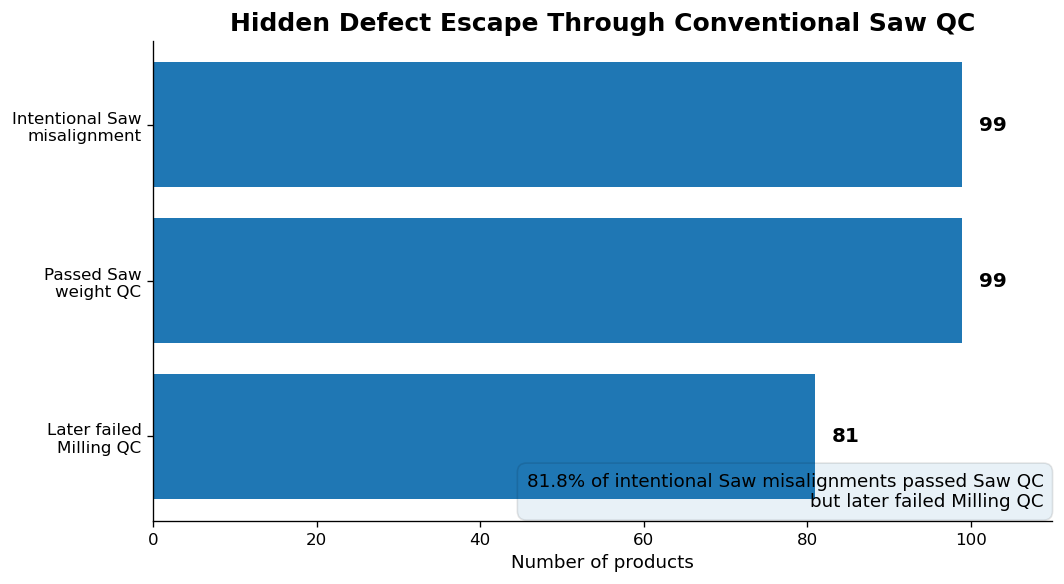

Saved: \kaggle\working\report_visuals\01_problem_funnel.png


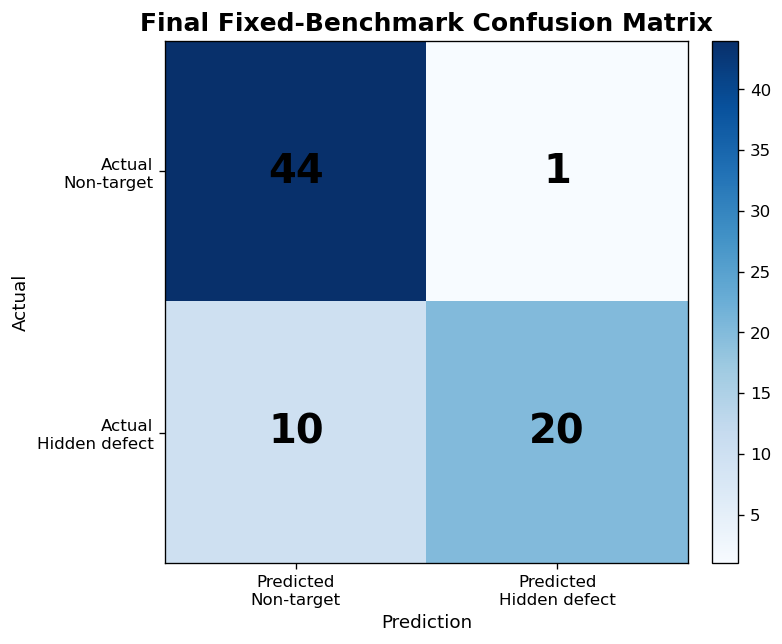

Saved: \kaggle\working\report_visuals\02_final_confusion_matrix.png


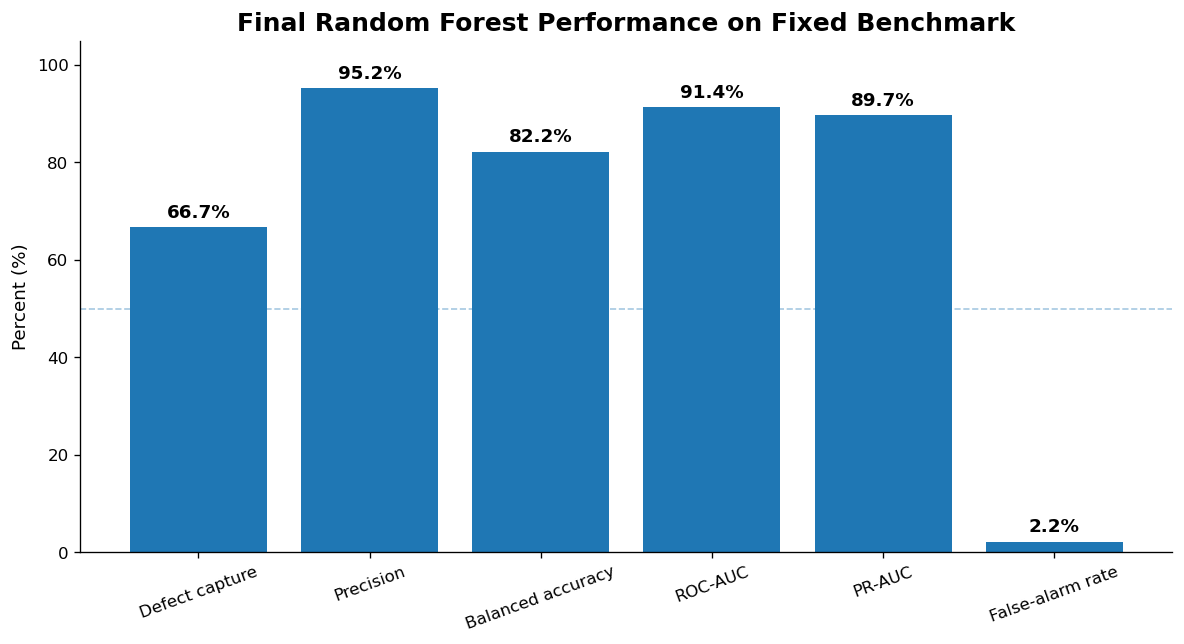

Saved: \kaggle\working\report_visuals\03_final_metrics.png


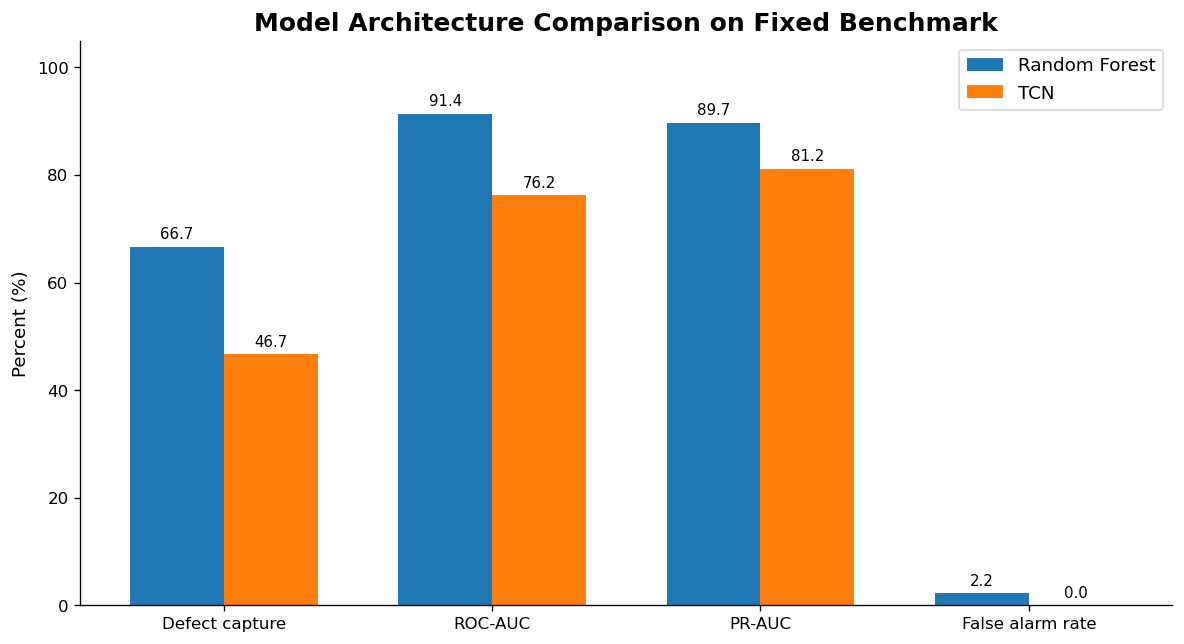

Saved: \kaggle\working\report_visuals\04_model_comparison.png


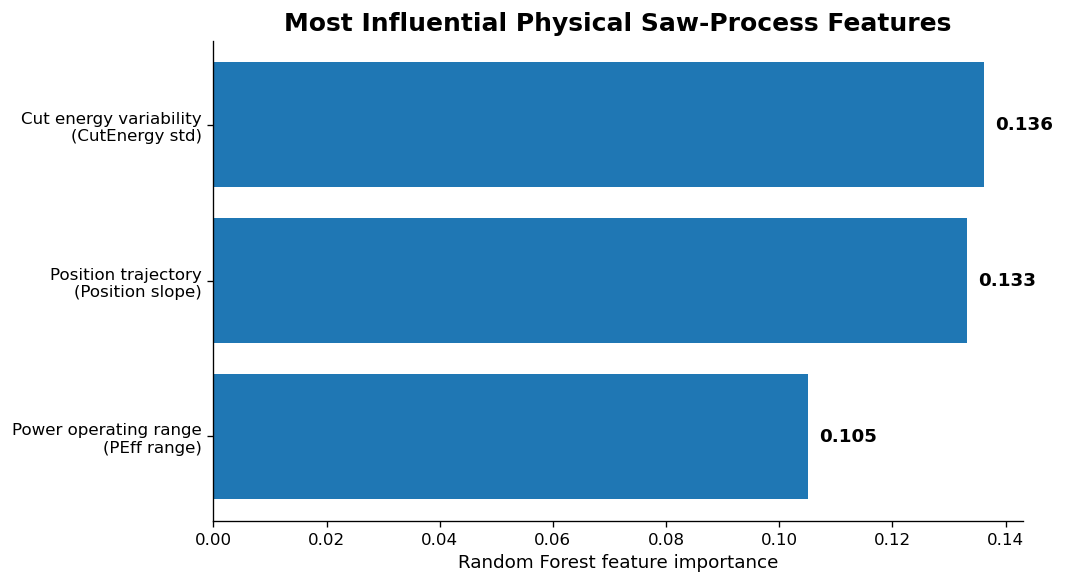

Saved: \kaggle\working\report_visuals\05_feature_importance.png


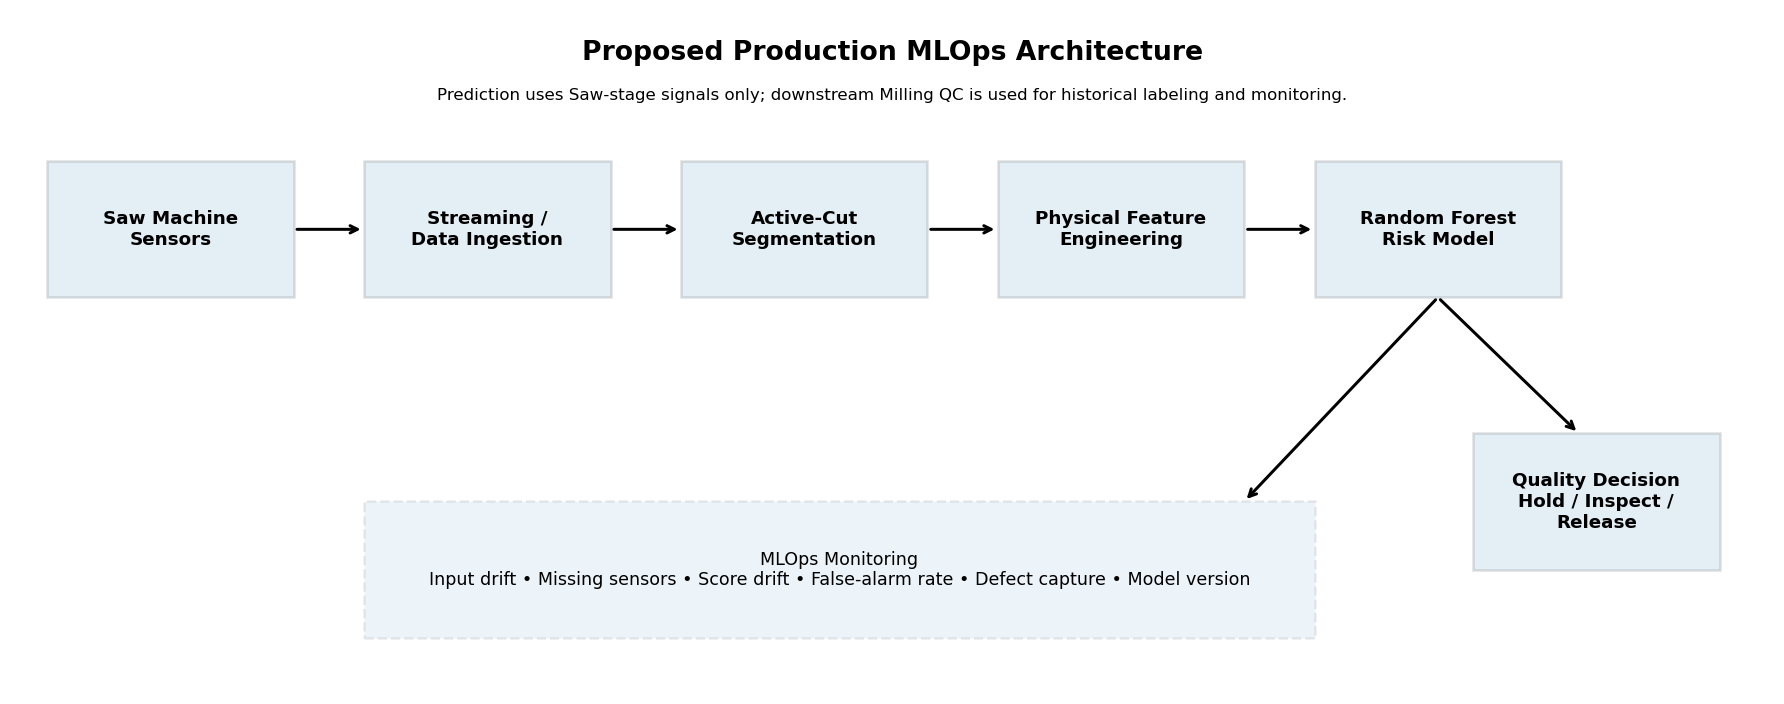

Saved: \kaggle\working\report_visuals\06_mlops_architecture.png


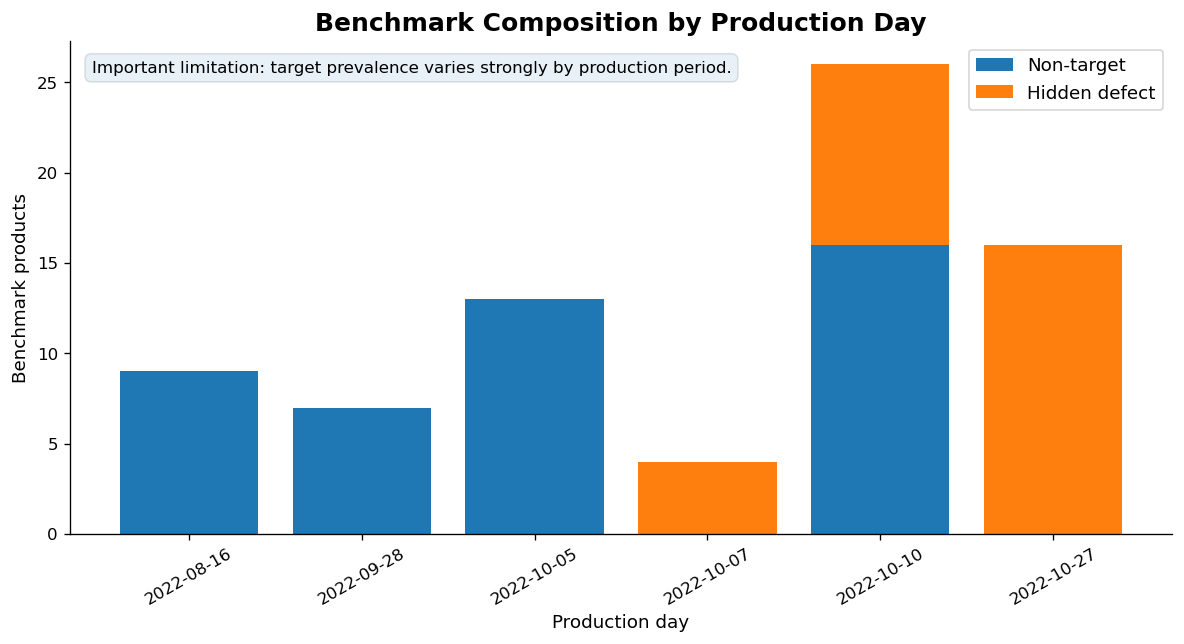

Saved: \kaggle\working\report_visuals\07_benchmark_day_composition.png


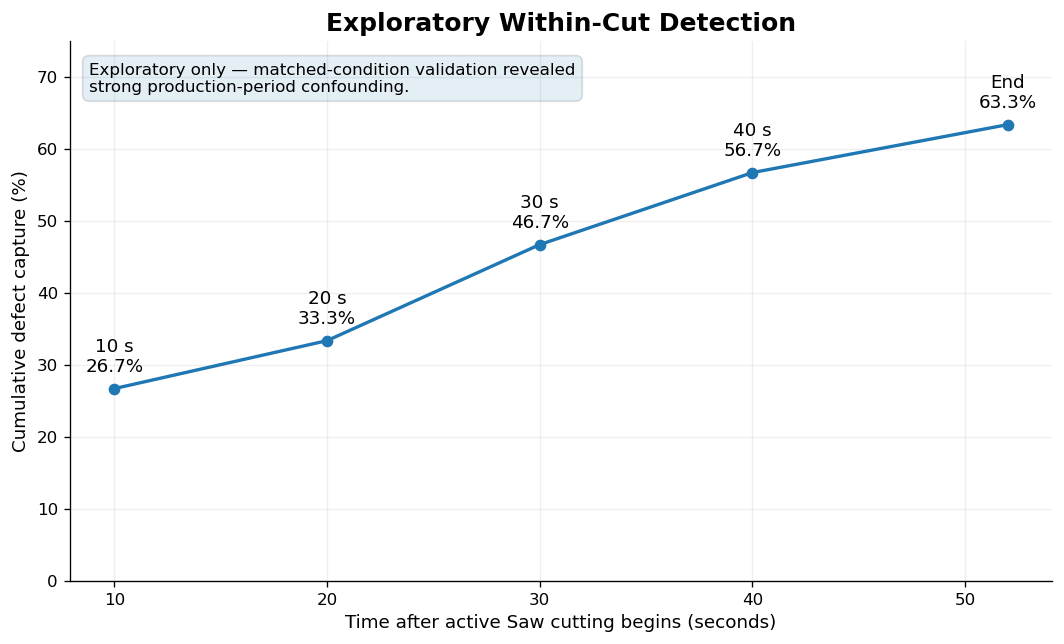

Saved: \kaggle\working\report_visuals\08_early_detection_exploratory.png


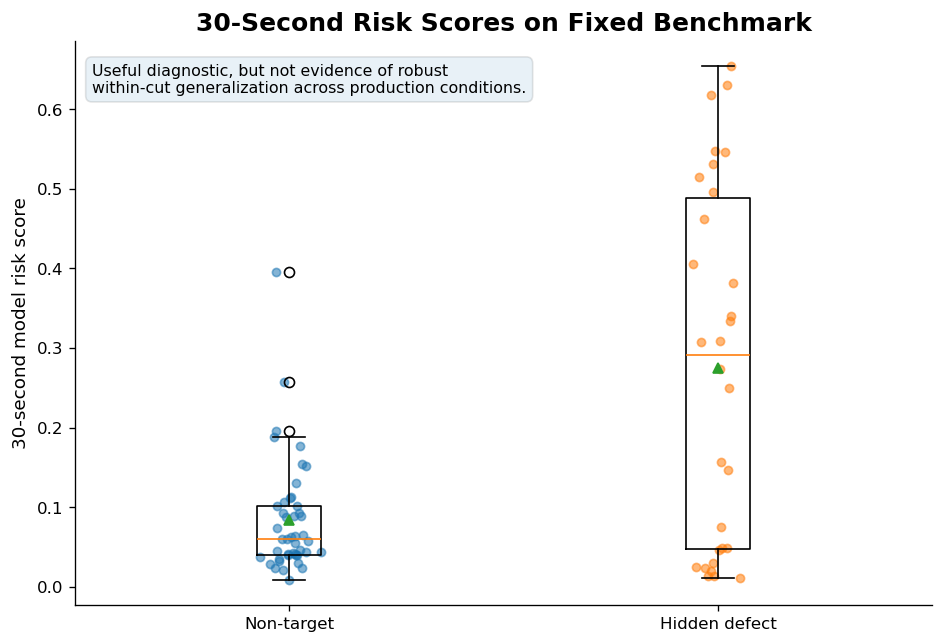

Saved: \kaggle\working\report_visuals\09_model_score_distribution.png


REPORT VISUALS GENERATED
\kaggle\working\report_visuals\01_problem_funnel.png
\kaggle\working\report_visuals\02_final_confusion_matrix.png
\kaggle\working\report_visuals\03_final_metrics.png
\kaggle\working\report_visuals\04_model_comparison.png
\kaggle\working\report_visuals\05_feature_importance.png
\kaggle\working\report_visuals\06_mlops_architecture.png
\kaggle\working\report_visuals\07_benchmark_day_composition.png
\kaggle\working\report_visuals\08_early_detection_exploratory.png
\kaggle\working\report_visuals\09_model_score_distribution.png


In [44]:
# ================================================================
# ADVANCED REPORT VISUAL PACK
# Saw-stage hidden defect early-warning project
#
# Generates:
# 01_problem_funnel.png
# 02_final_confusion_matrix.png
# 03_final_metrics.png
# 04_model_comparison.png
# 05_feature_importance.png
# 06_mlops_architecture.png
# 07_benchmark_day_composition.png
# 08_early_detection_exploratory.png
# 09_model_score_distribution.png
#
# All saved in:
# /kaggle/working/report_visuals/
# ================================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------
# PATHS
# ------------------------------------------------

ROOT = Path("/kaggle/working/saw_clean")
OUT = Path("/kaggle/working/report_visuals")
OUT.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 15,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10
})


def save(name):
    path = OUT / name
    plt.tight_layout()
    plt.savefig(
        path,
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()
    print("Saved:", path)


# ================================================================
# 1. BUSINESS PROBLEM FUNNEL
#
# Dataset-level discovery:
# 99 known Saw misalignments
# 99 passed Saw weight QC
# 81 later failed Milling QC
# ================================================================

labels = [
    "Intentional Saw\nmisalignment",
    "Passed Saw\nweight QC",
    "Later failed\nMilling QC"
]

values = [
    99,
    99,
    81
]

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(
    labels[::-1],
    values[::-1]
)

ax.set_xlim(0, 110)

ax.set_xlabel("Number of products")
ax.set_title(
    "Hidden Defect Escape Through Conventional Saw QC",
    fontweight="bold"
)

for bar, value in zip(bars, values[::-1]):

    ax.text(
        bar.get_width() + 2,
        bar.get_y() + bar.get_height()/2,
        str(value),
        va="center",
        fontweight="bold",
        fontsize=12
    )


ax.text(
    0.99,
    0.02,
    "81.8% of intentional Saw misalignments passed Saw QC\n"
    "but later failed Milling QC",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=11,
    bbox=dict(
        boxstyle="round,pad=0.5",
        alpha=0.1
    )
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

save("01_problem_funnel.png")


# ================================================================
# 2. FINAL RANDOM FOREST CONFUSION MATRIX
#
# Benchmark:
# TN = 44
# FP = 1
# FN = 10
# TP = 20
# ================================================================

cm = np.array([
    [44, 1],
    [10, 20]
])

fig, ax = plt.subplots(figsize=(6.5, 5.5))

im = ax.imshow(
    cm,
    cmap="Blues"
)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels([
    "Predicted\nNon-target",
    "Predicted\nHidden defect"
])

ax.set_yticklabels([
    "Actual\nNon-target",
    "Actual\nHidden defect"
])

ax.set_xlabel("Prediction")
ax.set_ylabel("Actual")

ax.set_title(
    "Final Fixed-Benchmark Confusion Matrix",
    fontweight="bold"
)

for i in range(2):
    for j in range(2):

        ax.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center",
            fontsize=24,
            fontweight="bold"
        )

plt.colorbar(
    im,
    ax=ax,
    fraction=0.046,
    pad=0.04
)

save("02_final_confusion_matrix.png")


# ================================================================
# 3. FINAL BUSINESS / ML METRICS
# ================================================================

metrics = {
    "Defect capture": 66.67,
    "Precision": 95.24,
    "Balanced accuracy": 82.20,
    "ROC-AUC": 91.40,
    "PR-AUC": 89.70,
    "False-alarm rate": 2.22
}

fig, ax = plt.subplots(figsize=(10, 5.5))

names = list(metrics.keys())
vals = list(metrics.values())

bars = ax.bar(
    names,
    vals
)

ax.set_ylim(0, 105)

ax.set_ylabel("Percent (%)")

ax.set_title(
    "Final Random Forest Performance on Fixed Benchmark",
    fontweight="bold"
)

ax.tick_params(
    axis="x",
    rotation=20
)

for bar, value in zip(bars, vals):

    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 2,
        f"{value:.1f}%",
        ha="center",
        fontweight="bold"
    )

ax.axhline(
    50,
    linestyle="--",
    linewidth=1,
    alpha=0.4
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

save("03_final_metrics.png")


# ================================================================
# 4. RANDOM FOREST VS TCN
#
# FAIR comparison:
# Same fixed benchmark
#
# MiniROCKET excluded because it was development-only.
# ================================================================

comparison = pd.DataFrame({

    "Metric": [
        "Defect capture",
        "ROC-AUC",
        "PR-AUC",
        "False alarm rate"
    ],

    "Random Forest": [
        66.67,
        91.40,
        89.70,
        2.22
    ],

    "TCN": [
        46.67,
        76.20,
        81.20,
        0.00
    ]
})


x = np.arange(
    len(comparison)
)

width = 0.35

fig, ax = plt.subplots(figsize=(10, 5.5))

bars1 = ax.bar(
    x - width/2,
    comparison["Random Forest"],
    width,
    label="Random Forest"
)

bars2 = ax.bar(
    x + width/2,
    comparison["TCN"],
    width,
    label="TCN"
)

ax.set_xticks(x)

ax.set_xticklabels(
    comparison["Metric"]
)

ax.set_ylabel("Percent (%)")
ax.set_ylim(0, 105)

ax.set_title(
    "Model Architecture Comparison on Fixed Benchmark",
    fontweight="bold"
)

ax.legend()

for bars in [bars1, bars2]:

    for bar in bars:

        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1.5,
            f"{bar.get_height():.1f}",
            ha="center",
            fontsize=9
        )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

save("04_model_comparison.png")


# ================================================================
# 5. FEATURE IMPORTANCE
#
# Known strongest final RF features.
#
# Only exact importance values currently confirmed are used here.
# ================================================================

feature_importance = pd.DataFrame({

    "Feature": [
        "Cut energy variability\n(CutEnergy std)",
        "Position trajectory\n(Position slope)",
        "Power operating range\n(PEff range)"
    ],

    "Importance": [
        0.136197,
        0.133136,
        0.105111
    ]
})


feature_importance = (
    feature_importance
    .sort_values(
        "Importance"
    )
)


fig, ax = plt.subplots(
    figsize=(9, 5)
)

bars = ax.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

ax.set_xlabel(
    "Random Forest feature importance"
)

ax.set_title(
    "Most Influential Physical Saw-Process Features",
    fontweight="bold"
)

for bar, value in zip(
    bars,
    feature_importance["Importance"]
):

    ax.text(
        value + 0.002,
        bar.get_y() + bar.get_height()/2,
        f"{value:.3f}",
        va="center",
        fontweight="bold"
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

save("05_feature_importance.png")


# ================================================================
# 6. MLOPS / DEPLOYMENT ARCHITECTURE
# ================================================================

fig, ax = plt.subplots(
    figsize=(15, 6)
)

ax.axis("off")


boxes = [

    (
        0.02, 0.58, 0.14, 0.20,
        "Saw Machine\nSensors"
    ),

    (
        0.20, 0.58, 0.14, 0.20,
        "Streaming /\nData Ingestion"
    ),

    (
        0.38, 0.58, 0.14, 0.20,
        "Active-Cut\nSegmentation"
    ),

    (
        0.56, 0.58, 0.14, 0.20,
        "Physical Feature\nEngineering"
    ),

    (
        0.74, 0.58, 0.14, 0.20,
        "Random Forest\nRisk Model"
    ),

    (
        0.83, 0.18, 0.14, 0.20,
        "Quality Decision\nHold / Inspect /\nRelease"
    )
]


for x, y, w, h, text in boxes:

    rect = plt.Rectangle(
        (x, y),
        w,
        h,
        fill=True,
        alpha=0.12,
        edgecolor="black",
        linewidth=1.5
    )

    ax.add_patch(rect)

    ax.text(
        x + w/2,
        y + h/2,
        text,
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold"
    )


def arrow(x1, y1, x2, y2):

    ax.annotate(
        "",
        xy=(x2, y2),
        xytext=(x1, y1),
        arrowprops=dict(
            arrowstyle="->",
            linewidth=1.8
        )
    )


arrow(0.16, 0.68, 0.20, 0.68)
arrow(0.34, 0.68, 0.38, 0.68)
arrow(0.52, 0.68, 0.56, 0.68)
arrow(0.70, 0.68, 0.74, 0.68)

arrow(
    0.81,
    0.58,
    0.89,
    0.38
)


# Monitoring layer

monitor = plt.Rectangle(
    (0.20, 0.08),
    0.54,
    0.20,
    fill=True,
    alpha=0.08,
    edgecolor="black",
    linestyle="--",
    linewidth=1.5
)

ax.add_patch(monitor)

ax.text(
    0.47,
    0.18,
    "MLOps Monitoring\n"
    "Input drift • Missing sensors • Score drift • "
    "False-alarm rate • Defect capture • Model version",
    ha="center",
    va="center",
    fontsize=10.5
)


arrow(
    0.81,
    0.58,
    0.70,
    0.28
)

ax.text(
    0.50,
    0.93,
    "Proposed Production MLOps Architecture",
    ha="center",
    fontsize=16,
    fontweight="bold"
)

ax.text(
    0.50,
    0.87,
    "Prediction uses Saw-stage signals only; downstream Milling QC is used for historical labeling and monitoring.",
    ha="center",
    fontsize=10
)

save("06_mlops_architecture.png")


# ================================================================
# 7. BENCHMARK PRODUCTION-DAY COMPOSITION
#
# Important limitation / scientific-rigor visual.
# ================================================================

PRED_PATH = (
    ROOT /
    "REALTIME_PROGRESSIVE_BENCHMARK.csv"
)

SPLIT_PATH = (
    ROOT /
    "FINAL_LOCKED_HOLDOUT_SPLIT.csv"
)


if PRED_PATH.exists() and SPLIT_PATH.exists():

    pred = pd.read_csv(
        PRED_PATH
    )

    split = pd.read_csv(
        SPLIT_PATH
    )


    for df in [pred, split]:

        df["product_id"] = (
            df["product_id"]
            .astype(str)
            .str.replace(
                r"\.0$",
                "",
                regex=True
            )
        )


    temp = pred.merge(

        split[
            [
                "product_id",
                "production_day"
            ]
        ],

        on="product_id",
        how="left"
    )


    composition = pd.crosstab(
        temp["production_day"],
        temp["hidden_saw_defect"]
    )


    for c in [0, 1]:

        if c not in composition.columns:
            composition[c] = 0


    composition = composition[
        [0, 1]
    ]

    composition.columns = [
        "Non-target",
        "Hidden defect"
    ]


    fig, ax = plt.subplots(
        figsize=(10, 5.5)
    )

    bottom = np.zeros(
        len(composition)
    )


    for col in composition.columns:

        ax.bar(
            composition.index.astype(str),
            composition[col],
            bottom=bottom,
            label=col
        )

        bottom += (
            composition[col]
            .to_numpy()
        )


    ax.set_ylabel(
        "Benchmark products"
    )

    ax.set_xlabel(
        "Production day"
    )

    ax.set_title(
        "Benchmark Composition by Production Day",
        fontweight="bold"
    )

    ax.tick_params(
        axis="x",
        rotation=30
    )

    ax.legend()

    ax.text(
        0.02,
        0.96,
        "Important limitation: target prevalence varies strongly by production period.",
        transform=ax.transAxes,
        va="top",
        fontsize=10,
        bbox=dict(
            boxstyle="round,pad=0.4",
            alpha=0.1
        )
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    save(
        "07_benchmark_day_composition.png"
    )


# ================================================================
# 8. EXPLORATORY REAL-TIME DETECTION
#
# IMPORTANT:
# Label clearly as exploratory / NOT validated final claim.
# ================================================================

times = [
    10,
    20,
    30,
    40,
    52
]

capture = [
    26.67,
    33.33,
    46.67,
    56.67,
    63.33
]

labels = [
    "10 s",
    "20 s",
    "30 s",
    "40 s",
    "End"
]


fig, ax = plt.subplots(
    figsize=(9, 5.5)
)

ax.plot(
    times,
    capture,
    marker="o",
    linewidth=2
)

for x, y, lab in zip(
    times,
    capture,
    labels
):

    ax.annotate(
        f"{lab}\n{y:.1f}%",
        (x, y),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center"
    )


ax.set_ylim(
    0,
    75
)

ax.set_xlabel(
    "Time after active Saw cutting begins (seconds)"
)

ax.set_ylabel(
    "Cumulative defect capture (%)"
)

ax.set_title(
    "Exploratory Within-Cut Detection",
    fontweight="bold"
)

ax.text(
    0.02,
    0.96,
    "Exploratory only — matched-condition validation revealed\n"
    "strong production-period confounding.",
    transform=ax.transAxes,
    va="top",
    fontsize=10,
    bbox=dict(
        boxstyle="round,pad=0.4",
        alpha=0.12
    )
)

ax.grid(
    alpha=0.2
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

save(
    "08_early_detection_exploratory.png"
)


# ================================================================
# 9. 30-SECOND SCORE DISTRIBUTION
#
# Useful to visually show why real-time model was not accepted.
# ================================================================

if PRED_PATH.exists():

    pred = pd.read_csv(
        PRED_PATH
    )

    defect_scores = pred.loc[
        pred[
            "hidden_saw_defect"
        ] == 1,
        "prob_30s"
    ].dropna()

    normal_scores = pred.loc[
        pred[
            "hidden_saw_defect"
        ] == 0,
        "prob_30s"
    ].dropna()


    fig, ax = plt.subplots(
        figsize=(8, 5.5)
    )


    bp = ax.boxplot(
        [
            normal_scores,
            defect_scores
        ],
        tick_labels=[
            "Non-target",
            "Hidden defect"
        ],
        showmeans=True
    )


    # overlay individual observations
    rng = np.random.default_rng(42)

    for i, vals in enumerate(
        [
            normal_scores,
            defect_scores
        ],
        start=1
    ):

        jitter = rng.normal(
            i,
            0.035,
            size=len(vals)
        )

        ax.scatter(
            jitter,
            vals,
            alpha=0.55,
            s=24
        )


    ax.set_ylabel(
        "30-second model risk score"
    )

    ax.set_title(
        "30-Second Risk Scores on Fixed Benchmark",
        fontweight="bold"
    )

    ax.text(
        0.02,
        0.96,
        "Useful diagnostic, but not evidence of robust\n"
        "within-cut generalization across production conditions.",
        transform=ax.transAxes,
        va="top",
        fontsize=9.5,
        bbox=dict(
            boxstyle="round,pad=0.4",
            alpha=0.10
        )
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    save(
        "09_model_score_distribution.png"
    )


# ================================================================
# 10. FINAL FILE LIST
# ================================================================

print("\n")
print("=" * 80)
print("REPORT VISUALS GENERATED")
print("=" * 80)

for p in sorted(
    OUT.glob("*.png")
):

    print(p)